# Phase 0: Research Contract

## 0.1 Prediction Task and Evaluation Metric

### Prediction Target

Use the given data to predict `responder_6` using only information available at prediction time.

### Unit of Observation

Each row represents one observation for an anonymized financial instrument at a specific date and time step.

- `date_id`: an anonymized chronological date index
- `time_id`: an ordered time step within a date
- `symbol_id`: an anonymized financial instrument identifier

### Sample Weight

The `weight` column determines how strongly each observation contributes to the evaluation score.

### Evaluation Metric

The competition uses the sample-weighted zero-mean \(R^2\) score:

$$
R^2
=
1-
\frac{\sum_i w_i(y_i-\hat{y}_i)^2}
{\sum_i w_i y_i^2}
$$

where:

- \(y_i\) is the actual value of `responder_6`.
- \(\hat{y}_i\) is the predicted value of `responder_6`.
- \(w_i\) is the sample weight used in the evaluation metric.

A higher score indicates better predictive performance. If every prediction is zero, the score is 0. The score can be negative when the model performs poorly.

## 0.2 Information Availability and Validation Timeline

- **Prediction time:** The prediction should be made before the current `responder_6` is revealed.

- **Available information:** The current row identifiers and features are available. Responders from the previous date may be used only after their lagged values are provided by the evaluation API at the first time step of the next date.
  
- **Unavailable information:** The current or future responders, future features, and preprocessing fitted on future data cannot be used.

- **Validation timeline:** Earlier dates are used for training, later dates for validation, and the most recent period is kept as a sealed final holdout.

In [3]:
from pathlib import Path

project_root = Path.cwd()
train_dir = project_root / "train.parquet"

print("Project root", project_root)
print("Training directory", train_dir)
print("Exists", train_dir.exists())
print("Is directory", train_dir.is_dir())


Project root <PROJECT_ROOT>
Training directory <PROJECT_ROOT>\train.parquet
Exists True
Is directory True


In [4]:
partition_files = sorted(
    train_dir.glob("partition_id=*/part-*.parquet")
)
print(type(partition_files))
print(len(partition_files))
for file_path in partition_files:
    print(file_path)


<class 'list'>
10
<PROJECT_ROOT>\train.parquet\partition_id=0\part-0.parquet
<PROJECT_ROOT>\train.parquet\partition_id=1\part-1.parquet
<PROJECT_ROOT>\train.parquet\partition_id=2\part-2.parquet
<PROJECT_ROOT>\train.parquet\partition_id=3\part-3.parquet
<PROJECT_ROOT>\train.parquet\partition_id=4\part-4.parquet
<PROJECT_ROOT>\train.parquet\partition_id=5\part-5.parquet
<PROJECT_ROOT>\train.parquet\partition_id=6\part-6.parquet
<PROJECT_ROOT>\train.parquet\partition_id=7\part-7.parquet
<PROJECT_ROOT>\train.parquet\partition_id=8\part-8.parquet
<PROJECT_ROOT>\train.parquet\partition_id=9\part-9.parquet


In [5]:
total_size_gib = 0

for file_path in partition_files:
    file_size_gib = file_path.stat().st_size/(1024**3)
    file_name = file_path.name
    print(f"{file_name} is {file_size_gib:.2f} GiB")
    total_size_gib += file_size_gib

print(f"total size is {total_size_gib:.2f} GiB")


part-0.parquet is 0.44 GiB
part-1.parquet is 0.66 GiB
part-2.parquet is 0.74 GiB
part-3.parquet is 0.98 GiB
part-4.parquet is 1.23 GiB
part-5.parquet is 1.31 GiB
part-6.parquet is 1.52 GiB
part-7.parquet is 1.55 GiB
part-8.parquet is 1.50 GiB
part-9.parquet is 1.53 GiB
total size is 11.45 GiB


In [6]:
import pyarrow.parquet as pq

first_partition = partition_files[0]
parquet_file = pq.ParquetFile(first_partition)
metadata = parquet_file.metadata

print("File", first_partition.name)
print("Rows", metadata.num_rows)
print("Row groups", metadata.num_row_groups)
print("Columns", metadata.num_columns)
print("Columns_names", parquet_file.schema.names)


File part-0.parquet
Rows 1944210
Row groups 7
Columns 92
Columns_names ['date_id', 'time_id', 'symbol_id', 'weight', 'feature_00', 'feature_01', 'feature_02', 'feature_03', 'feature_04', 'feature_05', 'feature_06', 'feature_07', 'feature_08', 'feature_09', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27', 'feature_28', 'feature_29', 'feature_30', 'feature_31', 'feature_32', 'feature_33', 'feature_34', 'feature_35', 'feature_36', 'feature_37', 'feature_38', 'feature_39', 'feature_40', 'feature_41', 'feature_42', 'feature_43', 'feature_44', 'feature_45', 'feature_46', 'feature_47', 'feature_48', 'feature_49', 'feature_50', 'feature_51', 'feature_52', 'feature_53', 'feature_54', 'feature_55', 'feature_56', 'feature_57', 'feature_58', 'feature_59', 'feature_60', 'feature_61', 'feature_62', '

In [7]:
inventory = []

for file_path in partition_files:
    parquet_file = pq.ParquetFile(file_path)
    metadata = parquet_file.metadata

    partition_info = {
        "file": file_path.name,
        "rows": metadata.num_rows,
        "row_groups": metadata.num_row_groups,
        "columns": metadata.num_columns,
        "size_gib": round(file_path.stat().st_size / 1024**3, 2)
    }

    inventory.append(partition_info)

import pandas as pd

inventory_df = pd.DataFrame(inventory)
inventory_df


,file,rows,row_groups,columns,size_gib
0,part-0.parquet,1944210,7,92,0.44
1,part-1.parquet,2804247,10,92,0.66
2,part-2.parquet,3036873,11,92,0.74
3,part-3.parquet,4016784,15,92,0.98
4,part-4.parquet,5022952,19,92,1.23
5,part-5.parquet,5348200,20,92,1.31
6,part-6.parquet,6203912,23,92,1.52
7,part-7.parquet,6335560,24,92,1.55
8,part-8.parquet,6140024,23,92,1.50
9,part-9.parquet,6274576,23,92,1.53


In [8]:
print(f"Total rows: {inventory_df['rows'].sum():,}")


Total rows: 47,127,338


In [9]:
date_ranges = []

for file_path in partition_files:

    date_data = pd.read_parquet(
        file_path,
        columns = ["date_id"]
    )

    temp = {
        "file" : file_path.name,
        "min_date" : date_data["date_id"].min(),
        "max_date" : date_data["date_id"].max(),
        "unique_dates" : date_data["date_id"].nunique()
    }

    date_ranges.append(temp)

date_ranges_df = pd.DataFrame(date_ranges)
date_ranges_df


,file,min_date,max_date,unique_dates
0,part-0.parquet,0,169,170
1,part-1.parquet,170,339,170
2,part-2.parquet,340,509,170
3,part-3.parquet,510,679,170
4,part-4.parquet,680,849,170
5,part-5.parquet,850,1019,170
6,part-6.parquet,1020,1189,170
7,part-7.parquet,1190,1359,170
8,part-8.parquet,1360,1529,170
9,part-9.parquet,1530,1698,169


In [10]:
reference_schema = pq.ParquetFile(
    partition_files[0]
).schema_arrow

for file_path in partition_files:
    print(f"{file_path.name}", pq.ParquetFile(file_path).schema_arrow.equals(reference_schema))


part-0.parquet True
part-1.parquet True
part-2.parquet True
part-3.parquet True
part-4.parquet True
part-5.parquet True
part-6.parquet True
part-7.parquet True
part-8.parquet True
part-9.parquet True


In [11]:
column_types = []

for field in reference_schema:
    
    temp = {
        "variable" : field.name,
        "type" : str(field.type)
    }

    column_types.append(temp)

column_types_df = pd.DataFrame(column_types)

result = (
    column_types_df.groupby("type", as_index = False)["variable"]
    .count()
    .rename(columns = {
        "variable" : "num"
    })
)

result["percentage"] = (result["num"]/92*100).round(2)

column_types_df


,variable,type
0,date_id,int16
1,time_id,int16
2,symbol_id,int8
3,weight,float
4,feature_00,float
...,...,...
87,responder_4,float
88,responder_5,float
89,responder_6,float
90,responder_7,float


In [12]:
result


,type,num,percentage
0,float,86,93.48
1,int16,3,3.26
2,int8,3,3.26


In [13]:
result["percentage"].sum()


100.00000000000001

In [14]:
duplicate_checks = []

for file_path in partition_files:

    primary_key_data = pd.read_parquet(
        file_path,
        columns = ["date_id", "time_id", "symbol_id"]
    )

    duplicate_masks = primary_key_data.duplicated(
        subset = ["date_id", "time_id", "symbol_id"]
    ).sum()

    temp = {
        "file" : file_path.name,
        "rows" : len(primary_key_data),
        "duplicate_rows" : duplicate_masks
    }

    duplicate_checks.append(temp)

duplicate_checks_df = pd.DataFrame(duplicate_checks)
duplicate_checks_df


,file,rows,duplicate_rows
0,part-0.parquet,1944210,0
1,part-1.parquet,2804247,0
2,part-2.parquet,3036873,0
3,part-3.parquet,4016784,0
4,part-4.parquet,5022952,0
5,part-5.parquet,5348200,0
6,part-6.parquet,6203912,0
7,part-7.parquet,6335560,0
8,part-8.parquet,6140024,0
9,part-9.parquet,6274576,0


In [15]:
time_checks = []

for file_path in partition_files:

    date_time_data = pd.read_parquet(
        file_path,
        columns = ["date_id", "time_id"]
    )

    temp_index = pd.MultiIndex.from_frame(date_time_data)
    is_time_sorted = temp_index.is_monotonic_increasing

    temp = {
        "file" : file_path.name,
        "sorted" : is_time_sorted
    }

    time_checks.append(temp)

time_checks_df = pd.DataFrame(time_checks)
time_checks_df 


,file,sorted
0,part-0.parquet,True
1,part-1.parquet,True
2,part-2.parquet,True
3,part-3.parquet,True
4,part-4.parquet,True
5,part-5.parquet,True
6,part-6.parquet,True
7,part-7.parquet,True
8,part-8.parquet,True
9,part-9.parquet,True


## 1. Data Inventory Summary
- There is a total of 10 Parquet partitions,47,127,338 rows, approximately 11.45GiB in size
- There is a total of 92 columns, in which are made up of 4 identifier/weight columns, 79 features and 9 responders
- All 10 Parquet partitions have identical schema
- date_id ranges continuously from 0 to 1698, with no gaps or overlaps between partitions
- Each row is uniquely identified by the combination of `date_id`, `time_id`, and `symbol_id`.
- All parquets are sorted by their `date_id` and then `time_id`
- We should read one partition and only the required columns at a time, avoiding reading all parquets at once

In [17]:
feature_00_null_checks = []

for file_path in partition_files:
    
    parquet_file = pq.ParquetFile(file_path)
    metadata = parquet_file.metadata
    
    column_index = parquet_file.schema_arrow.get_field_index(
        "feature_00"
    )
    
    null_count = 0
    
    for row_group_index in range(metadata.num_row_groups):
        
        statistics = (
            metadata
            .row_group(row_group_index)
            .column(column_index)
            .statistics
        )
        
        null_count += statistics.null_count
    
    null_percentage = round(
        null_count / metadata.num_rows * 100,
        2
    )
    
    partition_result = {
        "file": file_path.name,
        "rows": metadata.num_rows,
        "null_count": null_count,
        "null_percentage": null_percentage
    }
    
    feature_00_null_checks.append(partition_result)

feature_00_null_df = pd.DataFrame(feature_00_null_checks)

feature_00_null_df


,file,rows,null_count,null_percentage
0,part-0.parquet,1944210,1944210,100.00
1,part-1.parquet,2804247,1237842,44.14
2,part-2.parquet,3036873,0,0.00
3,part-3.parquet,4016784,0,0.00
4,part-4.parquet,5022952,0,0.00
5,part-5.parquet,5348200,0,0.00
6,part-6.parquet,6203912,0,0.00
7,part-7.parquet,6335560,0,0.00
8,part-8.parquet,6140024,0,0.00
9,part-9.parquet,6274576,0,0.00


### Missingness Investigation: `feature_00`

- `feature_00` is not permanently missing.
- It is completely missing in `part-0` and partially missing in `part-1`, but it is fully available from `part-2` onward.
- We should not drop `feature_00` based solely on its missingness in `part-0`.
- We should extend this audit to all features and later investigate their temporal and co-missingness patterns.

### Missingness Across All Features and Partitions

We extend the metadata-based missingness audit to all 79 features and all 10 partitions. The resulting long-format table allows us to distinguish permanent missingness from time-dependent feature availability.

In [20]:
feature_columns = [
    f"feature_{i:02d}" for i in range(79)
]

null_stats = []

for file_path in partition_files:
    
    parquet_file = pq.ParquetFile(file_path)
    metadata = parquet_file.metadata
    
    for feature_name in feature_columns:
        
        column_index = (
            parquet_file
            .schema_arrow
            .get_field_index(feature_name)
        )
        
        null_count = 0
        
        for row_group_index in range(metadata.num_row_groups):
            
            statistics = (
                metadata
                .row_group(row_group_index)
                .column(column_index)
                .statistics
            )
            
            null_count += statistics.null_count
        
        null_percentage = round(
            null_count / metadata.num_rows * 100,
            2
        )
        
        feature_result = {
            "file": file_path.name,
            "feature": feature_name,
            "rows": metadata.num_rows,
            "null_count": null_count,
            "null_percentage": null_percentage
        }
        
        null_stats.append(feature_result)

null_stats_df = pd.DataFrame(null_stats)

print("Shape:", null_stats_df.shape)

display(null_stats_df.head())
display(null_stats_df.tail())


Shape: (790, 5)


,file,feature,rows,null_count,null_percentage
0,part-0.parquet,feature_00,1944210,1944210,100.0
1,part-0.parquet,feature_01,1944210,1944210,100.0
2,part-0.parquet,feature_02,1944210,1944210,100.0
3,part-0.parquet,feature_03,1944210,1944210,100.0
4,part-0.parquet,feature_04,1944210,1944210,100.0


,file,feature,rows,null_count,null_percentage
785,part-9.parquet,feature_74,6274576,61707,0.98
786,part-9.parquet,feature_75,6274576,10480,0.17
787,part-9.parquet,feature_76,6274576,10480,0.17
788,part-9.parquet,feature_77,6274576,1945,0.03
789,part-9.parquet,feature_78,6274576,1945,0.03


In [21]:
feature_rows_count = (
    null_stats_df
    .drop(columns = "file")
    .groupby("feature", as_index = False)["rows"]
    .sum()
    .rename(columns = {
        "rows" : "total_rows"
    })
)

feature_null_count = (
    null_stats_df
    .drop(columns = "file")
    .groupby("feature", as_index = False)["null_count"]
    .sum()
)   

feature_null_stats = feature_rows_count.merge(
    feature_null_count,
    on = "feature"
)

feature_null_stats["null_percentage"] = round(
    feature_null_stats["null_count"]/feature_null_stats["total_rows"]*100, 2
)

feature_null_stats = (
    feature_null_stats
    .sort_values(
        ["null_count", "feature"],
        ascending= [False, True]
    )
    .reset_index(drop=True)
)

print("Shape:", feature_null_stats.shape)

display(feature_null_stats.head(10))
display(feature_null_stats.tail(10))


Shape: (79, 4)


,feature,total_rows,null_count,null_percentage
0,feature_21,47127338,8435985,17.90
1,feature_26,47127338,8435985,17.90
2,feature_27,47127338,8435985,17.90
3,feature_31,47127338,8435985,17.90
4,feature_39,47127338,4300649,9.13
5,feature_42,47127338,4300649,9.13
6,feature_50,47127338,4254098,9.03
7,feature_53,47127338,4254098,9.03
8,feature_00,47127338,3182052,6.75
9,feature_01,47127338,3182052,6.75


,feature,total_rows,null_count,null_percentage
69,feature_49,47127338,0,0.0
70,feature_59,47127338,0,0.0
71,feature_60,47127338,0,0.0
72,feature_61,47127338,0,0.0
73,feature_67,47127338,0,0.0
74,feature_68,47127338,0,0.0
75,feature_69,47127338,0,0.0
76,feature_70,47127338,0,0.0
77,feature_71,47127338,0,0.0
78,feature_72,47127338,0,0.0


In [22]:
feature_info = pd.DataFrame([{
    "total_features" : len(feature_null_stats),
    "features_with_missing_values" : (feature_null_stats["null_count"] > 0).sum(),
    "fully_observed_features" : (feature_null_stats["null_count"] == 0).sum(),
    "maximum_null_percentage" : feature_null_stats["null_percentage"].max()
}])

feature_info


,total_features,features_with_missing_values,fully_observed_features,maximum_null_percentage
0,79,47,32,17.9


### Feature Missingness Summary

- There are 79 features in total.
- 47 features contain missing values, accounting for 59.49% of all features.
- 32 features do not contain any missing values, accounting for 40.51% of all features.
- The maximum overall missingness rate among the features is 17.90%.
- These global percentages may hide temporal and partition-level missingness patterns, so they are not sufficient for deciding whether to drop or impute a feature.

## 2.2 Temporal Missingness Patterns

We reshape the partition-level missingness statistics into a feature-by-partition matrix. This matrix helps reveal whether missingness is persistent, sporadic, or concentrated in specific periods.

In [25]:
partition_order = [
    f"part-{i}.parquet" for i in range(10)
]

feature_order = (
    feature_null_stats["feature"]
    .tolist()
)

missingness_matrix = null_stats_df.pivot(
    index="feature",
    columns="file",
    values="null_percentage"
)

missingness_matrix = missingness_matrix.reindex(
    index=feature_order,
    columns=partition_order
)

print("Shape:", missingness_matrix.shape)

print(
    "Missing matrix cells:",
    missingness_matrix.isna().sum().sum()
)

display(missingness_matrix.head(10))


Shape: (79, 10)
Missing matrix cells: 0


file,part-0.parquet,part-1.parquet,part-2.parquet,part-3.parquet,part-4.parquet,part-5.parquet,part-6.parquet,part-7.parquet,part-8.parquet,part-9.parquet
feature,,,,,,,,,,
feature_21,100.00,100.00,100.00,10.63,0.44,1.77,0.00,0.43,0.03,1.23
feature_26,100.00,100.00,100.00,10.63,0.44,1.77,0.00,0.43,0.03,1.23
feature_27,100.00,100.00,100.00,10.63,0.44,1.77,0.00,0.43,0.03,1.23
feature_31,100.00,100.00,100.00,10.63,0.44,1.77,0.00,0.43,0.03,1.23
feature_39,16.70,15.42,15.18,14.95,7.03,7.02,7.02,7.02,7.02,7.02
feature_42,16.70,15.42,15.18,14.95,7.03,7.02,7.02,7.02,7.02,7.02
feature_50,15.08,15.08,15.08,14.91,7.02,7.02,7.02,7.02,7.02,7.02
feature_53,15.08,15.08,15.08,14.91,7.02,7.02,7.02,7.02,7.02,7.02
feature_00,100.00,44.14,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


### Partition-Level Missingness Heatmap

We visualize the feature-by-partition missingness matrix to identify temporal availability shifts and groups of features with similar missingness patterns.

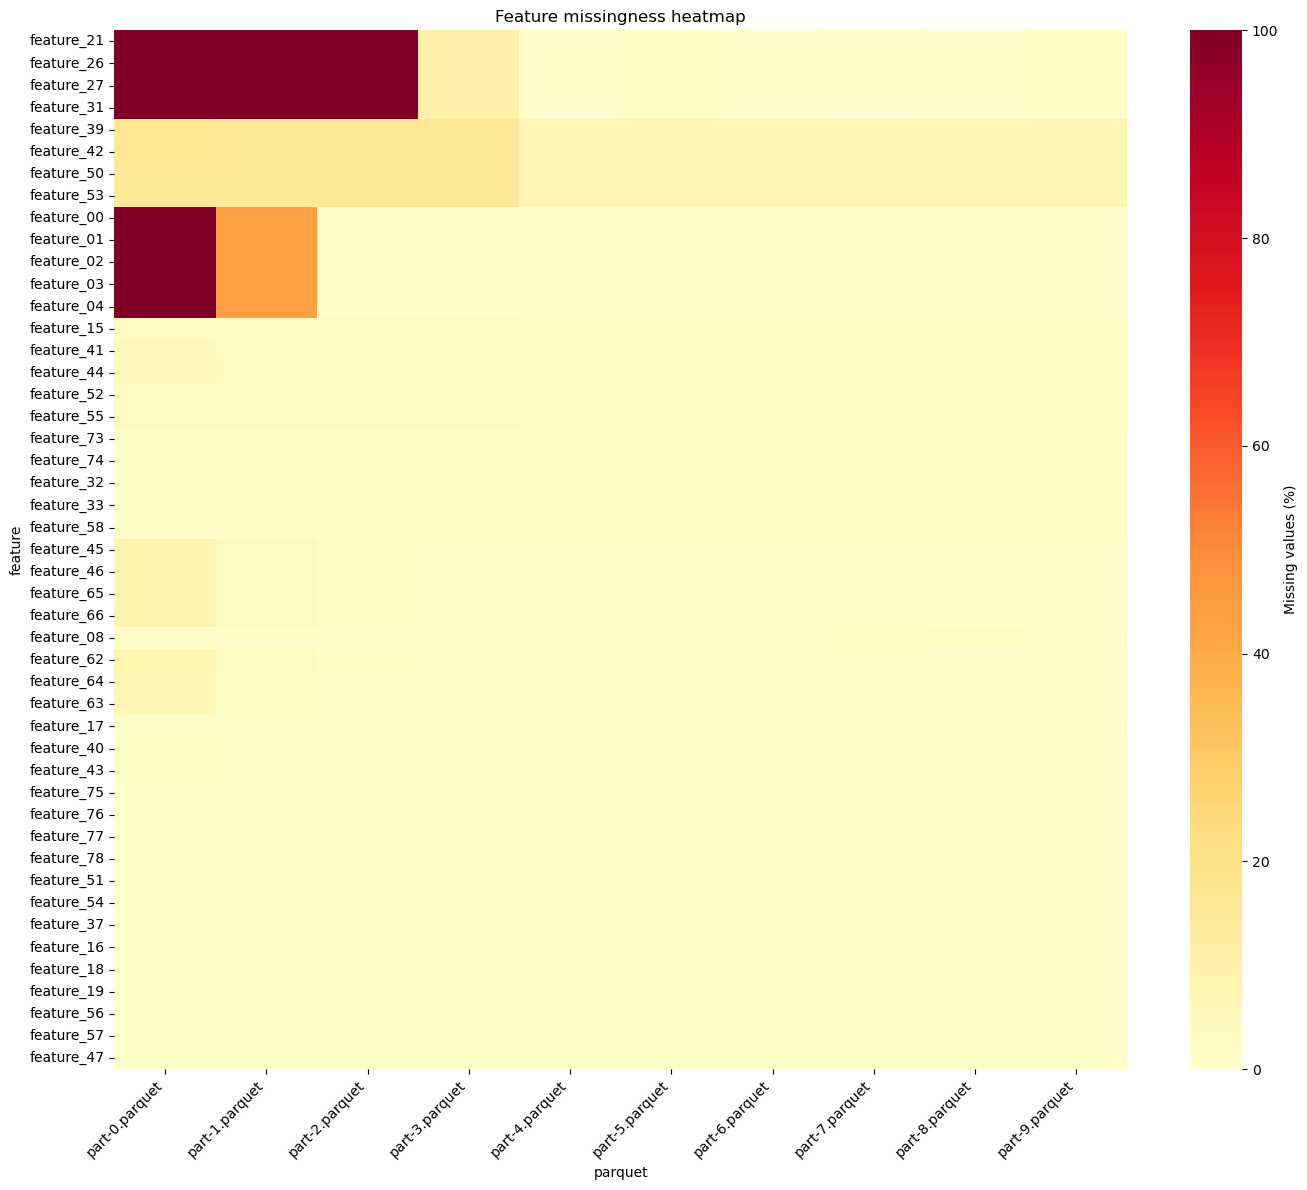

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 12))
plt.xticks(rotation=45, ha="right")

features_with_missing = feature_null_stats.loc[
    feature_null_stats["null_count"] > 0,
    "feature"
]

missingness_plot_data = missingness_matrix.loc[
    features_with_missing
]

sns.heatmap(
    missingness_plot_data,
    cmap="YlOrRd",
    vmin=0,
    vmax=100,
    cbar_kws={
        "label": "Missing values (%)"
    }
)

plt.title("Feature missingness heatmap")
plt.xlabel("parquet")
plt.ylabel("feature")
plt.tight_layout()
plt.show()


### Partition-Level Missingness Interpretation

- Missingness is not distributed uniformly across features or partitions.
- `feature_21`, `feature_26`, `feature_27`, and `feature_31` share a clear partition-level pattern: they are completely missing in the first three partitions and have much lower missingness afterward.
- `feature_00` through `feature_04` are missing mainly in the early partitions and become fully available from `part-2` onward.
- Identical partition-level missingness percentages do not prove that two features are missing in exactly the same rows.
- No feature is completely missing across the full training dataset, so none should be dropped based only on this heatmap.

### Date-Level Availability of `feature_21`

We inspect the daily missingness of `feature_21` within `part-3`, where the feature changes from complete unavailability to partial availability. This helps determine whether the transition occurs at a clear date boundary or through sporadic missingness.

In [30]:
feature_21_part3 = pd.read_parquet(
    partition_files[3],
    columns = ["date_id", "feature_21"]
)

daily_stats = (
    feature_21_part3.groupby(
        "date_id",
        as_index=False
    )
    .agg(
        rows=("feature_21", "size"),
        non_null_count=("feature_21", "count")
    )
)

daily_stats["null_count"] = (
    daily_stats["rows"]
    - daily_stats["non_null_count"]
)

daily_stats["null_percentage"] = (
    daily_stats["null_count"]
    / daily_stats["rows"]
    * 100
).round(2)

first_available_date = daily_stats.loc[
    daily_stats["non_null_count"] > 0,
    "date_id"
].min()

print("Shape:", daily_stats.shape)
print("First available date:", first_available_date)
display(daily_stats.head(15))
display(daily_stats.tail(15))


Shape: (170, 5)
First available date: 528


,date_id,rows,non_null_count,null_count,null_percentage
0,510,23772,0,23772,100.0
1,511,22923,0,22923,100.0
2,512,23772,0,23772,100.0
3,513,23772,0,23772,100.0
4,514,23772,0,23772,100.0
5,515,23772,0,23772,100.0
6,516,23772,0,23772,100.0
7,517,23772,0,23772,100.0
8,518,23772,0,23772,100.0
9,519,23772,0,23772,100.0


,date_id,rows,non_null_count,null_count,null_percentage
155,665,23772,23772,0,0.0
156,666,23772,23772,0,0.0
157,667,23772,23772,0,0.0
158,668,23772,23772,0,0.0
159,669,22923,22923,0,0.0
160,670,23772,23772,0,0.0
161,671,23772,23772,0,0.0
162,672,24621,24621,0,0.0
163,673,24621,24621,0,0.0
164,674,24621,24621,0,0.0


In [31]:
transition_window = daily_stats.loc[
    daily_stats["date_id"].between(
        first_available_date - 3,
        first_available_date + 3
    )
]

transition_window


,date_id,rows,non_null_count,null_count,null_percentage
15,525,23772,0,23772,100.0
16,526,23772,0,23772,100.0
17,527,23772,0,23772,100.0
18,528,23772,23772,0,0.0
19,529,23772,23772,0,0.0
20,530,23772,23772,0,0.0
21,531,23772,23772,0,0.0


### Date-Level Availability of `feature_21`

- `feature_21` was completely missing from `date_id` 0 through 527.
- It became fully available starting at `date_id` 528.
- The transition from complete missingness to full availability was abrupt rather than gradual.
- This pattern is consistent with a structural availability boundary, but its underlying cause cannot be determined from the anonymized data.

## 2.3 Row-Level Co-Missingness

We convert the missingness states of selected features into binary indicators and examine whether they are missing in the same rows. This provides stronger evidence than comparing only partition-level missingness percentages.

In [34]:
candidate_features = [
    "feature_21",
    "feature_26",
    "feature_27",
    "feature_31"
]

candidate_data = pd.read_parquet(
    partition_files[3],
    columns=candidate_features
)

missing_indicators = (
    candidate_data
    .isna()
    .astype("int8")
)

missingness_correlation = (
    missing_indicators.corr()
)

mismatch_count_21_26 = (
    missing_indicators["feature_21"]
    != missing_indicators["feature_26"]
).sum()

print(
    "Indicator shape:",
    missing_indicators.shape
)

print(
    "feature_21 vs feature_26 mismatches:",
    mismatch_count_21_26
)

display(missingness_correlation)


Indicator shape: (4016784, 4)
feature_21 vs feature_26 mismatches: 0


,feature_21,feature_26,feature_27,feature_31
feature_21,1.0,1.0,1.0,1.0
feature_26,1.0,1.0,1.0,1.0
feature_27,1.0,1.0,1.0,1.0
feature_31,1.0,1.0,1.0,1.0


In [35]:
mismatch_vs_feature_21 = (
    missing_indicators
    .ne(
        missing_indicators["feature_21"],
        axis=0
    )
    .sum()
)

mismatch_vs_feature_21


feature_21    0
feature_26    0
feature_27    0
feature_31    0
dtype: int64

In [36]:
partitions_to_check = [
    partition_files[4],
    partition_files[5],
    partition_files[7],
    partition_files[8],
    partition_files[9]
]

partition_mismatches = []

for file_path in partitions_to_check:
    
    candidate_data = pd.read_parquet(
        file_path,
        columns=candidate_features
    )
    
    missing_indicators = (
        candidate_data
        .isna()
        .astype("int8")
    )
    
    mismatch_counts = (
        missing_indicators
        .ne(
            missing_indicators["feature_21"],
            axis=0
        )
        .sum()
    )
    
    mismatch_result = {
        "file": file_path.name,
        **mismatch_counts.to_dict()
    }
    
    partition_mismatches.append(
        mismatch_result
    )

partition_mismatch_df = pd.DataFrame(
    partition_mismatches
)

partition_mismatch_df


,file,feature_21,feature_26,feature_27,feature_31
0,part-4.parquet,0,0,0,0
1,part-5.parquet,0,0,0,0
2,part-7.parquet,0,0,0,0
3,part-8.parquet,0,0,0,0
4,part-9.parquet,0,0,0,0


### Row-Level Co-Missingness of `feature_21`, `feature_26`, `feature_27`, and `feature_31`

- These four features share exactly the same row-level missingness mask across the full training dataset.
- Their missingness changes together at the same temporal boundaries, including the abrupt availability shift at `date_id` 528.
- This confirms that they form a co-missingness group, but it does not reveal the underlying cause of the shared pattern.
- Identical missingness masks do not imply identical feature values, redundant information, or equal predictive power.

In [38]:
null_count_matrix = null_stats_df.pivot(
    index="feature",
    columns="file",
    values="null_count"
)

null_count_matrix = null_count_matrix.reindex(
    columns=partition_order
)

null_count_matrix.shape


(79, 10)

In [39]:
pattern_data = (
    null_count_matrix
    .reset_index()
)

pattern_groups = (
    pattern_data
    .groupby(
        partition_order,
        as_index=False,
        dropna=False
    )
    .agg(
        features=("feature", list)
    )
)

pattern_groups["group_size"] = (
    pattern_groups["features"]
    .str.len()
)

pattern_groups["total_null_count"] = (
    pattern_groups[partition_order]
    .sum(axis=1)
)

candidate_groups = pattern_groups.loc[
    (pattern_groups["group_size"] > 1)
    & (pattern_groups["total_null_count"] > 0)
]

candidate_groups = (
    candidate_groups
    .sort_values(
        ["group_size", "total_null_count"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

display(
    candidate_groups[
        [
            "features",
            "group_size",
            "total_null_count"
        ]
    ]
)


,features,group_size,total_null_count
0,"[feature_00, feature_01, feature_02, feature_0...",5,3182052
1,"[feature_21, feature_26, feature_27, feature_31]",4,8435985
2,"[feature_45, feature_46, feature_65, feature_66]",4,317163
3,"[feature_18, feature_19, feature_56, feature_57]",4,226
4,"[feature_39, feature_42]",2,4300649
5,"[feature_50, feature_53]",2,4254098
6,"[feature_41, feature_44]",2,1093012
7,"[feature_52, feature_55]",2,1044898
8,"[feature_73, feature_74]",2,483759
9,"[feature_32, feature_33]",2,478457


In [40]:
partition_rows = (
    null_stats_df
    .groupby("file")["rows"]
    .first()
    .to_dict()
)

audit_plan = []

for group_id, group_row in candidate_groups.iterrows():
    for file_name in partition_order:
        null_count = group_row[file_name]
        total_rows = partition_rows[file_name]
        if 0 < null_count < total_rows:
            audit_plan.append({
                "group_id": group_id,
                "features": group_row["features"],
                "file": file_name,
                "rows": total_rows,
                "null_count": null_count
            })

audit_plan_df = pd.DataFrame(audit_plan)
print("Shape:", audit_plan_df.shape)
display(audit_plan_df)


Shape: (110, 5)


,group_id,features,file,rows,null_count
0,0,"[feature_00, feature_01, feature_02, feature_0...",part-1.parquet,2804247,1237842
1,1,"[feature_21, feature_26, feature_27, feature_31]",part-3.parquet,4016784,427047
2,1,"[feature_21, feature_26, feature_27, feature_31]",part-4.parquet,5022952,22264
3,1,"[feature_21, feature_26, feature_27, feature_31]",part-5.parquet,5348200,94864
4,1,"[feature_21, feature_26, feature_27, feature_31]",part-7.parquet,6335560,27104
...,...,...,...,...,...
105,12,"[feature_77, feature_78]",part-9.parquet,6274576,1945
106,13,"[feature_51, feature_54]",part-0.parquet,1944210,2290
107,13,"[feature_51, feature_54]",part-1.parquet,2804247,3303
108,13,"[feature_51, feature_54]",part-2.parquet,3036873,3577


In [41]:
(
    (audit_plan_df["null_count"] > 0)
    & (audit_plan_df["null_count"] < audit_plan_df["rows"])
).all()


True

In [42]:
file_lookup = {
    file_path.name: file_path
    for file_path in partition_files
}

row_level_audit = []

for _, audit_row in audit_plan_df.iterrows():
    features = audit_row["features"]
    file_name = audit_row["file"]
    reference_feature = features[0]
    
    group_data = pd.read_parquet(
        file_lookup[file_name],
        columns=features
    )

    group_masks = group_data.isna()

    mismatch_counts = group_masks.ne(
        group_masks[reference_feature],
        axis=0
    ).sum()

    max_mismatch_count = mismatch_counts.max()

    temp = {
        "group_id": audit_row["group_id"],
        "file": file_name,
        "reference_feature": reference_feature,
        "group_size": len(features),
        "max_mismatch_count": max_mismatch_count,
        "all_masks_equal": max_mismatch_count == 0
    }

    row_level_audit.append(temp)

row_level_audit_df = pd.DataFrame(
    row_level_audit
)

row_level_audit_df.shape


(110, 6)

In [43]:
print("Shape:", row_level_audit_df.shape)

print(
    "All checks passed:",
    row_level_audit_df["all_masks_equal"].all()
)

display(
    row_level_audit_df.loc[
        ~row_level_audit_df["all_masks_equal"]
    ]
)


Shape: (110, 6)
All checks passed: True


,group_id,file,reference_feature,group_size,max_mismatch_count,all_masks_equal


### Exact Feature Co-Missingness Validation
- 14 candidate groups were identified from exact partition-level null-count patterns.
- 110 partial-partition row-level checks were performed.
- All checks had zero mismatches.
- - The features within each candidate group therefore share identical missingness masks across the full training dataset.
- This does not imply identical feature values, redundancy, equal predictive power, or a known underlying cause.
- No feature treatment decision should be made from co-missingness alone.

### Time-Stratified Missingness Sample

To examine approximate co-missingness without loading the entire dataset, we select the middle row group from each partition. This deterministic sample covers the full training timeline while keeping memory usage manageable.

In [46]:
missing_feature_columns = (
    feature_null_stats.loc[
        feature_null_stats["null_count"] > 0,
        "feature"
    ]
    .tolist()
)

indicator_samples = []
sample_inventory = []

for file_path in partition_files:
    parquet_file = pq.ParquetFile(file_path)

    row_group_index = (
        parquet_file.metadata.num_row_groups // 2
    )

    sample_data = (
        parquet_file
        .read_row_group(
            row_group_index,
            columns=missing_feature_columns
        )
        .to_pandas()
    )

    indicator_sample = (
        sample_data
        .isna()
        .astype("int8")
    )

    indicator_samples.append(indicator_sample)

    sample_inventory.append({
        "file": file_path.name,
        "row_group_index": row_group_index,
        "sample_rows": len(indicator_sample)
    })

    missingness_indicator_sample = pd.concat(
        indicator_samples,
        ignore_index=True
    )

    sample_inventory_df = pd.DataFrame(
        sample_inventory
    )

print(
    "Indicator shape:",
    missingness_indicator_sample.shape
)

print(
    "Binary values only:",
    missingness_indicator_sample
    .isin([0, 1])
    .all()
    .all()
)

display(sample_inventory_df)


Indicator shape: (2707287, 47)
Binary values only: True


,file,row_group_index,sample_rows
0,part-0.parquet,3,277744
1,part-1.parquet,5,280424
2,part-2.parquet,5,276079
3,part-3.parquet,7,267785
4,part-4.parquet,9,264365
5,part-5.parquet,10,267410
6,part-6.parquet,11,269735
7,part-7.parquet,12,263981
8,part-8.parquet,11,266957
9,part-9.parquet,11,272807


In [47]:
indicator_unique_counts = (
    missingness_indicator_sample
    .nunique()
)

varying_features = (
    indicator_unique_counts.loc[
        indicator_unique_counts > 1
    ]
    .index
    .tolist()
)

constant_sample_features = (
    indicator_unique_counts.loc[
        indicator_unique_counts <= 1
    ]
    .index
    .tolist()
)

missingness_correlation = (
    missingness_indicator_sample[
        varying_features
    ]
    .corr()
)

print(
    "Varying features:",
    len(varying_features)
)

print(
    "Constant features in sample:",
    len(constant_sample_features)
)

print(
    "Constant feature names:",
    constant_sample_features
)

print(
    "Correlation shape:",
    missingness_correlation.shape
)

print(
    "NaN correlations:",
    missingness_correlation
    .isna()
    .sum()
    .sum()
)


Varying features: 45
Constant features in sample: 2
Constant feature names: ['feature_37', 'feature_47']
Correlation shape: (45, 45)
NaN correlations: 0


In [48]:
import numpy as np

upper_triangle_mask = np.triu(
    np.ones(
        missingness_correlation.shape,
        dtype=bool
    ),
    k=1
)

missingness_pairs = (
    missingness_correlation
    .where(upper_triangle_mask)
    .stack()
    .reset_index()
)

missingness_pairs.columns = [
    "feature_a",
    "feature_b",
    "correlation"
]

missingness_pairs["absolute_correlation"] = (
    missingness_pairs["correlation"].abs()
)

missingness_pairs = (
    missingness_pairs
    .sort_values(
        "absolute_correlation",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Pair count:", len(missingness_pairs))
display(missingness_pairs.head(30))


Pair count: 990


,feature_a,feature_b,correlation,absolute_correlation
0,feature_21,feature_26,1.0,1.0
1,feature_01,feature_03,1.0,1.0
2,feature_52,feature_55,1.0,1.0
3,feature_41,feature_44,1.0,1.0
4,feature_21,feature_27,1.0,1.0
5,feature_03,feature_04,1.0,1.0
6,feature_02,feature_04,1.0,1.0
7,feature_02,feature_03,1.0,1.0
8,feature_01,feature_04,1.0,1.0
9,feature_01,feature_02,1.0,1.0


In [49]:
perfect_missingness_pairs = missingness_pairs.loc[
    np.isclose(
        missingness_pairs["correlation"],
        1.0
    )
].copy()

non_perfect_missingness_pairs = missingness_pairs.loc[
    ~np.isclose(
        missingness_pairs["absolute_correlation"],
        1.0
    )
].copy()

print(
    "Perfect positive pairs:",
    len(perfect_missingness_pairs)
)

print(
    "Non-perfect pairs:",
    len(non_perfect_missingness_pairs)
)

display(
    non_perfect_missingness_pairs.head(30)
)


Perfect positive pairs: 40
Non-perfect pairs: 950


,feature_a,feature_b,correlation,absolute_correlation
40,feature_39,feature_53,0.993234,0.993234
41,feature_42,feature_50,0.993234,0.993234
42,feature_42,feature_53,0.993234,0.993234
43,feature_39,feature_50,0.993234,0.993234
44,feature_74,feature_58,0.990848,0.990848
45,feature_74,feature_33,0.990848,0.990848
46,feature_74,feature_32,0.990848,0.990848
47,feature_73,feature_58,0.990848,0.990848
48,feature_73,feature_33,0.990848,0.990848
49,feature_73,feature_32,0.990848,0.990848


### High Approximate Co-Missingness Relationships

After separating exact co-missingness groups, we identify feature pairs whose sampled missingness indicators remain strongly but not perfectly correlated. A correlation threshold of 0.80 is used as an exploratory screening rule.

In [51]:
high_approximate_pairs = (
    non_perfect_missingness_pairs.loc[
        non_perfect_missingness_pairs[
            "correlation"
        ] >= 0.80
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    "High approximate pairs:",
    len(high_approximate_pairs)
)

display(high_approximate_pairs)

strong_inverse_pairs = (
    non_perfect_missingness_pairs.loc[
        non_perfect_missingness_pairs[
            "correlation"
        ] <= -0.80
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    "Strong inverse pairs:",
    len(strong_inverse_pairs)
)

display(strong_inverse_pairs)


High approximate pairs: 21


,feature_a,feature_b,correlation,absolute_correlation
0,feature_39,feature_53,0.993234,0.993234
1,feature_42,feature_50,0.993234,0.993234
2,feature_42,feature_53,0.993234,0.993234
3,feature_39,feature_50,0.993234,0.993234
4,feature_74,feature_58,0.990848,0.990848
5,feature_74,feature_33,0.990848,0.990848
6,feature_74,feature_32,0.990848,0.990848
7,feature_73,feature_58,0.990848,0.990848
8,feature_73,feature_33,0.990848,0.990848
9,feature_73,feature_32,0.990848,0.990848


Strong inverse pairs: 0


,feature_a,feature_b,correlation,absolute_correlation


In [52]:
grouped_features = {
    feature
    for feature_group in candidate_groups["features"]
    for feature in feature_group
}

group_representatives = [
    feature_group[0]
    for feature_group in candidate_groups["features"]
    if feature_group[0] in varying_features
]

singleton_features = [
    feature
    for feature in varying_features
    if feature not in grouped_features
]

representative_features = (
    group_representatives
    + singleton_features
)

print(
    "Exact-group representatives:",
    len(group_representatives)
)

print(
    "Varying singleton features:",
    len(singleton_features)
)

print(
    "Total representative patterns:",
    len(representative_features)
)

representative_correlation = (
    missingness_correlation.loc[
        representative_features,
        representative_features
    ]
)


Exact-group representatives: 14
Varying singleton features: 8
Total representative patterns: 22


In [53]:
representative_upper_mask = np.triu(
    np.ones(
        representative_correlation.shape,
        dtype=bool
    ),
    k=1
)

representative_pairs = (
    representative_correlation
    .where(representative_upper_mask)
    .stack()
    .reset_index()
)

representative_pairs.columns = [
    "pattern_a",
    "pattern_b",
    "correlation"
]

representative_pairs["absolute_correlation"] = (
    representative_pairs["correlation"].abs()
)

representative_pairs = (
    representative_pairs
    .sort_values(
        "absolute_correlation",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Representative matrix shape:",
    representative_correlation.shape
)

print(
    "Representative pair count:",
    len(representative_pairs)
)

display(representative_pairs.head(30))


Representative matrix shape: (22, 22)
Representative pair count: 231


,pattern_a,pattern_b,correlation,absolute_correlation
0,feature_32,feature_58,1.000000,1.000000
1,feature_39,feature_50,0.993234,0.993234
2,feature_73,feature_58,0.990848,0.990848
3,feature_73,feature_32,0.990848,0.990848
4,feature_41,feature_52,0.973983,0.973983
5,feature_64,feature_63,0.973768,0.973768
6,feature_62,feature_64,0.883029,0.883029
7,feature_18,feature_16,0.881917,0.881917
8,feature_62,feature_63,0.859865,0.859865
9,feature_52,feature_15,0.769965,0.769965


In [54]:
display(
    null_count_matrix.loc[
        ["feature_32", "feature_58"]
    ]
)

full_partition_difference = (
    null_count_matrix.loc["feature_32"]
    - null_count_matrix.loc["feature_58"]
)

full_partition_difference.loc[
    full_partition_difference != 0
]


file,part-0.parquet,part-1.parquet,part-2.parquet,part-3.parquet,part-4.parquet,part-5.parquet,part-6.parquet,part-7.parquet,part-8.parquet,part-9.parquet
feature,,,,,,,,,,
feature_32,21737,31455,33752,44583,49192,52559,60712,62256,60666,61545
feature_58,21732,31455,33752,44583,49192,52559,60712,62256,60666,61545


file
part-0.parquet    5
dtype: int64

In [55]:
pair_audit = []

for file_path in partition_files:
    pair_data = pd.read_parquet(
        file_path,
        columns=["feature_32", "feature_58"]
    )

    missing_mask = pair_data.isna()

    mismatch_count = missing_mask["feature_32"].ne(
        missing_mask["feature_58"]
    ).sum()

    mismatch_percentage = mismatch_count / len(pair_data) * 100

    temp = {
        "file" : file_path.name,
        "rows" : len(pair_data),
        "mismatch_count" : mismatch_count,
        "mismatch_percentage" : mismatch_percentage
    }

    pair_audit.append(temp)

pair_audit_df = pd.DataFrame(pair_audit)
pair_audit_df.head(10)


,file,rows,mismatch_count,mismatch_percentage
0,part-0.parquet,1944210,5,0.000257
1,part-1.parquet,2804247,0,0.000000
2,part-2.parquet,3036873,0,0.000000
3,part-3.parquet,4016784,0,0.000000
4,part-4.parquet,5022952,0,0.000000
5,part-5.parquet,5348200,0,0.000000
6,part-6.parquet,6203912,0,0.000000
7,part-7.parquet,6335560,0,0.000000
8,part-8.parquet,6140024,0,0.000000
9,part-9.parquet,6274576,0,0.000000


In [56]:
display(
    pair_audit_df.loc[
        pair_audit_df["mismatch_count"] > 0
    ]
)

total_mismatches = pair_audit_df["mismatch_count"].sum()
total_rows = pair_audit_df["rows"].sum()
overall_mismatch_percentage = total_mismatches / total_rows * 100

print("Total mismatches:", total_mismatches)
print("Overall mismatch percentage:", overall_mismatch_percentage)


,file,rows,mismatch_count,mismatch_percentage
0,part-0.parquet,1944210,5,0.000257


Total mismatches: 5
Overall mismatch percentage: 1.0609553206675921e-05


### Sample-Perfect but Not Globally Exact Missingness

- `feature_32` and `feature_58` had identical missingness indicators in the time-stratified sample, resulting in a sampled correlation of 1.
- A full-data row-level audit identified 5 mismatched rows, all located in `part-0.parquet`.
- These mismatches represent approximately 0.00001061% of the full training dataset.
- Therefore, the two features have near-identical but not exactly identical missingness patterns.
- Sampled correlation is useful for discovering candidate relationships, but full-data row-level validation is required before declaring exact co-missingness.

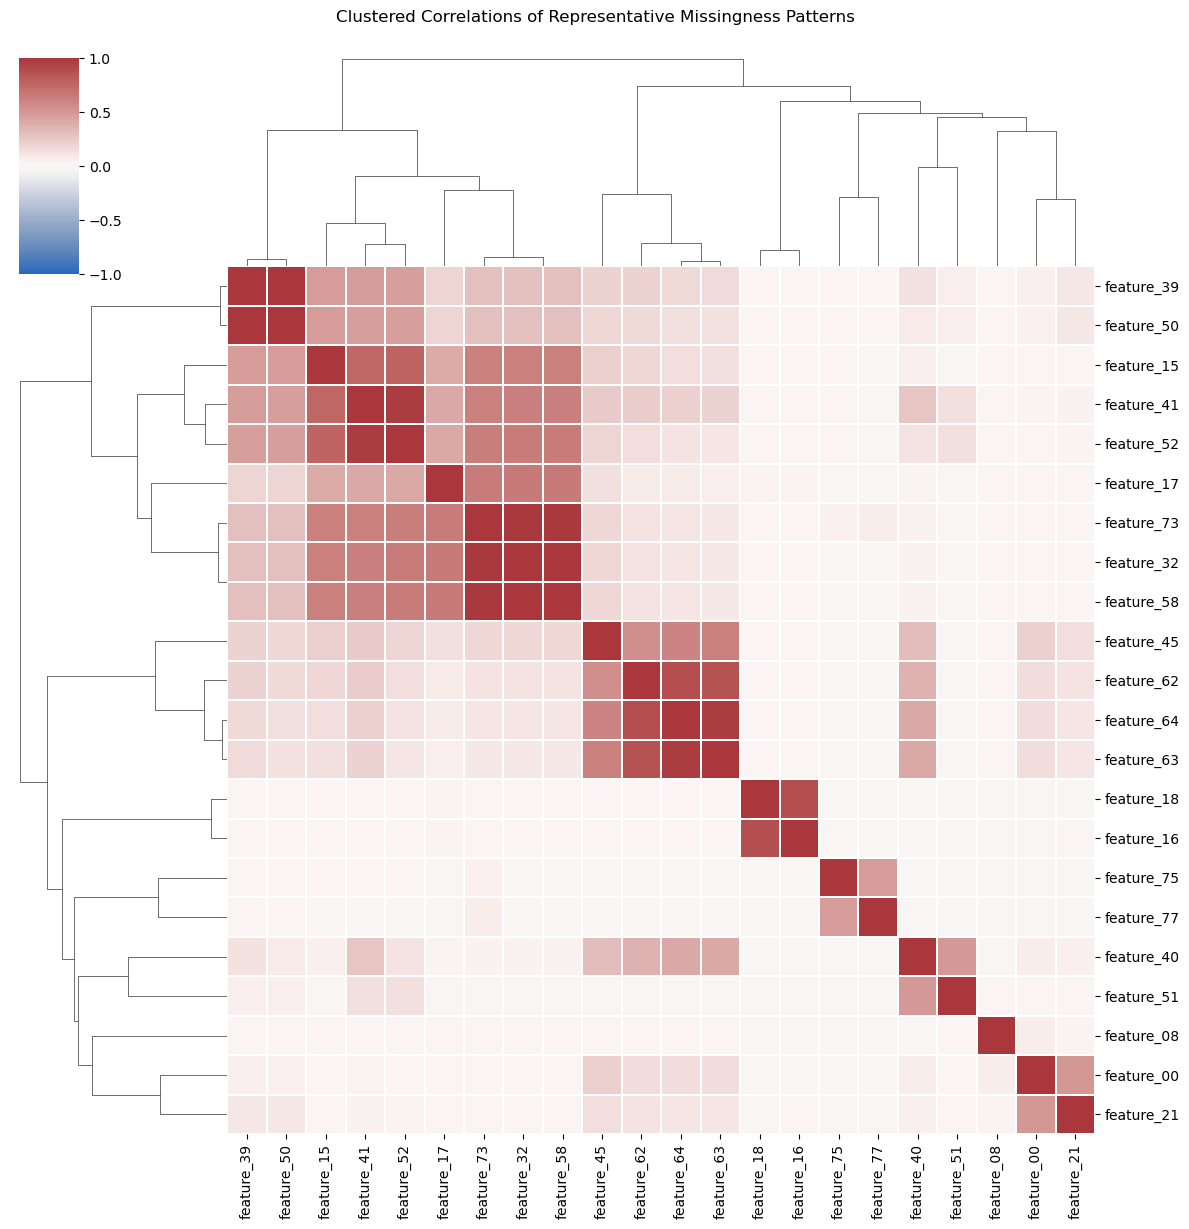

In [58]:
cluster_grid = sns.clustermap(
    representative_correlation,
    cmap="vlag",
    vmin=-1,
    vmax=1,
    center=0,
    figsize=(12, 12),
    linewidths=0.2
)

cluster_grid.fig.suptitle(
    "Clustered Correlations of Representative Missingness Patterns",
    y=1.02
)

plt.setp(
    cluster_grid.ax_heatmap.get_xticklabels(),
    rotation=90
)

plt.setp(
    cluster_grid.ax_heatmap.get_yticklabels(),
    rotation=0
)

plt.show()


### Clustered Missingness Pattern Interpretation
- Each exact co-missingness group was compressed to a single representative pattern.
- Several broader approximate missingness clusters were identified in the time-stratified sample.
- No strong inverse missingness relationships were observed.
- `feature_32` and `feature_58` were sample-perfect but not globally exact.
- Missingness similarity does not imply similar feature values or predictive power.

In [60]:
daily_symbol_parts = []

for file_path in partition_files:
    symbol_data = pd.read_parquet(
        file_path,
        columns=["date_id", "symbol_id"]
    )

    daily_stats = (
        symbol_data
        .groupby("date_id", as_index=False)
        .agg(
            rows=("symbol_id", "size"),
            unique_symbols=("symbol_id", "nunique")
        )
    )

    daily_stats["file"] = file_path.name

    daily_symbol_parts.append(daily_stats)

    daily_symbol_parts_df = (
        pd.concat(daily_symbol_parts, ignore_index=True)
        .sort_values("date_id").reset_index(drop=True)
    )

daily_symbol_coverage = pd.DataFrame(daily_symbol_parts_df)

print("Shape:", daily_symbol_coverage.shape)
display(daily_symbol_coverage.head())
display(daily_symbol_coverage.tail())
display(
    daily_symbol_coverage[
        ["rows", "unique_symbols"]
    ].describe()
)


Shape: (1699, 4)


,date_id,rows,unique_symbols,file
0,0,6792,8,part-0.parquet
1,1,10188,12,part-0.parquet
2,2,9339,11,part-0.parquet
3,3,10188,12,part-0.parquet
4,4,10188,12,part-0.parquet


,date_id,rows,unique_symbols,file
1694,1694,37752,39,part-9.parquet
1695,1695,37752,39,part-9.parquet
1696,1696,36784,38,part-9.parquet
1697,1697,37752,39,part-9.parquet
1698,1698,37752,39,part-9.parquet


,rows,unique_symbols
count,1699.000000,1699.000000
mean,27738.280165,29.653914
std,9407.318878,8.790873
min,3396.000000,4.000000
25%,16980.000000,20.000000
50%,30976.000000,32.000000
75%,36784.000000,38.000000
max,37752.000000,39.000000


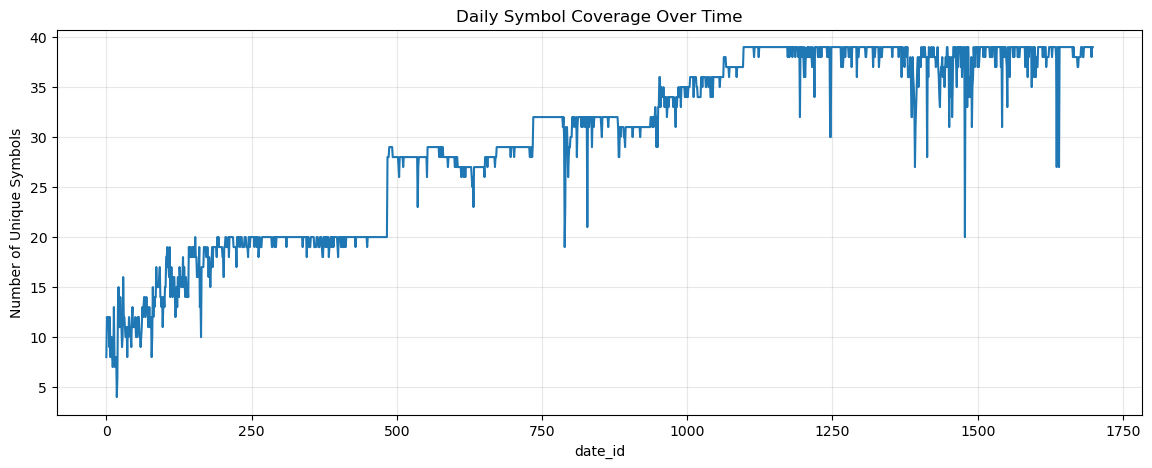

Number of change dates: 653


,date_id,unique_symbols,symbol_count_change
1,1,12,4.0
2,2,11,-1.0
3,3,12,1.0
5,5,9,-3.0
6,6,12,3.0
7,7,8,-4.0
8,8,10,2.0
10,10,8,-2.0
11,11,7,-1.0
12,12,8,1.0


,date_id,unique_symbols,symbol_count_change
1664,1664,38,-1.0
1665,1665,39,1.0
1666,1666,38,-1.0
1672,1672,37,-1.0
1674,1674,38,1.0
1678,1678,39,1.0
1681,1681,38,-1.0
1683,1683,39,1.0
1696,1696,38,-1.0
1697,1697,39,1.0


In [61]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    daily_symbol_coverage["date_id"],
    daily_symbol_coverage["unique_symbols"]
)

ax.set_title("Daily Symbol Coverage Over Time")
ax.set_xlabel("date_id")
ax.set_ylabel("Number of Unique Symbols")
ax.grid(alpha=0.3)
plt.show()

daily_symbol_coverage["symbol_count_change"] = (
    daily_symbol_coverage["unique_symbols"].diff()
)

symbol_count_changes = daily_symbol_coverage.loc[
    daily_symbol_coverage["symbol_count_change"].fillna(0).ne(0),
    ["date_id", "unique_symbols", "symbol_count_change"]
]

print("Number of change dates:", len(symbol_count_changes))
display(symbol_count_changes.head(10))
display(symbol_count_changes.tail(10))


In [62]:
symbol_summary_parts = []

for file_path in partition_files:
    symbol_data = pd.read_parquet(
        file_path,
        columns = ["date_id", "symbol_id"]
    )
    
    part_symbol_summary = (
        symbol_data
        .groupby("symbol_id", as_index=False)
        .agg(
            first_date=("date_id", "min"),
            last_date=("date_id", "max"),
            active_dates=("date_id", "nunique"),
            rows=("date_id", "size")
        )
    )

    symbol_summary_parts.append(part_symbol_summary)

combined_symbol_summaries = pd.concat(
    symbol_summary_parts,
    ignore_index = True
)

symbol_lifecycle = (
    combined_symbol_summaries
    .groupby("symbol_id", as_index=False)
    .agg(
        first_date=("first_date", "min"),
        last_date=("last_date", "max"),
        active_dates=("active_dates", "sum"),
        rows=("rows", "sum")
    )
)

symbol_lifecycle["calendar_span"] = (
    symbol_lifecycle["last_date"]
    - symbol_lifecycle["first_date"]
    + 1
)

symbol_lifecycle["coverage_percentage"] = (
    symbol_lifecycle["active_dates"]
    / symbol_lifecycle["calendar_span"]
    * 100
).round(2)

symbol_lifecycle = symbol_lifecycle.sort_values(
    ["first_date", "symbol_id"]
).reset_index(drop=True)

print("Shape:", symbol_lifecycle.shape)
display(symbol_lifecycle)


Shape: (39, 7)


,symbol_id,first_date,last_date,active_dates,rows,calendar_span,coverage_percentage
0,1,0,1698,1678,1543979,1699,98.76
1,7,0,1698,1680,1546272,1699,98.88
2,9,0,1698,1658,1525333,1699,97.59
3,10,0,1698,1643,1515692,1699,96.70
4,14,0,1698,1576,1458690,1699,92.76
5,16,0,1698,1672,1538290,1699,98.41
6,19,0,1698,1684,1550501,1699,99.12
7,33,0,1698,1637,1508099,1699,96.35
8,0,1,1698,1592,1468466,1698,93.76
9,2,1,1698,1606,1484398,1698,94.58


In [63]:
symbol_lifecycle["inactive_dates"] = (
    symbol_lifecycle["calendar_span"]
    - symbol_lifecycle["active_dates"]
)

dataset_last_date = daily_symbol_coverage["date_id"].max()

early_exit_symbols = symbol_lifecycle.loc[
    symbol_lifecycle["last_date"] < dataset_last_date
]

symbol_entry_summary = (
    symbol_lifecycle
    .groupby("first_date", as_index=False)
    .agg(
        symbols_added=("symbol_id", "size"),
        symbol_ids=("symbol_id", list)
    )
    .sort_values("first_date")
)

print("Total symbols:", len(symbol_lifecycle))
print("Early-exit symbols:", len(early_exit_symbols))

display(symbol_entry_summary)
display(
    symbol_lifecycle.sort_values(
        "coverage_percentage"
    ).head(10)
)


Total symbols: 39
Early-exit symbols: 0


,first_date,symbols_added,symbol_ids
0,0,8,"[1, 7, 9, 10, 14, 16, 19, 33]"
1,1,5,"[0, 2, 13, 15, 38]"
2,2,1,[3]
3,3,1,[12]
4,4,2,"[8, 17]"
5,8,1,[34]
6,13,1,[11]
7,20,1,[30]
8,484,8,"[5, 20, 21, 22, 25, 26, 29, 36]"
9,487,1,[23]


,symbol_id,first_date,last_date,active_dates,rows,calendar_span,coverage_percentage,inactive_dates
22,21,484,1698,994,940653,1215,81.81,221
11,15,1,1698,1469,1367847,1698,86.51,229
15,8,4,1698,1523,1404768,1695,89.85,172
29,27,713,1698,890,861520,986,90.26,96
37,18,1063,1698,578,559504,636,90.88,58
19,30,20,1698,1541,1429094,1679,91.78,138
20,5,484,1698,1116,1057321,1215,91.85,99
13,3,2,1698,1565,1446495,1697,92.22,132
4,14,0,1698,1576,1458690,1699,92.76,123
18,11,13,1698,1578,1460507,1686,93.59,108


In [64]:
daily_symbol_pair_parts = []

for file_path in partition_files:
    symbol_data = pd.read_parquet(
        file_path,
        columns = ["date_id", "symbol_id"]
    )
    
    daily_symbol_pairs = (
        symbol_data[
            ["date_id", "symbol_id"]
        ]
        .drop_duplicates()
    )

    daily_symbol_pair_parts.append(daily_symbol_pairs)

all_daily_symbol_pairs = pd.concat(
    daily_symbol_pair_parts,
    ignore_index=True
)

symbol_presence_matrix = (
    pd.crosstab(
        all_daily_symbol_pairs["symbol_id"],
        all_daily_symbol_pairs["date_id"]
    )
    > 0
)

symbol_order = (
    symbol_lifecycle
    .sort_values(["first_date", "symbol_id"])
    ["symbol_id"]
)

symbol_presence_matrix = symbol_presence_matrix.reindex(
    symbol_order
)

print("Shape:", symbol_presence_matrix.shape)
print(
    "Binary values only:",
    symbol_presence_matrix.isin([True, False]).all().all()
)


Shape: (39, 1699)
Binary values only: True


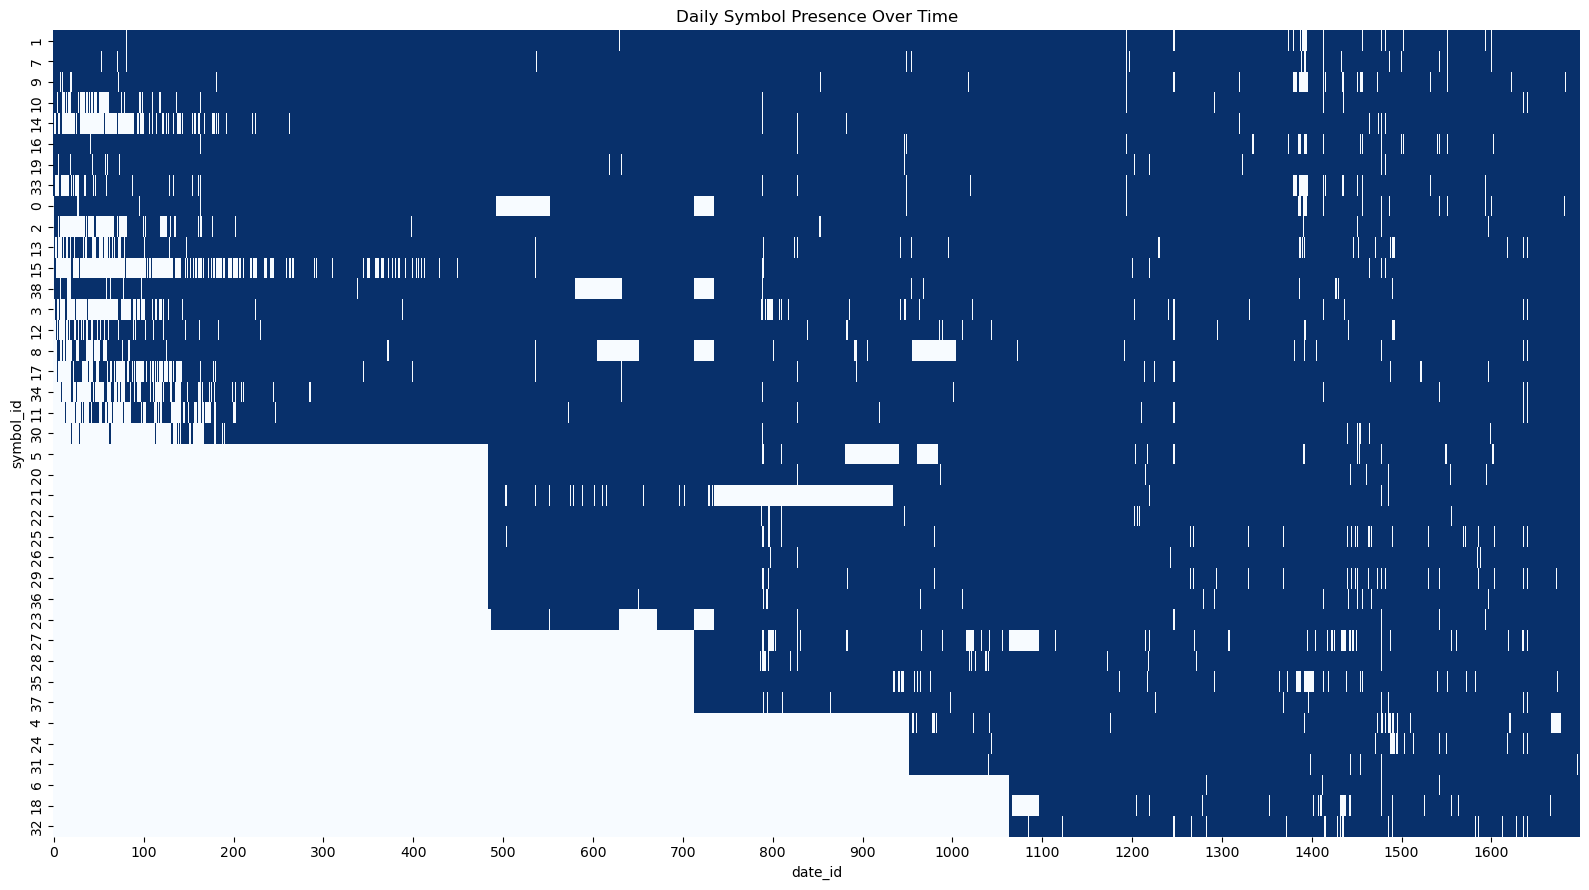

In [65]:
plt.figure(figsize=(16, 9))

sns.heatmap(
    symbol_presence_matrix,
    cmap="Blues",
    vmin=0,
    vmax=1,
    cbar=False,
    xticklabels=100,
    yticklabels=True
)

plt.title("Daily Symbol Presence Over Time")
plt.xlabel("date_id")
plt.ylabel("symbol_id")
plt.tight_layout()
plt.show()


### Symbol Coverage and Lifecycle Interpretation
- The dataset contains 39 symbols.
- Symbols enter the panel in 13 distinct cohorts.
- No symbol permanently exits before the final date.
- Symbol availability is intermittent after entry.
- The panel is expanding and unbalanced over time.
- Date-level presence does not guarantee complete intraday coverage.

In [67]:
daily_time_parts = []

for file_path in partition_files:
    time_data = pd.read_parquet(
        file_path,
        columns=["date_id", "time_id"]
    )

    daily_time_stats = (
        time_data
        .groupby("date_id", as_index=False)
        .agg(
            min_time_id=("time_id", "min"),
            max_time_id=("time_id", "max"),
            unique_time_ids=("time_id", "nunique")
        )
    )

    daily_time_stats["expected_time_ids"] = (
        daily_time_stats["max_time_id"]
        - daily_time_stats["min_time_id"]
        + 1
    )

    daily_time_stats["missing_time_ids"] = (
        daily_time_stats["expected_time_ids"]
        - daily_time_stats["unique_time_ids"]
    )

    daily_time_parts.append(daily_time_stats)

daily_time_grid = pd.concat(daily_time_parts, ignore_index = True)

print("Shape:", daily_time_grid.shape)

display(daily_time_grid.head())
display(daily_time_grid.tail())

display(
    daily_time_grid[
        [
            "min_time_id",
            "max_time_id",
            "unique_time_ids",
            "missing_time_ids"
        ]
    ].describe()
)


Shape: (1699, 6)


,date_id,min_time_id,max_time_id,unique_time_ids,expected_time_ids,missing_time_ids
0,0,0,848,849,849,0
1,1,0,848,849,849,0
2,2,0,848,849,849,0
3,3,0,848,849,849,0
4,4,0,848,849,849,0


,date_id,min_time_id,max_time_id,unique_time_ids,expected_time_ids,missing_time_ids
1694,1694,0,967,968,968,0
1695,1695,0,967,968,968,0
1696,1696,0,967,968,968,0
1697,1697,0,967,968,968,0
1698,1698,0,967,968,968,0


,min_time_id,max_time_id,unique_time_ids,missing_time_ids
count,1699.0,1699.000000,1699.000000,1699.0
mean,0.0,919.582107,920.582107,0.0
std,0.0,58.277540,58.277540,0.0
min,0.0,848.000000,849.000000,0.0
25%,0.0,848.000000,849.000000,0.0
50%,0.0,967.000000,968.000000,0.0
75%,0.0,967.000000,968.000000,0.0
max,0.0,967.000000,968.000000,0.0


In [68]:
daily_time_grid["time_grid_change"] = (
    daily_time_grid["unique_time_ids"].diff()
)

time_grid_changes = daily_time_grid.loc[
    daily_time_grid["time_grid_change"].fillna(0).ne(0),
    [
        "date_id",
        "min_time_id",
        "max_time_id",
        "unique_time_ids",
        "time_grid_change"
    ]
]

time_grid_summary = (
    daily_time_grid
    .groupby(
        [
            "min_time_id",
            "max_time_id",
            "unique_time_ids",
            "missing_time_ids"
        ],
        as_index=False
    )
    .agg(
        first_date=("date_id", "min"),
        last_date=("date_id", "max"),
        number_of_dates=("date_id", "size")
    )
)

print("Number of grid changes:", len(time_grid_changes))
display(time_grid_changes)
display(time_grid_summary)


Number of grid changes: 1


,date_id,min_time_id,max_time_id,unique_time_ids,time_grid_change
677,677,0,967,968,119.0


,min_time_id,max_time_id,unique_time_ids,missing_time_ids,first_date,last_date,number_of_dates
0,0,848,849,0,0,676,677
1,0,967,968,0,677,1698,1022


In [69]:
daily_symbol_parts = []

for file_path in partition_files:
    time_data = pd.read_parquet(
        file_path,
        columns = ["date_id", "time_id", "symbol_id"]
    )

    symbol_date_stats = (
        time_data
        .groupby(
            ["date_id", "symbol_id"],
            as_index=False
        )
        .agg(
            rows=("time_id", "size"),
            observed_time_ids=("time_id", "nunique"),
            min_time_id=("time_id", "min"),
            max_time_id=("time_id", "max")
        )
    )

    daily_symbol_parts.append(symbol_date_stats)

symbol_date_time_stats = pd.concat(daily_symbol_parts, ignore_index = True)

symbol_date_time_stats = symbol_date_time_stats.merge(
    daily_time_grid[
        ["date_id", "expected_time_ids"]
    ],
    on="date_id",
    how="left"
)

symbol_date_time_stats["missing_time_ids"] = (
    symbol_date_time_stats["expected_time_ids"]
    - symbol_date_time_stats["observed_time_ids"]
)

symbol_date_time_stats["coverage_percentage"] = (
    symbol_date_time_stats["observed_time_ids"]
    / symbol_date_time_stats["expected_time_ids"]
    * 100
).round(2)

symbol_date_time_stats["complete_grid"] = (
    symbol_date_time_stats["missing_time_ids"] == 0
)

print("Symbol-date pairs:", len(symbol_date_time_stats))
print(
    "Complete pairs:",
    symbol_date_time_stats["complete_grid"].sum()
)
print(
    "Incomplete pairs:",
    (~symbol_date_time_stats["complete_grid"]).sum()
)
print(
    "Complete percentage:",
    symbol_date_time_stats["complete_grid"].mean() * 100
)

display(
    symbol_date_time_stats
    .sort_values(
        ["coverage_percentage", "date_id", "symbol_id"]
    )
    .head(10)
)


Symbol-date pairs: 50382
Complete pairs: 50382
Incomplete pairs: 0
Complete percentage: 100.0


,date_id,symbol_id,rows,observed_time_ids,min_time_id,max_time_id,expected_time_ids,missing_time_ids,coverage_percentage,complete_grid
0,0,1,849,849,0,848,849,0,100.0,True
1,0,7,849,849,0,848,849,0,100.0,True
2,0,9,849,849,0,848,849,0,100.0,True
3,0,10,849,849,0,848,849,0,100.0,True
4,0,14,849,849,0,848,849,0,100.0,True
5,0,16,849,849,0,848,849,0,100.0,True
6,0,19,849,849,0,848,849,0,100.0,True
7,0,33,849,849,0,848,849,0,100.0,True
8,1,0,849,849,0,848,849,0,100.0,True
9,1,1,849,849,0,848,849,0,100.0,True


### Intraday Time Grid Interpretation
- The global intraday grid is contiguous on every date.
- The grid contains 849 time steps from date_id 0 to 676.
- It expands to 968 time steps beginning at date_id 677.
- All 50,382 observed symbol-date pairs have complete intraday coverage.
- Symbol absence occurs at the whole-date level rather than through partial intraday coverage.
- The panel is unbalanced across dates and symbols but rectangular within every active symbol-date.

In [71]:
weight_audit = []

for file_path in partition_files:
    weight_data = pd.read_parquet(
        file_path,
        columns = ["weight"]
    )

    weights = weight_data["weight"]

    finite_weights = weights[np.isfinite(weights)]

    weight_stats = {
        "file" : file_path.name,
        "rows" : len(weights),
        "null_count" : weights.isna().sum(),
        "infinite_count" : np.isinf(weights).sum(), 
        "negative_count" : finite_weights.lt(0).sum(),
        "zero_count" : finite_weights.eq(0).sum(),
        "positive_count" : finite_weights.gt(0).sum(),
        "min_weight" : finite_weights.min(),
        "max_weight" : finite_weights.max(),
        "mean_weight" : finite_weights.mean(),
        "total_weight" : finite_weights.sum()
    }

    weight_audit.append(weight_stats)

weight_audit_df = pd.DataFrame(weight_audit)

display(
    weight_audit_df[
        [
            "rows",
            "null_count",
            "infinite_count",
            "negative_count",
            "zero_count",
            "positive_count"
        ]
    ].sum()
)

display(
    weight_audit_df[
        [
            "file",
            "min_weight",
            "max_weight",
            "mean_weight",
            "total_weight"
        ]
    ].round(4)
)


rows              47127338
null_count               0
infinite_count           0
negative_count           0
zero_count               0
positive_count    47127338
dtype: int64

,file,min_weight,max_weight,mean_weight,total_weight
0,part-0.parquet,0.4406,6.0120,1.9733,3836472.5
1,part-1.parquet,0.4451,8.1096,1.8661,5232947.5
2,part-2.parquet,0.2828,7.1891,1.7173,5215326.0
3,part-3.parquet,0.1500,6.2605,1.5343,6163063.5
4,part-4.parquet,0.2061,7.6194,1.6526,8300868.5
5,part-5.parquet,0.4091,10.2404,2.1112,11291321.0
6,part-6.parquet,0.2699,7.0521,1.7400,10794583.0
7,part-7.parquet,0.3540,7.3018,1.9977,12656537.0
8,part-8.parquet,0.3948,9.0970,2.6697,16392022.0
9,part-9.parquet,0.5325,7.9023,2.3614,14816685.0


### Sample Weight Quality Interpretation
- All 47,127,338 sample weights are finite and strictly positive.
- No missing, infinite, negative, or zero weights were identified.
- The weight distribution changes across chronological partitions.
- Total partition weight is affected by both partition size and the weight distribution.
- The provided weights must be retained in the final evaluation metric.
- Any decision about using weight as a model input must be tested separately with chronological validation.

In [73]:
numeric_columns = [
    column_name
    for column_name in reference_schema.names
    if (
        column_name.startswith("feature_")
        or column_name.startswith("responder_")
    )
]

print("Columns to scan:", len(numeric_columns))


Columns to scan: 88


In [74]:
positive_inf_counts = pd.Series(
    0,
    index=numeric_columns,
    dtype="int64"
)

negative_inf_counts = pd.Series(
    0,
    index=numeric_columns,
    dtype="int64"
)

for file_path in partition_files:
    parquet_file = pq.ParquetFile(file_path)
    
    for batch in parquet_file.iter_batches(
        batch_size=100_000,
        columns=numeric_columns
    ):
        batch_df = batch.to_pandas()
        batch_values = batch_df.to_numpy()

        positive_inf_counts += pd.Series(
            np.isposinf(batch_values).sum(axis=0),
            index=numeric_columns
        )

        negative_inf_counts += pd.Series(
            np.isneginf(batch_values).sum(axis=0),
            index=numeric_columns
        )
    print("Finished:", file_path.name)

infinite_audit_df = pd.DataFrame({
    "column": numeric_columns,
    "positive_inf_count": positive_inf_counts.values,
    "negative_inf_count": negative_inf_counts.values
})

infinite_audit_df["total_inf_count"] = (
    infinite_audit_df["positive_inf_count"]
    + infinite_audit_df["negative_inf_count"]
)

columns_with_infinity = infinite_audit_df.loc[
    infinite_audit_df["total_inf_count"] > 0
]

print("Scanned columns:", len(infinite_audit_df))
print("Columns with infinity:", len(columns_with_infinity))
print(
    "Total infinite values:",
    infinite_audit_df["total_inf_count"].sum()
)

display(columns_with_infinity)


Finished: part-0.parquet
Finished: part-1.parquet
Finished: part-2.parquet
Finished: part-3.parquet
Finished: part-4.parquet
Finished: part-5.parquet
Finished: part-6.parquet
Finished: part-7.parquet
Finished: part-8.parquet
Finished: part-9.parquet
Scanned columns: 88
Columns with infinity: 0
Total infinite values: 0


,column,positive_inf_count,negative_inf_count,total_inf_count


In [75]:
global_min = pd.Series(
    np.inf,
    index=numeric_columns
)

global_max = pd.Series(
    -np.inf,
    index=numeric_columns
)

for file_path in partition_files:
    parquet_file = pq.ParquetFile(file_path)

    for batch in parquet_file.iter_batches(
        batch_size = 100000,
        columns = numeric_columns
    ):
        batch_df = batch.to_pandas()
        batch_values = batch_df.to_numpy()

        batch_min = batch_df.min()
        batch_max = batch_df.max()

        global_min = pd.Series(
            np.fmin(
                global_min.to_numpy(),
                batch_min.to_numpy()
            ),
            index=numeric_columns
        )

        global_max = pd.Series(
            np.fmax(
                global_max.to_numpy(),
                batch_max.to_numpy()
            ),
            index=numeric_columns
        )
    print("Finished:", file_path.name)

range_audit_df = pd.DataFrame({
    "column": numeric_columns,
    "global_min": global_min.values,
    "global_max": global_max.values
})

range_audit_df["is_constant"] = (
    range_audit_df["global_min"]
    == range_audit_df["global_max"]
)

constant_columns = range_audit_df.loc[
    range_audit_df["is_constant"]
]

print("Scanned columns:", len(range_audit_df))
print("Constant columns:", len(constant_columns))
display(constant_columns)


Finished: part-0.parquet
Finished: part-1.parquet
Finished: part-2.parquet
Finished: part-3.parquet
Finished: part-4.parquet
Finished: part-5.parquet
Finished: part-6.parquet
Finished: part-7.parquet
Finished: part-8.parquet
Finished: part-9.parquet
Scanned columns: 88
Constant columns: 0


,column,global_min,global_max,is_constant


### Numeric Validity and Constant-Column Check
- All 79 features and 9 responders were scanned across the full training dataset.
- No positive or negative infinite values were identified.
- No globally constant feature or responder columns were identified.
- Constant missingness indicators in a sample do not imply constant feature values.
- Missing values remain a separate data-quality issue and must be handled with time-aware methods.

In [77]:
responder_null_audit = []

responder_columns = [
    f"responder_{i}"
    for i in range(9)
]

for file_path in partition_files:
    parquet_file = pq.ParquetFile(file_path)

    file_null_counts = pd.Series(
        0,
        index=responder_columns,
        dtype="int64"
    )

    for batch in parquet_file.iter_batches(
        batch_size=100_000,
        columns=responder_columns
    ):
        batch_df = batch.to_pandas()

        file_null_counts += (
            batch_df.isna().sum()
        )
        
    for responder in responder_columns:
        temp = {
            "file" : file_path.name,
            "responder" : responder,
            "rows" : parquet_file.metadata.num_rows,
            "null_count" : file_null_counts[responder],
        }
        temp["null_percentage"] = round(
            temp["null_count"]/temp["rows"]*100,
            2
        )

        responder_null_audit.append(temp)
    print("Finished:", file_path.name)

responder_null_audit_df = pd.DataFrame(responder_null_audit)

responder_null_summary = (
    responder_null_audit_df
    .groupby("responder", as_index=False)
    .agg(
        total_rows=("rows", "sum"),
        null_count=("null_count", "sum")
    )
)

responder_null_summary["null_percentage"] = (
    responder_null_summary["null_count"]
    / responder_null_summary["total_rows"]
    * 100
)

display(responder_null_summary)

display(
    responder_null_audit_df.loc[
        responder_null_audit_df["null_count"] > 0
    ]
)

display(
    responder_null_summary.loc[
        responder_null_summary["responder"]
        == "responder_6"
    ]
)


Finished: part-0.parquet
Finished: part-1.parquet
Finished: part-2.parquet
Finished: part-3.parquet
Finished: part-4.parquet
Finished: part-5.parquet
Finished: part-6.parquet
Finished: part-7.parquet
Finished: part-8.parquet
Finished: part-9.parquet


,responder,total_rows,null_count,null_percentage
0,responder_0,47127338,0,0.0
1,responder_1,47127338,0,0.0
2,responder_2,47127338,0,0.0
3,responder_3,47127338,0,0.0
4,responder_4,47127338,0,0.0
5,responder_5,47127338,0,0.0
6,responder_6,47127338,0,0.0
7,responder_7,47127338,0,0.0
8,responder_8,47127338,0,0.0


,file,responder,rows,null_count,null_percentage


,responder,total_rows,null_count,null_percentage
6,responder_6,47127338,0,0.0


### Responder Completeness and Target Integrity
- All nine responders are fully observed across all 47,127,338 training rows.
- The primary target, `responder_6`, contains no missing or infinite values.
- No training rows need to be removed because of missing target labels.
- The responder columns are outcomes and must not be used as contemporaneous model features.
- Lagged responder information may only be used when it is explicitly available at prediction time.

## Phase 2 Data Treatment Plan

| Issue | Evidence | Initial Treatment | Validation Requirement |
|---|---|---|---|
| Feature missingness | 47/79 features contain missing values；maximum rate 17.9% | Do not drop features based on missingness alone | Evaluate every dropping decision across chronological folds |
| Structural missingness | Some features are unavailable during early periods and become available abruptly | Keep NaN, make structural missing indicators as candidate features | Compare models with and without structural missingness indicators |
|Exact co-missingness groups| 14 groups, 110 full-data checks, zero mismatches| Consider choosing a representative missing indicator for each group without deleting feature values | Validate representative indicators out of sample; do not infer value redundancy from shared masks |
| Imputation | Different model families have different missing-value requirements | Preserve NaNs for models with native missing-value handling; otherwise use fold-local imputation only | Compare native handling with fold-local imputation across chronological folds; never use future-fitted statistics or backward filling |
| Numeric validity | No infinities and no globally constant columns| No need for infinity replacement or constant column removal as this stage| Repeat finite-value assertions before every modeling experiment |
| Target and responders| All nine responders are fully observed across the training dataset, no missingness in `responder_6` | Do not remove training rows because of missing target labels; exclude contemporaneous responders from model inputs| Exclude contemporaneous responders and verify the availability of any lagged responder inputs |
| Sample weight | All sample weights are finite positive numbers, distributions change chronologically | Use in the evaluation metric; validate separately as a model input | Use the official weighted metric in every validation fold |
| Panel Structure | 39 symbols、13 entry cohorts、temporary whole-date absence | Use chronological validation instead of random row split | Use chronological splits and monitor performance across symbol-entry cohorts |
| Intraday grid | At date_id 677, the intraday grid expands from 849 to 968 time steps; all active symbol-date pairs have complete intraday coverage | Record this structural change, test these two periods separately in the coming stability analysis | Compare model stability before and after the grid change at date_id 677 |

**General rule:** No feature will be dropped, imputed, or converted into a missingness indicator without evidence from chronological out-of-sample validation

In [80]:
target_partition_stats = []

for file_path in partition_files:
    target_data = pd.read_parquet(
        file_path,
        columns=["responder_6", "weight"]
    )

    target = target_data["responder_6"]
    weights = target_data["weight"]

    # Calculate multiple quantiles together
    quantiles = target.quantile(
        [0.01, 0.50, 0.99]
    )

    # Weighted mean
    weighted_mean = np.average(
        target,
        weights=weights
    )

    # Weighted population variance and standard deviation
    weighted_variance = np.average(
        (target - weighted_mean) ** 2,
        weights=weights
    )

    weighted_std = np.sqrt(
        weighted_variance
    )

    target_stats = {
        "file": file_path.name,
        "rows": len(target),
        "mean": target.mean(),
        "weighted_mean": weighted_mean,
        "std": target.std(ddof=0),
        "weighted_std": weighted_std,
        "minimum": target.min(),
        "p01": quantiles.loc[0.01],
        "median": quantiles.loc[0.50],
        "p99": quantiles.loc[0.99],
        "maximum": target.max()
    }

    target_partition_stats.append(
        target_stats
    )

    print("Finished:", file_path.name)


target_partition_stats_df = pd.DataFrame(
    target_partition_stats
)

display(
    target_partition_stats_df.round(6)
)


# Row-count validation
total_rows = target_partition_stats_df[
    "rows"
].sum()

expected_rows = inventory_df[
    "rows"
].sum()

print("Total rows:", total_rows)
print("Expected rows:", expected_rows)
print(
    "Row counts match:",
    total_rows == expected_rows
)


# Quantile-order validation
quantile_order_valid = (
    (
        target_partition_stats_df["minimum"]
        <= target_partition_stats_df["p01"]
    )
    & (
        target_partition_stats_df["p01"]
        <= target_partition_stats_df["median"]
    )
    & (
        target_partition_stats_df["median"]
        <= target_partition_stats_df["p99"]
    )
    & (
        target_partition_stats_df["p99"]
        <= target_partition_stats_df["maximum"]
    )
).all()

print(
    "Quantile order valid:",
    quantile_order_valid
)


Finished: part-0.parquet
Finished: part-1.parquet
Finished: part-2.parquet
Finished: part-3.parquet
Finished: part-4.parquet
Finished: part-5.parquet
Finished: part-6.parquet
Finished: part-7.parquet
Finished: part-8.parquet
Finished: part-9.parquet


,file,rows,mean,weighted_mean,std,weighted_std,minimum,p01,median,p99,maximum
0,part-0.parquet,1944210,0.001488,0.001563,0.869665,0.824535,-5.0,-2.505365,-0.009597,2.772543,5.0
1,part-1.parquet,2804247,-0.006968,-0.004263,0.899168,0.868631,-5.0,-2.579730,-0.016243,2.737287,5.0
2,part-2.parquet,3036873,-0.008083,-0.009730,0.937845,0.902379,-5.0,-2.690433,-0.021270,2.909957,5.0
3,part-3.parquet,4016784,0.002036,0.000341,1.005293,0.942850,-5.0,-2.920676,-0.012216,3.176685,5.0
4,part-4.parquet,5022952,0.000059,-0.001625,0.939689,0.902980,-5.0,-2.781318,-0.019015,3.171290,5.0
5,part-5.parquet,5348200,-0.006323,-0.006557,0.896838,0.856119,-5.0,-2.466152,-0.037942,3.183256,5.0
6,part-6.parquet,6203912,-0.004675,-0.004032,0.878840,0.860548,-5.0,-2.475715,-0.025137,2.867047,5.0
7,part-7.parquet,6335560,0.001600,-0.000379,0.825569,0.811467,-5.0,-2.287204,-0.022585,2.787110,5.0
8,part-8.parquet,6140024,0.001341,0.000730,0.861142,0.830321,-5.0,-2.332129,-0.033067,2.957567,5.0
9,part-9.parquet,6274576,-0.003780,-0.005710,0.809749,0.796211,-5.0,-2.155844,-0.034434,2.699788,5.0


Total rows: 47127338
Expected rows: 47127338
Row counts match: True
Quantile order valid: True


### Target Distribution by Chronological Partition

- The unweighted and weighted means of `responder_6` remain close to zero across all chronological partitions.
- The median is slightly negative in every partition, while the upper tail is generally longer than the lower tail.
- Target dispersion changes over time: the unweighted standard deviation peaks in `part-3.parquet` and is lowest in `part-9.parquet`.
- The weighted standard deviation is consistently lower than the unweighted standard deviation, indicating that sample weights place relatively more emphasis on lower-variance observations.
- Both the 1st and 99th percentiles vary across partitions, providing evidence of chronological distribution drift.
- Every partition has observed minimum and maximum values of exactly -5 and 5. This suggests possible target clipping, which should be verified by measuring the frequency of observations at both boundaries.
- These distributional changes motivate chronological validation, but they do not by themselves demonstrate target predictability.

In [82]:
boundary_stats_list = []

for file_path in partition_files:
    target_data = pd.read_parquet(
        file_path,
        columns=["responder_6"]
    )

    target = target_data["responder_6"]

    negative_boundary_count = target.eq(-5.0).sum()
    positive_boundary_count = target.eq(5.0).sum()
    rows = len(target)

    total_boundary_count = (
        negative_boundary_count
        + positive_boundary_count
    )

    boundary_percentage = (
        total_boundary_count
        / rows
        * 100
    )

    boundary_stats = {
        "file": file_path.name,
        "rows": rows,
        "negative_boundary_count": negative_boundary_count,
        "positive_boundary_count": positive_boundary_count,
        "total_boundary_count": total_boundary_count,
        "boundary_percentage": boundary_percentage
    }

    boundary_stats_list.append(
        boundary_stats
    )

boundary_stats_df = pd.DataFrame(
    boundary_stats_list
)

display(
    boundary_stats_df.round(
        {"boundary_percentage": 6}
    )
)

print(
    "Total rows:",
    boundary_stats_df["rows"].sum()
)

print(
    "All boundary counts valid:",
    (
        boundary_stats_df["total_boundary_count"]
        <= boundary_stats_df["rows"]
    ).all()
)


,file,rows,negative_boundary_count,positive_boundary_count,total_boundary_count,boundary_percentage
0,part-0.parquet,1944210,1921,3515,5436,0.279599
1,part-1.parquet,2804247,3000,4483,7483,0.266845
2,part-2.parquet,3036873,4135,6066,10201,0.335905
3,part-3.parquet,4016784,6404,9510,15914,0.396188
4,part-4.parquet,5022952,9476,15406,24882,0.495366
5,part-5.parquet,5348200,6045,17341,23386,0.437269
6,part-6.parquet,6203912,5918,12165,18083,0.291477
7,part-7.parquet,6335560,4912,11899,16811,0.265344
8,part-8.parquet,6140024,5387,15287,20674,0.336709
9,part-9.parquet,6274576,2337,11544,13881,0.221226


Total rows: 47127338
All boundary counts valid: True


### Target Boundary Analysis

The target is bounded within `[-5, 5]`, with 156,751 observations located exactly at either boundary, representing approximately 0.333% of all training rows. Boundary accumulation occurs in every chronological partition, providing strong evidence that `responder_6` is clipped.

The clipping is asymmetric: 107,216 observations are located at `+5`, compared with 49,535 at `-5`. The boundary rate also changes over time, reaching approximately 0.495% in `part-4.parquet` and declining to approximately 0.221% in `part-9.parquet`.

Therefore, near-zero target means should not be interpreted as evidence of a symmetric or temporally stable target distribution.

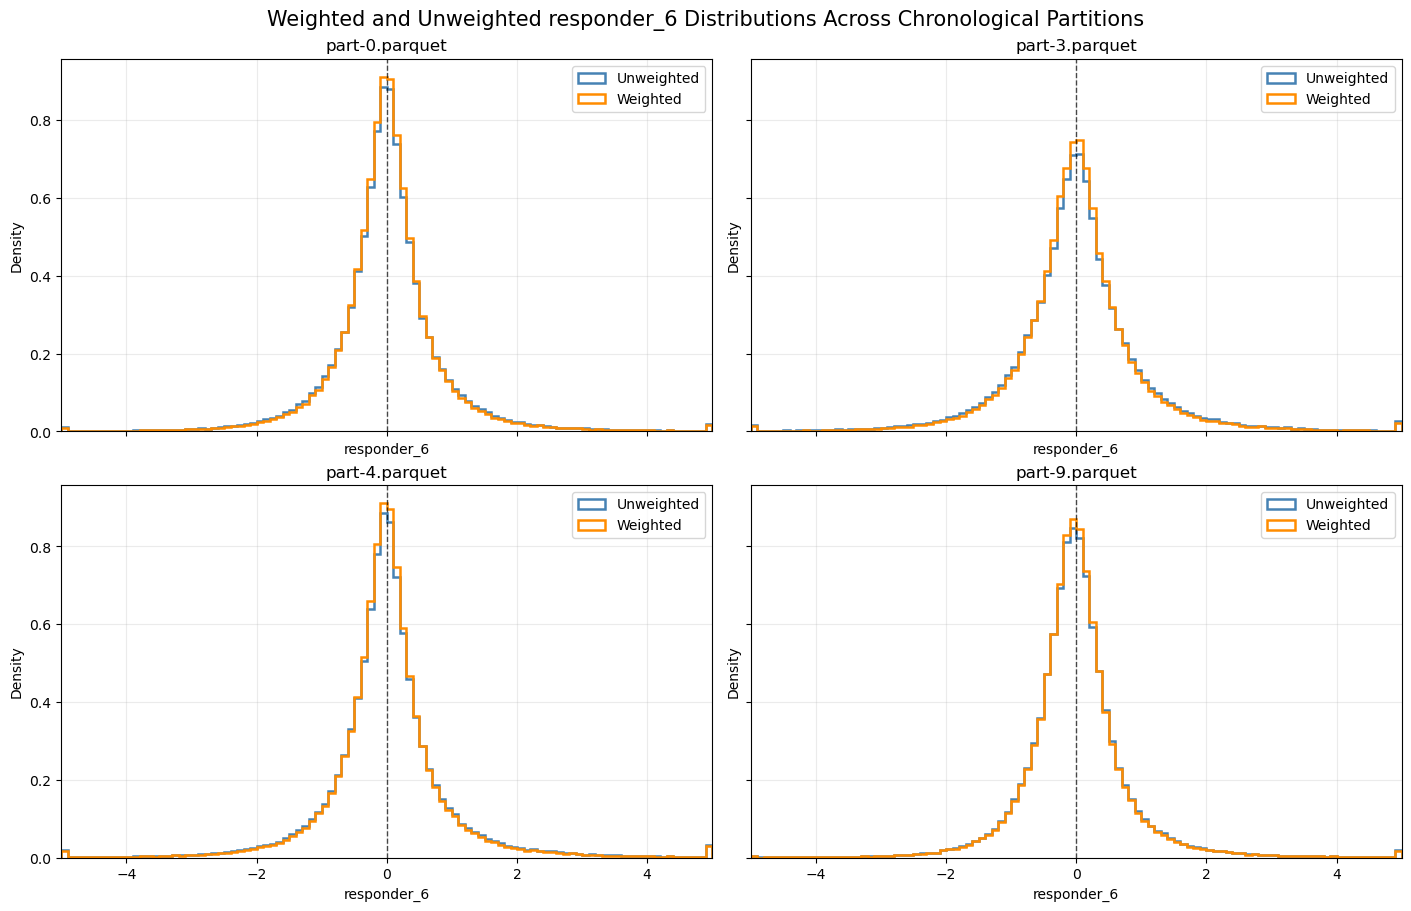

,file,sampled_rows,sample_mean,weighted_sample_mean,sample_std,negative_boundary_count,positive_boundary_count
0,part-0.parquet,200000,0.000037,0.001248,0.872812,196,338
1,part-3.parquet,200000,0.005912,0.003173,1.005457,285,510
2,part-4.parquet,200000,-0.001463,-0.003154,0.942921,376,602
3,part-9.parquet,200000,-0.004484,-0.006039,0.815258,67,357


Number of plotted partitions: 4
Total sampled rows: 800000


In [84]:
# Phase 3.1 — Target distribution across selected chronological partitions

selected_partition_indices = [0, 3, 4, 9]
sample_size_per_partition = 200_000
random_seed = 42

common_bins = np.linspace(
    -5.0,
    5.0,
    101
)

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 9),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

plot_sample_stats = []

for axis, partition_index in zip(
    axes.flat,
    selected_partition_indices
):
    file_path = partition_files[
        partition_index
    ]

    target_data = pd.read_parquet(
        file_path,
        columns=[
            "responder_6",
            "weight"
        ]
    )

    current_sample_size = min(
        sample_size_per_partition,
        len(target_data)
    )

    target_sample = target_data.sample(
        n=current_sample_size,
        random_state=(
            random_seed
            + partition_index
        )
    )

    target_values = target_sample[
        "responder_6"
    ]

    sample_weights = target_sample[
        "weight"
    ]

    # Sample validations
    assert target_values.notna().all()
    assert np.isfinite(target_values).all()
    assert np.isfinite(sample_weights).all()
    assert sample_weights.gt(0).all()
    assert target_values.between(
        -5.0,
        5.0
    ).all()

    # Unweighted distribution
    axis.hist(
        target_values,
        bins=common_bins,
        density=True,
        histtype="step",
        linewidth=1.8,
        color="steelblue",
        label="Unweighted"
    )

    # Weighted distribution
    axis.hist(
        target_values,
        bins=common_bins,
        weights=sample_weights,
        density=True,
        histtype="step",
        linewidth=1.8,
        color="darkorange",
        label="Weighted"
    )

    axis.axvline(
        x=0.0,
        color="black",
        linestyle="--",
        linewidth=1.0,
        alpha=0.7
    )

    axis.set_title(
        file_path.name
    )

    axis.set_xlabel(
        "responder_6"
    )

    axis.set_ylabel(
        "Density"
    )

    axis.set_xlim(
        -5.0,
        5.0
    )

    axis.grid(
        alpha=0.25
    )

    axis.legend()

    weighted_sample_mean = np.average(
        target_values,
        weights=sample_weights
    )

    plot_sample_stats.append(
        {
            "file": file_path.name,
            "sampled_rows": current_sample_size,
            "sample_mean": target_values.mean(),
            "weighted_sample_mean": weighted_sample_mean,
            "sample_std": target_values.std(ddof=0),
            "negative_boundary_count": target_values.eq(-5.0).sum(),
            "positive_boundary_count": target_values.eq(5.0).sum()
        }
    )

fig.suptitle(
    "Weighted and Unweighted responder_6 Distributions "
    "Across Chronological Partitions",
    fontsize=15
)

plt.show()


plot_sample_stats_df = pd.DataFrame(
    plot_sample_stats
)

display(
    plot_sample_stats_df.round(6)
)

print(
    "Number of plotted partitions:",
    len(plot_sample_stats_df)
)

print(
    "Total sampled rows:",
    plot_sample_stats_df[
        "sampled_rows"
    ].sum()
)


### Weighted and Unweighted Target Distributions

The distribution of `responder_6` is sharply concentrated around zero and has heavy tails, with visible accumulation at the clipping boundaries of `-5` and `+5`.

The distribution changes across chronological partitions. Among the selected periods, `part-3.parquet` has the greatest dispersion, while `part-9.parquet` has the smallest. The sample standard deviations closely match the corresponding full-partition estimates, indicating that the stratified plotting samples adequately represent the overall distribution shapes.

Weighted and unweighted distributions remain broadly similar. However, the weighted curves are generally slightly more concentrated around zero, consistent with the lower weighted standard deviations observed in the full-data statistics.

The positive clipping boundary contains more observations than the negative boundary in every selected partition. Therefore, the target is centered near zero but is neither perfectly symmetric nor temporally stationary. These findings reinforce the need for weighted chronological validation.

## 3.2 Proportional Time-Stratified EDA Sample

The remaining EDA uses a reproducible 500,000-row sample drawn from all ten chronological partitions. Sample sizes are allocated in proportion to the full partition row counts, so pooled estimates approximately preserve the row-level temporal composition of the training data. Random seeds are fixed separately by partition.

The sampler scans Parquet files in batches and materializes only selected rows. The complete reproducible implementation is stored in `scripts/phase3_eda.py`, and generated tables and figures are stored in `artifacts/phase3`.

This sample is used only for descriptive contemporaneous EDA. It is not a train-validation split and provides no evidence of deployable out-of-sample predictiveness.


In [87]:
# Load the reproducible Phase 3 EDA artifacts
import json
from IPython.display import Image, display

phase3_artifact_dir = project_root / "artifacts" / "phase3"

phase3_sample_inventory = pd.read_csv(
    phase3_artifact_dir / "sample_inventory.csv"
)

with open(
    phase3_artifact_dir / "validation_summary.json",
    encoding="utf-8"
) as validation_file:
    phase3_validation = json.load(validation_file)

display(
    phase3_sample_inventory.round(
        {"sampling_percentage": 6}
    )
)

print("Sample rows:", phase3_validation["sample_rows"])
print("Sample partitions:", phase3_validation["sample_partitions"])
print(
    "Feature strict-upper pairs:",
    phase3_validation["feature_pair_count"]
)


,file,partition_rows,requested_sample_rows,partition_id,sampled_rows,sample_min_date,sample_max_date,sampling_percentage
0,part-0.parquet,1944210,20627,0,20627,0,169,1.060945
1,part-1.parquet,2804247,29752,1,29752,170,339,1.060962
2,part-2.parquet,3036873,32220,2,32220,340,509,1.060960
3,part-3.parquet,4016784,42616,3,42616,510,679,1.060948
4,part-4.parquet,5022952,53291,4,53291,680,849,1.060950
5,part-5.parquet,5348200,56742,5,56742,850,1019,1.060955
6,part-6.parquet,6203912,65821,6,65821,1020,1189,1.060960
7,part-7.parquet,6335560,67218,7,67218,1190,1359,1.060964
8,part-8.parquet,6140024,65143,8,65143,1360,1529,1.060957
9,part-9.parquet,6274576,66570,9,66570,1530,1698,1.060948


Sample rows: 500000
Sample partitions: 10
Feature strict-upper pairs: 3081


### Sampling Validation

- The EDA sample contains 500,000 rows from all ten chronological partitions.
- Every partition is sampled at approximately 1.061% of its full row count.
- The sample covers the complete training date range from `date_id` 0 through 1698, including the first and last date of every partition.
- All sampled responders are complete and finite, and all sampled weights are finite and strictly positive.
- Because sampling is proportional by partition, pooled summaries approximately retain the original row-level temporal composition.


## 3.3 Contemporaneous Responder Relationships

We compare ordinary and sample-weighted Pearson correlations among all nine responders. The matrix is small enough to display directly, while the strict upper triangle is used to rank unique responder pairs without diagonal entries or symmetric duplicates.

These relationships describe outcomes observed at the same time. Other contemporaneous responders remain unavailable as model inputs at prediction time.


,responder_a,responder_b,correlation,weighted_correlation,absolute_correlation,absolute_weighted_correlation,sample_size
0,responder_4,responder_7,0.805682,0.821774,0.805682,0.821774,500000
1,responder_3,responder_6,0.729547,0.734097,0.729547,0.734097,500000
2,responder_5,responder_8,0.622058,0.621924,0.622058,0.621924,500000
3,responder_3,responder_5,0.572004,0.594404,0.572004,0.594404,500000
4,responder_3,responder_4,0.488088,0.503818,0.488088,0.503818,500000
5,responder_6,responder_8,0.444071,0.448604,0.444071,0.448604,500000
6,responder_6,responder_7,0.430213,0.432726,0.430213,0.432726,500000
7,responder_0,responder_2,0.380866,0.383431,0.380866,0.383431,500000
8,responder_4,responder_6,0.355806,0.363468,0.355806,0.363468,500000
9,responder_3,responder_7,0.338915,0.341027,0.338915,0.341027,500000


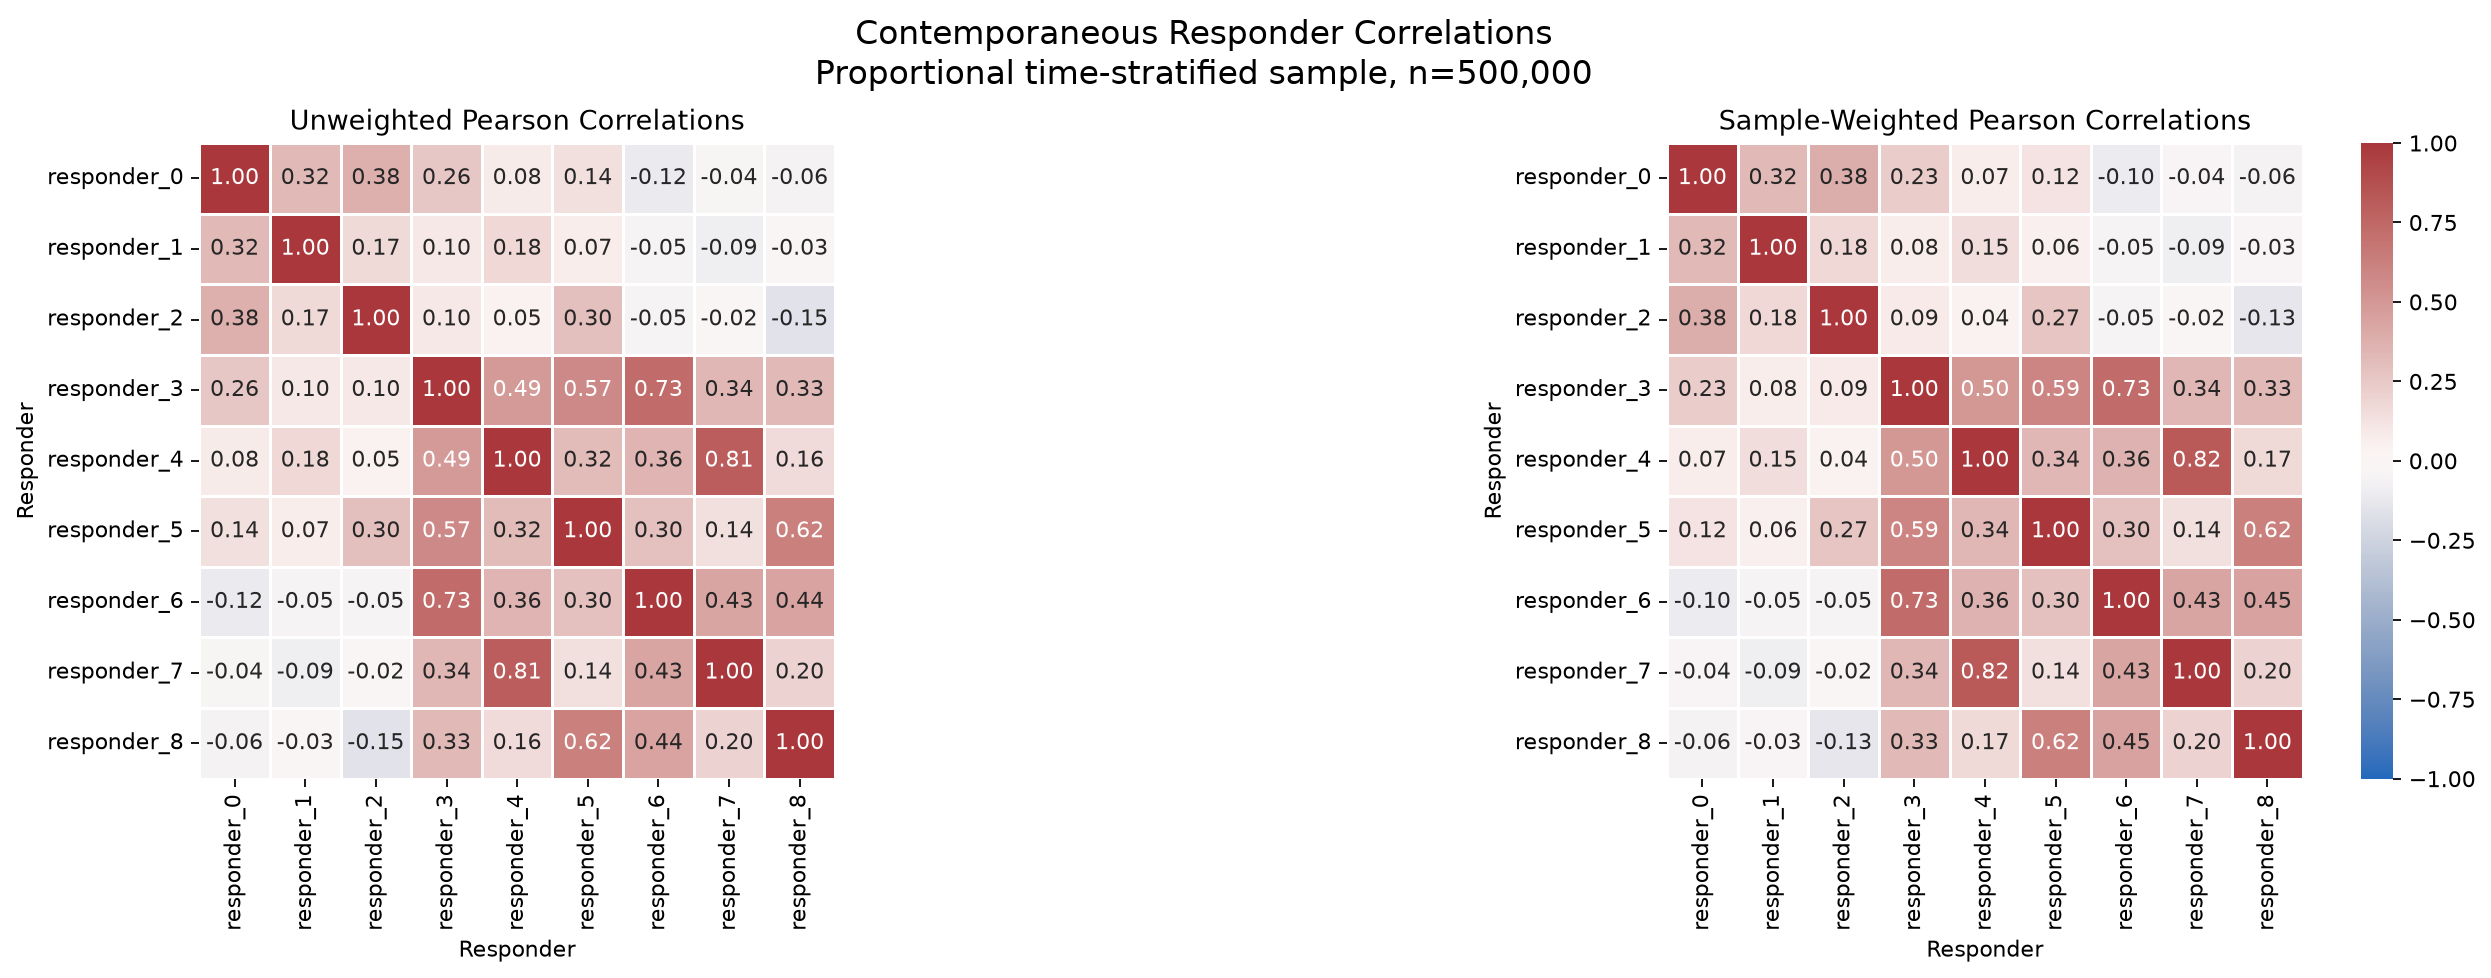

In [90]:
responder_pairs = pd.read_csv(
    phase3_artifact_dir / "responder_pairs.csv"
)

display(
    responder_pairs.head(12).round(6)
)

display(
    Image(
        filename=str(
            phase3_artifact_dir
            / "responder_correlation_heatmaps.png"
        )
    )
)


### Responder Correlation Interpretation

- The strongest sample-weighted contemporaneous relationship is between `responder_4` and `responder_7` (0.822), followed by `responder_3` and the target `responder_6` (0.734), and `responder_5` and `responder_8` (0.622).
- `responder_6` is also moderately related to `responder_8` (0.449), `responder_7` (0.433), and `responder_4` (0.363).
- Weighted and unweighted matrices have very similar structures, so sample weights alter magnitudes only modestly in this diagnostic.
- These correlations help describe the target family, but they do not authorize using contemporaneous responders as features. Doing so would leak unavailable outcomes into the model.


## 3.4 Feature–Responder and Feature–Target Relationships

We calculate the 79-by-9 rectangular feature–responder correlation table on the proportional time-stratified sample. Pairwise sample sizes are retained because feature missingness changes the effective number of observations.

For the primary target, both ordinary and sample-weighted Pearson correlations are reported. Rankings are exploratory candidates only; they are not feature-selection decisions.


,feature,responder,correlation,absolute_correlation,sample_size,rank_within_responder
0,feature_36,responder_0,0.202338,0.202338,500000,1
1,feature_48,responder_0,0.106415,0.106415,500000,2
2,feature_40,responder_0,0.089953,0.089953,499264,3
5,feature_36,responder_1,0.123106,0.123106,500000,1
6,feature_45,responder_1,0.080082,0.080082,496605,2
7,feature_40,responder_1,0.077366,0.077366,499264,3
10,feature_36,responder_2,0.184066,0.184066,500000,1
11,feature_48,responder_2,0.131771,0.131771,500000,2
12,feature_40,responder_2,0.088951,0.088951,499264,3
15,feature_34,responder_3,-0.066252,0.066252,500000,1


,feature,sample_size,correlation,weighted_correlation,absolute_correlation,absolute_weighted_correlation
0,feature_06,500000,-0.046422,-0.045216,0.046422,0.045216
1,feature_04,466476,-0.032102,-0.033260,0.032102,0.033260
2,feature_07,500000,-0.030821,-0.030117,0.030821,0.030117
3,feature_36,500000,-0.022828,-0.025357,0.022828,0.025357
4,feature_45,496605,-0.017999,-0.023032,0.017999,0.023032
5,feature_56,499997,-0.018155,-0.021943,0.018155,0.021943
6,feature_19,499997,-0.015159,-0.019706,0.015159,0.019706
7,feature_05,500000,-0.016845,-0.017412,0.016845,0.017412
8,feature_66,496605,-0.012271,-0.016866,0.012271,0.016866
9,feature_68,500000,0.010652,0.014142,0.010652,0.014142


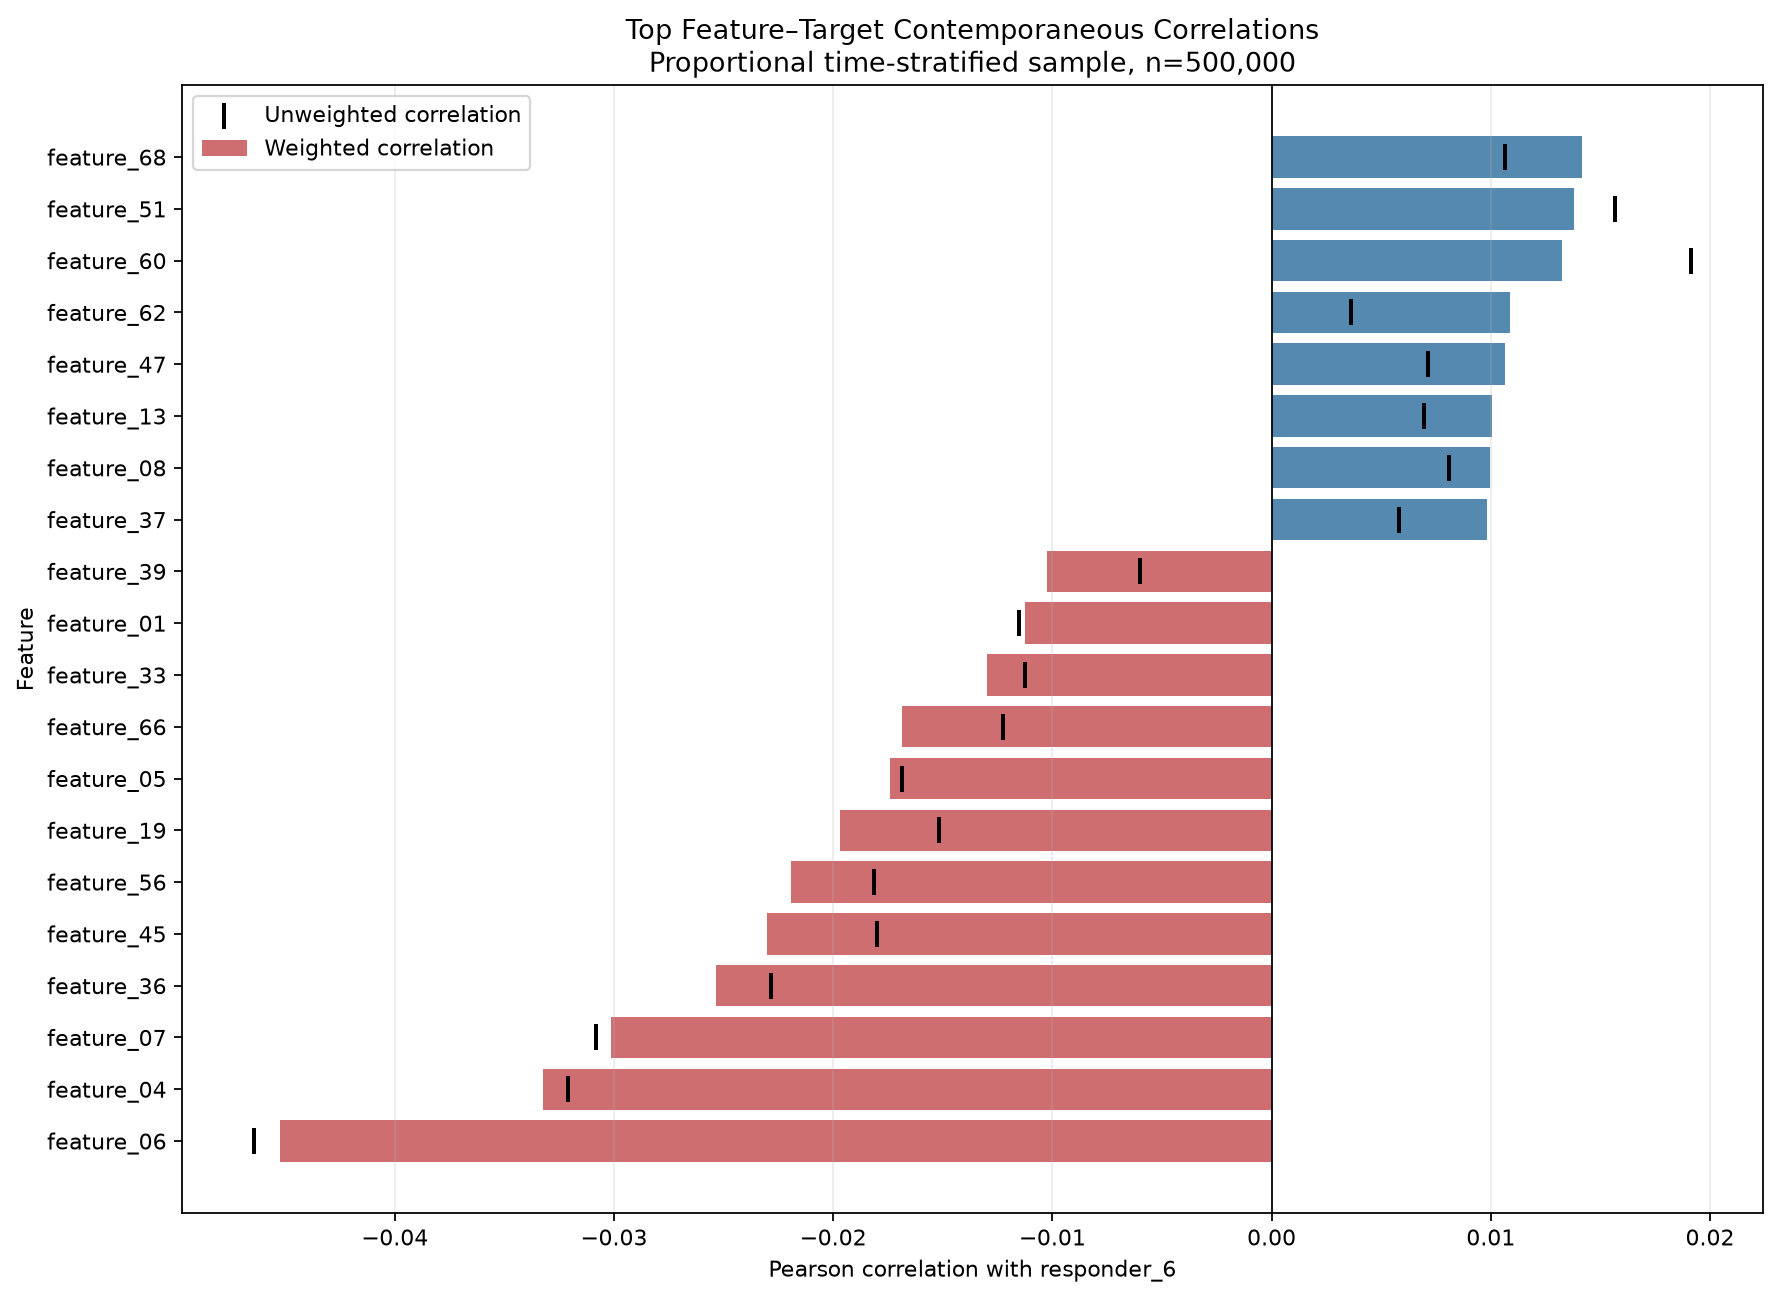

In [93]:
top_features_per_responder = pd.read_csv(
    phase3_artifact_dir / "top_features_per_responder.csv"
)

target_feature_correlations = pd.read_csv(
    phase3_artifact_dir / "target_feature_correlations.csv"
)

display(
    top_features_per_responder.loc[
        top_features_per_responder[
            "rank_within_responder"
        ] <= 3
    ].round(6)
)

display(
    target_feature_correlations.head(15).round(6)
)

display(
    Image(
        filename=str(
            phase3_artifact_dir
            / "top_feature_target_correlations.png"
        )
    )
)


### Feature–Responder Interpretation

- Marginal linear relationships with `responder_6` are weak. The largest absolute sample-weighted correlations are `feature_06` (-0.0452), `feature_04` (-0.0333), and `feature_07` (-0.0301).
- Some features have stronger contemporaneous relationships with other responders, such as `feature_36` with `responder_0` (0.202) and `responder_2` (0.184). This does not imply equivalent relevance for the scored target.
- Weighted and unweighted target correlations are generally similar, although their differences confirm that the evaluation weights can change feature rankings.
- Effective sample sizes differ across features because of missing values. For example, `feature_04` has 466,476 valid sampled observations instead of 500,000.
- Small marginal Pearson correlations do not rule out nonlinear effects, interactions, or conditional usefulness. Conversely, these in-sample correlations do not establish predictive value; every candidate must be tested in chronological out-of-sample folds.


## 3.5 Feature–Feature Relationships

Feature redundancy is evaluated using only the strict upper triangle of the 79-by-79 Pearson correlation matrix. This produces exactly 3,081 unique pairs, excluding all diagonal entries and symmetric duplicates. Pairwise sample sizes are reported for the strongest relationships.


Observed feature pairs: 3081
Expected feature pairs: 3081
Strict-upper validation: True


,feature_a,feature_b,correlation,absolute_correlation,pairwise_sample_size
0,feature_21,feature_31,0.975299,0.975299,410515.0
1,feature_75,feature_76,0.956993,0.956993,499409.0
2,feature_77,feature_78,0.955333,0.955333,499799.0
3,feature_73,feature_74,0.954890,0.954890,494887.0
4,feature_02,feature_03,0.947316,0.947316,466476.0
5,feature_00,feature_03,0.945499,0.945499,466476.0
6,feature_00,feature_02,0.943444,0.943444,466476.0
7,feature_34,feature_35,0.943393,0.943393,500000.0
8,feature_12,feature_67,0.938217,0.938217,500000.0
9,feature_12,feature_70,0.923335,0.923335,500000.0


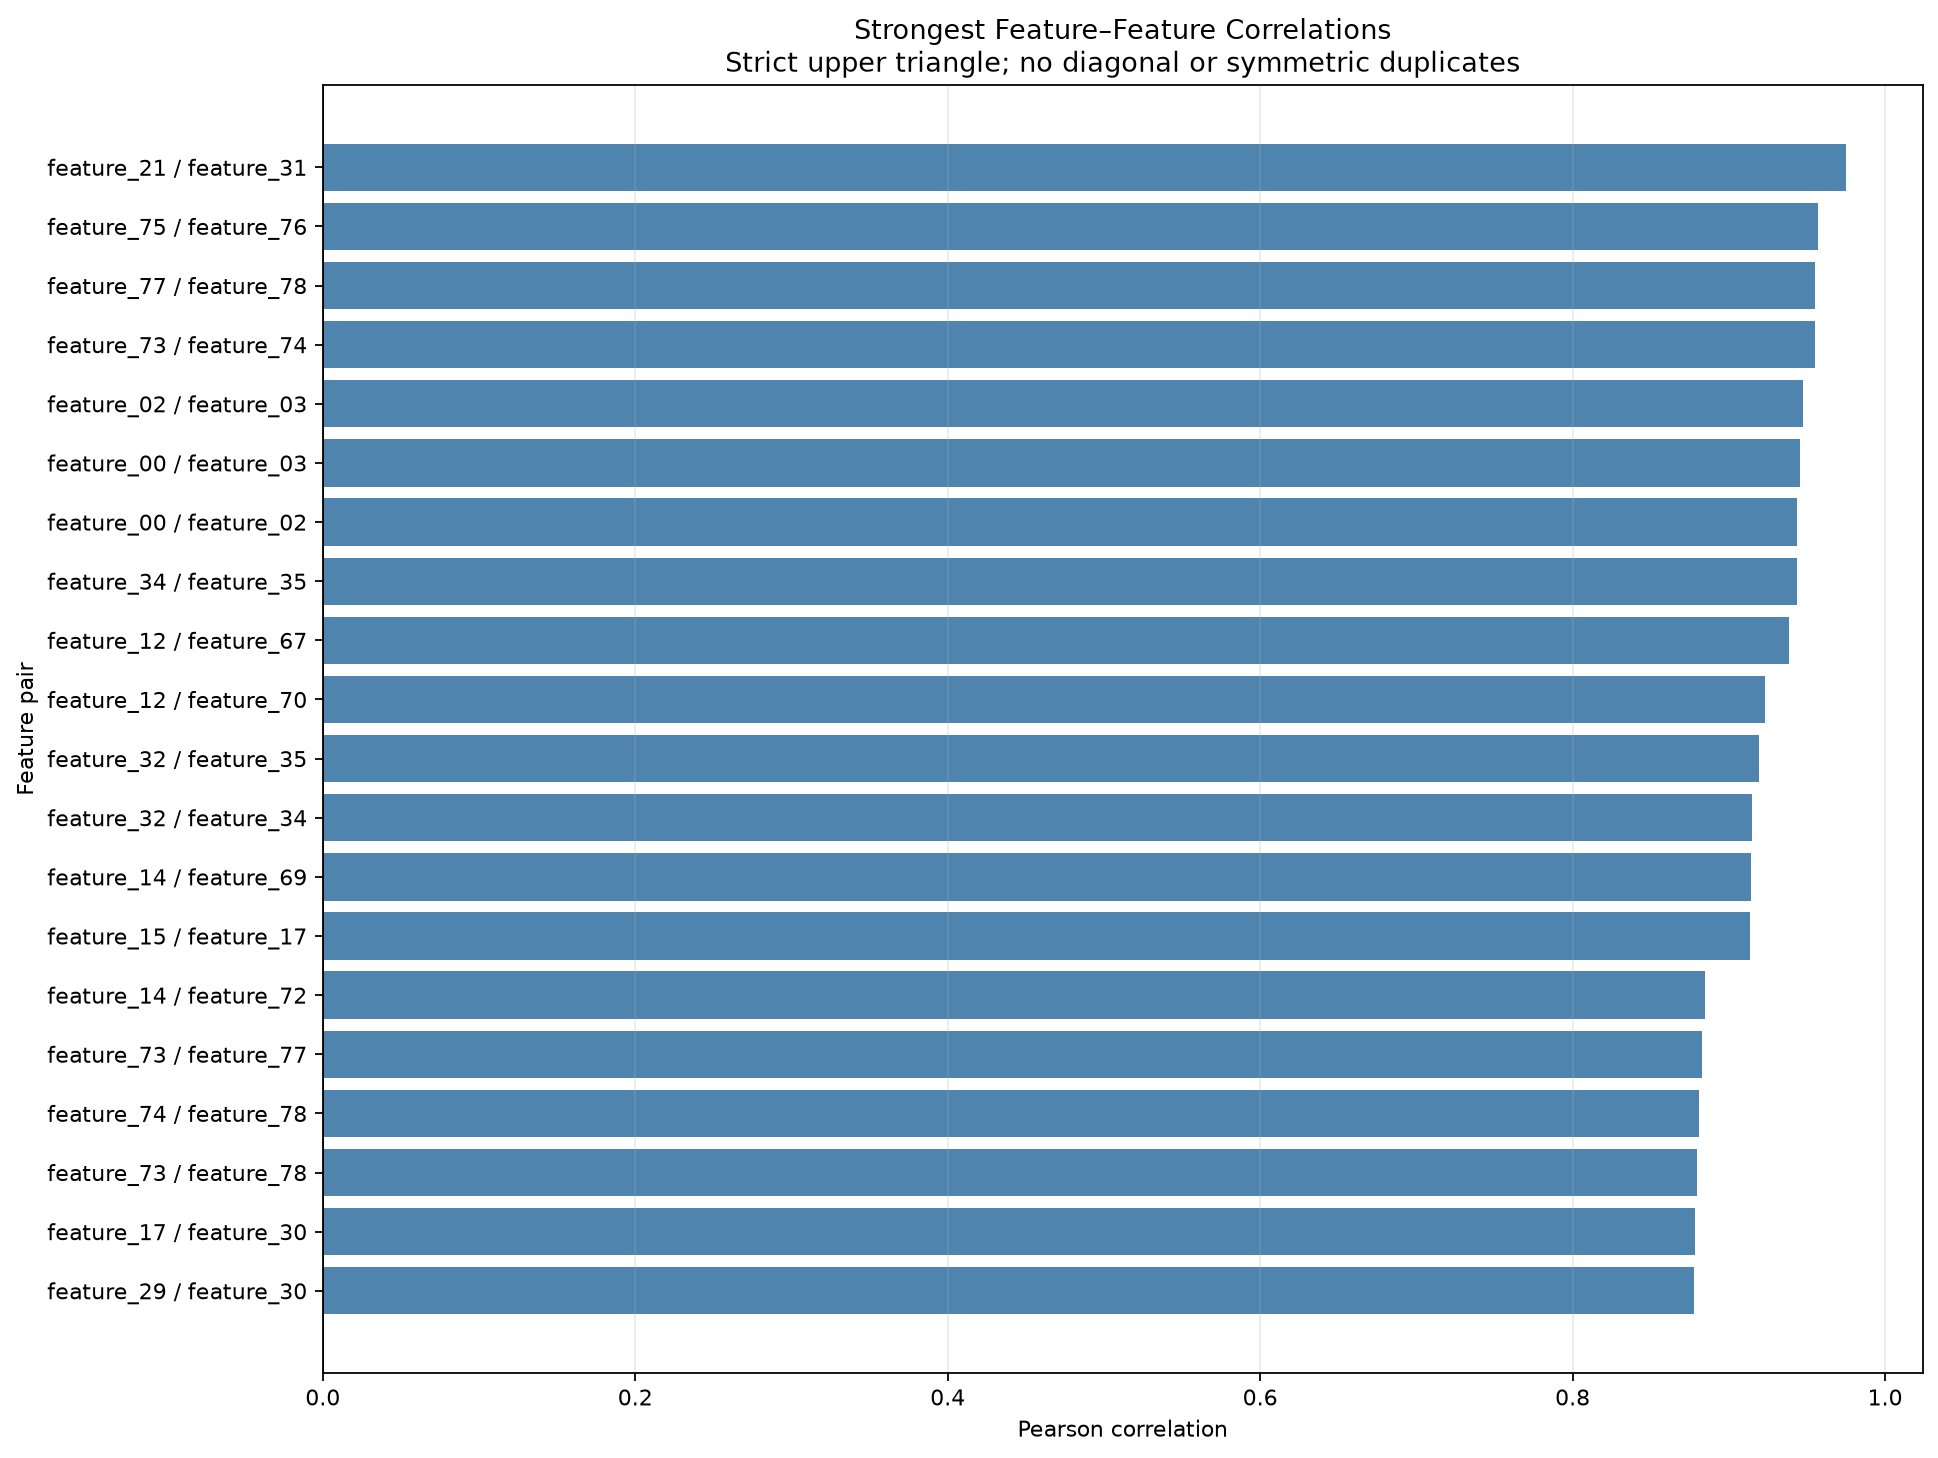

In [96]:
feature_pairs = pd.read_csv(
    phase3_artifact_dir / "feature_pairs.csv"
)

expected_feature_pairs = (
    len(feature_columns)
    * (len(feature_columns) - 1)
    // 2
)

print("Observed feature pairs:", len(feature_pairs))
print("Expected feature pairs:", expected_feature_pairs)
print(
    "Strict-upper validation:",
    len(feature_pairs) == expected_feature_pairs
)

display(
    feature_pairs.head(20).round(6)
)

display(
    Image(
        filename=str(
            phase3_artifact_dir
            / "top_feature_feature_correlations.png"
        )
    )
)


### Feature–Feature Interpretation

- Several feature-value pairs are strongly positively correlated. The largest sampled relationship is `feature_21` with `feature_31` (0.975), followed by `feature_75` with `feature_76` (0.957), `feature_77` with `feature_78` (0.955), and `feature_73` with `feature_74` (0.955).
- Additional high-correlation groups include `feature_00`/`feature_02`/`feature_03`, `feature_32`/`feature_34`/`feature_35`, and `feature_12`/`feature_67`/`feature_70`.
- Pairwise sample sizes differ because correlation uses rows where both features are observed.
- Strong feature-value correlation indicates potential redundancy, but it does not prove that either feature can be removed. Shared missingness does not imply identical values, and any reduction must be justified by chronological out-of-sample model comparisons.


## 3.6 Chronological Stability of Feature–Target Relationships

The twelve features with the largest pooled absolute sample-weighted correlations with `responder_6` are re-estimated separately within each chronological partition. We record sign consistency, the range and standard deviation of partition correlations, the number of valid partitions, and effective sample sizes.

This is a stability diagnostic rather than a validation score: every correlation still uses contemporaneous features and targets from the same partition.


,feature,pooled_correlation,pooled_weighted_correlation,minimum_partition_weighted_correlation,maximum_partition_weighted_correlation,partition_correlation_std,sign_consistency,valid_partitions,minimum_partition_sample_size,absolute_pooled_weighted_correlation
0,feature_06,-0.046422,-0.045216,-0.090988,-0.019537,0.017309,1.0,10,20627,0.045216
1,feature_04,-0.032102,-0.033260,-0.048206,-0.016193,0.009604,1.0,9,0,0.033260
2,feature_07,-0.030821,-0.030117,-0.068817,-0.013056,0.016478,1.0,10,20627,0.030117
3,feature_36,-0.022828,-0.025357,-0.045682,0.005097,0.015747,0.8,10,20627,0.025357
4,feature_45,-0.017999,-0.023032,-0.041919,-0.015249,0.007717,1.0,10,18841,0.023032
5,feature_56,-0.018155,-0.021943,-0.046644,-0.012135,0.009818,1.0,10,20626,0.021943
6,feature_19,-0.015159,-0.019706,-0.037834,-0.010950,0.007529,1.0,10,20626,0.019706
7,feature_05,-0.016845,-0.017412,-0.035201,-0.005057,0.009695,1.0,10,20627,0.017412
8,feature_66,-0.012271,-0.016866,-0.040345,-0.009165,0.008127,1.0,10,18841,0.016866
9,feature_68,0.010652,0.014142,0.002329,0.034776,0.008832,1.0,10,20627,0.014142


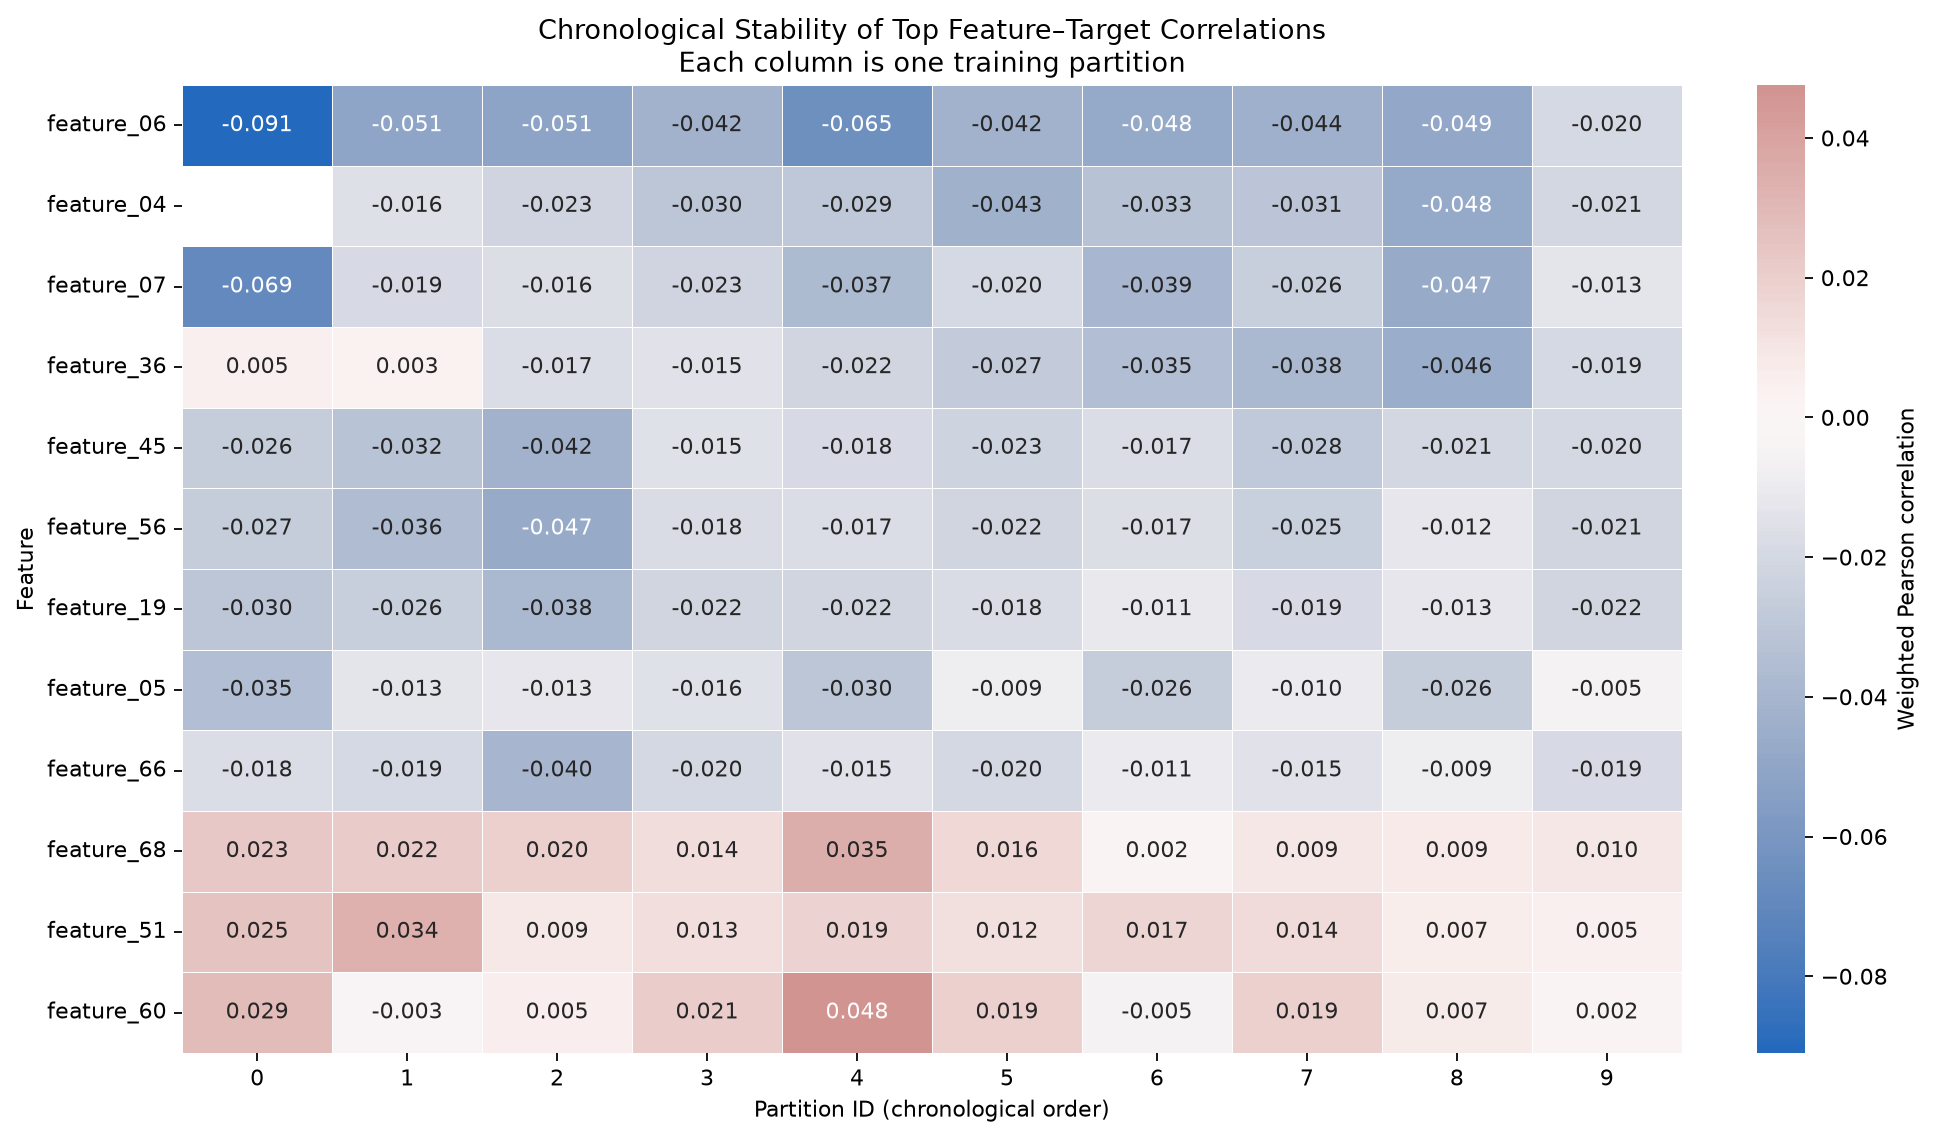

In [99]:
target_feature_stability = pd.read_csv(
    phase3_artifact_dir
    / "target_feature_stability_summary.csv"
)

display(
    target_feature_stability.round(6)
)

display(
    Image(
        filename=str(
            phase3_artifact_dir
            / "target_feature_stability_heatmap.png"
        )
    )
)


### Chronological Stability Interpretation

- Ten of the twelve leading pooled candidates retain the same correlation sign across every partition in which they are observed.
- `feature_04` is unavailable in `part-0`, so its stability is assessed over nine valid partitions rather than treating the missing period as zero correlation.
- Correlation magnitudes still vary materially through time. For example, the weighted correlation of `feature_06` ranges from approximately -0.091 to -0.020.
- `feature_36` and `feature_60` each have sign consistency of 0.8, showing that their pooled relationships conceal sign reversals in some chronological blocks.
- Sign consistency is encouraging but insufficient for feature selection. Magnitude drift, nonlinear effects, interactions, and true out-of-sample performance must be assessed under the later chronological validation protocol.


## Phase 3 EDA Summary and Decisions

- `responder_6` is centered near zero, sharply peaked, heavy-tailed, and clipped at `-5` and `+5`. Its dispersion, tails, and clipping rate change across chronological partitions.
- Sample weighting changes target dispersion and some feature rankings, so the official weighted metric must be used in every validation fold.
- Responders form several strong contemporaneous relationship groups, but non-target responders remain excluded from contemporaneous model inputs.
- Marginal linear feature relationships with `responder_6` are weak. `feature_06`, `feature_04`, and `feature_07` are the strongest pooled candidates, but their correlations remain descriptive rather than predictive evidence.
- Several feature groups are highly correlated in value, creating possible redundancy. No feature is removed on this basis without chronological out-of-sample evidence.
- Most leading target-correlation candidates preserve their sign across partitions, while magnitudes drift and some candidates reverse sign.

### Phase 3 Exit Check

- Responder distributions and weighted/unweighted relationships: complete.
- Feature–responder correlations with effective sample sizes: complete.
- Strict-upper-triangle feature–feature relationships: complete and validated at 3,081 unique pairs.
- Selected compact plots: complete.
- Chronological stability analysis: complete.
- Interpretation, limitations, and downstream decisions: complete.

Phase 3 is complete. Following the tutor's updated priority, the next phase establishes a leakage-aware LightGBM baseline and evidence-based feature screen before heavier temporal feature engineering.


In [102]:
# Compact Phase 3 validation record
print("Phase 3 sample rows:", phase3_validation["sample_rows"])
print(
    "Responder correlation matrix:",
    tuple(phase3_validation["responder_matrix_shape"])
)
print(
    "Feature-responder matrix:",
    tuple(phase3_validation["feature_responder_matrix_shape"])
)
print(
    "Feature correlation matrix:",
    tuple(phase3_validation["feature_matrix_shape"])
)
print(
    "Strict-upper feature pairs valid:",
    phase3_validation["feature_pair_count"]
    == phase3_validation["expected_feature_pair_count"]
)
print(
    "Top candidates with complete sign consistency:",
    phase3_validation["stable_feature_count"],
    "of 12"
)


Phase 3 sample rows: 500000
Responder correlation matrix: (9, 9)
Feature-responder matrix: (79, 9)
Feature correlation matrix: (79, 79)
Strict-upper feature pairs valid: True
Top candidates with complete sign consistency: 10 of 12


# Phase 4: Validation-First LightGBM Baseline and Evidence-Based Feature Screening

## 4.0 Objective and research contract

This phase follows the tutor's recommendation to establish a simple LightGBM benchmark before performing expensive feature engineering. The purpose is not to prove that a feature is universally useful; empirical predictive usefulness cannot be established by an in-sample importance value alone. Instead, this phase uses a predeclared chronological protocol so that every decision is reproducible and falsifiable.

The baseline model uses only `feature_00` through `feature_78`. `responder_6` is the target, and `weight` is used for model fitting and the official evaluation metric but is not a model input. `date_id`, `time_id`, `symbol_id`, and all contemporaneous responder columns are excluded from the baseline inputs. Missing feature values are passed directly to LightGBM without global imputation.

Phase 4 contains four evidence layers:

1. validate the official weighted zero-mean $R^2$ implementation;
2. estimate local runtime with one small chronological benchmark;
3. tune a bounded set of LightGBM configurations on folds A–C;
4. choose the feature count from cumulative gain thresholds and the one-standard-error rule, then test the locked choice on confirmation folds D–E.

`part-9.parquet` is excluded from every Phase 4 model-selection step. Because Phase 3 already inspected its target and feature distributions, it is honestly treated as a late quasi-holdout rather than a pristine unseen holdout. No Phase 4 function is permitted to place it in the development cache or use it for parameter or feature selection; the competition's external test data remain the only truly unseen final test.


## 4.1 Setup and computational profiles

The implementation is stored in `scripts/phase4_baseline.py` so that the validation logic is testable outside the notebook. Three computational profiles are available:

- `timing`: a 1% sample and one small model, used only to estimate runtime;
- `fast`: a 3% development sample and four parameter candidates, used for a first end-to-end run;
- `standard`: a 10% development sample and six parameter candidates, used for the main Phase 4 result.

The sample fraction affects training cost, not the chronological boundaries. Reported baseline and confirmation scores are calculated by streaming every row of each validation partition.


In [1]:
%pip install lightgbm


   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   --------------------- ------------------ 0.7/1.4 MB 15.0 MB/s eta 0:00:01
   ---------------------------------------  1.4/1.4 MB 17.2 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 12.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/474.0 kB ? eta -:--:--
   -------------------------------------- 474.0/474.0 kB 15.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import importlib
from importlib.util import find_spec
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import scripts.phase4_baseline as phase4_baseline
importlib.reload(phase4_baseline)

from scripts.phase4_baseline import (
    FEATURE_COLUMNS as PHASE4_FEATURE_COLUMNS,
    PROFILES as PHASE4_PROFILES,
    build_fold_table,
    run_metric_self_tests,
    run_phase4_pipeline,
    run_timing_benchmark,
)

project_root = Path.cwd()
train_dir = project_root / "train.parquet"
partition_files = sorted(train_dir.glob("partition_id=*/part-*.parquet"))
assert len(partition_files) == 10, "Expected ten training partitions."

phase4_artifact_dir = project_root / "artifacts" / "phase4"
phase4_artifact_dir.mkdir(parents=True, exist_ok=True)

PHASE4_SEED = 42
PHASE4_GAP_DATES = 1
PHASE4_NUM_THREADS = -1

print("Phase 4 feature count:", len(PHASE4_FEATURE_COLUMNS))
print("Artifact directory:", phase4_artifact_dir)
print("Available profiles:", list(PHASE4_PROFILES))

if find_spec("lightgbm") is None:
    print("LightGBM is not installed in this kernel.")
    print("Run `%pip install lightgbm`, restart the kernel, then rerun Phase 4.")
else:
    import lightgbm as lgb
    print("LightGBM version:", lgb.__version__)


Phase 4 feature count: 79
Artifact directory: <PROJECT_ROOT>\artifacts\phase4
Available profiles: ['timing', 'fast', 'standard']
LightGBM version: 4.7.0


## 4.2 Official weighted zero-mean $R^2$

The competition score is

$$
R_w^2 = 1 - \frac{\sum_i w_i(y_i-\hat{y}_i)^2}{\sum_i w_i y_i^2}.
$$

This is not the ordinary centered `sklearn` $R^2$. The tests below verify perfect prediction, the zero-prediction benchmark, invariance to weight scaling, zero-weight behavior, negative scores for bad predictions, and explicit rejection of a zero denominator.


In [4]:
phase4_metric_tests = run_metric_self_tests()
display(phase4_metric_tests)

assert phase4_metric_tests["passed"].all()
print("All official-metric checks passed.")


,check,value,passed
0,perfect prediction equals 1,1.0,True
1,zero prediction equals 0,0.0,True
2,zero-weight row has no effect,1.0,True
3,weight rescaling has no effect,0.0,True
4,bad prediction may be negative,-120.0,True
5,zero denominator is rejected,NaN,True


All official-metric checks passed.


## 4.3 Chronological development folds

Folds A–C are used for parameter and feature selection. After those choices are locked, folds D–E provide a later-period confirmation. A one-date embargo is removed from the end of each training window because the exact responder horizon is not explicitly documented. If the target horizon is later shown to exceed one date, this gap must be increased before any final experiment.

The split is expanding-window rather than random-row cross-validation. This preserves temporal ordering and ensures that all validation dates follow all retained training dates.


In [6]:
phase4_fold_table = build_fold_table(
    partition_files=partition_files,
    gap_dates=PHASE4_GAP_DATES,
)

display(
    phase4_fold_table[[
        "fold",
        "role",
        "train_parts",
        "train_max_date_after_gap",
        "gap_dates",
        "valid_file",
        "valid_min_date",
        "valid_max_date",
        "approx_train_rows_before_gap",
        "valid_rows",
    ]]
)

assert phase4_fold_table["valid_part"].max() == 8
assert not phase4_fold_table["valid_part"].eq(9).any()
assert (
    phase4_fold_table["train_max_date_after_gap"]
    < phase4_fold_table["valid_min_date"]
).all()
print("Temporal ordering valid; part-9 is excluded from Phase 4 selection.")


,fold,role,train_parts,train_max_date_after_gap,gap_dates,valid_file,valid_min_date,valid_max_date,approx_train_rows_before_gap,valid_rows
0,A,tuning,0-3,678,1,part-4.parquet,680,849,11802114,5022952
1,B,tuning,0-4,848,1,part-5.parquet,850,1019,16825066,5348200
2,C,tuning,0-5,1018,1,part-6.parquet,1020,1189,22173266,6203912
3,D,confirmation,0-6,1188,1,part-7.parquet,1190,1359,28377178,6335560
4,E,confirmation,0-7,1358,1,part-8.parquet,1360,1529,34712738,6140024


Temporal ordering valid; part-9 is excluded from Phase 4 selection.


## 4.4 Local runtime benchmark

Run this cell before the full pipeline. It creates a deterministic 1% cache for partitions 0–4, trains one small raw-79 model on fold A, and streams the complete `part-4` validation partition. The resulting estimate incorporates sample-cache preparation, approximate model-fitting work, and the planned full-validation scoring passes.

The reported interval is deliberately wide because LightGBM runtime is not perfectly linear in rows, tree depth, early stopping iteration, available RAM, or CPU contention. It is an empirical planning estimate rather than a guarantee. This benchmark does not access `part-9`.


In [8]:
RUN_PHASE4_TIMING_BENCHMARK = True

if RUN_PHASE4_TIMING_BENCHMARK:
    (
        phase4_timing_benchmark,
        phase4_runtime_estimates,
        phase4_timing_details,
    ) = run_timing_benchmark(
        partition_files=partition_files,
        artifact_dir=phase4_artifact_dir,
        gap_dates=PHASE4_GAP_DATES,
        seed=PHASE4_SEED,
        num_threads=PHASE4_NUM_THREADS,
    )

    display(phase4_timing_benchmark.round(6))
    display(phase4_runtime_estimates.round(3))
else:
    print("Timing benchmark skipped.")


,train_rows,validation_sample_rows,feature_count,best_iteration,sample_weighted_r2,training_seconds,sample_prediction_seconds,full_weighted_r2,zero_prediction_weighted_r2,full_validation_rows,full_scoring_seconds,training_weighted_mean,weighted_mean_baseline_r2,cache_seconds_first_five_partitions,fold_load_seconds,profile
0,117827,49739,79,117,0.013452,5.096603,0.198154,0.012255,0.0,5022952,16.23488,-0.002275,0.000003,10.375651,0.248411,timing


,profile,sample_fraction,parameter_candidates,planned_model_fits,estimated_hours_low,estimated_hours_central,estimated_hours_high,rough_peak_memory_gib
0,fast,0.03,4,34,0.199,0.284,0.568,0.954
1,standard,0.10,6,40,0.688,0.983,1.967,3.181


## 4.5 Bounded parameter search and raw-79 baseline

The full pipeline first evaluates a small, predeclared LightGBM candidate list on tuning folds A–C. The chosen configuration maximizes mean weighted $R^2$; minimum-fold score and fold dispersion break ties. It is then refitted on A–C so that every raw-79 baseline is scored on the complete validation partition and fold-specific normalized gain importance can be recorded. The same validation pass also records the zero-prediction score and a constant predictor fitted from the training-fold weighted mean.

This is intentionally a bounded search rather than a large grid. A large search would multiply runtime and increase the opportunity to overfit three tuning periods.

## 4.6 Evidence-based feature-count selection

The code aggregates normalized gain importance across tuning folds using the median. The leading gain candidates are also audited by shuffling them one at a time on the validation sample and measuring the resulting weighted-$R^2$ drop. Permutation importance is reported as supporting evidence rather than a hard deletion rule because correlated features can substitute for one another. The code then constructs candidate sets that reach 80%, 90%, 95%, 99%, and 100% of cumulative aggregated gain. These thresholds generate feature counts; they do not predetermine counts.

Every candidate set is retrained on A–C with locked boosting rounds. The smallest set whose mean score lies within one standard error of the best tuning result is selected. This replaces the arbitrary tutor example of Top 15 with a reproducible, performance-linked rule.

Finally, the raw-79 and selected models are compared on full confirmation partitions D–E. Confirmation is accepted only when the mean degradation is no larger than one tuning standard error and the worst-fold degradation is no larger than two. A failed confirmation rejects the reduced set; it does not trigger further tuning on D–E.


In [24]:
# Run the timing cell first. Then choose 'fast' for a first complete run
# or 'standard' for the main Phase 4 result.
PHASE4_PROFILE = "fast"
RUN_FULL_PHASE4_PIPELINE = True

if RUN_FULL_PHASE4_PIPELINE:
    phase4_results = run_phase4_pipeline(
        partition_files=partition_files,
        artifact_dir=phase4_artifact_dir,
        profile_name=PHASE4_PROFILE,
        gap_dates=PHASE4_GAP_DATES,
        seed=PHASE4_SEED,
        num_threads=PHASE4_NUM_THREADS,
    )

    print("Selected parameter candidate:")
    display(phase4_results["parameter_summary"].round(6))

    print("Raw-79 tuning-fold baseline:")
    display(phase4_results["baseline_results"].round(6))

    print("Validation permutation-importance audit:")
    display(phase4_results["permutation_summary"].head(30).round(6))

    print("Cumulative-gain threshold comparison:")
    display(phase4_results["threshold_summary"].round(6))

    print("Locked confirmation comparison:")
    display(phase4_results["confirmation_comparison"].round(6))

    print("Training versus validation R-squared (overfitting check):")
    phase4_overfit_columns = [
        "fold", "model", "training_sample_weighted_r2",
        "validation_sample_weighted_r2", "full_weighted_r2",
        "training_sample_minus_full_validation_r2",
    ]
    display(phase4_results["confirmation_results"][phase4_overfit_columns].round(6))

    print("Final Phase 4 decision:")
    display(pd.Series(phase4_results["decision"]))
else:
    print("Full Phase 4 pipeline is disabled.")
    print("Run the timing benchmark, inspect its estimate, then set RUN_FULL_PHASE4_PIPELINE = True.")


Selected parameter candidate:


,candidate,mean_weighted_r2,median_weighted_r2,std_weighted_r2,minimum_weighted_r2,mean_best_iteration,total_training_seconds
0,C3_depth_limited,0.012433,0.011627,0.002424,0.010515,248.333333,80.070747
1,C2_larger_leaves,0.012424,0.011282,0.002230,0.010997,261.333333,100.058411
2,C1_more_leaves,0.012233,0.011470,0.002256,0.010457,145.000000,77.897173
3,C0_reference,0.012014,0.011869,0.001826,0.010265,191.000000,68.578847


Raw-79 tuning-fold baseline:


,fold,candidate,train_rows,validation_sample_rows,feature_count,best_iteration,sample_weighted_r2,training_seconds,sample_prediction_seconds,full_weighted_r2,zero_prediction_weighted_r2,full_validation_rows,full_scoring_seconds,training_weighted_mean,weighted_mean_baseline_r2
0,A,C3_depth_limited,353010,150417,79,254,0.015158,23.029590,0.725278,0.015135,0.0,5022952,26.933651,-0.001045,0.000003
1,B,C3_depth_limited,503347,160359,79,270,0.011627,27.993900,0.848539,0.012406,0.0,5348200,30.583559,0.000115,-0.000002
2,C,C3_depth_limited,663670,186055,79,221,0.010515,31.192262,0.804981,0.010083,0.0,6203912,30.125704,-0.002114,0.000017


Validation permutation-importance audit:


...

,label,threshold,feature_count,mean_weighted_r2,std_weighted_r2,minimum_weighted_r2,standard_error,within_one_se_of_best
0,gain_80,0.80,46,0.012467,0.001907,0.011146,0.001101,True
1,gain_90,0.90,60,0.012546,0.001989,0.010981,0.001148,True
2,gain_95,0.95,68,0.012351,0.002245,0.010689,0.001296,True
3,gain_99,0.99,76,0.012113,0.002101,0.010528,0.001213,True
4,gain_100,1.00,79,0.012376,0.002481,0.010393,0.001432,True


Locked confirmation comparison:


model,fold,gain_80,raw79,selected_minus_raw79
0,D,0.009571,0.008718,0.000853
1,E,0.011182,0.012272,-0.001090


Final Phase 4 decision:


profile                         {'name': 'fast', 'sample_fraction': 0.03, 'max...
gap_dates                                                                       1
seed                                                                           42
selected_parameter_candidate                                     C3_depth_limited
selected_parameters             {'candidate': 'C3_depth_limited', 'num_leaves'...
locked_boost_rounds                                                           254
selected_gain_threshold                                                       0.8
selected_feature_count                                                         46
selected_features               [feature_06, feature_07, feature_59, feature_6...
selection_standard_error                                                 0.001101
confirmation_accepted                                                        True
final_feature_count                                                            46
final_features  

## 4.7 Reloading saved results

Every material table and the final decision are saved under `artifacts/phase4`. The following cell can recover the compact results after a kernel restart without retraining the models. Cached samples are profile-specific and never contain partition 9.


In [12]:
import json

phase4_decision_path = phase4_artifact_dir / "phase4_decision.json"

if phase4_decision_path.exists():
    phase4_saved_threshold_summary = pd.read_csv(
        phase4_artifact_dir / "threshold_search_summary.csv"
    )
    phase4_saved_confirmation = pd.read_csv(
        phase4_artifact_dir / "confirmation_comparison.csv"
    )
    phase4_saved_decision = json.loads(
        phase4_decision_path.read_text(encoding="utf-8")
    )

    display(phase4_saved_threshold_summary.round(6))
    display(phase4_saved_confirmation.round(6))
    display(pd.Series(phase4_saved_decision))
else:
    print("No completed Phase 4 decision has been saved yet.")


No completed Phase 4 decision has been saved yet.


## 4.8 Feature-threshold and confirmation diagnostics

The left plot shows the relationship between retained feature count and tuning-fold weighted $R^2$. The right plot reports the full-partition score difference between the selected subset and the raw-79 baseline on folds D–E. These plots should be interpreted together: a small tuning improvement is not sufficient if it disappears in later periods.


In [14]:
if RUN_FULL_PHASE4_PIPELINE:
    threshold_plot_data = phase4_results["threshold_summary"].copy()
    confirmation_plot_data = phase4_results["confirmation_comparison"].copy()
elif phase4_decision_path.exists():
    threshold_plot_data = phase4_saved_threshold_summary.copy()
    confirmation_plot_data = phase4_saved_confirmation.copy()
else:
    threshold_plot_data = None
    confirmation_plot_data = None

if threshold_plot_data is not None:
    threshold_plot_data = threshold_plot_data.sort_values("feature_count")
    fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)

    axes[0].errorbar(
        threshold_plot_data["feature_count"],
        threshold_plot_data["mean_weighted_r2"],
        yerr=threshold_plot_data["standard_error"],
        marker="o",
        capsize=4,
    )
    axes[0].set_title("Tuning Score by Dynamic Feature Count")
    axes[0].set_xlabel("Number of retained features")
    axes[0].set_ylabel("Mean weighted R²")
    axes[0].grid(alpha=0.25)

    axes[1].bar(
        confirmation_plot_data["fold"],
        confirmation_plot_data["selected_minus_raw79"],
    )
    axes[1].axhline(0.0, color="black", linewidth=1.0)
    axes[1].set_title("Selected Minus Raw-79 on Confirmation Folds")
    axes[1].set_xlabel("Fold")
    axes[1].set_ylabel("Weighted R² difference")
    axes[1].grid(axis="y", alpha=0.25)

    plt.show()
else:
    print("Run the full Phase 4 pipeline before plotting diagnostics.")


Run the full Phase 4 pipeline before plotting diagnostics.


## Phase 4 exit criteria and interpretation template

Phase 4 is complete only after the full pipeline has run and the following statements can be filled from saved evidence:

- All official weighted-$R^2$ self-tests passed.
- Every training timestamp preceded its validation block, with the declared embargo applied.
- The selected LightGBM configuration was chosen only from tuning folds A–C.
- The raw-79 weighted-$R^2$ scores were reported separately for every tuning fold.
- The selected feature count emerged from cumulative-gain thresholds and the one-standard-error rule; it was not fixed in advance.
- The reduced feature set was either accepted or rejected using locked confirmation folds D–E.
- `part-9.parquet` was excluded from all Phase 4 tuning and feature selection; because it had already been inspected during EDA, it is reported as a quasi-holdout rather than a pristine holdout.

The notebook interpretation should report the selected parameter candidate, locked boosting rounds, raw-79 scores, selected threshold and feature count, confirmation score differences, runtime, and whether the evidence supports carrying the reduced feature set into the next feature-engineering phase. It must also state that LightGBM gain importance is model-dependent and does not constitute mathematical proof of causal or universal feature importance.


# Phase 5: Leakage-Safe Feature Engineering and Model Comparison

Phase 4 established the official weighted zero-mean $R^2$, chronological folds, a raw-feature LightGBM benchmark, and a provisional 46-feature pool. Phase 5 implements the remaining items in the tutor checklist: feature engineering, missing-value treatment, and a locked comparison against the baseline.

The Phase 4 feature ranking is model-dependent. Highly correlated features may compete for the same gain, so Phase 5 does not interpret a low individual gain as proof that a feature is useless. Engineering source columns are generated by predeclared cumulative-gain thresholds and expanded to retain highly correlated substitutes identified in Phase 3. Their usefulness is decided only by later chronological validation.

Partition 9 remains excluded from all Phase 5 selection. It was already inspected during EDA and is therefore only a quasi-holdout, not a pristine unseen test set.


## 5.1 Experimental contract

Phase 5 separates four questions:

1. **Source threshold:** how much of the Phase 4 aggregate gain should supply expensive temporal features? The profile tests cumulative-gain thresholds rather than fixing Top 15 in advance.
2. **Feature family:** do cross-sectional statistics, sequential history, or their combination improve the same future folds?
3. **NaN treatment:** does LightGBM's native handling outperform strictly historical forward fill plus original-missingness indicators?
4. **Confirmation:** after selecting one configuration on folds A-C, does the locked choice improve full partitions D-E relative to the raw-feature baselines?

Sequential features are generated from every chronological row before sampling. A random sample is taken only after feature construction, because calculating lags on an already sampled table would redefine `lag_1` as the previous sampled row and invalidate the experiment.

Current-row cross-sectional statistics assume that all symbols in the same `date_id` and `time_id` batch are visible together at prediction time. This assumption must be checked against the competition inference interface before the final model.


### 5.1.1 Metric, folds, and visible LightGBM training

The cell below contains the actual `lgb.train(...)` call, the built-in squared-error objective, the single application of sample weights, and both training and validation weighted zero-mean R-squared.


In [3]:
# [P7-PRE-1] Fresh-kernel prerequisite: shared LightGBM definitions
# Phase 5 is intentionally self-contained in this notebook.
# The model fitting code is visible below; no Phase 5 implementation is imported.
import gc
import hashlib
import json
import math
import time
from dataclasses import asdict, dataclass
from importlib.util import find_spec
from pathlib import Path
from typing import Any, Iterable, Iterator

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

FEATURE_COLUMNS = [f"feature_{index:02d}" for index in range(79)]


TARGET_COLUMN = "responder_6"


WEIGHT_COLUMN = "weight"


DATE_COLUMN = "date_id"


@dataclass(frozen=True)
class Phase4Profile:
    """Computational settings, separated from modeling decisions."""

    name: str
    sample_fraction: float
    max_boost_rounds: int
    early_stopping_rounds: int
    candidate_count: int
    permutation_top_n: int
    batch_size: int = 200_000


PHASE4_PROFILES = {
    "timing": Phase4Profile(
        name="timing",
        sample_fraction=0.01,
        max_boost_rounds=200,
        early_stopping_rounds=30,
        candidate_count=1,
        permutation_top_n=10,
    ),
    "fast": Phase4Profile(
        name="fast",
        sample_fraction=0.03,
        max_boost_rounds=600,
        early_stopping_rounds=50,
        candidate_count=4,
        permutation_top_n=20,
    ),
    "standard": Phase4Profile(
        name="standard",
        sample_fraction=0.10,
        max_boost_rounds=1_000,
        early_stopping_rounds=100,
        candidate_count=6,
        permutation_top_n=30,
    ),
}


FOLD_SPECS = [
    {"fold": "A", "role": "tuning", "train_end_part": 3, "valid_part": 4},
    {"fold": "B", "role": "tuning", "train_end_part": 4, "valid_part": 5},
    {"fold": "C", "role": "tuning", "train_end_part": 5, "valid_part": 6},
    {"fold": "D", "role": "confirmation", "train_end_part": 6, "valid_part": 7},
    {"fold": "E", "role": "confirmation", "train_end_part": 7, "valid_part": 8},
]


def require_lightgbm():
    """Import LightGBM lazily so the notebook can show setup instructions first."""

    try:
        import lightgbm as lgb
    except ImportError as error:
        raise ImportError(
            "LightGBM is not installed in this notebook kernel. "
            "Run `%pip install lightgbm` once, restart the kernel, and rerun Phase 4."
        ) from error
    return lgb


def weighted_zero_mean_r2(
    y_true: Iterable[float],
    y_pred: Iterable[float],
    sample_weight: Iterable[float],
) -> float:
    """Competition weighted, zero-mean R-squared."""

    y_true_array = np.asarray(y_true, dtype=np.float64)
    y_pred_array = np.asarray(y_pred, dtype=np.float64)
    weight_array = np.asarray(sample_weight, dtype=np.float64)

    if not (
        y_true_array.shape == y_pred_array.shape == weight_array.shape
    ):
        raise ValueError("y_true, y_pred, and sample_weight must have equal shapes.")
    if not np.isfinite(y_true_array).all():
        raise ValueError("y_true contains a missing or infinite value.")
    if not np.isfinite(y_pred_array).all():
        raise ValueError("y_pred contains a missing or infinite value.")
    if not np.isfinite(weight_array).all() or (weight_array < 0).any():
        raise ValueError("sample_weight must be finite and non-negative.")

    denominator = np.sum(weight_array * y_true_array**2, dtype=np.float64)
    if denominator <= 0:
        raise ZeroDivisionError("The weighted target sum of squares is zero.")

    numerator = np.sum(
        weight_array * (y_true_array - y_pred_array) ** 2,
        dtype=np.float64,
    )
    return float(1.0 - numerator / denominator)


def _partition_date_range(file_path: Path) -> tuple[int, int]:
    date_data = pd.read_parquet(file_path, columns=[DATE_COLUMN])
    return int(date_data[DATE_COLUMN].min()), int(date_data[DATE_COLUMN].max())


def build_fold_table(
    partition_files: list[Path],
    gap_dates: int = 1,
) -> pd.DataFrame:
    """Create auditable expanding-window folds and exclude partition 9."""

    if len(partition_files) != 10:
        raise ValueError("Phase 4 expects exactly ten chronological partitions.")
    if gap_dates < 0:
        raise ValueError("gap_dates cannot be negative.")

    partition_info = []
    # Deliberately stop at partition 8.  Partition 9 was already inspected in
    # Phase 3 EDA, but it remains excluded from every Phase 4 selection step.
    for partition_index, file_path in enumerate(partition_files[:9]):
        minimum_date, maximum_date = _partition_date_range(file_path)
        partition_info.append(
            {
                "partition": partition_index,
                "file": file_path.name,
                "rows": pq.ParquetFile(file_path).metadata.num_rows,
                "min_date": minimum_date,
                "max_date": maximum_date,
            }
        )
    partition_table = pd.DataFrame(partition_info)

    if not partition_table["min_date"].is_monotonic_increasing:
        raise AssertionError("Partitions are not in chronological order.")
    previous_maximum = partition_table["max_date"].shift(1)
    if not (
        partition_table.loc[1:, "min_date"].to_numpy()
        > previous_maximum.loc[1:].to_numpy()
    ).all():
        raise AssertionError("Partition date ranges overlap.")

    fold_rows = []
    for spec in FOLD_SPECS:
        validation_row = partition_table.loc[
            partition_table["partition"].eq(spec["valid_part"])
        ].iloc[0]
        train_rows = partition_table.loc[
            partition_table["partition"].le(spec["train_end_part"]),
            "rows",
        ].sum()
        maximum_training_date = int(validation_row["min_date"] - gap_dates - 1)
        fold_rows.append(
            {
                **spec,
                "train_parts": f"0-{spec['train_end_part']}",
                "train_min_date": int(partition_table.iloc[0]["min_date"]),
                "train_max_date_after_gap": maximum_training_date,
                "gap_dates": gap_dates,
                "valid_file": validation_row["file"],
                "valid_min_date": int(validation_row["min_date"]),
                "valid_max_date": int(validation_row["max_date"]),
                "approx_train_rows_before_gap": int(train_rows),
                "valid_rows": int(validation_row["rows"]),
            }
        )

    fold_table = pd.DataFrame(fold_rows)
    if not (
        fold_table["train_max_date_after_gap"]
        < fold_table["valid_min_date"]
    ).all():
        raise AssertionError("At least one fold violates temporal ordering.")
    return fold_table


def _split_frame(
    frame: pd.DataFrame,
    feature_columns: list[str],
) -> tuple[pd.DataFrame, np.ndarray, np.ndarray]:
    x_values = frame[feature_columns]
    y_values = frame[TARGET_COLUMN].to_numpy(dtype=np.float64, copy=False)
    weights = frame[WEIGHT_COLUMN].to_numpy(dtype=np.float64, copy=False)
    if not np.isfinite(y_values).all():
        raise ValueError("The target contains a missing or infinite value.")
    if not np.isfinite(weights).all() or (weights <= 0).any():
        raise ValueError("Weights must be finite and strictly positive.")
    return x_values, y_values, weights


def _lgb_weighted_r2(predictions: np.ndarray, dataset: Any):
    score = weighted_zero_mean_r2(
        dataset.get_label(),
        predictions,
        dataset.get_weight(),
    )
    return "weighted_zero_mean_r2", score, True


def _base_parameters(seed: int, num_threads: int) -> dict[str, Any]:
    return {
        "objective": "regression",
        "metric": "None",
        "learning_rate": 0.05,
        "verbosity": -1,
        "num_threads": num_threads,
        "seed": seed,
        "feature_fraction_seed": seed,
        "bagging_seed": seed,
        "data_random_seed": seed,
        "deterministic": True,
        "force_col_wise": True,
    }


def train_model(
    training_frame: pd.DataFrame,
    validation_frame: pd.DataFrame,
    feature_columns: list[str],
    candidate_parameters: dict[str, Any],
    profile: Phase4Profile,
    seed: int,
    num_threads: int,
    fixed_rounds: int | None = None,
) -> tuple[Any, dict[str, Any]]:
    """Train one weighted LightGBM model and time it."""

    lgb = require_lightgbm()
    x_train, y_train, weight_train = _split_frame(
        training_frame,
        feature_columns,
    )
    x_valid, y_valid, weight_valid = _split_frame(
        validation_frame,
        feature_columns,
    )
    parameters = _base_parameters(seed=seed, num_threads=num_threads)
    parameters.update(
        {
            key: value
            for key, value in candidate_parameters.items()
            if key != "candidate"
        }
    )

    train_dataset = lgb.Dataset(
        x_train,
        label=y_train,
        weight=weight_train,
        free_raw_data=True,
    )
    valid_dataset = lgb.Dataset(
        x_valid,
        label=y_valid,
        weight=weight_valid,
        reference=train_dataset,
        free_raw_data=True,
    )
    callbacks = [lgb.log_evaluation(period=0)]
    rounds = profile.max_boost_rounds
    if fixed_rounds is None:
        callbacks.append(
            lgb.early_stopping(
                stopping_rounds=profile.early_stopping_rounds,
                verbose=False,
            )
        )
    else:
        rounds = int(fixed_rounds)

    started = time.perf_counter()
    model = lgb.train(
        parameters,
        train_dataset,
        num_boost_round=rounds,
        valid_sets=[valid_dataset],
        valid_names=["validation"],
        feval=_lgb_weighted_r2,
        callbacks=callbacks,
    )
    training_seconds = time.perf_counter() - started
    prediction_iteration = (
        int(model.best_iteration)
        if model.best_iteration and model.best_iteration > 0
        else int(model.current_iteration())
    )

    started = time.perf_counter()
    training_predictions = model.predict(
        x_train,
        num_iteration=prediction_iteration,
    )
    training_prediction_seconds = time.perf_counter() - started
    training_score = weighted_zero_mean_r2(
        y_train,
        training_predictions,
        weight_train,
    )

    started = time.perf_counter()
    validation_predictions = model.predict(
        x_valid,
        num_iteration=prediction_iteration,
    )
    validation_prediction_seconds = time.perf_counter() - started
    validation_score = weighted_zero_mean_r2(
        y_valid,
        validation_predictions,
        weight_valid,
    )

    details = {
        "train_rows": len(training_frame),
        "validation_sample_rows": len(validation_frame),
        "feature_count": len(feature_columns),
        "best_iteration": prediction_iteration,
        "training_sample_weighted_r2": training_score,
        "validation_sample_weighted_r2": validation_score,
        "train_minus_validation_sample_r2": training_score - validation_score,
        # Backward-compatible alias used by the existing selection code.
        "sample_weighted_r2": validation_score,
        "training_seconds": training_seconds,
        "training_prediction_seconds": training_prediction_seconds,
        "sample_prediction_seconds": validation_prediction_seconds,
    }
    return model, details

project_root = Path.cwd()
train_dir = project_root / "train.parquet"
partition_files = sorted(train_dir.glob("partition_id=*/part-*.parquet"))
assert len(partition_files) == 10, "Expected ten chronological partitions."

phase3_artifact_dir = project_root / "artifacts" / "phase3"
phase4_artifact_dir = project_root / "artifacts" / "phase4"
phase5_artifact_dir = project_root / "artifacts" / "phase5"
phase5_artifact_dir.mkdir(parents=True, exist_ok=True)

PHASE5_SEED = 42
PHASE5_GAP_DATES = 1
PHASE5_NUM_THREADS = -1
PHASE5_PROFILE = "fast"

for package_name in ("lightgbm", "numba", "pyarrow"):
    assert find_spec(package_name) is not None, (
        f"{package_name} is missing from this notebook kernel. "
        f"Run `%pip install {package_name}` and restart the kernel."
    )

print("LightGBM training and evaluation functions are now defined in this notebook.")
print("Artifact directory:", phase5_artifact_dir)


LightGBM training and evaluation functions are now defined in this notebook.
Artifact directory: <PROJECT_ROOT>\artifacts\phase5


### 5.1.2 Phase 5 configuration and evidence-based source selection

Feature-engineering source columns are derived from cumulative gain thresholds and correlation groups rather than a fixed Top-N rule.


In [5]:
# [P7-PRE-2] Fresh-kernel prerequisite: Phase 5 constants and JSON writer
DATE_COLUMN = "date_id"
TIME_COLUMN = "time_id"
SYMBOL_COLUMN = "symbol_id"
LAG_STEPS = (1, 2, 5)
EWM_SPANS = (20, 100)
CORRELATION_EXPANSION_THRESHOLD = 0.90
GRID_CHANGE_DATE = 677
EARLY_MAX_TIME_ID = 848
LATE_MAX_TIME_ID = 967


@dataclass(frozen=True)
class Phase5Profile:
    """Computational settings kept separate from modeling conclusions."""

    name: str
    sample_fraction: float
    source_gain_thresholds: tuple[float, ...]
    batch_size: int
    max_symbols: int = 4_096


PROFILES = {
    "timing": Phase5Profile(
        name="timing",
        sample_fraction=0.003,
        source_gain_thresholds=(0.25, 0.35),
        batch_size=100_000,
    ),
    "fast": Phase5Profile(
        name="fast",
        sample_fraction=0.01,
        source_gain_thresholds=(0.35, 0.50),
        batch_size=150_000,
    ),
    "standard": Phase5Profile(
        name="standard",
        sample_fraction=0.03,
        source_gain_thresholds=(0.35, 0.50, 0.65),
        batch_size=200_000,
    ),
}


def _json_ready(value: Any) -> Any:
    if isinstance(value, dict):
        return {str(key): _json_ready(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [_json_ready(item) for item in value]
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, Path):
        return str(value)
    return value


def _write_json(path: Path, value: Any) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(
        json.dumps(_json_ready(value), indent=2, ensure_ascii=False),
        encoding="utf-8",
    )


def _load_phase4_decision(phase4_dir: Path) -> dict[str, Any]:
    path = phase4_dir / "phase4_decision.json"
    if not path.exists():
        raise FileNotFoundError(
            "Phase 4 decision is missing. Run and save Phase 4 before Phase 5."
        )
    decision = json.loads(path.read_text(encoding="utf-8"))
    required = {
        "final_features",
        "selected_parameters",
        "locked_boost_rounds",
    }
    missing = required.difference(decision)
    if missing:
        raise KeyError(f"Phase 4 decision is missing fields: {sorted(missing)}")
    return decision


def _ordered_features_to_threshold(
    importance_summary: pd.DataFrame,
    threshold: float,
) -> list[str]:
    if not 0 < threshold <= 1:
        raise ValueError("A gain threshold must lie in (0, 1].")
    ordered = importance_summary.sort_values("importance_rank").reset_index(drop=True)
    cumulative = ordered["cumulative_gain_share"].to_numpy(dtype=np.float64)
    final_index = int(np.searchsorted(cumulative, threshold, side="left"))
    final_index = min(final_index, len(ordered) - 1)
    return ordered.loc[:final_index, "feature"].tolist()


def build_correlation_groups(
    feature_pairs: pd.DataFrame,
    eligible_features: Iterable[str],
    absolute_threshold: float = CORRELATION_EXPANSION_THRESHOLD,
) -> list[list[str]]:
    """Create connected components of highly correlated raw features.

    These sampled Phase 3 groups are used only to avoid treating a correlated
    substitute as definitively unimportant.  They are not causal groups.
    """

    eligible = set(eligible_features)
    parent = {feature: feature for feature in eligible}

    def find(feature: str) -> str:
        while parent[feature] != feature:
            parent[feature] = parent[parent[feature]]
            feature = parent[feature]
        return feature

    def union(left: str, right: str) -> None:
        left_root = find(left)
        right_root = find(right)
        if left_root != right_root:
            parent[right_root] = left_root

    qualifying = feature_pairs.loc[
        feature_pairs["absolute_correlation"].ge(absolute_threshold)
        & feature_pairs["feature_a"].isin(eligible)
        & feature_pairs["feature_b"].isin(eligible)
    ]
    for row in qualifying.itertuples(index=False):
        union(str(row.feature_a), str(row.feature_b))

    components: dict[str, list[str]] = {}
    for feature in sorted(eligible):
        components.setdefault(find(feature), []).append(feature)
    return sorted(
        (members for members in components.values() if len(members) > 1),
        key=lambda members: (members[0], len(members)),
    )


def _expand_with_correlation_groups(
    selected: list[str],
    groups: list[list[str]],
) -> list[str]:
    expanded = set(selected)
    changed = True
    while changed:
        changed = False
        for group in groups:
            if expanded.intersection(group) and not set(group).issubset(expanded):
                expanded.update(group)
                changed = True
    return selected + sorted(expanded.difference(selected))


def resolve_phase5_design(
    phase4_dir: Path,
    phase3_dir: Path,
    profile_name: str = "fast",
) -> dict[str, Any]:
    """Resolve raw features and threshold-derived engineering source sets."""

    if profile_name not in PROFILES:
        raise KeyError(f"Unknown Phase 5 profile: {profile_name}")
    profile = PROFILES[profile_name]
    decision = _load_phase4_decision(phase4_dir)
    raw_selected = list(decision["final_features"])
    if not raw_selected:
        raise ValueError("Phase 4 produced an empty final feature set.")

    importance_path = phase4_dir / "feature_importance_summary.csv"
    pair_path = phase3_dir / "feature_pairs.csv"
    importance = pd.read_csv(importance_path)
    feature_pairs = pd.read_csv(pair_path)
    groups = build_correlation_groups(feature_pairs, raw_selected)

    source_sets = []
    for threshold in profile.source_gain_thresholds:
        base = [
            feature
            for feature in _ordered_features_to_threshold(importance, threshold)
            if feature in raw_selected
        ]
        expanded = _expand_with_correlation_groups(base, groups)
        source_sets.append(
            {
                "label": f"source_gain_{int(round(threshold * 100)):02d}",
                "threshold": float(threshold),
                "base_count": len(base),
                "expanded_count": len(expanded),
                "base_features": base,
                "features": expanded,
            }
        )

    largest_source_set = source_sets[-1]["features"]
    group_records = [
        {"group": index + 1, "features": group, "size": len(group)}
        for index, group in enumerate(groups)
    ]
    return {
        "profile": asdict(profile),
        "phase4_profile": decision.get("profile"),
        "raw79_features": FEATURE_COLUMNS.copy(),
        "raw_selected_features": raw_selected,
        "source_sets": source_sets,
        "materialized_source_features": largest_source_set,
        "correlation_threshold": CORRELATION_EXPANSION_THRESHOLD,
        "correlation_groups": group_records,
        "selected_parameters": decision["selected_parameters"],
        "locked_boost_rounds": int(decision["locked_boost_rounds"]),
    }


def cross_sectional_columns(source_features: Iterable[str]) -> list[str]:
    return [
        name
        for feature in source_features
        for name in (f"{feature}__cs_mean", f"{feature}__cs_std")
    ]


def sequential_columns(source_features: Iterable[str]) -> list[str]:
    columns = []
    for feature in source_features:
        columns.extend(f"{feature}__lag_{lag}" for lag in LAG_STEPS)
        columns.extend(f"{feature}__ewm_{span}" for span in EWM_SPANS)
    return columns


def ffill_columns(source_features: Iterable[str]) -> list[str]:
    return [f"{feature}__ffill" for feature in source_features]


def missing_indicator_columns(source_features: Iterable[str]) -> list[str]:
    return [f"{feature}__is_missing" for feature in source_features]


def context_columns() -> list[str]:
    return ["context_time_id", "context_time_fraction", "context_grid_regime"]


def candidate_feature_sets(
    design: dict[str, Any],
    source_set: dict[str, Any],
) -> dict[str, list[str]]:
    """Build comparable model inputs for one source threshold."""

    raw_selected = list(design["raw_selected_features"])
    sources = list(source_set["features"])
    cross = cross_sectional_columns(sources)
    sequential = sequential_columns(sources)
    context = context_columns()

    replaced_raw = [feature for feature in raw_selected if feature not in sources]
    ffilled_sources = ffill_columns(sources)
    missing_flags = missing_indicator_columns(sources)
    return {
        "raw79": list(design["raw79_features"]),
        "raw_selected": raw_selected,
        "cross_sectional": raw_selected + cross + context,
        "sequential": raw_selected + sequential + context,
        "all_native_nan": raw_selected + cross + sequential + context,
        "all_historical_ffill": (
            replaced_raw
            + ffilled_sources
            + missing_flags
            + cross
            + sequential
            + context
        ),
    }



PHASE5_PROFILES = PROFILES


### 5.1.3 Leakage-safe feature construction

Sequential state is maintained separately by symbol and updated in chronological `(date_id, time_id)` order.


In [27]:
@dataclass
class SequentialState:
    lag_buffer: np.ndarray
    lag_position: np.ndarray
    lag_count: np.ndarray
    last_finite: np.ndarray
    ewm_state: np.ndarray
    ewm_initialized: np.ndarray


def _new_state(max_symbols: int, source_count: int) -> SequentialState:
    max_lag = max(LAG_STEPS)
    span_count = len(EWM_SPANS)
    return SequentialState(
        lag_buffer=np.full(
            (max_symbols, max_lag, source_count),
            np.nan,
            dtype=np.float32,
        ),
        lag_position=np.zeros(max_symbols, dtype=np.int16),
        lag_count=np.zeros(max_symbols, dtype=np.int16),
        last_finite=np.full(
            (max_symbols, source_count),
            np.nan,
            dtype=np.float32,
        ),
        ewm_state=np.full(
            (max_symbols, span_count, source_count),
            np.nan,
            dtype=np.float32,
        ),
        ewm_initialized=np.zeros(
            (max_symbols, span_count, source_count),
            dtype=np.uint8,
        ),
    )


def _save_state(path: Path, state: SequentialState) -> None:
    np.savez_compressed(
        path,
        lag_buffer=state.lag_buffer,
        lag_position=state.lag_position,
        lag_count=state.lag_count,
        last_finite=state.last_finite,
        ewm_state=state.ewm_state,
        ewm_initialized=state.ewm_initialized,
    )


def _load_state(path: Path) -> SequentialState:
    with np.load(path) as values:
        return SequentialState(
            lag_buffer=values["lag_buffer"].copy(),
            lag_position=values["lag_position"].copy(),
            lag_count=values["lag_count"].copy(),
            last_finite=values["last_finite"].copy(),
            ewm_state=values["ewm_state"].copy(),
            ewm_initialized=values["ewm_initialized"].copy(),
        )


def _require_numba():
    try:
        from numba import njit
    except ImportError as error:
        raise ImportError(
            "Phase 5 streaming feature generation requires numba. "
            "Run `%pip install numba` in the notebook kernel."
        ) from error
    return njit


try:
    from numba import njit as _njit
except ImportError:  # pragma: no cover - handled by the public guard
    def _njit(*args: Any, **kwargs: Any):
        def decorator(function: Any) -> Any:
            return function

        return decorator


@_njit(cache=True)
def _sequential_features_numba(
    values: np.ndarray,
    symbols: np.ndarray,
    lag_buffer: np.ndarray,
    lag_position: np.ndarray,
    lag_count: np.ndarray,
    last_finite: np.ndarray,
    ewm_state: np.ndarray,
    ewm_initialized: np.ndarray,
    lag_steps: np.ndarray,
    alphas: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Generate past-only features and update state in chronological order."""

    row_count, feature_count = values.shape
    lag_feature_count = len(lag_steps)
    span_count = len(alphas)
    max_lag = lag_buffer.shape[1]
    lags = np.empty(
        (row_count, feature_count * lag_feature_count),
        dtype=np.float32,
    )
    ewms = np.empty(
        (row_count, feature_count * span_count),
        dtype=np.float32,
    )
    ffilled = np.empty((row_count, feature_count), dtype=np.float32)
    missing = np.empty((row_count, feature_count), dtype=np.float32)

    for row_index in range(row_count):
        symbol = int(symbols[row_index])
        position = int(lag_position[symbol])
        count = int(lag_count[symbol])

        for feature_index in range(feature_count):
            value = values[row_index, feature_index]
            is_missing = np.isnan(value)
            missing[row_index, feature_index] = 1.0 if is_missing else 0.0
            if is_missing:
                ffilled[row_index, feature_index] = last_finite[
                    symbol, feature_index
                ]
            else:
                ffilled[row_index, feature_index] = value

            for lag_index in range(lag_feature_count):
                lag = int(lag_steps[lag_index])
                output_column = feature_index * lag_feature_count + lag_index
                if count >= lag:
                    buffer_index = (position - lag) % max_lag
                    lags[row_index, output_column] = lag_buffer[
                        symbol, buffer_index, feature_index
                    ]
                else:
                    lags[row_index, output_column] = np.nan

            for span_index in range(span_count):
                output_column = feature_index * span_count + span_index
                if ewm_initialized[symbol, span_index, feature_index] == 1:
                    ewms[row_index, output_column] = ewm_state[
                        symbol, span_index, feature_index
                    ]
                else:
                    ewms[row_index, output_column] = np.nan

            lag_buffer[symbol, position, feature_index] = value
            if not is_missing:
                last_finite[symbol, feature_index] = value
                for span_index in range(span_count):
                    if ewm_initialized[symbol, span_index, feature_index] == 0:
                        ewm_state[symbol, span_index, feature_index] = value
                        ewm_initialized[symbol, span_index, feature_index] = 1
                    else:
                        alpha = alphas[span_index]
                        previous = ewm_state[symbol, span_index, feature_index]
                        ewm_state[symbol, span_index, feature_index] = (
                            alpha * value + (1.0 - alpha) * previous
                        )

        lag_position[symbol] = (position + 1) % max_lag
        if count < max_lag:
            lag_count[symbol] = count + 1

    return lags, ewms, ffilled, missing


def _iter_complete_timestamp_chunks(
    file_path: Path,
    columns: list[str],
    batch_size: int,
) -> Iterator[pd.DataFrame]:
    """Yield chunks without splitting a (date_id, time_id) cross-section."""

    parquet_file = pq.ParquetFile(file_path)
    carry: pd.DataFrame | None = None
    previous_last_key: tuple[int, int] | None = None

    for batch in parquet_file.iter_batches(batch_size=batch_size, columns=columns):
        frame = batch.to_pandas()
        if carry is not None:
            frame = pd.concat([carry, frame], ignore_index=True)
            carry = None
        if frame.empty:
            continue

        keys = frame[[DATE_COLUMN, TIME_COLUMN]].to_numpy(dtype=np.int64)
        if previous_last_key is not None:
            first_key = (int(keys[0, 0]), int(keys[0, 1]))
            if first_key < previous_last_key:
                raise AssertionError("Raw rows are not in chronological order.")
        decreases = (keys[1:, 0] < keys[:-1, 0]) | (
            (keys[1:, 0] == keys[:-1, 0])
            & (keys[1:, 1] < keys[:-1, 1])
        )
        if decreases.any():
            raise AssertionError("A Parquet batch is not sorted by date_id/time_id.")

        last_date = int(keys[-1, 0])
        last_time = int(keys[-1, 1])
        last_group_mask = (
            frame[DATE_COLUMN].eq(last_date) & frame[TIME_COLUMN].eq(last_time)
        )
        complete = frame.loc[~last_group_mask].reset_index(drop=True)
        carry = frame.loc[last_group_mask].reset_index(drop=True)
        if not complete.empty:
            last_complete = complete.iloc[-1]
            previous_last_key = (
                int(last_complete[DATE_COLUMN]),
                int(last_complete[TIME_COLUMN]),
            )
            yield complete

    if carry is not None and not carry.empty:
        yield carry.reset_index(drop=True)


def _engineer_chunk(
    frame: pd.DataFrame,
    source_features: list[str],
    state: SequentialState,
) -> pd.DataFrame:
    symbols = frame[SYMBOL_COLUMN].to_numpy(dtype=np.int64, copy=False)
    if symbols.min(initial=0) < 0 or symbols.max(initial=0) >= len(state.lag_count):
        raise ValueError("symbol_id lies outside the configured state-array range.")
    values = frame[source_features].to_numpy(dtype=np.float32, copy=True)
    lags, ewms, ffilled, missing = _sequential_features_numba(
        values,
        symbols,
        state.lag_buffer,
        state.lag_position,
        state.lag_count,
        state.last_finite,
        state.ewm_state,
        state.ewm_initialized,
        np.asarray(LAG_STEPS, dtype=np.int64),
        np.asarray([2.0 / (span + 1.0) for span in EWM_SPANS], dtype=np.float32),
    )

    group_keys = [frame[DATE_COLUMN], frame[TIME_COLUMN]]
    grouped = frame[source_features].groupby(group_keys, sort=False)
    cross_mean = grouped.transform("mean").astype(np.float32)
    cross_std = grouped.transform("std").astype(np.float32)

    cross_values = np.empty(
        (len(frame), len(source_features) * 2),
        dtype=np.float32,
    )
    cross_values[:, 0::2] = cross_mean.to_numpy(dtype=np.float32, copy=False)
    cross_values[:, 1::2] = cross_std.to_numpy(dtype=np.float32, copy=False)
    sequential_values = np.concatenate(
        [
            lags.reshape(len(frame), len(source_features), len(LAG_STEPS)),
            ewms.reshape(len(frame), len(source_features), len(EWM_SPANS)),
        ],
        axis=2,
    ).reshape(len(frame), -1)

    time_values = frame[TIME_COLUMN].to_numpy(dtype=np.float32, copy=False)
    date_values = frame[DATE_COLUMN].to_numpy(dtype=np.int64, copy=False)
    late_regime = date_values >= GRID_CHANGE_DATE
    expected_maximum = np.where(
        late_regime,
        LATE_MAX_TIME_ID,
        EARLY_MAX_TIME_ID,
    ).astype(np.float32)
    context_values = np.column_stack(
        [
            time_values,
            time_values / expected_maximum,
            late_regime.astype(np.float32),
        ]
    ).astype(np.float32, copy=False)
    derived_values = np.concatenate(
        [
            cross_values,
            sequential_values,
            ffilled,
            missing,
            context_values,
        ],
        axis=1,
    )
    derived_columns = [
        *cross_sectional_columns(source_features),
        *sequential_columns(source_features),
        *ffill_columns(source_features),
        *missing_indicator_columns(source_features),
        *context_columns(),
    ]
    derived = pd.DataFrame(derived_values, columns=derived_columns)
    output = frame.reset_index(drop=True).copy()
    base_float_columns = [*FEATURE_COLUMNS, TARGET_COLUMN, WEIGHT_COLUMN]
    output[base_float_columns] = output[base_float_columns].astype(np.float32)
    return pd.concat([output, derived], axis=1)


### 5.1.4 Chronological cache preparation

The cache is a computational device only. All sequential state is updated before sampling so sampled lags and EWMs retain their chronological meaning.


In [29]:
def _phase5_cache_directory(
    artifact_dir: Path,
    profile: Phase5Profile,
    source_features: list[str],
    seed: int,
) -> Path:
    source_label = "_".join(feature.split("_")[-1] for feature in source_features)
    source_signature = hashlib.sha1(source_label.encode("utf-8")).hexdigest()[:10]
    fraction_label = str(profile.sample_fraction).replace(".", "p")
    return artifact_dir / (
        f"cache_{profile.name}_{fraction_label}_seed{seed}_sources{len(source_features)}_"
        f"{source_signature}"
    )


def prepare_phase5_cache(
    partition_files: list[Path],
    phase4_dir: Path,
    phase3_dir: Path,
    artifact_dir: Path,
    profile_name: str = "fast",
    seed: int = 42,
    overwrite: bool = False,
) -> tuple[dict[int, Path], pd.DataFrame, dict[str, Any]]:
    """Engineer full chronological rows, then retain a deterministic sample."""

    _require_numba()
    if len(partition_files) != 10:
        raise ValueError("Phase 5 expects ten chronological partitions.")
    design = resolve_phase5_design(phase4_dir, phase3_dir, profile_name)
    profile = PROFILES[profile_name]
    sources = list(design["materialized_source_features"])
    cache_dir = _phase5_cache_directory(artifact_dir, profile, sources, seed)
    cache_dir.mkdir(parents=True, exist_ok=True)
    cache_paths = {
        index: cache_dir / f"sample-part-{index}.parquet" for index in range(9)
    }
    state_paths = {
        index: cache_dir / f"state-after-part-{index}.npz" for index in range(9)
    }
    config_path = cache_dir / "cache_configuration.json"
    expected_config = {
        "profile": asdict(profile),
        "seed": seed,
        "source_features": sources,
        "partition_files": [path.name for path in partition_files[:9]],
        "part9_excluded": True,
    }
    all_complete = (
        config_path.exists()
        and all(path.exists() for path in cache_paths.values())
        and all(path.exists() for path in state_paths.values())
    )
    if all_complete and not overwrite:
        existing = json.loads(config_path.read_text(encoding="utf-8"))
        if existing == expected_config:
            inventory = pd.read_csv(cache_dir / "cache_inventory.csv")
            print(f"[Phase 5 cache] Reusing completed cache: {cache_dir.name}")
            return cache_paths, inventory, design

    state = _new_state(profile.max_symbols, len(sources))
    rng = np.random.default_rng(seed)
    read_columns = [
        DATE_COLUMN,
        TIME_COLUMN,
        SYMBOL_COLUMN,
        *FEATURE_COLUMNS,
        TARGET_COLUMN,
        WEIGHT_COLUMN,
    ]
    inventory_records = []

    for partition_index, file_path in enumerate(partition_files[:9]):
        print(
            f"[Phase 5 cache] Engineering partition {partition_index}/8: "
            f"{file_path.name}"
        )
        started = time.perf_counter()
        sampled_chunks = []
        source_rows = 0
        sampled_rows = 0
        for frame in _iter_complete_timestamp_chunks(
            file_path,
            read_columns,
            profile.batch_size,
        ):
            engineered = _engineer_chunk(frame, sources, state)
            keep = rng.random(len(engineered)) < profile.sample_fraction
            if keep.any():
                retained = engineered.loc[keep].reset_index(drop=True)
                sampled_chunks.append(retained)
                sampled_rows += len(retained)
            source_rows += len(engineered)
            del frame, engineered, keep

        if sampled_chunks:
            sample = pd.concat(sampled_chunks, ignore_index=True)
        else:
            raise RuntimeError(
                f"No rows were sampled from {file_path.name}; increase sample_fraction."
            )
        sample.to_parquet(cache_paths[partition_index], index=False)
        _save_state(state_paths[partition_index], state)
        inventory_records.append(
            {
                "partition": partition_index,
                "source_file": file_path.name,
                "source_rows": source_rows,
                "sample_rows": sampled_rows,
                "realized_fraction": sampled_rows / source_rows,
                "engineered_columns": len(sample.columns),
                "elapsed_seconds": time.perf_counter() - started,
            }
        )
        print(
            f"[Phase 5 cache] Saved partition {partition_index}: "
            f"{sampled_rows:,} sampled rows in "
            f"{inventory_records[-1]['elapsed_seconds'] / 60.0:.2f} minutes"
        )
        del sample, sampled_chunks
        gc.collect()

    inventory = pd.DataFrame(inventory_records)
    inventory.to_csv(cache_dir / "cache_inventory.csv", index=False)
    _write_json(config_path, expected_config)
    _write_json(artifact_dir / "phase5_design.json", design)
    return cache_paths, inventory, design


def _load_fold_cache(
    cache_paths: dict[int, Path],
    fold_row: pd.Series,
    feature_columns: list[str],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    required = [DATE_COLUMN, *feature_columns, TARGET_COLUMN, WEIGHT_COLUMN]
    training_frames = [
        pd.read_parquet(cache_paths[index], columns=required)
        for index in range(int(fold_row["train_end_part"]) + 1)
    ]
    training = pd.concat(training_frames, ignore_index=True)
    training = training.loc[
        training[DATE_COLUMN].le(int(fold_row["train_max_date_after_gap"]))
    ].reset_index(drop=True)
    validation = pd.read_parquet(
        cache_paths[int(fold_row["valid_part"])],
        columns=required,
    )
    if training[DATE_COLUMN].max() >= validation[DATE_COLUMN].min():
        raise AssertionError("Training and validation dates overlap.")
    return training, validation


def _phase4_training_profile(decision: dict[str, Any]):
    """Reuse the Phase 4 profile object so train_model keeps identical rules."""

    from scripts.phase4_baseline import PROFILES as PHASE4_PROFILES

    profile_name = decision.get("profile", {}).get("name", "fast")
    if profile_name not in PHASE4_PROFILES:
        profile_name = "fast"
    return PHASE4_PROFILES[profile_name]


def _summarize_scores(results: pd.DataFrame) -> pd.DataFrame:
    summary = (
        results.groupby(["stage", "candidate", "source_label"], as_index=False)
        .agg(
            mean_weighted_r2=("evaluation_weighted_r2", "mean"),
            std_weighted_r2=("evaluation_weighted_r2", "std"),
            minimum_weighted_r2=("evaluation_weighted_r2", "min"),
            mean_training_sample_weighted_r2=(
                "training_sample_weighted_r2",
                "mean",
            ),
            mean_train_minus_validation_sample_r2=(
                "train_minus_validation_sample_r2",
                "mean",
            ),
            fold_count=("fold", "nunique"),
            mean_feature_count=("feature_count", "mean"),
            training_seconds=("training_seconds", "sum"),
            training_prediction_seconds=("training_prediction_seconds", "sum"),
            sample_prediction_seconds=("sample_prediction_seconds", "sum"),
        )
    )
    summary["standard_error"] = summary["std_weighted_r2"] / np.sqrt(
        summary["fold_count"]
    )
    return summary.sort_values(
        ["mean_weighted_r2", "minimum_weighted_r2"],
        ascending=[False, False],
    ).reset_index(drop=True)


def _select_one_standard_error(summary: pd.DataFrame) -> pd.Series:
    best = summary.iloc[0]
    cutoff = float(best["mean_weighted_r2"] - best["standard_error"])
    eligible = summary.loc[summary["mean_weighted_r2"].ge(cutoff)].copy()
    eligible = eligible.sort_values(
        ["mean_feature_count", "mean_weighted_r2", "minimum_weighted_r2"],
        ascending=[True, False, False],
    )
    return eligible.iloc[0]


def _initial_state_for_partition(cache_dir: Path, partition_index: int, design: dict[str, Any]) -> SequentialState:
    if partition_index == 0:
        profile = Phase5Profile(**design["profile"])
        return _new_state(
            profile.max_symbols,
            len(design["materialized_source_features"]),
        )
    state_path = cache_dir / f"state-after-part-{partition_index - 1}.npz"
    if not state_path.exists():
        raise FileNotFoundError(f"Missing state snapshot: {state_path}")
    return _load_state(state_path)


### 5.1.5 Model fit, fold loop, and full-partition scoring

This is the main Phase 5 training implementation. The candidate model is fitted on each training fold, evaluated on its validation sample, and then scored over the complete validation partition.


In [31]:
def stream_engineered_models_weighted_r2(
    models: dict[str, tuple[Any, list[str]]],
    file_path: Path,
    cache_dir: Path,
    partition_index: int,
    design: dict[str, Any],
    batch_size: int,
) -> pd.DataFrame:
    """Score several models in one full validation-partition pass."""

    sources = list(design["materialized_source_features"])
    state = _initial_state_for_partition(cache_dir, partition_index, design)
    read_columns = [
        DATE_COLUMN,
        TIME_COLUMN,
        SYMBOL_COLUMN,
        *FEATURE_COLUMNS,
        TARGET_COLUMN,
        WEIGHT_COLUMN,
    ]
    iterations = {
        name: (
            int(model.best_iteration)
            if model.best_iteration and model.best_iteration > 0
            else int(model.current_iteration())
        )
        for name, (model, _) in models.items()
    }
    numerators = {name: 0.0 for name in models}
    denominator = 0.0
    observed_rows = 0
    started = time.perf_counter()

    for frame in _iter_complete_timestamp_chunks(file_path, read_columns, batch_size):
        engineered = _engineer_chunk(frame, sources, state)
        y_true = engineered[TARGET_COLUMN].to_numpy(dtype=np.float64, copy=False)
        weights = engineered[WEIGHT_COLUMN].to_numpy(dtype=np.float64, copy=False)
        for name, (model, feature_columns) in models.items():
            predictions = model.predict(
                engineered[feature_columns],
                num_iteration=iterations[name],
            )
            numerators[name] += np.sum(
                weights * (y_true - predictions) ** 2,
                dtype=np.float64,
            )
        denominator += np.sum(weights * y_true**2, dtype=np.float64)
        observed_rows += len(engineered)
        del frame, engineered

    if denominator <= 0:
        raise ZeroDivisionError("The validation denominator is zero.")
    elapsed = time.perf_counter() - started
    return pd.DataFrame(
        [
            {
                "candidate": name,
                "full_weighted_r2": float(1.0 - numerator / denominator),
                "full_validation_rows": observed_rows,
                "full_scoring_seconds": elapsed,
            }
            for name, numerator in numerators.items()
        ]
    )


def _fit_sample_candidate(
    cache_paths: dict[int, Path],
    fold_row: pd.Series,
    feature_columns: list[str],
    design: dict[str, Any],
    seed: int,
    num_threads: int,
) -> tuple[Any, dict[str, Any]]:
    decision = {
        "profile": design.get("phase4_profile", {"name": "fast"}),
    }
    training_profile = _phase4_training_profile(decision)
    training, validation = _load_fold_cache(cache_paths, fold_row, feature_columns)
    model, details = train_model(
        training,
        validation,
        feature_columns,
        candidate_parameters=design["selected_parameters"],
        profile=training_profile,
        seed=seed,
        num_threads=num_threads,
        fixed_rounds=int(design["locked_boost_rounds"]),
    )
    result = {
        **details,
        "evaluation_weighted_r2": details["sample_weighted_r2"],
    }
    del training, validation
    gc.collect()
    return model, result


def run_phase5_pipeline(
    partition_files: list[Path],
    phase4_dir: Path,
    phase3_dir: Path,
    artifact_dir: Path,
    profile_name: str = "fast",
    seed: int = 42,
    num_threads: int = -1,
    gap_dates: int = 1,
    overwrite_cache: bool = False,
) -> dict[str, Any]:
    """Run threshold selection, family ablation, NaN comparison, and confirmation."""

    require_lightgbm()
    started_all = time.perf_counter()
    artifact_dir.mkdir(parents=True, exist_ok=True)
    cache_paths, cache_inventory, design = prepare_phase5_cache(
        partition_files,
        phase4_dir,
        phase3_dir,
        artifact_dir,
        profile_name=profile_name,
        seed=seed,
        overwrite=overwrite_cache,
    )
    cache_dir = next(iter(cache_paths.values())).parent
    fold_table = build_fold_table(partition_files, gap_dates=gap_dates)
    tuning_folds = fold_table.loc[fold_table["role"].eq("tuning")]
    confirmation_folds = fold_table.loc[fold_table["role"].eq("confirmation")]

    threshold_records = []
    print("[Phase 5 selection] Comparing source-gain thresholds on folds A-C")
    for source_set in design["source_sets"]:
        feature_sets = candidate_feature_sets(design, source_set)
        feature_columns = feature_sets["all_native_nan"]
        for fold_row in tuning_folds.itertuples(index=False):
            fold_series = pd.Series(fold_row._asdict())
            print(
                f"[Phase 5 threshold] {source_set['label']} | "
                f"fold {fold_series['fold']} | {len(feature_columns)} inputs"
            )
            model, details = _fit_sample_candidate(
                cache_paths,
                fold_series,
                feature_columns,
                design,
                seed,
                num_threads,
            )
            threshold_records.append(
                {
                    "stage": "source_threshold",
                    "candidate": "all_native_nan",
                    "source_label": source_set["label"],
                    "source_threshold": source_set["threshold"],
                    "source_count": len(source_set["features"]),
                    "fold": fold_series["fold"],
                    "feature_count": len(feature_columns),
                    **details,
                }
            )
            del model
            gc.collect()

    threshold_results = pd.DataFrame(threshold_records)
    threshold_summary = _summarize_scores(threshold_results)
    selected_threshold_row = _select_one_standard_error(threshold_summary)
    selected_source_label = str(selected_threshold_row["source_label"])
    selected_source_set = next(
        item for item in design["source_sets"] if item["label"] == selected_source_label
    )

    family_sets = candidate_feature_sets(design, selected_source_set)
    family_candidates = [
        "raw79",
        "raw_selected",
        "cross_sectional",
        "sequential",
        "all_native_nan",
        "all_historical_ffill",
    ]
    family_records = []
    print(
        f"[Phase 5 selection] Selected {selected_source_label}; "
        "comparing feature families on folds A-C"
    )
    for candidate in family_candidates:
        feature_columns = family_sets[candidate]
        for fold_row in tuning_folds.itertuples(index=False):
            fold_series = pd.Series(fold_row._asdict())
            print(
                f"[Phase 5 family] {candidate} | fold {fold_series['fold']} | "
                f"{len(feature_columns)} inputs"
            )
            model, details = _fit_sample_candidate(
                cache_paths,
                fold_series,
                feature_columns,
                design,
                seed,
                num_threads,
            )
            family_records.append(
                {
                    "stage": "family_ablation",
                    "candidate": candidate,
                    "source_label": selected_source_label,
                    "source_threshold": selected_source_set["threshold"],
                    "source_count": len(selected_source_set["features"]),
                    "fold": fold_series["fold"],
                    "feature_count": len(feature_columns),
                    **details,
                }
            )
            del model
            gc.collect()

    family_results = pd.DataFrame(family_records)
    family_summary = _summarize_scores(family_results)
    selected_family_row = _select_one_standard_error(family_summary)
    selected_candidate = str(selected_family_row["candidate"])
    selected_features = family_sets[selected_candidate]

    confirmation_candidates = ["raw79", "raw_selected", selected_candidate]
    confirmation_candidates = list(dict.fromkeys(confirmation_candidates))
    confirmation_records = []
    print(
        f"[Phase 5 confirmation] Locked candidate: {selected_candidate}; "
        "scoring full partitions D-E"
    )
    for fold_row in confirmation_folds.itertuples(index=False):
        fold_series = pd.Series(fold_row._asdict())
        print(f"[Phase 5 confirmation] Training fold {fold_series['fold']} models")
        fold_models: dict[str, tuple[Any, list[str]]] = {}
        sample_details: dict[str, dict[str, Any]] = {}
        for candidate in confirmation_candidates:
            feature_columns = family_sets[candidate]
            model, details = _fit_sample_candidate(
                cache_paths,
                fold_series,
                feature_columns,
                design,
                seed,
                num_threads,
            )
            fold_models[candidate] = (model, feature_columns)
            sample_details[candidate] = details

        validation_part = int(fold_series["valid_part"])
        print(
            f"[Phase 5 confirmation] Streaming every row of "
            f"{partition_files[validation_part].name} once"
        )
        full_scores = stream_engineered_models_weighted_r2(
            fold_models,
            partition_files[validation_part],
            cache_dir,
            validation_part,
            design,
            batch_size=PROFILES[profile_name].batch_size,
        ).set_index("candidate")
        for candidate in confirmation_candidates:
            full = full_scores.loc[candidate].to_dict()
            confirmation_records.append(
                {
                    "stage": "confirmation",
                    "candidate": candidate,
                    "source_label": selected_source_label,
                    "source_threshold": selected_source_set["threshold"],
                    "source_count": len(selected_source_set["features"]),
                    "fold": fold_series["fold"],
                    "feature_count": len(family_sets[candidate]),
                    **sample_details[candidate],
                    **full,
                    "training_sample_minus_full_validation_r2": (
                        sample_details[candidate]["training_sample_weighted_r2"]
                        - full["full_weighted_r2"]
                    ),
                }
            )
        del fold_models
        gc.collect()

    confirmation_results = pd.DataFrame(confirmation_records)
    confirmation_pivot = confirmation_results.pivot(
        index="fold",
        columns="candidate",
        values="full_weighted_r2",
    ).reset_index()
    training_pivot = confirmation_results.pivot(
        index="fold",
        columns="candidate",
        values="training_sample_weighted_r2",
    ).reset_index()
    for candidate in confirmation_candidates:
        training_column = f"{candidate}_training_sample_r2"
        gap_column = f"{candidate}_train_minus_full_validation_r2"
        confirmation_pivot[training_column] = training_pivot[candidate]
        confirmation_pivot[gap_column] = (
            confirmation_pivot[training_column]
            - confirmation_pivot[candidate]
        )
    comparison_base = "raw_selected"
    confirmation_pivot["selected_minus_raw_selected"] = (
        confirmation_pivot[selected_candidate]
        - confirmation_pivot[comparison_base]
    )
    selected_deltas = confirmation_pivot["selected_minus_raw_selected"]
    confirmation_accepted = bool(
        selected_candidate == "raw_selected"
        or (
            selected_deltas.mean() > 0
            and (selected_deltas > 0).sum() >= math.ceil(len(selected_deltas) / 2)
        )
    )
    engineered_features_accepted = bool(
        selected_candidate not in {"raw79", "raw_selected"}
        and confirmation_accepted
    )

    decision = {
        "profile": asdict(PROFILES[profile_name]),
        "seed": seed,
        "gap_dates": gap_dates,
        "source_threshold_candidates": list(PROFILES[profile_name].source_gain_thresholds),
        "selected_source_label": selected_source_label,
        "selected_source_threshold": selected_source_set["threshold"],
        "selected_source_features": selected_source_set["features"],
        "selected_candidate": selected_candidate,
        "selected_feature_count": len(selected_features),
        "selected_features": selected_features,
        "confirmation_accepted": confirmation_accepted,
        "engineered_features_accepted": engineered_features_accepted,
        "final_model_input": (
            selected_candidate if confirmation_accepted else "raw_selected"
        ),
        "part9_status": (
            "part-9.parquet was not read and was excluded from all Phase 5 "
            "feature, missing-value, and model-selection decisions"
        ),
        "simultaneous_cross_section_assumption": (
            "All symbols in a date_id/time_id batch are assumed observable together "
            "at prediction time; verify this against the inference API before final use."
        ),
        "total_elapsed_seconds": time.perf_counter() - started_all,
    }

    fold_table.to_csv(artifact_dir / "fold_table.csv", index=False)
    cache_inventory.to_csv(artifact_dir / "cache_inventory.csv", index=False)
    threshold_results.to_csv(artifact_dir / "source_threshold_folds.csv", index=False)
    threshold_summary.to_csv(artifact_dir / "source_threshold_summary.csv", index=False)
    family_results.to_csv(artifact_dir / "feature_family_folds.csv", index=False)
    family_summary.to_csv(artifact_dir / "feature_family_summary.csv", index=False)
    confirmation_results.to_csv(artifact_dir / "confirmation_folds.csv", index=False)
    confirmation_pivot.to_csv(artifact_dir / "confirmation_comparison.csv", index=False)
    _write_json(artifact_dir / "phase5_decision.json", decision)

    return {
        "design": design,
        "fold_table": fold_table,
        "cache_inventory": cache_inventory,
        "threshold_results": threshold_results,
        "threshold_summary": threshold_summary,
        "family_results": family_results,
        "family_summary": family_summary,
        "confirmation_results": confirmation_results,
        "confirmation_comparison": confirmation_pivot,
        "decision": decision,
    }


### 5.1.6 Feature invariants and runtime benchmark

These checks verify time-grid handling, lag state, missing-value behavior, and the cost of building the engineered cache.


In [33]:
def run_phase5_self_tests() -> pd.DataFrame:
    """Verify lag, EWM, ffill, cross-section, and no-symbol-spill invariants."""

    _require_numba()
    frame = pd.DataFrame(
        {
            DATE_COLUMN: [0, 0, 0, 0, 0, 0],
            TIME_COLUMN: [0, 0, 1, 1, 2, 2],
            SYMBOL_COLUMN: [0, 1, 0, 1, 0, 1],
            "feature_00": [1.0, 10.0, 2.0, 20.0, np.nan, 30.0],
            TARGET_COLUMN: np.zeros(6),
            WEIGHT_COLUMN: np.ones(6),
        }
    )
    for feature in FEATURE_COLUMNS[1:]:
        frame[feature] = 0.0
    state = _new_state(max_symbols=4, source_count=1)
    engineered = _engineer_chunk(frame, ["feature_00"], state)
    checks = [
        {
            "check": "lag_1 stays within symbol",
            "passed": np.allclose(
                engineered["feature_00__lag_1"].to_numpy()[2:4],
                np.array([1.0, 10.0]),
                equal_nan=True,
            ),
        },
        {
            "check": "ffill uses the same symbol's past",
            "passed": np.isclose(engineered.loc[4, "feature_00__ffill"], 2.0),
        },
        {
            "check": "missing indicator records original NaN",
            "passed": engineered.loc[4, "feature_00__is_missing"] == 1.0,
        },
        {
            "check": "cross-sectional mean uses the complete timestamp",
            "passed": np.isclose(engineered.loc[0, "feature_00__cs_mean"], 5.5),
        },
        {
            "check": "EWM is past-only",
            "passed": (
                np.isnan(engineered.loc[0, "feature_00__ewm_20"])
                and np.isclose(engineered.loc[2, "feature_00__ewm_20"], 1.0)
            ),
        },
        {
            "check": "time normalization uses the declared early grid",
            "passed": np.isclose(
                engineered.loc[4, "context_time_fraction"],
                2.0 / EARLY_MAX_TIME_ID,
            ),
        },
    ]
    result = pd.DataFrame(checks)
    if not result["passed"].all():
        raise AssertionError("At least one Phase 5 feature-engineering test failed.")
    return result


def benchmark_phase5_engineering(
    partition_files: list[Path],
    phase4_dir: Path,
    phase3_dir: Path,
    profile_name: str = "fast",
    batches: int = 3,
) -> pd.DataFrame:
    """Time a few full chronological chunks without creating the Phase 5 cache."""

    if batches <= 0:
        raise ValueError("batches must be positive.")
    design = resolve_phase5_design(phase4_dir, phase3_dir, profile_name)
    profile = PROFILES[profile_name]
    sources = list(design["materialized_source_features"])
    state = _new_state(profile.max_symbols, len(sources))
    columns = [
        DATE_COLUMN,
        TIME_COLUMN,
        SYMBOL_COLUMN,
        *FEATURE_COLUMNS,
        TARGET_COLUMN,
        WEIGHT_COLUMN,
    ]
    processed_rows = 0
    sampled_rows = 0
    sampled_bytes = 0
    rng = np.random.default_rng(42)
    started = time.perf_counter()
    iterator = _iter_complete_timestamp_chunks(
        partition_files[0],
        columns,
        profile.batch_size,
    )
    for batch_index, frame in enumerate(iterator):
        engineered = _engineer_chunk(frame, sources, state)
        keep = rng.random(len(engineered)) < profile.sample_fraction
        sample = engineered.loc[keep]
        processed_rows += len(engineered)
        sampled_rows += len(sample)
        sampled_bytes += int(sample.memory_usage(index=True, deep=True).sum())
        del frame, engineered, sample, keep
        if batch_index + 1 >= batches:
            break
    elapsed = time.perf_counter() - started
    total_rows = sum(pq.ParquetFile(path).metadata.num_rows for path in partition_files[:9])
    rows_per_second = processed_rows / elapsed
    estimated_seconds = total_rows / rows_per_second
    bytes_per_sampled_row = sampled_bytes / sampled_rows if sampled_rows else np.nan
    estimated_cache_bytes = (
        bytes_per_sampled_row * total_rows * profile.sample_fraction
        if sampled_rows
        else np.nan
    )
    return pd.DataFrame(
        [
            {
                "profile": profile_name,
                "source_features": len(sources),
                "benchmark_batches": batches,
                "processed_rows": processed_rows,
                "elapsed_seconds": elapsed,
                "rows_per_second": rows_per_second,
                "estimated_engineering_minutes": estimated_seconds / 60.0,
                "estimated_uncompressed_cache_gb": estimated_cache_bytes / 1e9,
                "note": "Model-training time is additional; this is a planning estimate.",
            }
        ]
    )


## 5.2 Threshold-derived source columns and correlation expansion

The `fast` profile tests source sets reaching 35% and 50% of aggregate Phase 4 gain. The resulting counts are empirical; they are not preselected Top-N values. If one selected source belongs to a Phase 3 feature pair with absolute sampled correlation of at least 0.90, all eligible members of that connected group are included. This guards against arbitrarily assigning a shared signal to whichever correlated feature LightGBM happened to split first.

The correlation expansion remains a robustness convention rather than mathematical proof of equal predictive importance. Final retention still depends on out-of-sample score comparisons.


In [3]:
phase5_design = resolve_phase5_design(
    phase4_dir=phase4_artifact_dir,
    phase3_dir=phase3_artifact_dir,
    profile_name=PHASE5_PROFILE,
)

phase5_source_sets = pd.DataFrame([
    {
        "label": item["label"],
        "gain_threshold": item["threshold"],
        "count_before_correlation_expansion": item["base_count"],
        "count_after_correlation_expansion": item["expanded_count"],
    }
    for item in phase5_design["source_sets"]
])

display(phase5_source_sets)
print("Phase 4 raw selected features:", len(phase5_design["raw_selected_features"]))
print("Maximum engineered source count:", len(phase5_design["materialized_source_features"]))
print("Maximum source set:", phase5_design["materialized_source_features"])
print("Correlated groups retained together:")
display(pd.DataFrame(phase5_design["correlation_groups"]))


,label,gain_threshold,count_before_correlation_expansion,count_after_correlation_expansion
0,source_gain_35,0.35,10,11
1,source_gain_50,0.50,19,20


Phase 4 raw selected features: 46
Maximum engineered source count: 20
Maximum source set: ['feature_06', 'feature_07', 'feature_59', 'feature_60', 'feature_58', 'feature_04', 'feature_55', 'feature_56', 'feature_15', 'feature_52', 'feature_05', 'feature_01', 'feature_68', 'feature_50', 'feature_22', 'feature_51', 'feature_47', 'feature_30', 'feature_45', 'feature_17']
Correlated groups retained together:


,group,features,size
0,1,"[feature_14, feature_69]",2
1,2,"[feature_15, feature_17]",2


## 5.3 Feature definitions and leakage tests

For each threshold-selected source feature, the pipeline constructs:

- **Cross-sectional mean and standard deviation:** calculated across all active symbols within the same `date_id` and `time_id`.
- **Lags 1, 2, and 5:** previous observations of the same feature within the same `symbol_id`. They are observation lags, not day lags.
- **Past-only EWM with spans 20 and 100:** the value stored on row $t$ summarizes observations strictly before row $t$. Missing observations do not update the EWM state.
- **Context features:** raw `time_id`, its position in the declared 849/968-step grid, and a grid-regime indicator.
- **Historical fill candidate:** an original value is used when observed; otherwise only that symbol's last finite historical value is used. An indicator preserves whether the original value was missing.

No responder value enters a feature. No lag, EWM, or forward fill crosses a `symbol_id`. The self-tests below verify these invariants on a small auditable panel before any large-data run.


In [5]:
phase5_feature_tests = run_phase5_self_tests()
display(phase5_feature_tests)
assert phase5_feature_tests["passed"].all()
print("All Phase 5 feature-engineering invariants passed.")


,check,passed
0,lag_1 stays within symbol,True
1,ffill uses the same symbol's past,True
2,missing indicator records original NaN,True
3,cross-sectional mean uses the complete timestamp,True
4,EWM is past-only,True
5,time normalization uses the declared early grid,True


All Phase 5 feature-engineering invariants passed.


## 5.4 Local runtime estimate

Run this small benchmark before creating the cache. It processes several complete chronological chunks from partition 0 with the selected profile and estimates the time required for the feature-generation scan over partitions 0-8. The estimate excludes LightGBM training, full confirmation scoring, disk compression, and machine contention, so treat it as a lower-bound planning estimate rather than a guarantee.

Feature generation always scans the full chronological rows even when the development sample is small. Sampling before lags or EWM would be faster but incorrect.


In [7]:
RUN_PHASE5_TIMING_BENCHMARK = True

if RUN_PHASE5_TIMING_BENCHMARK:
    phase5_timing_estimate = benchmark_phase5_engineering(
        partition_files=partition_files,
        phase4_dir=phase4_artifact_dir,
        phase3_dir=phase3_artifact_dir,
        profile_name=PHASE5_PROFILE,
        batches=3,
    )
    display(phase5_timing_estimate.round(3))
else:
    print("Phase 5 timing benchmark skipped.")


,profile,source_features,benchmark_batches,processed_rows,elapsed_seconds,rows_per_second,estimated_engineering_minutes,estimated_uncompressed_cache_gb,note
0,fast,20,3,449988,5.483,82072.866,8.296,0.437,Model-training time is additional; this is a p...


## 5.5 Chronological model comparisons

The pipeline carries out three locked stages:

1. On tuning folds A-C, compare the predeclared source-gain thresholds using the full engineered family with native NaNs.
2. With the selected source threshold fixed, compare raw 79, Phase 4's selected raw pool, cross-sectional features, sequential features, all engineered features with native NaNs, and all engineered features with historical forward fill plus missingness indicators.
3. Select the smallest configuration within one standard error of the best tuning mean, then score that locked choice and both raw baselines on every row of confirmation partitions D-E.

The LightGBM parameters and boosting rounds come from the saved Phase 4 decision. Phase 5 therefore tests the feature hypotheses rather than reopening hyperparameter tuning. A feature-engineered candidate is accepted only when its average confirmation improvement over the selected raw baseline is positive and at least half of the confirmation folds improve.


In [9]:
# Keep this False until the timing estimate above looks acceptable.
# Start with 'fast'. Use 'standard' only after the fast run is understood.
RUN_FULL_PHASE5_PIPELINE = True

if RUN_FULL_PHASE5_PIPELINE:
    phase5_results = run_phase5_pipeline(
        partition_files=partition_files,
        phase4_dir=phase4_artifact_dir,
        phase3_dir=phase3_artifact_dir,
        artifact_dir=phase5_artifact_dir,
        profile_name=PHASE5_PROFILE,
        seed=PHASE5_SEED,
        num_threads=PHASE5_NUM_THREADS,
        gap_dates=PHASE5_GAP_DATES,
    )

    print("Source-threshold comparison on tuning folds A-C:")
    display(phase5_results["threshold_summary"].round(6))

    print("Feature-family and NaN-treatment comparison on tuning folds A-C:")
    display(phase5_results["family_summary"].round(6))

    print("Locked full-partition confirmation on folds D-E:")
    display(phase5_results["confirmation_comparison"].round(6))

    print("Training versus validation R-squared (overfitting check):")
    phase5_overfit_columns = [
        "fold", "candidate", "training_sample_weighted_r2",
        "validation_sample_weighted_r2", "full_weighted_r2",
        "training_sample_minus_full_validation_r2",
    ]
    display(phase5_results["confirmation_results"][phase5_overfit_columns].round(6))

    print("Final Phase 5 decision:")
    display(pd.Series(phase5_results["decision"]))
else:
    print("Full Phase 5 pipeline is disabled.")
    print("Run the timing benchmark first, then set RUN_FULL_PHASE5_PIPELINE = True.")


[Phase 5 cache] Engineering partition 0/8: part-0.parquet
[Phase 5 cache] Saved partition 0: 19,335 sampled rows in 0.28 minutes
[Phase 5 cache] Engineering partition 1/8: part-1.parquet
[Phase 5 cache] Saved partition 1: 28,126 sampled rows in 0.40 minutes
[Phase 5 cache] Engineering partition 2/8: part-2.parquet
[Phase 5 cache] Saved partition 2: 30,330 sampled rows in 0.43 minutes
[Phase 5 cache] Engineering partition 3/8: part-3.parquet
[Phase 5 cache] Saved partition 3: 40,417 sampled rows in 0.56 minutes
[Phase 5 cache] Engineering partition 4/8: part-4.parquet
[Phase 5 cache] Saved partition 4: 49,939 sampled rows in 0.71 minutes
[Phase 5 cache] Engineering partition 5/8: part-5.parquet
[Phase 5 cache] Saved partition 5: 53,403 sampled rows in 0.74 minutes
[Phase 5 cache] Engineering partition 6/8: part-6.parquet
[Phase 5 cache] Saved partition 6: 61,811 sampled rows in 0.85 minutes
[Phase 5 cache] Engineering partition 7/8: part-7.parquet
[Phase 5 cache] Saved partition 7: 63,0

,stage,candidate,source_label,mean_weighted_r2,std_weighted_r2,minimum_weighted_r2,mean_training_sample_weighted_r2,mean_train_minus_validation_sample_r2,fold_count,mean_feature_count,training_seconds,training_prediction_seconds,sample_prediction_seconds,standard_error
0,source_threshold,all_native_nan,source_gain_35,0.011294,0.004982,0.006103,0.053656,0.042363,3,126.0,44.540636,2.587851,1.027687,0.002876
1,source_threshold,all_native_nan,source_gain_50,0.011251,0.004893,0.006186,0.056046,0.044795,3,189.0,57.306595,2.883082,1.071109,0.002825


Feature-family and NaN-treatment comparison on tuning folds A-C:


,stage,candidate,source_label,mean_weighted_r2,std_weighted_r2,minimum_weighted_r2,mean_training_sample_weighted_r2,mean_train_minus_validation_sample_r2,fold_count,mean_feature_count,training_seconds,training_prediction_seconds,sample_prediction_seconds,standard_error
0,family_ablation,cross_sectional,source_gain_35,0.011372,0.003430,0.007923,0.050666,0.039294,3,71.0,33.675269,2.707639,0.986836,0.001980
1,family_ablation,all_native_nan,source_gain_35,0.011294,0.004982,0.006103,0.053656,0.042363,3,126.0,45.912319,3.279033,1.083352,0.002876
2,family_ablation,all_historical_ffill,source_gain_35,0.011230,0.004245,0.006607,0.053985,0.042755,3,137.0,44.428362,2.717841,1.043854,0.002451
3,family_ablation,sequential,source_gain_35,0.010425,0.004576,0.005906,0.050902,0.040476,3,104.0,40.240882,2.921997,1.041086,0.002642
4,family_ablation,raw79,source_gain_35,0.010088,0.002088,0.008327,0.050362,0.040274,3,79.0,35.539898,2.592694,0.958071,0.001205
5,family_ablation,raw_selected,source_gain_35,0.009902,0.003007,0.008095,0.046367,0.036465,3,46.0,23.576562,3.111822,1.051439,0.001736


Locked full-partition confirmation on folds D-E:


candidate,fold,raw79,raw_selected,raw79_training_sample_r2,raw79_train_minus_full_validation_r2,raw_selected_training_sample_r2,raw_selected_train_minus_full_validation_r2,selected_minus_raw_selected
0,D,0.007139,0.007238,0.044495,0.037356,0.040539,0.033301,0.0
1,E,0.009165,0.008780,0.042629,0.033464,0.038190,0.029410,0.0


Training versus validation R-squared (overfitting check):


,fold,candidate,training_sample_weighted_r2,validation_sample_weighted_r2,full_weighted_r2,training_sample_minus_full_validation_r2
0,D,raw79,0.044495,0.008509,0.007139,0.037356
1,D,raw_selected,0.040539,0.008962,0.007238,0.033301
2,E,raw79,0.042629,0.010796,0.009165,0.033464
3,E,raw_selected,0.038190,0.009692,0.008780,0.029410


Final Phase 5 decision:


profile                                  {'name': 'fast', 'sample_fraction': 0.01, 'sou...
seed                                                                                    42
gap_dates                                                                                1
source_threshold_candidates                                                    [0.35, 0.5]
selected_source_label                                                       source_gain_35
selected_source_threshold                                                             0.35
selected_source_features                 [feature_06, feature_07, feature_59, feature_6...
selected_candidate                                                            raw_selected
selected_feature_count                                                                  46
selected_features                        [feature_06, feature_07, feature_59, feature_6...
confirmation_accepted                                                                 True

## 5.6 Reloading saved results

The engineered sample cache, sequential state snapshots, fold results, and final decision are saved under `artifacts/phase5`. The state snapshots allow full validation partitions to be reconstructed from the correct historical state without storing a 47-million-row engineered table.


In [11]:
import json

phase5_decision_path = phase5_artifact_dir / "phase5_decision.json"

if phase5_decision_path.exists():
    phase5_saved_threshold_summary = pd.read_csv(
        phase5_artifact_dir / "source_threshold_summary.csv"
    )
    phase5_saved_family_summary = pd.read_csv(
        phase5_artifact_dir / "feature_family_summary.csv"
    )
    phase5_saved_confirmation = pd.read_csv(
        phase5_artifact_dir / "confirmation_comparison.csv"
    )
    phase5_saved_decision = json.loads(
        phase5_decision_path.read_text(encoding="utf-8")
    )

    display(phase5_saved_threshold_summary.round(6))
    display(phase5_saved_family_summary.round(6))
    display(phase5_saved_confirmation.round(6))
    display(pd.Series(phase5_saved_decision))
else:
    print("No completed Phase 5 decision has been saved yet.")


,stage,candidate,source_label,mean_weighted_r2,std_weighted_r2,minimum_weighted_r2,mean_training_sample_weighted_r2,mean_train_minus_validation_sample_r2,fold_count,mean_feature_count,training_seconds,training_prediction_seconds,sample_prediction_seconds,standard_error
0,source_threshold,all_native_nan,source_gain_35,0.011294,0.004982,0.006103,0.053656,0.042363,3,126.0,44.540636,2.587851,1.027687,0.002876
1,source_threshold,all_native_nan,source_gain_50,0.011251,0.004893,0.006186,0.056046,0.044795,3,189.0,57.306595,2.883082,1.071109,0.002825


,stage,candidate,source_label,mean_weighted_r2,std_weighted_r2,minimum_weighted_r2,mean_training_sample_weighted_r2,mean_train_minus_validation_sample_r2,fold_count,mean_feature_count,training_seconds,training_prediction_seconds,sample_prediction_seconds,standard_error
0,family_ablation,cross_sectional,source_gain_35,0.011372,0.003430,0.007923,0.050666,0.039294,3,71.0,33.675269,2.707639,0.986836,0.001980
1,family_ablation,all_native_nan,source_gain_35,0.011294,0.004982,0.006103,0.053656,0.042363,3,126.0,45.912319,3.279033,1.083352,0.002876
2,family_ablation,all_historical_ffill,source_gain_35,0.011230,0.004245,0.006607,0.053985,0.042755,3,137.0,44.428362,2.717841,1.043854,0.002451
3,family_ablation,sequential,source_gain_35,0.010425,0.004576,0.005906,0.050902,0.040476,3,104.0,40.240882,2.921997,1.041086,0.002642
4,family_ablation,raw79,source_gain_35,0.010088,0.002088,0.008327,0.050362,0.040274,3,79.0,35.539898,2.592694,0.958071,0.001205
5,family_ablation,raw_selected,source_gain_35,0.009902,0.003007,0.008095,0.046367,0.036465,3,46.0,23.576562,3.111822,1.051439,0.001736


,fold,raw79,raw_selected,raw79_training_sample_r2,raw79_train_minus_full_validation_r2,raw_selected_training_sample_r2,raw_selected_train_minus_full_validation_r2,selected_minus_raw_selected
0,D,0.007139,0.007238,0.044495,0.037356,0.040539,0.033301,0.0
1,E,0.009165,0.008780,0.042629,0.033464,0.038190,0.029410,0.0


profile                                  {'name': 'fast', 'sample_fraction': 0.01, 'sou...
seed                                                                                    42
gap_dates                                                                                1
source_threshold_candidates                                                    [0.35, 0.5]
selected_source_label                                                       source_gain_35
selected_source_threshold                                                             0.35
selected_source_features                 [feature_06, feature_07, feature_59, feature_6...
selected_candidate                                                            raw_selected
selected_feature_count                                                                  46
selected_features                        [feature_06, feature_07, feature_59, feature_6...
confirmation_accepted                                                                 True

## 5.7 Diagnostics

The first chart compares mean tuning-fold score against the number of source features. The second chart shows the locked candidate's full-partition score difference from the Phase 4 selected raw baseline on D-E. Error bars and separate confirmation folds matter more than a small improvement in one pooled average.


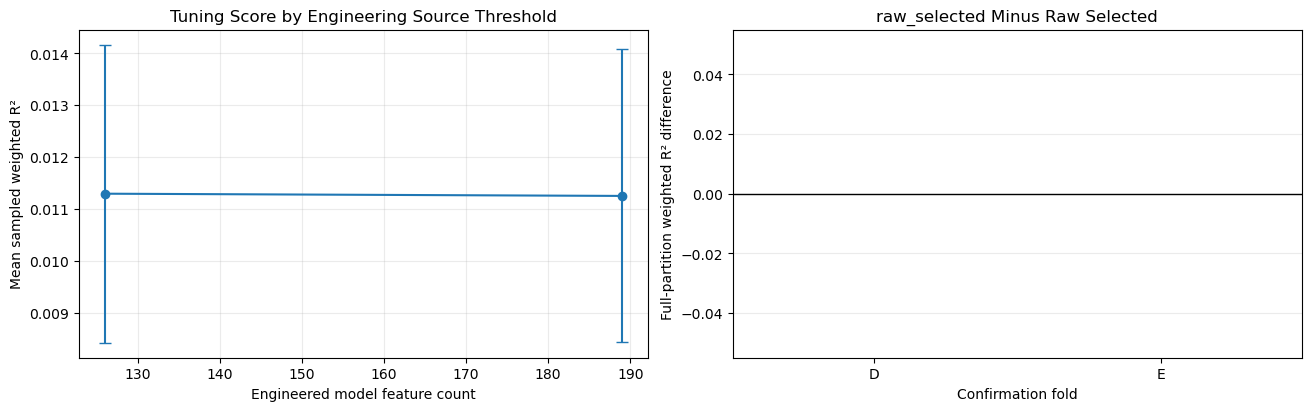

In [13]:
if RUN_FULL_PHASE5_PIPELINE:
    source_plot_data = phase5_results["threshold_summary"].copy()
    confirmation_plot_data = phase5_results["confirmation_comparison"].copy()
    final_candidate = phase5_results["decision"]["selected_candidate"]
elif phase5_decision_path.exists():
    source_plot_data = phase5_saved_threshold_summary.copy()
    confirmation_plot_data = phase5_saved_confirmation.copy()
    final_candidate = phase5_saved_decision["selected_candidate"]
else:
    source_plot_data = None

if source_plot_data is not None:
    source_plot_data = source_plot_data.sort_values("mean_feature_count")
    fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)

    axes[0].errorbar(
        source_plot_data["mean_feature_count"],
        source_plot_data["mean_weighted_r2"],
        yerr=source_plot_data["standard_error"],
        marker="o",
        capsize=4,
    )
    axes[0].set_title("Tuning Score by Engineering Source Threshold")
    axes[0].set_xlabel("Engineered model feature count")
    axes[0].set_ylabel("Mean sampled weighted R²")
    axes[0].grid(alpha=0.25)

    axes[1].bar(
        confirmation_plot_data["fold"],
        confirmation_plot_data["selected_minus_raw_selected"],
    )
    axes[1].axhline(0.0, color="black", linewidth=1.0)
    axes[1].set_title(f"{final_candidate} Minus Raw Selected")
    axes[1].set_xlabel("Confirmation fold")
    axes[1].set_ylabel("Full-partition weighted R² difference")
    axes[1].grid(axis="y", alpha=0.25)

    plt.show()
else:
    print("Run the full Phase 5 pipeline before plotting diagnostics.")


## Phase 5 Summary and Decision

### Objective

Phase 5 tested whether a small, predeclared collection of leakage-safe engineered features and missing-value treatments could improve the Phase 4 LightGBM baseline. All selection decisions used chronological tuning folds A-C. Locked folds D-E were reserved for confirmation, and `part-9.parquet` was not read during this phase.

### Feature construction and leakage controls

- Engineering source columns were chosen from cumulative LightGBM gain thresholds rather than from an arbitrary fixed Top-N rule. Correlated substitutes identified during Phase 3 were retained together for testing.
- The selected 35% cumulative-gain source threshold produced 11 source features. The 50% alternative used 20 source features but did not improve the mean tuning score.
- Cross-sectional means and standard deviations were computed separately within each `(date_id, time_id)` group.
- Sequential lags 1, 2, and 5 and EWM features with spans 20 and 100 were generated within `symbol_id`, in chronological order, using past observations only.
- Context features recorded raw `time_id`, time as a fraction of the applicable daily grid, and the grid regime before or after `date_id = 677`.
- Native LightGBM NaN handling was compared directly with strictly historical symbol-level forward filling plus missingness indicators. No backward filling or future-fitted imputation statistic was used. Initial missing values remained NaN rather than being forced to zero without validation evidence.
- Automated tests checked chronological order, symbol isolation, past-only lag and EWM construction, cross-sectional grouping, and time-grid normalization.

### Chronological tuning results

Mean sampled weighted zero-mean R^2 across folds A-C was 0.010088 for raw 79 features, 0.009902 for the Phase 4 selected 46 raw features, 0.011372 for cross-sectional features, 0.010425 for sequential features, 0.011294 for all engineered features with native NaNs, and 0.011230 for historical forward filling. Cross-sectional features had the highest mean score, but their advantage was smaller than the uncertainty estimated across the three tuning folds.

The one-standard-error rule therefore retained the simpler Phase 4 baseline with 46 raw features. This is a conservative model-selection decision: it does not prove that the engineered features contain no information; it means that the fast experiment did not demonstrate a sufficiently stable out-of-sample improvement.

### Locked confirmation and final decision

On the full confirmation partitions in the Phase 5 fast run, the 46-feature baseline scored 0.007238 on fold D and 0.008780 on fold E. The raw-79 reference scored 0.007139 and 0.009165 respectively. The ordering reversed across folds, so the evidence does not support claiming a robust advantage for either raw feature count in this smaller 1% training-sample run.

The principal benchmark remains the Phase 4 locked 46-feature LightGBM result, which scored 0.009571 on fold D and 0.011182 on fold E, for a mean full-partition weighted zero-mean R^2 of 0.010376. Phase 5 used a smaller training sample for feature screening, so its absolute scores should not be compared directly with the Phase 4 benchmark.

**Decision:** carry the 46 raw Phase 4 features forward as the current model input. Do not add the tested cross-sectional, sequential, EWM, contextual, forward-fill, or missingness-indicator features to the locked model yet. Preserve the Phase 5 evidence so that the strongest candidate, cross-sectional statistics, can be revisited only if a later, predeclared larger-sample confirmation is justified.

# Phase 6: Data-Regime and Volatility Diagnostics

## 6.1 Research question

The tutor's “first 100 dates” suggestion is treated as a hypothesis, not a fixed deletion rule. We first measure several distinct quantities:

- **within-date target amplitude:** weighted RMS of `responder_6`, aligned with the denominator of the official metric;
- **within-date dispersion:** weighted standard deviation around that date's weighted mean;
- **between-date instability:** rolling standard deviation of daily weighted target means;
- **tail stress:** weighted frequency of clipped boundary values at ±5.

Partition 9 is excluded from this diagnostic and from cutoff selection. A candidate starting date must be generated from the earlier discovery period and then evaluated with identical chronological validation periods, features, parameters, rounds, seeds, and weights.


Reused: <PROJECT_ROOT>\artifacts\phase6\daily_target_volatility.csv


,value
candidate_start_date,120.000000
earlier_last_date,119.000000
earlier_mean_weighted_rms,0.747703
later_mean_weighted_rms,0.889885
sse_reduction_fraction,0.109057
discovery_end_date,679.000000


,date_id,weighted_rms,weighted_std,weighted_mean_abs,weighted_boundary_rate
790,790,2.165707,2.164497,1.653606,0.060596
778,778,1.979184,1.978167,1.456736,0.053004
398,398,1.944899,1.943110,1.311843,0.072935
399,399,1.871335,1.869888,1.390063,0.035373
788,788,1.863626,1.856144,1.373365,0.036029
553,553,1.832352,1.805343,1.336327,0.034601
552,552,1.804910,1.779540,1.308501,0.034194
787,787,1.784874,1.784011,1.300990,0.031867
1246,1246,1.670795,1.513209,0.955465,0.023065
786,786,1.617271,1.615433,1.172355,0.024087


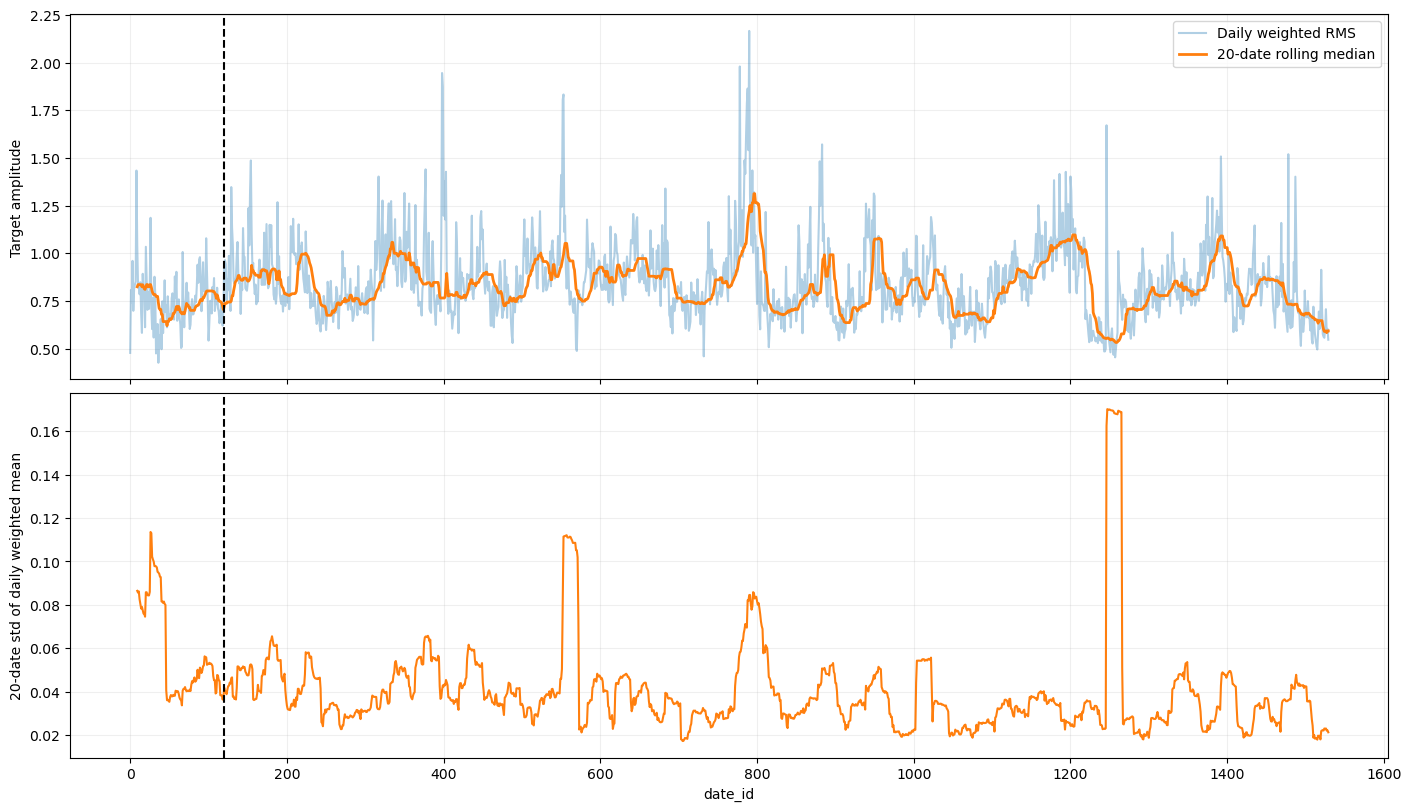

In [35]:
# Complete daily target-volatility scan; only three columns are streamed.
def compute_daily_target_volatility(partition_files, batch_size=500_000):
    daily_parts = []
    for file_path in partition_files:
        batch_summaries = []
        parquet_file = pq.ParquetFile(file_path)
        for batch in parquet_file.iter_batches(
            batch_size=batch_size,
            columns=["date_id", "responder_6", "weight"],
        ):
            frame = batch.to_pandas()
            y = frame["responder_6"].to_numpy(dtype=np.float64, copy=False)
            w = frame["weight"].to_numpy(dtype=np.float64, copy=False)
            frame["wy"] = w * y
            frame["wy2"] = w * y**2
            frame["wabs"] = w * np.abs(y)
            frame["wboundary"] = w * (np.abs(y) >= 5.0 - 1e-12)
            grouped = frame.groupby("date_id", sort=False).agg(
                rows=("responder_6", "size"),
                weight_sum=("weight", "sum"),
                sum_wy=("wy", "sum"),
                sum_wy2=("wy2", "sum"),
                sum_wabs=("wabs", "sum"),
                sum_wboundary=("wboundary", "sum"),
            )
            batch_summaries.append(grouped)

        daily_part = pd.concat(batch_summaries).groupby(level=0).sum()
        daily_parts.append(daily_part)
        print("Finished:", file_path.name)

    daily = pd.concat(daily_parts).groupby(level=0).sum().sort_index().reset_index()
    daily["weighted_mean"] = daily["sum_wy"] / daily["weight_sum"]
    daily["weighted_rms"] = np.sqrt(daily["sum_wy2"] / daily["weight_sum"])
    daily["weighted_std"] = np.sqrt(np.maximum(
        daily["sum_wy2"] / daily["weight_sum"] - daily["weighted_mean"]**2,
        0.0,
    ))
    daily["weighted_mean_abs"] = daily["sum_wabs"] / daily["weight_sum"]
    daily["weighted_boundary_rate"] = daily["sum_wboundary"] / daily["weight_sum"]
    daily["log_weighted_rms"] = np.log(daily["weighted_rms"].clip(lower=1e-12))
    daily["rolling_20d_median_rms"] = daily["weighted_rms"].rolling(
        20, min_periods=10
    ).median()
    daily["rolling_20d_daily_mean_std"] = daily["weighted_mean"].rolling(
        20, min_periods=10
    ).std()
    return daily


def best_single_log_volatility_break(daily, discovery_end=679, min_segment=30):
    discovery = daily.loc[daily["date_id"].le(discovery_end)].copy()
    x = discovery["log_weighted_rms"].to_numpy(dtype=np.float64)
    dates = discovery["date_id"].to_numpy(dtype=np.int64)
    prefix = np.concatenate(([0.0], np.cumsum(x)))
    prefix2 = np.concatenate(([0.0], np.cumsum(x * x)))

    def segment_sse(left, right):
        count = right - left
        total = prefix[right] - prefix[left]
        total2 = prefix2[right] - prefix2[left]
        return float(total2 - total**2 / count)

    one_regime_sse = segment_sse(0, len(x))
    candidates = []
    for cut in range(min_segment, len(x) - min_segment + 1):
        two_regime_sse = segment_sse(0, cut) + segment_sse(cut, len(x))
        candidates.append((one_regime_sse - two_regime_sse, cut))

    gain, cut = max(candidates)
    return pd.Series({
        "candidate_start_date": int(dates[cut]),
        "earlier_last_date": int(dates[cut - 1]),
        "earlier_mean_weighted_rms": discovery.iloc[:cut]["weighted_rms"].mean(),
        "later_mean_weighted_rms": discovery.iloc[cut:]["weighted_rms"].mean(),
        "sse_reduction_fraction": gain / one_regime_sse,
        "discovery_end_date": discovery_end,
    })


phase6_artifact_dir = project_root / "artifacts" / "phase6"
phase6_artifact_dir.mkdir(parents=True, exist_ok=True)
phase6_daily_path = phase6_artifact_dir / "daily_target_volatility.csv"

RUN_PHASE6_VOLATILITY_SCAN = False  # Set True to recompute from the Parquet files.
if RUN_PHASE6_VOLATILITY_SCAN or not phase6_daily_path.exists():
    phase6_daily_volatility = compute_daily_target_volatility(partition_files[:9])
    phase6_daily_volatility.to_csv(phase6_daily_path, index=False)
else:
    phase6_daily_volatility = pd.read_csv(phase6_daily_path)
    print("Reused:", phase6_daily_path)

# Discard any legacy descriptive rows from part-9 before analysis.
phase6_daily_volatility = phase6_daily_volatility.loc[
    phase6_daily_volatility["date_id"].le(1529)
].copy()
phase6_daily_volatility.to_csv(phase6_daily_path, index=False)
assert phase6_daily_volatility["date_id"].max() == 1529

phase6_break = best_single_log_volatility_break(
    phase6_daily_volatility,
    discovery_end=679,
    min_segment=30,
)
display(phase6_break.to_frame("value"))

development_volatility = phase6_daily_volatility.loc[
    phase6_daily_volatility["date_id"].le(1529)
]
display(
    development_volatility.nlargest(20, "weighted_rms")[[
        "date_id", "weighted_rms", "weighted_std",
        "weighted_mean_abs", "weighted_boundary_rate",
    ]]
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, constrained_layout=True)
axes[0].plot(
    phase6_daily_volatility["date_id"],
    phase6_daily_volatility["weighted_rms"],
    alpha=0.35,
    label="Daily weighted RMS",
)
axes[0].plot(
    phase6_daily_volatility["date_id"],
    phase6_daily_volatility["rolling_20d_median_rms"],
    linewidth=2,
    label="20-date rolling median",
)
axes[0].set_ylabel("Target amplitude")
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].plot(
    phase6_daily_volatility["date_id"],
    phase6_daily_volatility["rolling_20d_daily_mean_std"],
    color="tab:orange",
)
axes[1].set_ylabel("20-date std of daily weighted mean")
axes[1].set_xlabel("date_id")
axes[1].grid(alpha=0.2)

candidate_cut = int(phase6_break["candidate_start_date"])
for axis in axes:
    axis.axvline(candidate_cut, color="black", linestyle="--", label="discovery change point")

plt.show()


### 6.1 Initial result and next validation decision

The completed scan does **not** support the simple claim that all of the first 100 dates have the highest target volatility. Dates 0–49 and 50–99 have relatively low within-date weighted RMS, although dates 0–49 show comparatively unstable daily weighted means. The strongest sustained within-date target amplitude in the development period occurs around dates 750–799, with isolated spikes around 398–399, 552–553, 778–790, and 1246.

A one-break discovery scan over dates 0–679 identifies a change near `date_id = 120`, but the later regime has *higher*, not lower, weighted RMS. Therefore this is evidence of a regime change, not evidence that the earlier rows are bad.

The next model comparison should use candidate starting dates generated by these diagnostics—initially `0` (keep all), `50` (end of the early daily-mean instability), and `120` (estimated amplitude change point). Candidate selection will use folds A–C only; the chosen rule will then be checked once on folds D–E. Individual high-volatility dates will not be deleted merely because they are volatile.


## 6.2 Experimental contract: data start, training length, and ensemble

Phase 6 freezes the Phase 5 winner—46 raw features, the selected LightGBM parameters, 254 boosting rounds, one-date gap, and the same 1% deterministic sample—and changes only one modeling decision at a time.

Selection protocol:

1. **Starting-date selection:** compare data-derived candidate starting dates on tuning folds A–C.
2. **Training-window selection:** with the chosen starting-date rule fixed, compare recent 340 dates, recent 680 dates, and all available history on the same validation dates.
3. **Ensemble selection:** compare the selected single model with equal-weight short/long, three-window, and three-seed ensembles.
4. **Single confirmation:** evaluate the complete preselected configuration against the original Phase 5 baseline on folds D–E.

Models are combined at the prediction level before weighted R² is calculated. Scores themselves are never averaged. Partition 9 is excluded from all Phase 6 diagnostics, selection, and confirmation.


In [7]:
# [P7-PRE-3] Fresh-kernel prerequisite: locked decisions and sample cache
# Freeze the Phase 5 model before testing Phase 6 hypotheses.
phase4_decision = json.loads(
    (phase4_artifact_dir / "phase4_decision.json").read_text(encoding="utf-8")
)
phase5_decision = json.loads(
    (phase5_artifact_dir / "phase5_decision.json").read_text(encoding="utf-8")
)

assert phase5_decision["selected_candidate"] == "raw_selected"
PHASE6_FEATURES = list(phase5_decision["selected_features"])
PHASE6_PARAMETERS = dict(phase4_decision["selected_parameters"])
PHASE6_LOCKED_ROUNDS = int(phase4_decision["locked_boost_rounds"])
PHASE6_BASE_SEED = int(phase5_decision["seed"])
PHASE6_SEEDS = (PHASE6_BASE_SEED, PHASE6_BASE_SEED + 1000, PHASE6_BASE_SEED + 2000)
PHASE6_WINDOW_DATES = {
    "recent_340_dates": 340,   # approximately two existing partitions
    "recent_680_dates": 680,   # approximately four existing partitions
    "expanding_history": None,
}


def best_single_series_break(daily, column, discovery_end=679, min_segment=30):
    """Find the one-break split with the largest within-segment SSE reduction."""

    discovery = daily.loc[
        daily["date_id"].le(discovery_end), ["date_id", column]
    ].dropna()
    x = discovery[column].to_numpy(dtype=np.float64)
    dates = discovery["date_id"].to_numpy(dtype=np.int64)
    prefix = np.concatenate(([0.0], np.cumsum(x)))
    prefix2 = np.concatenate(([0.0], np.cumsum(x * x)))

    def segment_sse(left, right):
        count = right - left
        total = prefix[right] - prefix[left]
        total2 = prefix2[right] - prefix2[left]
        return float(total2 - total**2 / count)

    one_regime_sse = segment_sse(0, len(x))
    candidates = []
    for cut in range(min_segment, len(x) - min_segment + 1):
        split_sse = segment_sse(0, cut) + segment_sse(cut, len(x))
        candidates.append((one_regime_sse - split_sse, cut))

    gain, cut = max(candidates)
    return {
        "column": column,
        "candidate_start_date": int(dates[cut]),
        "earlier_last_date": int(dates[cut - 1]),
        "earlier_mean": float(x[:cut].mean()),
        "later_mean": float(x[cut:].mean()),
        "sse_reduction_fraction": float(gain / one_regime_sse),
    }


phase6_daily_path = project_root / "artifacts" / "phase6" / "daily_target_volatility.csv"
phase6_daily_volatility = pd.read_csv(phase6_daily_path)
phase6_amplitude_break = best_single_series_break(
    phase6_daily_volatility,
    "log_weighted_rms",
)
phase6_daily_mean_break = best_single_series_break(
    phase6_daily_volatility,
    "rolling_20d_daily_mean_std",
)
PHASE6_START_DATES = sorted({
    0,
    phase6_daily_mean_break["candidate_start_date"],
    phase6_amplitude_break["candidate_start_date"],
})


def locate_phase5_sample_cache(phase5_dir, decision):
    """Resolve the exact saved Phase 5 cache instead of silently rebuilding data."""

    matches = []
    for directory in phase5_dir.glob("cache_*"):
        config_path = directory / "cache_configuration.json"
        if not config_path.exists():
            continue
        config = json.loads(config_path.read_text(encoding="utf-8"))
        profile = config.get("profile", {})
        if (
            profile.get("name") == decision["profile"]["name"]
            and np.isclose(profile.get("sample_fraction"), decision["profile"]["sample_fraction"])
            and config.get("seed") == decision["seed"]
        ):
            matches.append(directory)
    if len(matches) != 1:
        raise RuntimeError(f"Expected one matching Phase 5 cache, found {len(matches)}")
    return matches[0]


phase6_cache_dir = locate_phase5_sample_cache(phase5_artifact_dir, phase5_decision)
phase6_cache_paths = {
    partition: phase6_cache_dir / f"sample-part-{partition}.parquet"
    for partition in range(9)
}
assert all(path.exists() for path in phase6_cache_paths.values())

phase6_fold_table = build_fold_table(
    partition_files,
    gap_dates=int(phase5_decision["gap_dates"]),
)
phase6_tuning_folds = phase6_fold_table.loc[
    phase6_fold_table["role"].eq("tuning")
].copy()
phase6_confirmation_folds = phase6_fold_table.loc[
    phase6_fold_table["role"].eq("confirmation")
].copy()

display(pd.DataFrame([phase6_daily_mean_break, phase6_amplitude_break]))
display(phase6_fold_table)
print("Data-derived starting dates:", PHASE6_START_DATES)
print("Frozen feature count:", len(PHASE6_FEATURES))
print("Frozen boosting rounds:", PHASE6_LOCKED_ROUNDS)
print("Reused sample cache:", phase6_cache_dir)


,column,candidate_start_date,earlier_last_date,earlier_mean,later_mean,sse_reduction_fraction
0,rolling_20d_daily_mean_std,46,45,0.088375,0.043306,0.326775
1,log_weighted_rms,120,119,-0.308885,-0.135234,0.109057


,fold,role,train_end_part,valid_part,train_parts,train_min_date,train_max_date_after_gap,gap_dates,valid_file,valid_min_date,valid_max_date,approx_train_rows_before_gap,valid_rows
0,A,tuning,3,4,0-3,0,678,1,part-4.parquet,680,849,11802114,5022952
1,B,tuning,4,5,0-4,0,848,1,part-5.parquet,850,1019,16825066,5348200
2,C,tuning,5,6,0-5,0,1018,1,part-6.parquet,1020,1189,22173266,6203912
3,D,confirmation,6,7,0-6,0,1188,1,part-7.parquet,1190,1359,28377178,6335560
4,E,confirmation,7,8,0-7,0,1358,1,part-8.parquet,1360,1529,34712738,6140024


Data-derived starting dates: [0, 46, 120]
Frozen feature count: 46
Frozen boosting rounds: 254
Reused sample cache: <PROJECT_ROOT>\artifacts\phase5\cache_fast_0p01_seed42_sources20_0790756454


## 6.3 Visible training and full-validation scoring

The next cell contains the Phase 6 training path. It reads the saved deterministic sample, applies the candidate date boundary, calls the notebook-defined `train_model(...)`, and scores every row in the original validation partition. Ensemble predictions are created inside the same streaming pass.


In [9]:
# [P7-PRE-4] Fresh-kernel prerequisite: Phase 6 fit and scoring helpers
def phase6_training_bounds(fold_row, start_date, window_dates):
    train_end_date = int(fold_row["train_max_date_after_gap"])
    effective_start = int(start_date)
    if window_dates is not None:
        effective_start = max(effective_start, train_end_date - int(window_dates) + 1)
    if effective_start > train_end_date:
        raise ValueError("The requested training window contains no dates.")
    return effective_start, train_end_date


def load_phase6_fold_sample(fold_row, start_date, window_dates):
    """Load one sampled train/validation pair with strict chronological bounds."""

    columns = [DATE_COLUMN, *PHASE6_FEATURES, TARGET_COLUMN, WEIGHT_COLUMN]
    effective_start, train_end = phase6_training_bounds(
        fold_row, start_date, window_dates
    )
    training_parts = []
    for partition in range(int(fold_row["train_end_part"]) + 1):
        frame = pd.read_parquet(phase6_cache_paths[partition], columns=columns)
        frame = frame.loc[frame[DATE_COLUMN].between(effective_start, train_end)]
        if not frame.empty:
            training_parts.append(frame)
    if not training_parts:
        raise ValueError("No sampled training rows remain after the date filters.")

    training = pd.concat(training_parts, ignore_index=True)
    validation = pd.read_parquet(
        phase6_cache_paths[int(fold_row["valid_part"])],
        columns=columns,
    )
    if training[DATE_COLUMN].max() >= validation[DATE_COLUMN].min():
        raise AssertionError("Training dates overlap the validation period.")
    return training, validation, effective_start, train_end


def fit_phase6_model(fold_row, start_date, window_dates, seed):
    """Fit one model; the actual lgb.train call is visible in Phase 5.1.1."""

    training, validation, effective_start, train_end = load_phase6_fold_sample(
        fold_row,
        start_date=start_date,
        window_dates=window_dates,
    )
    phase4_profile = Phase4Profile(**phase4_decision["profile"])
    model, details = train_model(
        training_frame=training,
        validation_frame=validation,
        feature_columns=PHASE6_FEATURES,
        candidate_parameters=PHASE6_PARAMETERS,
        profile=phase4_profile,
        seed=int(seed),
        num_threads=PHASE5_NUM_THREADS,
        fixed_rounds=PHASE6_LOCKED_ROUNDS,
    )
    details.update({
        "requested_start_date": int(start_date),
        "effective_train_start_date": int(effective_start),
        "effective_train_end_date": int(train_end),
        "window_dates": None if window_dates is None else int(window_dates),
        "seed": int(seed),
    })
    del training, validation
    gc.collect()
    return model, details


def score_phase6_outputs(models, output_definitions, validation_file, batch_size=200_000):
    """Combine predictions first and then calculate the official weighted R²."""

    for output_name, weights_by_model in output_definitions.items():
        if not weights_by_model:
            raise ValueError(f"{output_name} has no component models.")
        if not set(weights_by_model).issubset(models):
            raise KeyError(f"{output_name} references an unavailable model.")
        total_weight = float(sum(weights_by_model.values()))
        if not np.isclose(total_weight, 1.0):
            raise ValueError(f"{output_name} ensemble weights must sum to one.")

    numerators = {name: 0.0 for name in output_definitions}
    denominator = 0.0
    observed_rows = 0
    started = time.perf_counter()
    columns = [*PHASE6_FEATURES, TARGET_COLUMN, WEIGHT_COLUMN]
    parquet_file = pq.ParquetFile(validation_file)

    for batch in parquet_file.iter_batches(batch_size=batch_size, columns=columns):
        frame = batch.to_pandas()
        y_true = frame[TARGET_COLUMN].to_numpy(dtype=np.float64, copy=False)
        weights = frame[WEIGHT_COLUMN].to_numpy(dtype=np.float64, copy=False)
        if not np.isfinite(y_true).all():
            raise ValueError("Validation target contains a non-finite value.")
        if not np.isfinite(weights).all() or (weights <= 0).any():
            raise ValueError("Validation weights must be finite and positive.")

        model_predictions = {}
        for model_name, model in models.items():
            iteration = (
                int(model.best_iteration)
                if model.best_iteration and model.best_iteration > 0
                else int(model.current_iteration())
            )
            model_predictions[model_name] = model.predict(
                frame[PHASE6_FEATURES], num_iteration=iteration
            )

        for output_name, weights_by_model in output_definitions.items():
            prediction = sum(
                component_weight * model_predictions[model_name]
                for model_name, component_weight in weights_by_model.items()
            )
            numerators[output_name] += np.sum(
                weights * (y_true - prediction) ** 2,
                dtype=np.float64,
            )
        denominator += np.sum(weights * y_true**2, dtype=np.float64)
        observed_rows += len(frame)

    elapsed = time.perf_counter() - started
    expected_rows = pq.ParquetFile(validation_file).metadata.num_rows
    if observed_rows != expected_rows:
        raise AssertionError("Full validation scoring missed rows.")
    return pd.DataFrame([
        {
            "candidate": name,
            "full_weighted_r2": float(1.0 - numerator / denominator),
            "full_validation_rows": int(observed_rows),
            "full_scoring_seconds": elapsed,
        }
        for name, numerator in numerators.items()
    ])


def summarize_phase6_scores(results):
    summary = (
        results.groupby("candidate", as_index=False)
        .agg(
            mean_full_weighted_r2=("full_weighted_r2", "mean"),
            std_full_weighted_r2=("full_weighted_r2", "std"),
            minimum_full_weighted_r2=("full_weighted_r2", "min"),
            mean_training_sample_weighted_r2=("training_sample_weighted_r2", "mean"),
            mean_train_minus_full_validation_r2=(
                "training_sample_minus_full_validation_r2", "mean"
            ),
            mean_training_rows=("train_rows", "mean"),
            total_training_seconds=("training_seconds", "sum"),
            fold_count=("fold", "nunique"),
        )
    )
    summary["standard_error"] = (
        summary["std_full_weighted_r2"] / np.sqrt(summary["fold_count"])
    )
    return summary.sort_values(
        ["mean_full_weighted_r2", "minimum_full_weighted_r2"],
        ascending=[False, False],
    ).reset_index(drop=True)


def evaluate_phase6_model_specs(specs, folds, stage):
    """Fit all candidate models per fold and score them in one full-data pass."""

    records = []
    for fold_tuple in folds.itertuples(index=False):
        fold_row = pd.Series(fold_tuple._asdict())
        models = {}
        details_by_candidate = {}
        for spec in specs:
            print(f"[{stage}] fold {fold_row['fold']} | {spec['candidate']}")
            model, details = fit_phase6_model(
                fold_row,
                start_date=spec["start_date"],
                window_dates=spec["window_dates"],
                seed=spec["seed"],
            )
            models[spec["candidate"]] = model
            details_by_candidate[spec["candidate"]] = {**spec, **details}

        output_definitions = {
            candidate: {candidate: 1.0} for candidate in models
        }
        validation_file = partition_files[int(fold_row["valid_part"])]
        full_scores = score_phase6_outputs(
            models,
            output_definitions,
            validation_file,
        ).set_index("candidate")

        for candidate, details in details_by_candidate.items():
            full = full_scores.loc[candidate].to_dict()
            records.append({
                "stage": stage,
                "fold": fold_row["fold"],
                "role": fold_row["role"],
                "valid_file": fold_row["valid_file"],
                **details,
                **full,
                "training_sample_minus_full_validation_r2": (
                    details["training_sample_weighted_r2"]
                    - full["full_weighted_r2"]
                ),
            })
        del models
        gc.collect()
    return pd.DataFrame(records)


## 6.4 A–C selection stages and one D–E confirmation

The following functions implement the complete research sequence. The one-standard-error rule prevents a tiny noisy difference from automatically justifying deletion or a more complicated ensemble.


In [42]:
def select_start_date(cutoff_summary, cutoff_results):
    best = cutoff_summary.iloc[0]
    score_floor = best["mean_full_weighted_r2"] - best["standard_error"]
    eligible = cutoff_summary.loc[
        cutoff_summary["mean_full_weighted_r2"].ge(score_floor)
    ].copy()
    start_lookup = (
        cutoff_results[["candidate", "requested_start_date"]]
        .drop_duplicates()
        .set_index("candidate")["requested_start_date"]
    )
    eligible["requested_start_date"] = eligible["candidate"].map(start_lookup)
    # Conservatively retain more history unless deletion is clearly better.
    return eligible.sort_values(
        ["requested_start_date", "minimum_full_weighted_r2"],
        ascending=[True, False],
    ).iloc[0]


def select_training_window(window_summary, window_results):
    best = window_summary.iloc[0]
    score_floor = best["mean_full_weighted_r2"] - best["standard_error"]
    eligible = window_summary.loc[
        window_summary["mean_full_weighted_r2"].ge(score_floor)
    ].copy()
    window_lookup = (
        window_results[["candidate", "window_dates"]]
        .drop_duplicates()
        .set_index("candidate")["window_dates"]
    )
    eligible["window_dates"] = eligible["candidate"].map(window_lookup)
    eligible["window_complexity"] = eligible["window_dates"].fillna(np.inf)
    # First protect the worst fold; then prefer a shorter viable history.
    return eligible.sort_values(
        ["minimum_full_weighted_r2", "window_complexity"],
        ascending=[False, True],
    ).iloc[0]


def phase6_model_name(start_date, window_label, seed):
    return f"start{int(start_date)}__{window_label}__seed{int(seed)}"


def evaluate_phase6_ensembles(
    folds,
    selected_start_date,
    selected_window_label,
    stage,
    include_original_baseline=False,
):
    """Fit required component models and score candidate ensembles per fold."""

    records = []
    selected_window_dates = PHASE6_WINDOW_DATES[selected_window_label]
    for fold_tuple in folds.itertuples(index=False):
        fold_row = pd.Series(fold_tuple._asdict())
        component_specs = []

        for window_label, window_dates in PHASE6_WINDOW_DATES.items():
            component_specs.append({
                "start_date": int(selected_start_date),
                "window_label": window_label,
                "window_dates": window_dates,
                "seed": PHASE6_BASE_SEED,
            })
        for seed in PHASE6_SEEDS[1:]:
            component_specs.append({
                "start_date": int(selected_start_date),
                "window_label": selected_window_label,
                "window_dates": selected_window_dates,
                "seed": seed,
            })
        if include_original_baseline:
            component_specs.append({
                "start_date": 0,
                "window_label": "expanding_history",
                "window_dates": None,
                "seed": PHASE6_BASE_SEED,
            })

        unique_specs = {}
        for spec in component_specs:
            name = phase6_model_name(
                spec["start_date"], spec["window_label"], spec["seed"]
            )
            unique_specs[name] = spec

        models = {}
        training_details = {}
        for name, spec in unique_specs.items():
            print(f"[{stage}] fold {fold_row['fold']} | component {name}")
            model, details = fit_phase6_model(
                fold_row,
                start_date=spec["start_date"],
                window_dates=spec["window_dates"],
                seed=spec["seed"],
            )
            models[name] = model
            training_details[name] = details

        selected_single = phase6_model_name(
            selected_start_date, selected_window_label, PHASE6_BASE_SEED
        )
        short_model = phase6_model_name(
            selected_start_date, "recent_340_dates", PHASE6_BASE_SEED
        )
        medium_model = phase6_model_name(
            selected_start_date, "recent_680_dates", PHASE6_BASE_SEED
        )
        long_model = phase6_model_name(
            selected_start_date, "expanding_history", PHASE6_BASE_SEED
        )
        seed_models = [
            phase6_model_name(selected_start_date, selected_window_label, seed)
            for seed in PHASE6_SEEDS
        ]

        output_definitions = {
            "selected_single": {selected_single: 1.0},
            "short_long_equal": {short_model: 0.5, long_model: 0.5},
            "three_windows_equal": {
                short_model: 1 / 3,
                medium_model: 1 / 3,
                long_model: 1 / 3,
            },
            "three_seeds_equal": {name: 1 / 3 for name in seed_models},
        }
        if include_original_baseline:
            original_model = phase6_model_name(
                0, "expanding_history", PHASE6_BASE_SEED
            )
            output_definitions["original_phase5_baseline"] = {
                original_model: 1.0
            }

        validation_file = partition_files[int(fold_row["valid_part"])]
        scores = score_phase6_outputs(
            models,
            output_definitions,
            validation_file,
        )
        total_training_seconds = sum(
            item["training_seconds"] for item in training_details.values()
        )
        for score in scores.to_dict("records"):
            records.append({
                "stage": stage,
                "fold": fold_row["fold"],
                "role": fold_row["role"],
                "valid_file": fold_row["valid_file"],
                "candidate": score["candidate"],
                "full_weighted_r2": score["full_weighted_r2"],
                "full_validation_rows": score["full_validation_rows"],
                "full_scoring_seconds": score["full_scoring_seconds"],
                "unique_component_models": len(models),
                "component_training_seconds": total_training_seconds,
            })
        del models
        gc.collect()
    return pd.DataFrame(records)


def summarize_phase6_ensembles(results):
    summary = (
        results.groupby("candidate", as_index=False)
        .agg(
            mean_full_weighted_r2=("full_weighted_r2", "mean"),
            std_full_weighted_r2=("full_weighted_r2", "std"),
            minimum_full_weighted_r2=("full_weighted_r2", "min"),
            fold_count=("fold", "nunique"),
        )
    )
    summary["standard_error"] = (
        summary["std_full_weighted_r2"] / np.sqrt(summary["fold_count"])
    )
    return summary.sort_values(
        ["mean_full_weighted_r2", "minimum_full_weighted_r2"],
        ascending=[False, False],
    ).reset_index(drop=True)


def select_ensemble(ensemble_summary):
    complexity = {
        "selected_single": 1,
        "short_long_equal": 2,
        "three_windows_equal": 3,
        "three_seeds_equal": 3,
    }
    best = ensemble_summary.iloc[0]
    score_floor = best["mean_full_weighted_r2"] - best["standard_error"]
    eligible = ensemble_summary.loc[
        ensemble_summary["mean_full_weighted_r2"].ge(score_floor)
    ].copy()
    eligible["complexity"] = eligible["candidate"].map(complexity)
    return eligible.sort_values(
        ["complexity", "minimum_full_weighted_r2"],
        ascending=[True, False],
    ).iloc[0]


def run_phase6_pipeline():
    """Run A–C selection, then inspect D–E once for the locked combination."""

    artifact_dir = project_root / "artifacts" / "phase6"
    artifact_dir.mkdir(parents=True, exist_ok=True)
    started = time.perf_counter()

    cutoff_specs = [
        {
            "candidate": f"start_date_{start_date}",
            "start_date": int(start_date),
            "window_dates": None,
            "seed": PHASE6_BASE_SEED,
        }
        for start_date in PHASE6_START_DATES
    ]
    cutoff_results = evaluate_phase6_model_specs(
        cutoff_specs, phase6_tuning_folds, "start_date_selection"
    )
    cutoff_summary = summarize_phase6_scores(cutoff_results)
    selected_cutoff_row = select_start_date(cutoff_summary, cutoff_results)
    selected_start_date = int(selected_cutoff_row["requested_start_date"])

    window_specs = [
        {
            "candidate": window_label,
            "start_date": selected_start_date,
            "window_dates": window_dates,
            "seed": PHASE6_BASE_SEED,
        }
        for window_label, window_dates in PHASE6_WINDOW_DATES.items()
    ]
    window_results = evaluate_phase6_model_specs(
        window_specs, phase6_tuning_folds, "window_selection"
    )
    window_summary = summarize_phase6_scores(window_results)
    selected_window_row = select_training_window(window_summary, window_results)
    selected_window_label = str(selected_window_row["candidate"])

    ensemble_results = evaluate_phase6_ensembles(
        phase6_tuning_folds,
        selected_start_date=selected_start_date,
        selected_window_label=selected_window_label,
        stage="ensemble_selection",
        include_original_baseline=False,
    )
    ensemble_summary = summarize_phase6_ensembles(ensemble_results)
    selected_ensemble_row = select_ensemble(ensemble_summary)
    selected_output = str(selected_ensemble_row["candidate"])

    # D–E are opened once, after all three A–C choices have been frozen.
    confirmation_results = evaluate_phase6_ensembles(
        phase6_confirmation_folds,
        selected_start_date=selected_start_date,
        selected_window_label=selected_window_label,
        stage="locked_confirmation",
        include_original_baseline=True,
    )
    confirmation_pivot = confirmation_results.pivot(
        index="fold", columns="candidate", values="full_weighted_r2"
    ).reset_index()
    confirmation_pivot["selected_minus_original"] = (
        confirmation_pivot[selected_output]
        - confirmation_pivot["original_phase5_baseline"]
    )
    accepted = bool(
        confirmation_pivot["selected_minus_original"].mean() > 0
        and confirmation_pivot["selected_minus_original"].min() >= 0
    )

    decision = {
        "tuning_folds": ["A", "B", "C"],
        "confirmation_folds_opened_once": ["D", "E"],
        "volatility_candidate_start_dates": PHASE6_START_DATES,
        "selected_start_date_on_tuning": selected_start_date,
        "selected_window_on_tuning": selected_window_label,
        "selected_window_dates": PHASE6_WINDOW_DATES[selected_window_label],
        "selected_output_on_tuning": selected_output,
        "confirmation_mean_delta_vs_phase5": float(
            confirmation_pivot["selected_minus_original"].mean()
        ),
        "confirmation_minimum_delta_vs_phase5": float(
            confirmation_pivot["selected_minus_original"].min()
        ),
        "phase6_configuration_accepted": accepted,
        "final_model_configuration": (
            {
                "start_date": selected_start_date,
                "window": selected_window_label,
                "output": selected_output,
            }
            if accepted
            else {
                "start_date": 0,
                "window": "expanding_history",
                "output": "original_phase5_baseline",
            }
        ),
        "feature_count": len(PHASE6_FEATURES),
        "boosting_rounds": PHASE6_LOCKED_ROUNDS,
        "sample_fraction": phase5_decision["profile"]["sample_fraction"],
        "hypotheses_compared": {
            "starting_dates": len(PHASE6_START_DATES),
            "training_windows": len(PHASE6_WINDOW_DATES),
            "ensemble_outputs": 4,
        },
        "part9_status": (
            "part-9.parquet was excluded from Phase 6 volatility diagnostics, "
            "cutoff generation, model selection, and confirmation; it remains "
            "a quasi-holdout because earlier EDA had already inspected it"
        ),
        "total_elapsed_seconds": time.perf_counter() - started,
    }

    cutoff_results.to_csv(artifact_dir / "start_date_tuning_folds.csv", index=False)
    cutoff_summary.to_csv(artifact_dir / "start_date_tuning_summary.csv", index=False)
    window_results.to_csv(artifact_dir / "window_tuning_folds.csv", index=False)
    window_summary.to_csv(artifact_dir / "window_tuning_summary.csv", index=False)
    ensemble_results.to_csv(artifact_dir / "ensemble_tuning_folds.csv", index=False)
    ensemble_summary.to_csv(artifact_dir / "ensemble_tuning_summary.csv", index=False)
    confirmation_results.to_csv(artifact_dir / "locked_confirmation_folds.csv", index=False)
    confirmation_pivot.to_csv(artifact_dir / "locked_confirmation_comparison.csv", index=False)
    _write_json(artifact_dir / "phase6_decision.json", decision)

    return {
        "cutoff_results": cutoff_results,
        "cutoff_summary": cutoff_summary,
        "window_results": window_results,
        "window_summary": window_summary,
        "ensemble_results": ensemble_results,
        "ensemble_summary": ensemble_summary,
        "confirmation_results": confirmation_results,
        "confirmation_comparison": confirmation_pivot,
        "decision": decision,
    }


## 6.5 Runtime estimate and execution

The historical Phase 5 timings provide a conservative planning estimate. Phase 6 trains approximately 45 component models and performs 11 shared full-validation passes. Run the cell once with the full-pipeline flag left `False`, inspect the estimate, then change only that flag to `True` and rerun the same cell.


In [44]:
phase5_confirmation_history = pd.read_csv(
    phase5_artifact_dir / "confirmation_folds.csv"
)
historical_train_seconds = float(
    phase5_confirmation_history.loc[
        phase5_confirmation_history["candidate"].eq("raw_selected"),
        "training_seconds",
    ].median()
)
historical_shared_scoring_seconds = float(
    phase5_confirmation_history.groupby("fold")["full_scoring_seconds"].first().median()
)
historical_models_per_scoring_pass = int(
    phase5_confirmation_history.groupby("fold")["candidate"].nunique().median()
)

phase6_planning_estimate = pd.DataFrame([{
    "planned_component_model_fits": 45,
    "planned_full_validation_passes": 11,
    "historical_seconds_per_model_fit": historical_train_seconds,
    "historical_seconds_per_shared_scoring_pass": historical_shared_scoring_seconds,
    "rough_lower_bound_minutes": (
        45 * historical_train_seconds
        + 11 * historical_shared_scoring_seconds
    ) / 60,
    "conservative_model_equivalent_minutes": (
        45 * historical_train_seconds
        + 45 * historical_shared_scoring_seconds / historical_models_per_scoring_pass
    ) / 60,
    "note": "Actual time depends on cache speed and prediction sharing.",
}])
display(phase6_planning_estimate.round(2))

RUN_FULL_PHASE6_PIPELINE = True

if RUN_FULL_PHASE6_PIPELINE:
    phase6_results = run_phase6_pipeline()
    print("Starting-date selection on folds A-C:")
    display(phase6_results["cutoff_summary"].round(6))
    print("Training-window selection on folds A-C:")
    display(phase6_results["window_summary"].round(6))
    print("Ensemble selection on folds A-C:")
    display(phase6_results["ensemble_summary"].round(6))
    print("Locked confirmation on folds D-E:")
    display(phase6_results["confirmation_comparison"].round(6))
    print("Final Phase 6 decision:")
    display(pd.Series(phase6_results["decision"]))
else:
    print("Phase 6 is ready but not running.")
    print("After reading the estimate, set RUN_FULL_PHASE6_PIPELINE = True and rerun this cell.")


,planned_component_model_fits,planned_full_validation_passes,historical_seconds_per_model_fit,historical_seconds_per_shared_scoring_pass,rough_lower_bound_minutes,conservative_model_equivalent_minutes,note
0,45,11,13.17,103.56,28.86,48.71,Actual time depends on cache speed and predict...


[start_date_selection] fold A | start_date_0
[start_date_selection] fold A | start_date_46
[start_date_selection] fold A | start_date_120
[start_date_selection] fold B | start_date_0
[start_date_selection] fold B | start_date_46
[start_date_selection] fold B | start_date_120
[start_date_selection] fold C | start_date_0
[start_date_selection] fold C | start_date_46
[start_date_selection] fold C | start_date_120
[window_selection] fold A | recent_340_dates
[window_selection] fold A | recent_680_dates
[window_selection] fold A | expanding_history
[window_selection] fold B | recent_340_dates
[window_selection] fold B | recent_680_dates
[window_selection] fold B | expanding_history
[window_selection] fold C | recent_340_dates
[window_selection] fold C | recent_680_dates
[window_selection] fold C | expanding_history
[ensemble_selection] fold A | component start0__recent_340_dates__seed42
[ensemble_selection] fold A | component start0__recent_680_dates__seed42
[ensemble_selection] fold A | co

,candidate,mean_full_weighted_r2,std_full_weighted_r2,minimum_full_weighted_r2,mean_training_sample_weighted_r2,mean_train_minus_full_validation_r2,mean_training_rows,total_training_seconds,fold_count,standard_error
0,start_date_0,0.009915,0.002630,0.007641,0.046367,0.036453,168993.0,21.465026,3,0.001518
1,start_date_46,0.009850,0.002754,0.007585,0.046630,0.036780,164913.0,19.088556,3,0.001590
2,start_date_120,0.009590,0.002403,0.007587,0.047378,0.037788,156558.0,17.891760,3,0.001387


Training-window selection on folds A-C:


,candidate,mean_full_weighted_r2,std_full_weighted_r2,minimum_full_weighted_r2,mean_training_sample_weighted_r2,mean_train_minus_full_validation_r2,mean_training_rows,total_training_seconds,fold_count,standard_error
0,expanding_history,0.009915,0.002630,0.007641,0.046367,0.036453,168993.000000,20.039395,3,0.001518
1,recent_680_dates,0.009439,0.003095,0.006697,0.046621,0.037182,146845.666667,18.000709,3,0.001787
2,recent_340_dates,0.007397,0.002551,0.004737,0.050717,0.043320,88063.333333,12.383879,3,0.001473


...

,candidate,mean_full_weighted_r2,std_full_weighted_r2,minimum_full_weighted_r2,fold_count,standard_error
0,three_seeds_equal,0.010418,0.002634,0.008103,3,0.001521
1,three_windows_equal,0.010090,0.002658,0.007579,3,0.001534
2,selected_single,0.009915,0.002630,0.007641,3,0.001518
3,short_long_equal,0.009864,0.002563,0.007394,3,0.001480


Locked confirmation on folds D-E:


candidate,fold,original_phase5_baseline,selected_single,short_long_equal,three_seeds_equal,three_windows_equal,selected_minus_original
0,D,0.007238,0.007238,0.007708,0.007680,0.007861,0.0
1,E,0.008780,0.008780,0.008560,0.009077,0.009037,0.0


Final Phase 6 decision:


tuning_folds                                                                    [A, B, C]
confirmation_folds_opened_once                                                     [D, E]
volatility_candidate_start_dates                                             [0, 46, 120]
selected_start_date_on_tuning                                                           0
selected_window_on_tuning                                               expanding_history
selected_window_dates                                                                None
selected_output_on_tuning                                                 selected_single
confirmation_mean_delta_vs_phase5                                                     0.0
confirmation_minimum_delta_vs_phase5                                                  0.0
phase6_configuration_accepted                                                       False
final_model_configuration               {'start_date': 0, 'window': 'expanding_history...
feature_co

## 6.6 Reloading saved results and diagnostics

This cell makes the notebook resumable. It loads the completed experiment tables without retraining and plots selection uncertainty and the two locked Phase 6 confirmation-fold deltas.


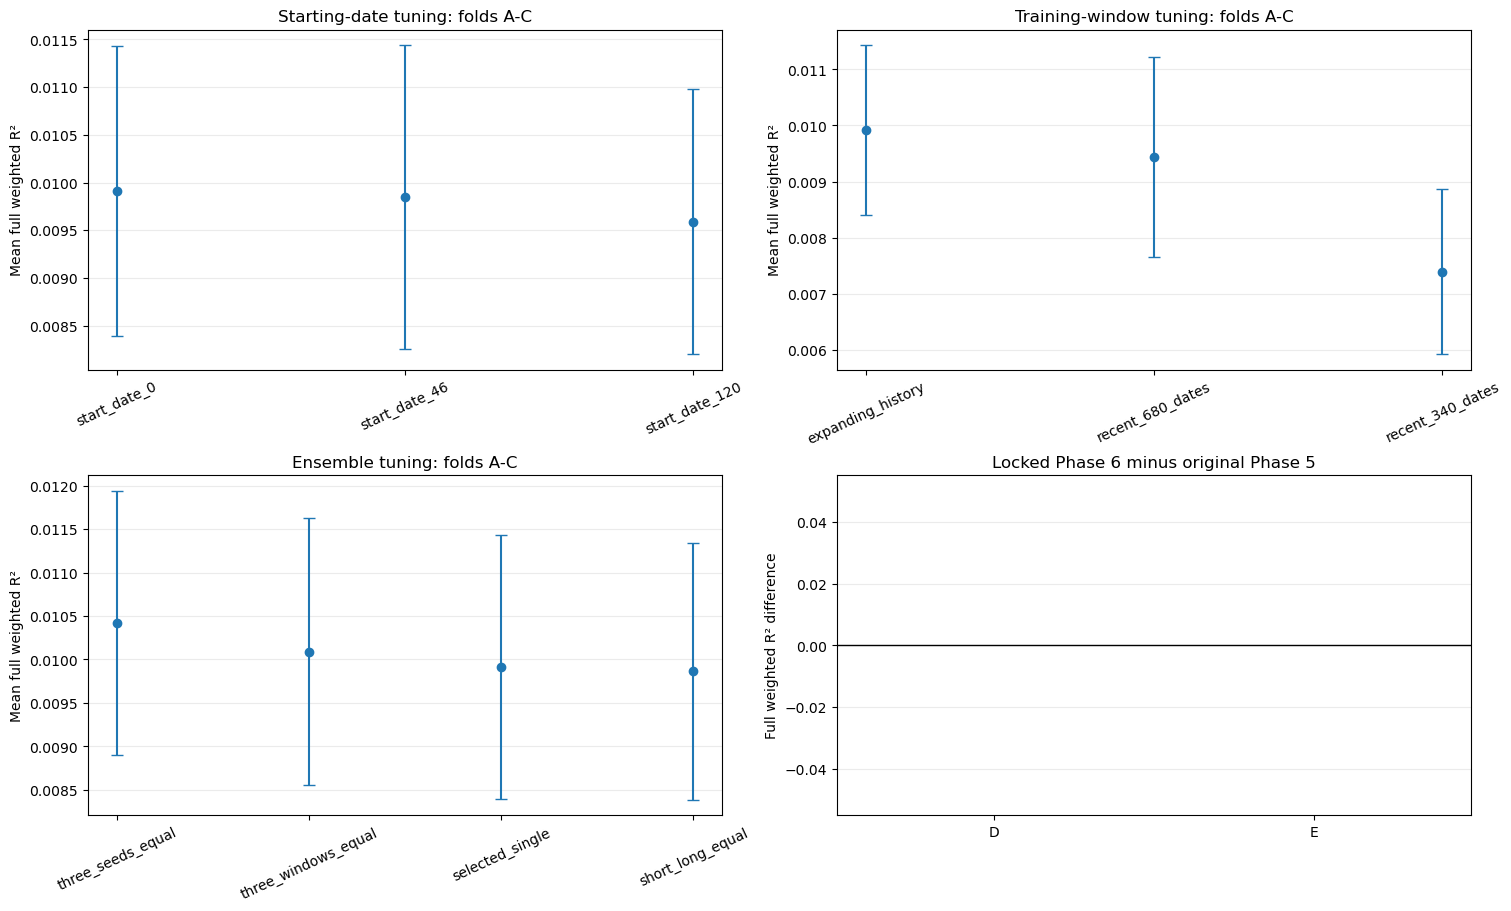

,candidate,mean_full_weighted_r2,std_full_weighted_r2,minimum_full_weighted_r2,mean_training_sample_weighted_r2,mean_train_minus_full_validation_r2,mean_training_rows,total_training_seconds,fold_count,standard_error
0,start_date_0,0.009915,0.002630,0.007641,0.046367,0.036453,168993.0,21.465026,3,0.001518
1,start_date_46,0.009850,0.002754,0.007585,0.046630,0.036780,164913.0,19.088556,3,0.001590
2,start_date_120,0.009590,0.002403,0.007587,0.047378,0.037788,156558.0,17.891760,3,0.001387


,candidate,mean_full_weighted_r2,std_full_weighted_r2,minimum_full_weighted_r2,mean_training_sample_weighted_r2,mean_train_minus_full_validation_r2,mean_training_rows,total_training_seconds,fold_count,standard_error
0,expanding_history,0.009915,0.002630,0.007641,0.046367,0.036453,168993.000000,20.039395,3,0.001518
1,recent_680_dates,0.009439,0.003095,0.006697,0.046621,0.037182,146845.666667,18.000709,3,0.001787
2,recent_340_dates,0.007397,0.002551,0.004737,0.050717,0.043320,88063.333333,12.383879,3,0.001473


,candidate,mean_full_weighted_r2,std_full_weighted_r2,minimum_full_weighted_r2,fold_count,standard_error
0,three_seeds_equal,0.010418,0.002634,0.008103,3,0.001521
1,three_windows_equal,0.010090,0.002658,0.007579,3,0.001534
2,selected_single,0.009915,0.002630,0.007641,3,0.001518
3,short_long_equal,0.009864,0.002563,0.007394,3,0.001480


,fold,original_phase5_baseline,selected_single,short_long_equal,three_seeds_equal,three_windows_equal,selected_minus_original
0,D,0.007238,0.007238,0.007708,0.007680,0.007861,0.0
1,E,0.008780,0.008780,0.008560,0.009077,0.009037,0.0


tuning_folds                                                                    [A, B, C]
confirmation_folds_opened_once                                                     [D, E]
volatility_candidate_start_dates                                             [0, 46, 120]
selected_start_date_on_tuning                                                           0
selected_window_on_tuning                                               expanding_history
selected_window_dates                                                                None
selected_output_on_tuning                                                 selected_single
confirmation_mean_delta_vs_phase5                                                     0.0
confirmation_minimum_delta_vs_phase5                                                  0.0
phase6_configuration_accepted                                                       False
final_model_configuration               {'start_date': 0, 'window': 'expanding_history...
feature_co

In [46]:
phase6_artifact_dir = project_root / "artifacts" / "phase6"
phase6_decision_path = phase6_artifact_dir / "phase6_decision.json"

if phase6_decision_path.exists():
    phase6_saved_cutoff_summary = pd.read_csv(
        phase6_artifact_dir / "start_date_tuning_summary.csv"
    )
    phase6_saved_window_summary = pd.read_csv(
        phase6_artifact_dir / "window_tuning_summary.csv"
    )
    phase6_saved_ensemble_summary = pd.read_csv(
        phase6_artifact_dir / "ensemble_tuning_summary.csv"
    )
    phase6_saved_confirmation = pd.read_csv(
        phase6_artifact_dir / "locked_confirmation_comparison.csv"
    )
    phase6_saved_decision = json.loads(
        phase6_decision_path.read_text(encoding="utf-8")
    )

    fig, axes = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True)
    for axis, table, title in [
        (axes[0, 0], phase6_saved_cutoff_summary, "Starting-date tuning: folds A-C"),
        (axes[0, 1], phase6_saved_window_summary, "Training-window tuning: folds A-C"),
        (axes[1, 0], phase6_saved_ensemble_summary, "Ensemble tuning: folds A-C"),
    ]:
        axis.errorbar(
            table["candidate"],
            table["mean_full_weighted_r2"],
            yerr=table["standard_error"],
            marker="o",
            capsize=4,
            linestyle="none",
        )
        axis.set_title(title)
        axis.set_ylabel("Mean full weighted R²")
        axis.tick_params(axis="x", rotation=25)
        axis.grid(axis="y", alpha=0.25)

    axes[1, 1].bar(
        phase6_saved_confirmation["fold"],
        phase6_saved_confirmation["selected_minus_original"],
    )
    axes[1, 1].axhline(0.0, color="black", linewidth=1)
    axes[1, 1].set_title("Locked Phase 6 minus original Phase 5")
    axes[1, 1].set_ylabel("Full weighted R² difference")
    axes[1, 1].grid(axis="y", alpha=0.25)
    plt.show()

    display(phase6_saved_cutoff_summary.round(6))
    display(phase6_saved_window_summary.round(6))
    display(phase6_saved_ensemble_summary.round(6))
    display(phase6_saved_confirmation.round(6))
    display(pd.Series(phase6_saved_decision))
else:
    print("No completed Phase 6 model comparison has been saved yet.")


## Phase 6 exit criteria and interpretation

Phase 6 is complete only after all of the following are true:

- the starting-date candidates came from documented volatility diagnostics rather than a fixed guess;
- folds A–C alone selected the starting date, training length, and ensemble form;
- the selected complete configuration was opened once on folds D–E;
- train-versus-validation gaps were recorded for every individual model comparison;
- ensemble predictions were averaged before calculating weighted R²;
- the final decision fell back to the original Phase 5 baseline unless the selected configuration improved both confirmation folds on average and did not reduce either fold;
- partition 9 remained unused.

After execution, the written conclusion must distinguish three questions: whether the earliest regime is statistically different, whether excluding it improves out-of-sample prediction, and whether shorter-window or ensemble models reduce instability. A volatility difference alone is not evidence that rows should be deleted.


# Phase 7: Tutor-Requested Target Treatment and Online Validation

## 7.0 Coverage audit and research contract

This phase separates the tutor's remaining requests instead of mixing them with the Phase 6 data-window experiment.

| Tutor request | Status before Phase 7 | Phase 7 treatment |
|---|---|---|
| Data integrity | Complete | Reuse the validated schema, missingness, finite-value, and temporal-order checks |
| PCA | Missing | Fold-local median imputation, standardization, PCA, and chronological comparison |
| Train versus validation weighted R² | Available for the single-target baseline | Record it for every new individual model |
| Optimal training length | Complete in Phase 6 | Reuse the locked expanding-history result |
| Short/long and three-model ensembles | Complete in Phase 6 | Do not repeat |
| Correlated-responder multi-target learning | Missing | Compare a data-derived responder subset with the single-target control |
| All-responder multi-target learning | Missing | Compare all nine responders with the same protocol |
| Residualized return | Missing | Add a cross-sectional residual of responder_6 as an auxiliary target only |
| Simple-target-to-hard-target curriculum | Not identified | Do not invent a difficulty ordering; the tutor explicitly proposed multi-target learning as the alternative |
| Rolling training windows | Complete in Phase 6 | Do not repeat |
| Online updating | Missing | Predict each date before revealing its labels, then update only for later dates |

All model selection remains on folds A–C. Folds D–E are used once per locked Phase 7 experiment. `part-9.parquet` remains untouched by every Phase 7 function.

The official score is always calculated only for `responder_6`. Auxiliary responders are training labels, never contemporaneous input features.
## Phase 7 run map

The cell numbers below refer to the current notebook version. The bracketed run labels are more stable if cells are inserted later.

### Fresh-kernel prerequisites

Run these four definition cells only. Do not rerun the Phase 4–6 timing or full-pipeline execution cells.

| Run label | Current cell | Purpose |
|---|---:|---|
| `[P7-PRE-1]` | 125 | Imports, metric, fold builder, LightGBM `train_model`, paths |
| `[P7-PRE-2]` | 127 | Phase 5 constants and JSON writer |
| `[P7-PRE-3]` | 154 | Load locked Phase 4/5 decisions and locate the 1% cache |
| `[P7-PRE-4]` | 156 | Phase 6 fold loading, model fitting, and full-validation scoring helpers |

If the current kernel has already run through Phase 6, these prerequisites are already in memory.

### Phase 7 ranges

| Task | Markdown/code range | Code cells to run | Flag change |
|---|---:|---|---|
| Shared setup and target cache | 164–168 | `[P7-01A]` 165, `[P7-01B]` 167, `[P7-01C]` 168 | Set `BUILD_PHASE7_TARGET_CACHE=True` once; return it to `False` after completion |
| PCA definitions and A–C tuning | 169–171 | `[P7-02A]` 170, `[P7-02B]` 171 | First use `RUN_PHASE7_PCA_TUNING=True`, confirmation `False` |
| PCA D–E confirmation | 171 | `[P7-02B]` 171 | After inspecting saved A–C results, tuning `False`, confirmation `True` |
| Multi-target definitions and A–C tuning | 172–174 | `[P7-03A]` 173, `[P7-03B]` 174 | First use tuning `True`, confirmation `False` |
| Multi-target D–E confirmation | 174 | `[P7-03B]` 174 | After inspecting saved A–C results, tuning `False`, confirmation `True` |
| Online definitions and A–C tuning | 175–177 | `[P7-04A]` 176, `[P7-04B]` 177 | First use tuning `True`, confirmation `False` |
| Online D–E confirmation | 177 | `[P7-04B]` 177 | After inspecting saved A–C results, tuning `False`, confirmation `True` |
| Reload all saved Phase 7 outputs | 178–179 | `[P7-05]` 179 | No training flag; safe after a kernel restart |

`[P7-02A]` also defines the common Phase 7 cache loader and array-model trainer used by multi-target and online sections. Run it even when skipping the PCA experiment.

Do not turn all tuning and confirmation flags on at once. Run and inspect A–C first, freeze the selected candidate, and only then open D–E.


In [11]:
# [P7-01A] Phase 7 shared setup
# Phase 7 shared setup
from collections import OrderedDict
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

RESPONDER_COLUMNS = [f"responder_{index}" for index in range(9)]
PHASE7_RESIDUAL_COLUMN = "responder_6_residual"
PHASE7_KEY_COLUMNS = ["date_id", "time_id", "symbol_id"]
PHASE7_FEATURES = list(PHASE6_FEATURES)
PHASE7_ARTIFACT_DIR = project_root / "artifacts" / "phase7"
PHASE7_CACHE_DIR = PHASE7_ARTIFACT_DIR / "target_cache"
PHASE7_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
PHASE7_CACHE_DIR.mkdir(parents=True, exist_ok=True)

# The subset threshold was declared from Phase 3 descriptive evidence before
# any Phase 7 model is fitted. It is not re-tuned against model scores.
PHASE7_RESPONDER_CORRELATION_THRESHOLD = 0.35
phase7_responder_pairs = pd.read_csv(
    phase3_artifact_dir / "responder_pairs.csv"
)
phase7_related_rows = phase7_responder_pairs.loc[
    (
        phase7_responder_pairs["responder_a"].eq("responder_6")
        | phase7_responder_pairs["responder_b"].eq("responder_6")
    )
    & phase7_responder_pairs["absolute_weighted_correlation"].ge(
        PHASE7_RESPONDER_CORRELATION_THRESHOLD
    )
]
phase7_correlated_responders = sorted({
    "responder_6",
    *phase7_related_rows["responder_a"].tolist(),
    *phase7_related_rows["responder_b"].tolist(),
})

PHASE7_TARGET_SETS = OrderedDict({
    "single_responder_6": ["responder_6"],
    "correlated_responders": phase7_correlated_responders,
    "all_responders": RESPONDER_COLUMNS,
    "correlated_plus_residual": [
        *phase7_correlated_responders,
        PHASE7_RESIDUAL_COLUMN,
    ],
    "all_plus_residual": [
        *RESPONDER_COLUMNS,
        PHASE7_RESIDUAL_COLUMN,
    ],
})

phase7_fold_table = build_fold_table(
    partition_files,
    gap_dates=int(phase5_decision["gap_dates"]),
)
phase7_tuning_folds = phase7_fold_table.loc[
    phase7_fold_table["role"].eq("tuning")
].copy()
phase7_confirmation_folds = phase7_fold_table.loc[
    phase7_fold_table["role"].eq("confirmation")
].copy()

assert phase7_fold_table["valid_part"].max() == 8
assert not phase7_fold_table["valid_part"].eq(9).any()
assert phase7_correlated_responders == [
    "responder_3", "responder_4", "responder_6",
    "responder_7", "responder_8",
]

display(pd.Series({
    "feature_count": len(PHASE7_FEATURES),
    "training_sample_fraction": phase5_decision["profile"]["sample_fraction"],
    "correlation_threshold": PHASE7_RESPONDER_CORRELATION_THRESHOLD,
    "correlated_responder_set": phase7_correlated_responders,
    "part9_used": False,
}))
display(phase7_fold_table)


feature_count                                                              46
training_sample_fraction                                                 0.01
correlation_threshold                                                    0.35
correlated_responder_set    [responder_3, responder_4, responder_6, respon...
part9_used                                                              False
dtype: object

,fold,role,train_end_part,valid_part,train_parts,train_min_date,train_max_date_after_gap,gap_dates,valid_file,valid_min_date,valid_max_date,approx_train_rows_before_gap,valid_rows
0,A,tuning,3,4,0-3,0,678,1,part-4.parquet,680,849,11802114,5022952
1,B,tuning,4,5,0-4,0,848,1,part-5.parquet,850,1019,16825066,5348200
2,C,tuning,5,6,0-5,0,1018,1,part-6.parquet,1020,1189,22173266,6203912
3,D,confirmation,6,7,0-6,0,1188,1,part-7.parquet,1190,1359,28377178,6335560
4,E,confirmation,7,8,0-7,0,1358,1,part-8.parquet,1360,1529,34712738,6140024


## 7.1 Reproducible all-responder sample cache

The Phase 5 cache contains all raw features but only `responder_6`. Phase 7 therefore creates a separate target cache containing exactly the same sampled primary keys, all nine responders, and a residual label.

For each partition, the residual label is

$$
r^{res}_{i,t}=r_{i,t}-\frac{\sum_j w_{j,t}r_{j,t}}{\sum_j w_{j,t}},
$$

where the cross-sectional mean uses every symbol available at the same `date_id` and `time_id` in the original partition. The market component is calculated from labels only and is never supplied as an input feature. The computation scans each raw partition twice and never accesses partition 9.


In [13]:
# [P7-01B] Phase 7 target-cache function definitions
def _phase7_market_component(file_path, batch_size=250_000):
    """Calculate full-cross-section weighted responder_6 means by timestamp."""

    aggregate_parts = []
    parquet_file = pq.ParquetFile(file_path)
    for batch in parquet_file.iter_batches(
        batch_size=batch_size,
        columns=["date_id", "time_id", "responder_6", "weight"],
    ):
        frame = batch.to_pandas()
        frame["weighted_target"] = frame["weight"] * frame["responder_6"]
        aggregate_parts.append(
            frame.groupby(["date_id", "time_id"], as_index=False).agg(
                weight_sum=("weight", "sum"),
                weighted_target_sum=("weighted_target", "sum"),
            )
        )

    aggregate = (
        pd.concat(aggregate_parts, ignore_index=True)
        .groupby(["date_id", "time_id"], as_index=False)
        .agg(
            weight_sum=("weight_sum", "sum"),
            weighted_target_sum=("weighted_target_sum", "sum"),
        )
    )
    if (aggregate["weight_sum"] <= 0).any():
        raise ValueError("A timestamp has non-positive total weight.")
    aggregate["responder_6_market_component"] = (
        aggregate["weighted_target_sum"] / aggregate["weight_sum"]
    )
    return aggregate[[
        "date_id", "time_id", "responder_6_market_component"
    ]]


def _phase7_extract_sample_targets(
    file_path,
    sampled_keys,
    market_component,
    batch_size=250_000,
):
    sampled_index = pd.MultiIndex.from_frame(sampled_keys[PHASE7_KEY_COLUMNS])
    selected_parts = []
    parquet_file = pq.ParquetFile(file_path)
    read_columns = [*PHASE7_KEY_COLUMNS, *RESPONDER_COLUMNS, "weight"]

    for batch in parquet_file.iter_batches(
        batch_size=batch_size,
        columns=read_columns,
    ):
        frame = batch.to_pandas()
        frame_index = pd.MultiIndex.from_frame(frame[PHASE7_KEY_COLUMNS])
        selected = frame.loc[frame_index.isin(sampled_index)]
        if not selected.empty:
            selected_parts.append(selected)

    selected = pd.concat(selected_parts, ignore_index=True)
    if selected.duplicated(PHASE7_KEY_COLUMNS).any():
        raise AssertionError("The extracted target cache contains duplicate keys.")
    if len(selected) != len(sampled_keys):
        raise AssertionError(
            f"Expected {len(sampled_keys):,} sampled rows, found {len(selected):,}."
        )

    selected = selected.merge(
        market_component,
        on=["date_id", "time_id"],
        how="left",
        validate="many_to_one",
    )
    if selected["responder_6_market_component"].isna().any():
        raise AssertionError("A sampled row is missing its market component.")
    selected[PHASE7_RESIDUAL_COLUMN] = (
        selected["responder_6"]
        - selected["responder_6_market_component"]
    )
    return selected


def build_phase7_target_cache(overwrite=False):
    """Reuse the exact Phase 5 sampled keys and add all target labels."""

    inventory = []
    for partition in range(9):
        output_path = PHASE7_CACHE_DIR / f"sample-part-{partition}.parquet"
        source_sample_path = phase6_cache_paths[partition]
        if output_path.exists() and not overwrite:
            cached = pd.read_parquet(output_path)
            inventory.append({
                "partition": partition,
                "rows": len(cached),
                "file": output_path.name,
                "status": "reused",
            })
            continue

        sample_features = pd.read_parquet(
            source_sample_path,
            columns=[*PHASE7_KEY_COLUMNS, *PHASE7_FEATURES],
        )
        if sample_features.duplicated(PHASE7_KEY_COLUMNS).any():
            raise AssertionError("The Phase 5 cache contains duplicate primary keys.")

        market_component = _phase7_market_component(partition_files[partition])
        targets = _phase7_extract_sample_targets(
            partition_files[partition],
            sample_features[PHASE7_KEY_COLUMNS],
            market_component,
        )
        combined = sample_features.merge(
            targets,
            on=PHASE7_KEY_COLUMNS,
            how="inner",
            validate="one_to_one",
        ).sort_values(PHASE7_KEY_COLUMNS).reset_index(drop=True)

        required = [
            *PHASE7_KEY_COLUMNS,
            *PHASE7_FEATURES,
            *RESPONDER_COLUMNS,
            "weight",
            "responder_6_market_component",
            PHASE7_RESIDUAL_COLUMN,
        ]
        if combined[RESPONDER_COLUMNS + ["weight", PHASE7_RESIDUAL_COLUMN]].isna().any().any():
            raise AssertionError("Target cache contains an unexpected missing label or weight.")
        combined[required].to_parquet(output_path, index=False)
        inventory.append({
            "partition": partition,
            "rows": len(combined),
            "file": output_path.name,
            "status": "built",
        })
        print(f"Finished Phase 7 target cache: partition {partition}")
        del sample_features, targets, combined, market_component
        gc.collect()

    inventory = pd.DataFrame(inventory)
    inventory.to_csv(PHASE7_ARTIFACT_DIR / "target_cache_inventory.csv", index=False)
    return inventory


def phase7_cache_ready():
    paths = [
        PHASE7_CACHE_DIR / f"sample-part-{partition}.parquet"
        for partition in range(9)
    ]
    return all(path.exists() for path in paths)


def require_phase7_cache():
    if not phase7_cache_ready():
        raise FileNotFoundError(
            "Phase 7 target cache is incomplete. Set BUILD_PHASE7_TARGET_CACHE=True "
            "and run the cache cell first."
        )


In [15]:
# [P7-01C] Phase 7 target-cache execution switch
# Run this once before the remaining Phase 7 experiments.
BUILD_PHASE7_TARGET_CACHE = False
OVERWRITE_PHASE7_TARGET_CACHE = False

if BUILD_PHASE7_TARGET_CACHE:
    phase7_cache_inventory = build_phase7_target_cache(
        overwrite=OVERWRITE_PHASE7_TARGET_CACHE
    )
    display(phase7_cache_inventory)
else:
    print("Phase 7 target cache ready:", phase7_cache_ready())
    print(
        "If False, set BUILD_PHASE7_TARGET_CACHE=True and rerun only this cell."
    )


Phase 7 target cache ready: True
If False, set BUILD_PHASE7_TARGET_CACHE=True and rerun only this cell.


## 7.2 Leakage-safe PCA benchmark

PCA cannot consume missing values and is sensitive to scale. For every fold, the median imputer, standard scaler, and PCA basis are therefore fitted on that fold's sampled training rows only. The fitted transforms are then applied unchanged to the sampled validation rows and every row of the full validation partition.

The candidates retain enough components to explain 90%, 95%, or 99% of training-fold variance. These thresholds are selected only on folds A–C. Raw selected features remain the simpler control and win under the one-standard-error rule unless PCA shows a material improvement.


In [17]:
# [P7-02A] Shared cache/model helpers and PCA definitions
PHASE7_PCA_THRESHOLDS = (0.90, 0.95, 0.99)


def load_phase7_fold_cache(fold_row):
    require_phase7_cache()
    train_end = int(fold_row["train_max_date_after_gap"])
    training_parts = []
    for partition in range(int(fold_row["train_end_part"]) + 1):
        frame = pd.read_parquet(
            PHASE7_CACHE_DIR / f"sample-part-{partition}.parquet",
            columns=["date_id", *PHASE7_FEATURES, *RESPONDER_COLUMNS,
                     "weight", PHASE7_RESIDUAL_COLUMN],
        )
        frame = frame.loc[frame["date_id"].le(train_end)]
        if not frame.empty:
            training_parts.append(frame)
    training = pd.concat(training_parts, ignore_index=True)
    validation = pd.read_parquet(
        PHASE7_CACHE_DIR / f"sample-part-{int(fold_row['valid_part'])}.parquet",
        columns=["date_id", *PHASE7_FEATURES, *RESPONDER_COLUMNS,
                 "weight", PHASE7_RESIDUAL_COLUMN],
    )
    if training["date_id"].max() >= validation["date_id"].min():
        raise AssertionError("Phase 7 training dates overlap validation dates.")
    return training, validation


def fit_phase7_array_model(
    x_train,
    y_train,
    w_train,
    x_valid,
    y_valid,
    w_valid,
    feature_names,
    seed,
):
    lgb = require_lightgbm()
    parameters = _base_parameters(seed=int(seed), num_threads=PHASE5_NUM_THREADS)
    parameters.update({
        key: value for key, value in PHASE6_PARAMETERS.items()
        if key != "candidate"
    })
    train_set = lgb.Dataset(
        x_train,
        label=y_train,
        weight=w_train,
        feature_name=list(feature_names),
        free_raw_data=True,
    )
    valid_set = lgb.Dataset(
        x_valid,
        label=y_valid,
        weight=w_valid,
        feature_name=list(feature_names),
        reference=train_set,
        free_raw_data=True,
    )
    started = time.perf_counter()
    model = lgb.train(
        parameters,
        train_set,
        num_boost_round=PHASE6_LOCKED_ROUNDS,
        valid_sets=[valid_set],
        valid_names=["validation"],
        feval=_lgb_weighted_r2,
        callbacks=[lgb.log_evaluation(period=0)],
    )
    training_seconds = time.perf_counter() - started
    iteration = int(model.current_iteration())
    train_prediction = model.predict(x_train, num_iteration=iteration)
    valid_prediction = model.predict(x_valid, num_iteration=iteration)
    return model, {
        "training_sample_weighted_r2": weighted_zero_mean_r2(
            y_train, train_prediction, w_train
        ),
        "validation_sample_weighted_r2": weighted_zero_mean_r2(
            y_valid, valid_prediction, w_valid
        ),
        "training_seconds": training_seconds,
        "best_iteration": iteration,
        "train_rows": len(y_train),
        "validation_sample_rows": len(y_valid),
    }


def score_pca_model_full(model, imputer, scaler, pca, component_count, file_path):
    numerator = 0.0
    denominator = 0.0
    rows = 0
    parquet_file = pq.ParquetFile(file_path)
    columns = [*PHASE7_FEATURES, "responder_6", "weight"]
    for batch in parquet_file.iter_batches(batch_size=200_000, columns=columns):
        frame = batch.to_pandas()
        transformed = pca.transform(
            scaler.transform(imputer.transform(frame[PHASE7_FEATURES]))
        )[:, :component_count]
        prediction = model.predict(transformed)
        y = frame["responder_6"].to_numpy(dtype=np.float64, copy=False)
        w = frame["weight"].to_numpy(dtype=np.float64, copy=False)
        numerator += np.sum(w * (y - prediction) ** 2, dtype=np.float64)
        denominator += np.sum(w * y**2, dtype=np.float64)
        rows += len(frame)
    return float(1.0 - numerator / denominator), rows


def evaluate_phase7_pca(folds, thresholds, stage):
    records = []
    for fold_tuple in folds.itertuples(index=False):
        fold_row = pd.Series(fold_tuple._asdict())
        training, validation = load_phase7_fold_cache(fold_row)
        x_train_raw = training[PHASE7_FEATURES]
        x_valid_raw = validation[PHASE7_FEATURES]
        y_train = training["responder_6"].to_numpy(dtype=np.float64)
        y_valid = validation["responder_6"].to_numpy(dtype=np.float64)
        w_train = training["weight"].to_numpy(dtype=np.float64)
        w_valid = validation["weight"].to_numpy(dtype=np.float64)

        imputer = SimpleImputer(strategy="median")
        scaler = StandardScaler()
        pca = PCA(n_components=None, svd_solver="full")
        x_train_scaled = scaler.fit_transform(imputer.fit_transform(x_train_raw))
        x_valid_scaled = scaler.transform(imputer.transform(x_valid_raw))
        x_train_pca = pca.fit_transform(x_train_scaled)
        x_valid_pca = pca.transform(x_valid_scaled)
        cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

        raw_model, raw_details = fit_phase6_model(
            fold_row, start_date=0, window_dates=None, seed=PHASE6_BASE_SEED
        )
        raw_score = score_phase6_outputs(
            {"raw_selected": raw_model},
            {"raw_selected": {"raw_selected": 1.0}},
            partition_files[int(fold_row["valid_part"])],
        ).iloc[0]
        records.append({
            "stage": stage,
            "fold": fold_row["fold"],
            "candidate": "raw_selected",
            "variance_threshold": np.nan,
            "component_count": len(PHASE7_FEATURES),
            **raw_details,
            "full_weighted_r2": raw_score["full_weighted_r2"],
            "full_validation_rows": raw_score["full_validation_rows"],
            "train_minus_full_validation_r2": (
                raw_details["training_sample_weighted_r2"]
                - raw_score["full_weighted_r2"]
            ),
        })

        for threshold in thresholds:
            component_count = int(np.searchsorted(cumulative_variance, threshold) + 1)
            component_names = [
                f"pc_{index + 1:02d}" for index in range(component_count)
            ]
            model, details = fit_phase7_array_model(
                x_train_pca[:, :component_count], y_train, w_train,
                x_valid_pca[:, :component_count], y_valid, w_valid,
                component_names, PHASE6_BASE_SEED,
            )
            full_score, full_rows = score_pca_model_full(
                model, imputer, scaler, pca, component_count,
                partition_files[int(fold_row["valid_part"])],
            )
            records.append({
                "stage": stage,
                "fold": fold_row["fold"],
                "candidate": f"pca_{int(threshold * 100)}pct",
                "variance_threshold": threshold,
                "component_count": component_count,
                **details,
                "full_weighted_r2": full_score,
                "full_validation_rows": full_rows,
                "train_minus_full_validation_r2": (
                    details["training_sample_weighted_r2"] - full_score
                ),
            })
            del model
            gc.collect()

        del raw_model, training, validation, x_train_pca, x_valid_pca
        gc.collect()
    return pd.DataFrame(records)


def summarize_phase7_models(results):
    summary = results.groupby("candidate", as_index=False).agg(
        mean_full_weighted_r2=("full_weighted_r2", "mean"),
        std_full_weighted_r2=("full_weighted_r2", "std"),
        minimum_full_weighted_r2=("full_weighted_r2", "min"),
        mean_training_sample_weighted_r2=("training_sample_weighted_r2", "mean"),
        mean_train_minus_full_validation_r2=(
            "train_minus_full_validation_r2", "mean"
        ),
        mean_component_count=("component_count", "mean"),
        fold_count=("fold", "nunique"),
    )
    summary["standard_error"] = (
        summary["std_full_weighted_r2"] / np.sqrt(summary["fold_count"])
    )
    return summary.sort_values(
        ["mean_full_weighted_r2", "minimum_full_weighted_r2"],
        ascending=[False, False],
    ).reset_index(drop=True)


def select_phase7_pca(summary):
    best = summary.iloc[0]
    score_floor = best["mean_full_weighted_r2"] - best["standard_error"]
    eligible = summary.loc[
        summary["mean_full_weighted_r2"].ge(score_floor)
    ].copy()
    eligible["pipeline_complexity"] = np.where(
        eligible["candidate"].eq("raw_selected"),
        0.0,
        1.0 + eligible["mean_component_count"] / 1000.0,
    )
    return eligible.sort_values(
        ["pipeline_complexity", "minimum_full_weighted_r2"],
        ascending=[True, False],
    ).iloc[0]


In [21]:
# [P7-02B] PCA tuning and confirmation switches
RUN_PHASE7_PCA_TUNING = False
RUN_PHASE7_PCA_CONFIRMATION = False

phase7_pca_summary_path = PHASE7_ARTIFACT_DIR / "pca_tuning_summary.csv"
phase7_pca_selected = None

if RUN_PHASE7_PCA_TUNING:
    phase7_pca_tuning = evaluate_phase7_pca(
        phase7_tuning_folds,
        thresholds=PHASE7_PCA_THRESHOLDS,
        stage="pca_tuning",
    )
    phase7_pca_summary = summarize_phase7_models(phase7_pca_tuning)
    phase7_pca_tuning.to_csv(
        PHASE7_ARTIFACT_DIR / "pca_tuning_folds.csv", index=False
    )
    phase7_pca_summary.to_csv(phase7_pca_summary_path, index=False)
elif phase7_pca_summary_path.exists():
    phase7_pca_summary = pd.read_csv(phase7_pca_summary_path)
else:
    phase7_pca_summary = None

if phase7_pca_summary is not None:
    phase7_pca_selected = select_phase7_pca(phase7_pca_summary)
    display(phase7_pca_summary.round(6))
    display(phase7_pca_selected)
else:
    print("PCA tuning has not run yet.")

if RUN_PHASE7_PCA_CONFIRMATION:
    if phase7_pca_selected is None:
        raise RuntimeError("Run PCA tuning before opening D–E confirmation.")
    selected_name = str(phase7_pca_selected["candidate"])
    selected_thresholds = (
        [] if selected_name == "raw_selected"
        else [float(selected_name.split("_")[1].replace("pct", "")) / 100]
    )
    phase7_pca_confirmation = evaluate_phase7_pca(
        phase7_confirmation_folds,
        thresholds=selected_thresholds,
        stage="pca_locked_confirmation",
    )
    phase7_pca_confirmation.to_csv(
        PHASE7_ARTIFACT_DIR / "pca_confirmation_folds.csv", index=False
    )
    display(phase7_pca_confirmation.round(6))


,candidate,mean_full_weighted_r2,std_full_weighted_r2,minimum_full_weighted_r2,mean_training_sample_weighted_r2,mean_train_minus_full_validation_r2,mean_component_count,fold_count,standard_error
0,raw_selected,0.009915,0.002630,0.007641,0.046367,0.036453,46.000000,3,0.001518
1,pca_95pct,0.006910,0.002490,0.004524,0.041696,0.034786,32.333333,3,0.001438
2,pca_99pct,0.006787,0.002762,0.004153,0.043562,0.036775,41.000000,3,0.001595
3,pca_90pct,0.006730,0.002139,0.004563,0.039456,0.032726,26.000000,3,0.001235


candidate                              raw_selected
mean_full_weighted_r2                      0.009915
std_full_weighted_r2                        0.00263
minimum_full_weighted_r2                   0.007641
mean_training_sample_weighted_r2           0.046367
mean_train_minus_full_validation_r2        0.036453
mean_component_count                           46.0
fold_count                                        3
standard_error                             0.001518
pipeline_complexity                             0.0
Name: 0, dtype: object

,stage,fold,candidate,variance_threshold,component_count,train_rows,validation_sample_rows,feature_count,best_iteration,training_sample_weighted_r2,...,training_prediction_seconds,sample_prediction_seconds,requested_start_date,effective_train_start_date,effective_train_end_date,window_dates,seed,full_weighted_r2,full_validation_rows,train_minus_full_validation_r2
0,pca_locked_confirmation,D,raw_selected,NaN,46,282987,63080,46,254,0.040539,...,1.177263,0.336472,0,0,1188,None,42,0.007238,6335560,0.033301
1,pca_locked_confirmation,E,raw_selected,NaN,46,346056,61516,46,254,0.038190,...,1.408817,0.297704,0,0,1358,None,42,0.008780,6140024,0.029410


## 7.3 Shared-tree multi-target LightGBM

Standard LightGBM regression accepts a one-dimensional label and does not natively fit a two-dimensional target matrix. Wrapping it in `MultiOutputRegressor` would train independent trees and would not provide the shared regularization described by the tutor.

This implementation instead stacks the same feature row once per auxiliary target and adds one-hot task indicators. A single LightGBM tree ensemble is shared across tasks, while task indicators permit target-specific branches. Each original row's weight is divided by the number of tasks so that larger target sets do not receive more total weight.

At inference, the feature row is paired with each requested task indicator to produce an output array. The `responder_6` column is then extracted explicitly and is the only output used for the official weighted R².


In [21]:
# [P7-03A] Multi-target model definitions
PHASE7_ALL_TASKS = [*RESPONDER_COLUMNS, PHASE7_RESIDUAL_COLUMN]
PHASE7_TASK_FEATURES = [f"task__{name}" for name in PHASE7_ALL_TASKS]


def _phase7_task_values(frame, target_name):
    values = frame[target_name].to_numpy(dtype=np.float64, copy=False)
    if not np.isfinite(values).all():
        raise ValueError(f"{target_name} contains a non-finite target value.")
    return values


def make_phase7_task_matrix(frame, target_names):
    base = frame[PHASE7_FEATURES].to_numpy(dtype=np.float32, copy=True)
    rows = len(frame)
    task_count = len(target_names)
    x_stacked = np.tile(base, (task_count, 1))
    task_flags = np.zeros(
        (rows * task_count, len(PHASE7_ALL_TASKS)), dtype=np.float32
    )
    labels = []
    weights = []
    base_weights = frame["weight"].to_numpy(dtype=np.float64, copy=False)
    for task_position, target_name in enumerate(target_names):
        if target_name not in PHASE7_ALL_TASKS:
            raise KeyError(f"Unknown Phase 7 target: {target_name}")
        left = task_position * rows
        right = left + rows
        task_flags[left:right, PHASE7_ALL_TASKS.index(target_name)] = 1.0
        labels.append(_phase7_task_values(frame, target_name))
        weights.append(base_weights / task_count)
    return (
        np.column_stack([x_stacked, task_flags]),
        np.concatenate(labels),
        np.concatenate(weights),
    )


def make_phase7_inference_matrix(frame, target_name):
    base = frame[PHASE7_FEATURES].to_numpy(dtype=np.float32, copy=True)
    task_flags = np.zeros(
        (len(frame), len(PHASE7_ALL_TASKS)), dtype=np.float32
    )
    task_flags[:, PHASE7_ALL_TASKS.index(target_name)] = 1.0
    return np.column_stack([base, task_flags])


def fit_phase7_multitarget_model(training, validation, target_names, seed):
    x_train, y_train, w_train = make_phase7_task_matrix(
        training, target_names
    )
    x_valid, y_valid, w_valid = make_phase7_task_matrix(
        validation, target_names
    )
    feature_names = [*PHASE7_FEATURES, *PHASE7_TASK_FEATURES]
    model, details = fit_phase7_array_model(
        x_train, y_train, w_train,
        x_valid, y_valid, w_valid,
        feature_names, seed,
    )

    # The official diagnostic is always responder_6, not the pooled task loss.
    train_x6 = make_phase7_inference_matrix(training, "responder_6")
    valid_x6 = make_phase7_inference_matrix(validation, "responder_6")
    train_prediction = model.predict(train_x6)
    valid_prediction = model.predict(valid_x6)
    details.update({
        "task_count": len(target_names),
        "target_names": list(target_names),
        "training_sample_weighted_r2": weighted_zero_mean_r2(
            training["responder_6"], train_prediction, training["weight"]
        ),
        "validation_sample_weighted_r2": weighted_zero_mean_r2(
            validation["responder_6"], valid_prediction, validation["weight"]
        ),
    })
    del x_train, x_valid, y_train, y_valid, w_train, w_valid
    gc.collect()
    return model, details


def predict_phase7_multioutput_array(model, frame, target_names):
    """Return columns in exactly the same order as target_names."""

    output = np.column_stack([
        model.predict(make_phase7_inference_matrix(frame, target_name))
        for target_name in target_names
    ])
    if output.shape != (len(frame), len(target_names)):
        raise AssertionError("Unexpected multi-target prediction shape.")
    return output


def score_phase7_multitarget_full(model, validation_file):
    numerator = 0.0
    denominator = 0.0
    rows = 0
    parquet_file = pq.ParquetFile(validation_file)
    columns = [*PHASE7_FEATURES, "responder_6", "weight"]
    for batch in parquet_file.iter_batches(batch_size=200_000, columns=columns):
        frame = batch.to_pandas()
        x6 = make_phase7_inference_matrix(frame, "responder_6")
        prediction = model.predict(x6)
        y = frame["responder_6"].to_numpy(dtype=np.float64, copy=False)
        w = frame["weight"].to_numpy(dtype=np.float64, copy=False)
        numerator += np.sum(w * (y - prediction) ** 2, dtype=np.float64)
        denominator += np.sum(w * y**2, dtype=np.float64)
        rows += len(frame)
    return float(1.0 - numerator / denominator), rows


def evaluate_phase7_multitarget(folds, candidate_names, stage):
    records = []
    for fold_tuple in folds.itertuples(index=False):
        fold_row = pd.Series(fold_tuple._asdict())
        training, validation = load_phase7_fold_cache(fold_row)
        for candidate_name in candidate_names:
            target_names = PHASE7_TARGET_SETS[candidate_name]
            print(
                f"[{stage}] fold {fold_row['fold']} | {candidate_name} | "
                f"tasks={len(target_names)}"
            )
            model, details = fit_phase7_multitarget_model(
                training, validation, target_names, PHASE6_BASE_SEED
            )
            full_score, full_rows = score_phase7_multitarget_full(
                model,
                partition_files[int(fold_row["valid_part"])],
            )
            records.append({
                "stage": stage,
                "fold": fold_row["fold"],
                "candidate": candidate_name,
                "task_count": len(target_names),
                **details,
                "target_names": "|".join(target_names),
                "full_weighted_r2": full_score,
                "full_validation_rows": full_rows,
                "train_minus_full_validation_r2": (
                    details["training_sample_weighted_r2"] - full_score
                ),
            })
            del model
            gc.collect()
        del training, validation
        gc.collect()
    return pd.DataFrame(records)


def summarize_phase7_multitarget(results):
    summary = results.groupby("candidate", as_index=False).agg(
        task_count=("task_count", "first"),
        target_names=("target_names", "first"),
        mean_full_weighted_r2=("full_weighted_r2", "mean"),
        std_full_weighted_r2=("full_weighted_r2", "std"),
        minimum_full_weighted_r2=("full_weighted_r2", "min"),
        mean_training_sample_weighted_r2=("training_sample_weighted_r2", "mean"),
        mean_train_minus_full_validation_r2=(
            "train_minus_full_validation_r2", "mean"
        ),
        fold_count=("fold", "nunique"),
    )
    summary["standard_error"] = (
        summary["std_full_weighted_r2"] / np.sqrt(summary["fold_count"])
    )
    return summary.sort_values(
        ["mean_full_weighted_r2", "minimum_full_weighted_r2"],
        ascending=[False, False],
    ).reset_index(drop=True)


def select_phase7_multitarget(summary):
    best = summary.iloc[0]
    score_floor = best["mean_full_weighted_r2"] - best["standard_error"]
    eligible = summary.loc[
        summary["mean_full_weighted_r2"].ge(score_floor)
    ].copy()
    # Single-target wins unless auxiliary labels improve beyond uncertainty.
    return eligible.sort_values(
        ["task_count", "minimum_full_weighted_r2"],
        ascending=[True, False],
    ).iloc[0]


In [29]:
# [P7-03B] Multi-target tuning and confirmation switches
RUN_PHASE7_MULTITARGET_TUNING = False
RUN_PHASE7_MULTITARGET_CONFIRMATION = False

phase7_multitarget_summary_path = (
    PHASE7_ARTIFACT_DIR / "multitarget_tuning_summary.csv"
)
phase7_multitarget_selected = None

if RUN_PHASE7_MULTITARGET_TUNING:
    phase7_multitarget_tuning = evaluate_phase7_multitarget(
        phase7_tuning_folds,
        candidate_names=list(PHASE7_TARGET_SETS),
        stage="multitarget_tuning",
    )
    phase7_multitarget_summary = summarize_phase7_multitarget(
        phase7_multitarget_tuning
    )
    phase7_multitarget_tuning.to_csv(
        PHASE7_ARTIFACT_DIR / "multitarget_tuning_folds.csv", index=False
    )
    phase7_multitarget_summary.to_csv(
        phase7_multitarget_summary_path, index=False
    )
    _write_json(
        PHASE7_ARTIFACT_DIR / "multitarget_target_sets.json",
        PHASE7_TARGET_SETS,
    )
elif phase7_multitarget_summary_path.exists():
    phase7_multitarget_summary = pd.read_csv(
        phase7_multitarget_summary_path
    )
else:
    phase7_multitarget_summary = None

if phase7_multitarget_summary is not None:
    phase7_multitarget_selected = select_phase7_multitarget(
        phase7_multitarget_summary
    )
    display(phase7_multitarget_summary.round(6))
    display(phase7_multitarget_selected)
else:
    print("Multi-target tuning has not run yet.")

if RUN_PHASE7_MULTITARGET_CONFIRMATION:
    if phase7_multitarget_selected is None:
        raise RuntimeError("Run multi-target tuning before D–E confirmation.")
    selected_name = str(phase7_multitarget_selected["candidate"])
    confirmation_candidates = list(dict.fromkeys([
        "single_responder_6", selected_name
    ]))
    phase7_multitarget_confirmation = evaluate_phase7_multitarget(
        phase7_confirmation_folds,
        candidate_names=confirmation_candidates,
        stage="multitarget_locked_confirmation",
    )
    phase7_multitarget_confirmation.to_csv(
        PHASE7_ARTIFACT_DIR / "multitarget_confirmation_folds.csv",
        index=False,
    )
    display(phase7_multitarget_confirmation.round(6))


,candidate,task_count,target_names,mean_full_weighted_r2,std_full_weighted_r2,minimum_full_weighted_r2,mean_training_sample_weighted_r2,mean_train_minus_full_validation_r2,fold_count,standard_error
0,single_responder_6,1,responder_6,0.009915,0.002630,0.007641,0.046367,0.036453,3,0.001518
1,correlated_responders,5,responder_3|responder_4|responder_6|responder_...,0.007834,0.000777,0.007193,0.057947,0.050113,3,0.000449
2,correlated_plus_residual,6,responder_3|responder_4|responder_6|responder_...,0.007752,0.000826,0.006875,0.065725,0.057973,3,0.000477
3,all_plus_residual,10,responder_0|responder_1|responder_2|responder_...,0.005905,0.000150,0.005732,0.049436,0.043531,3,0.000087
4,all_responders,9,responder_0|responder_1|responder_2|responder_...,0.005731,0.000166,0.005539,0.043361,0.037631,3,0.000096


candidate                              single_responder_6
task_count                                              1
target_names                                  responder_6
mean_full_weighted_r2                            0.009915
std_full_weighted_r2                              0.00263
minimum_full_weighted_r2                         0.007641
mean_training_sample_weighted_r2                 0.046367
mean_train_minus_full_validation_r2              0.036453
fold_count                                              3
standard_error                                   0.001518
Name: 0, dtype: object

[multitarget_locked_confirmation] fold D | single_responder_6 | tasks=1
[multitarget_locked_confirmation] fold E | single_responder_6 | tasks=1


,stage,fold,candidate,task_count,training_sample_weighted_r2,validation_sample_weighted_r2,training_seconds,best_iteration,train_rows,validation_sample_rows,target_names,full_weighted_r2,full_validation_rows,train_minus_full_validation_r2
0,multitarget_locked_confirmation,D,single_responder_6,1,0.040539,0.008962,6.371816,254,282987,63080,responder_6,0.007238,6335560,0.033301
1,multitarget_locked_confirmation,E,single_responder_6,1,0.038190,0.009692,7.753487,254,346056,61516,responder_6,0.008780,6140024,0.029410


## 7.4 Leakage-safe online updating simulation

The static Phase 6 models are retrained for each fold but remain fixed throughout the validation partition. The tutor also requested an online-training simulation.

For each validation date, this experiment follows the strict order:

1. predict every row of the current date with the model available before that date;
2. accumulate the official weighted score;
3. reveal only that date's labels;
4. add the predetermined 1% cache rows from that date to the training pool;
5. retrain at the declared interval for later dates.

The code compares no update, an update every 20 dates, and an update every 50 dates. No row is used to predict itself, and no later validation date is visible during an earlier update.


In [30]:
# [P7-04A] Online-updating model definitions
PHASE7_ONLINE_INTERVALS = OrderedDict({
    "static": None,
    "online_20_dates": 20,
    "online_50_dates": 50,
})


def fit_phase7_online_raw_model(training, seed):
    lgb = require_lightgbm()
    parameters = _base_parameters(seed=int(seed), num_threads=PHASE5_NUM_THREADS)
    parameters.update({
        key: value for key, value in PHASE6_PARAMETERS.items()
        if key != "candidate"
    })
    x_train = training[PHASE7_FEATURES]
    y_train = training["responder_6"].to_numpy(dtype=np.float64)
    w_train = training["weight"].to_numpy(dtype=np.float64)
    train_set = lgb.Dataset(
        x_train,
        label=y_train,
        weight=w_train,
        free_raw_data=True,
    )
    started = time.perf_counter()
    model = lgb.train(
        parameters,
        train_set,
        num_boost_round=PHASE6_LOCKED_ROUNDS,
        callbacks=[lgb.log_evaluation(period=0)],
    )
    elapsed = time.perf_counter() - started
    train_prediction = model.predict(x_train)
    train_score = weighted_zero_mean_r2(y_train, train_prediction, w_train)
    return model, train_score, elapsed


def iter_phase7_complete_dates(file_path, columns, batch_size=250_000):
    """Yield complete dates from a chronologically sorted Parquet file."""

    carry = None
    previous_date = None
    parquet_file = pq.ParquetFile(file_path)
    for batch in parquet_file.iter_batches(
        batch_size=batch_size,
        columns=columns,
    ):
        frame = batch.to_pandas()
        if carry is not None:
            frame = pd.concat([carry, frame], ignore_index=True)
        if not frame["date_id"].is_monotonic_increasing:
            raise AssertionError("Validation rows are not sorted by date_id.")
        last_date = int(frame["date_id"].iloc[-1])
        complete = frame.loc[frame["date_id"].lt(last_date)]
        carry = frame.loc[frame["date_id"].eq(last_date)].copy()
        for date_id, date_frame in complete.groupby("date_id", sort=False):
            date_id = int(date_id)
            if previous_date is not None and date_id <= previous_date:
                raise AssertionError("Date iterator moved backwards or repeated a date.")
            previous_date = date_id
            yield date_id, date_frame
    if carry is not None:
        for date_id, date_frame in carry.groupby("date_id", sort=False):
            date_id = int(date_id)
            if previous_date is not None and date_id <= previous_date:
                raise AssertionError("Date iterator moved backwards at the final batch.")
            yield date_id, date_frame


def evaluate_phase7_online_fold(fold_row, candidate_names, stage):
    training, validation_cache = load_phase7_fold_cache(fold_row)
    initial_model, initial_train_r2, initial_seconds = fit_phase7_online_raw_model(
        training, PHASE6_BASE_SEED
    )
    models = {candidate: initial_model for candidate in candidate_names}
    update_counts = {candidate: 0 for candidate in candidate_names}
    training_seconds = {candidate: initial_seconds for candidate in candidate_names}
    final_train_r2 = {candidate: initial_train_r2 for candidate in candidate_names}
    numerators = {candidate: 0.0 for candidate in candidate_names}
    denominator = 0.0
    rows = 0
    revealed_cache_parts = []
    validation_file = partition_files[int(fold_row["valid_part"])]
    columns = ["date_id", *PHASE7_FEATURES, "responder_6", "weight"]

    for date_position, (date_id, date_frame) in enumerate(
        iter_phase7_complete_dates(validation_file, columns), start=1
    ):
        y = date_frame["responder_6"].to_numpy(dtype=np.float64, copy=False)
        w = date_frame["weight"].to_numpy(dtype=np.float64, copy=False)

        # Prediction occurs before this date's labels enter any training pool.
        for candidate in candidate_names:
            prediction = models[candidate].predict(date_frame[PHASE7_FEATURES])
            numerators[candidate] += np.sum(
                w * (y - prediction) ** 2, dtype=np.float64
            )
        denominator += np.sum(w * y**2, dtype=np.float64)
        rows += len(date_frame)

        revealed_today = validation_cache.loc[
            validation_cache["date_id"].eq(date_id),
            ["date_id", *PHASE7_FEATURES, "responder_6", "weight"],
        ]
        if not revealed_today.empty:
            revealed_cache_parts.append(revealed_today)

        for candidate in candidate_names:
            interval = PHASE7_ONLINE_INTERVALS[candidate]
            if interval is None or date_position % int(interval) != 0:
                continue
            updated_training = pd.concat(
                [training, *revealed_cache_parts], ignore_index=True
            )
            model, train_r2, elapsed = fit_phase7_online_raw_model(
                updated_training,
                PHASE6_BASE_SEED,
            )
            models[candidate] = model
            update_counts[candidate] += 1
            training_seconds[candidate] += elapsed
            final_train_r2[candidate] = train_r2
            del updated_training
            gc.collect()

    records = []
    for candidate in candidate_names:
        full_score = float(1.0 - numerators[candidate] / denominator)
        records.append({
            "stage": stage,
            "fold": fold_row["fold"],
            "candidate": candidate,
            "update_interval_dates": PHASE7_ONLINE_INTERVALS[candidate],
            "update_count": update_counts[candidate],
            "initial_training_sample_weighted_r2": initial_train_r2,
            "final_training_sample_weighted_r2": final_train_r2[candidate],
            "full_weighted_r2": full_score,
            "train_minus_full_validation_r2": (
                final_train_r2[candidate] - full_score
            ),
            "full_validation_rows": rows,
            "total_training_seconds": training_seconds[candidate],
        })
    del models, training, validation_cache
    gc.collect()
    return pd.DataFrame(records)


def evaluate_phase7_online(folds, candidate_names, stage):
    results = []
    for fold_tuple in folds.itertuples(index=False):
        fold_row = pd.Series(fold_tuple._asdict())
        print(f"[{stage}] fold {fold_row['fold']} | {candidate_names}")
        results.append(
            evaluate_phase7_online_fold(
                fold_row, candidate_names=candidate_names, stage=stage
            )
        )
    return pd.concat(results, ignore_index=True)


def summarize_phase7_online(results):
    summary = results.groupby("candidate", as_index=False).agg(
        update_interval_dates=("update_interval_dates", "first"),
        mean_update_count=("update_count", "mean"),
        mean_full_weighted_r2=("full_weighted_r2", "mean"),
        std_full_weighted_r2=("full_weighted_r2", "std"),
        minimum_full_weighted_r2=("full_weighted_r2", "min"),
        mean_final_training_sample_weighted_r2=(
            "final_training_sample_weighted_r2", "mean"
        ),
        mean_train_minus_full_validation_r2=(
            "train_minus_full_validation_r2", "mean"
        ),
        fold_count=("fold", "nunique"),
    )
    summary["standard_error"] = (
        summary["std_full_weighted_r2"] / np.sqrt(summary["fold_count"])
    )
    return summary.sort_values(
        ["mean_full_weighted_r2", "minimum_full_weighted_r2"],
        ascending=[False, False],
    ).reset_index(drop=True)


def select_phase7_online(summary):
    best = summary.iloc[0]
    score_floor = best["mean_full_weighted_r2"] - best["standard_error"]
    eligible = summary.loc[
        summary["mean_full_weighted_r2"].ge(score_floor)
    ].copy()
    eligible["complexity"] = np.where(
        eligible["candidate"].eq("static"),
        0.0,
        1.0 / eligible["update_interval_dates"].astype(float),
    )
    return eligible.sort_values(
        ["complexity", "minimum_full_weighted_r2"],
        ascending=[True, False],
    ).iloc[0]


In [35]:
# [P7-04B] Online tuning and confirmation switches
RUN_PHASE7_ONLINE_TUNING = False
RUN_PHASE7_ONLINE_CONFIRMATION = False

phase7_online_summary_path = PHASE7_ARTIFACT_DIR / "online_tuning_summary.csv"
phase7_online_selected = None

if RUN_PHASE7_ONLINE_TUNING:
    phase7_online_tuning = evaluate_phase7_online(
        phase7_tuning_folds,
        candidate_names=list(PHASE7_ONLINE_INTERVALS),
        stage="online_tuning",
    )
    phase7_online_summary = summarize_phase7_online(phase7_online_tuning)
    phase7_online_tuning.to_csv(
        PHASE7_ARTIFACT_DIR / "online_tuning_folds.csv", index=False
    )
    phase7_online_summary.to_csv(phase7_online_summary_path, index=False)
elif phase7_online_summary_path.exists():
    phase7_online_summary = pd.read_csv(phase7_online_summary_path)
else:
    phase7_online_summary = None

if phase7_online_summary is not None:
    phase7_online_selected = select_phase7_online(phase7_online_summary)
    display(phase7_online_summary.round(6))
    display(phase7_online_selected)
else:
    print("Online-updating tuning has not run yet.")

if RUN_PHASE7_ONLINE_CONFIRMATION:
    if phase7_online_selected is None:
        raise RuntimeError("Run online tuning before opening D–E confirmation.")
    selected_name = str(phase7_online_selected["candidate"])
    confirmation_candidates = list(dict.fromkeys(["static", selected_name]))
    phase7_online_confirmation = evaluate_phase7_online(
        phase7_confirmation_folds,
        candidate_names=confirmation_candidates,
        stage="online_locked_confirmation",
    )
    phase7_online_confirmation.to_csv(
        PHASE7_ARTIFACT_DIR / "online_confirmation_folds.csv", index=False
    )
    display(phase7_online_confirmation.round(6))


,candidate,update_interval_dates,mean_update_count,mean_full_weighted_r2,std_full_weighted_r2,minimum_full_weighted_r2,mean_final_training_sample_weighted_r2,mean_train_minus_full_validation_r2,fold_count,standard_error
0,online_20_dates,20.0,8.0,0.011327,0.002980,0.008895,0.043915,0.032589,3,0.001721
1,online_50_dates,50.0,3.0,0.011009,0.002818,0.008580,0.043602,0.032592,3,0.001627
2,static,NaN,0.0,0.009915,0.002630,0.007641,0.046367,0.036453,3,0.001518


candidate                                   static
update_interval_dates                          NaN
mean_update_count                              0.0
mean_full_weighted_r2                     0.009915
std_full_weighted_r2                       0.00263
minimum_full_weighted_r2                  0.007641
mean_final_training_sample_weighted_r2    0.046367
mean_train_minus_full_validation_r2       0.036453
fold_count                                       3
standard_error                            0.001518
complexity                                     0.0
Name: 2, dtype: object

[online_locked_confirmation] fold D | ['static']
[online_locked_confirmation] fold E | ['static']


,stage,fold,candidate,update_interval_dates,update_count,initial_training_sample_weighted_r2,final_training_sample_weighted_r2,full_weighted_r2,train_minus_full_validation_r2,full_validation_rows,total_training_seconds
0,online_locked_confirmation,D,static,None,0,0.040539,0.040539,0.007238,0.033301,6335560,5.270140
1,online_locked_confirmation,E,static,None,0,0.038190,0.038190,0.008780,0.029410,6140024,6.119443


## 7.5 Phase 7 decision rules and exit criteria

Each experiment must be interpreted separately:

- PCA is accepted only if it beats the raw-feature control outside the one-standard-error uncertainty band and survives D–E confirmation.
- Multi-target learning is accepted only if the extracted `responder_6` prediction improves chronological weighted R² without worsening the minimum fold. Contemporaneous responder values never enter `X`.
- The residualized target is auxiliary only. It cannot replace `responder_6` because the realized market component is unavailable at prediction time.
- Online updating is accepted only if the model predicts each date before using that date's labels and improves both the mean and worst chronological fold after accounting for extra retraining cost.
- Train-versus-full-validation gaps must be reported for every individual model. A higher training score is not evidence of usefulness.
- `part-9.parquet` remains excluded until the Phase 7 protocol and candidate are fully locked.

The final report must preserve negative results. If the single-target raw static baseline remains within one standard error of the best candidate, retain the baseline.


In [ ]:
# [P7-05] Reload saved Phase 7 outputs without training
# Compact reload cell: it never trains a model.
phase7_saved_tables = {}
for name in [
    "pca_tuning_summary",
    "pca_confirmation_folds",
    "multitarget_tuning_summary",
    "multitarget_confirmation_folds",
    "online_tuning_summary",
    "online_confirmation_folds",
]:
    path = PHASE7_ARTIFACT_DIR / f"{name}.csv"
    if path.exists():
        phase7_saved_tables[name] = pd.read_csv(path)
        print(name)
        display(phase7_saved_tables[name].round(6))

if not phase7_saved_tables:
    print("No completed Phase 7 experiment has been saved yet.")


# Phase 7B: Tutor-Directed Overfitting Remediation

This section implements the tutor's non-neural-network recommendations. It does **not** add an LSTM, GRU, Transformer, or any other neural network.

The experiment order is deliberately sequential:

1. reduce LightGBM tree complexity and use a recent, training-only inner validation window for early stopping;
2. lock the tree configuration and confirm it once on folds D–E;
3. test the tutor's weighted multi-responder proposal (`responder_6 = 9`, every other responder `= 1`);
4. correct the old observation-count EWM so that it uses the actual `time_id` gap and resets at every new `date_id`;
5. only after the new base model is accepted, rerun the online-update experiment.

The regularization search is intentionally small. LightGBM grows trees leaf-wise, which can overfit. The official guidance recommends controlling `num_leaves`, `max_depth`, and `min_data_in_leaf`, and optionally using bagging, feature subsampling, regularization, and `path_smooth`. Here `num_leaves <= 2 ** max_depth` is enforced, the leaf minimum increases as depth falls, and only four predeclared configurations are compared.

Official references:

- [LightGBM parameter tuning](https://lightgbm.readthedocs.io/en/v4.6.0/Parameters-Tuning.html)
- [LightGBM parameters](https://lightgbm.readthedocs.io/en/latest/Parameters.html)
- [LightGBM early stopping](https://lightgbm.readthedocs.io/en/v4.6.0/pythonapi/lightgbm.early_stopping.html)

Part 9 remains excluded from every model-selection and confirmation decision.


In [23]:
# [P7B-01] Shared configuration and regularization candidates
_phase7b_required_names = [
    "project_root", "PHASE7_FEATURES", "PHASE6_PARAMETERS",
    "PHASE6_BASE_SEED", "PHASE5_NUM_THREADS",
    "phase7_tuning_folds", "phase7_confirmation_folds",
    "load_phase7_fold_cache", "score_phase7_multitarget_full",
]
_phase7b_missing_names = [
    name for name in _phase7b_required_names if name not in globals()
]
if _phase7b_missing_names:
    raise RuntimeError(
        "Phase 7B cannot be run first in a fresh kernel. Run these labeled "
        "cells in order: [P7-PRE-1], [P7-PRE-2], [P7-PRE-3], "
        "[P7-PRE-4], [P7-01A], [P7-01B], [P7-01C], [P7-02A], "
        "and [P7-03A]. Missing definitions: "
        + ", ".join(_phase7b_missing_names)
    )

PHASE7B_ARTIFACT_DIR = project_root / "artifacts" / "phase7b"
PHASE7B_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
PHASE7B_FEATURES = list(PHASE7_FEATURES)
PHASE7B_BASELINE = "baseline_depth8_leaf63_min2000"
PHASE7B_RECENT_INNER_DATES = 20
PHASE7B_MAX_BOOST_ROUNDS = 1_000
PHASE7B_EARLY_STOPPING_ROUNDS = 50

# The first entry reproduces the locked Phase 4/6 tree. The other entries alter
# tree complexity in ordered, interpretable steps rather than running a large grid.
PHASE7B_REGULARIZATION_CANDIDATES = OrderedDict({
    PHASE7B_BASELINE: {
        **{key: value for key, value in PHASE6_PARAMETERS.items()
           if key != "candidate"},
    },
    "depth6_leaf31_min5000": {
        **{key: value for key, value in PHASE6_PARAMETERS.items()
           if key != "candidate"},
        "max_depth": 6,
        "num_leaves": 31,
        "min_data_in_leaf": 5_000,
        "lambda_l1": 0.05,
        "lambda_l2": 5.0,
        "path_smooth": 5.0,
    },
    "depth5_leaf15_min10000": {
        **{key: value for key, value in PHASE6_PARAMETERS.items()
           if key != "candidate"},
        "max_depth": 5,
        "num_leaves": 15,
        "min_data_in_leaf": 10_000,
        "lambda_l1": 0.10,
        "lambda_l2": 10.0,
        "path_smooth": 10.0,
    },
    "depth4_leaf7_min15000": {
        **{key: value for key, value in PHASE6_PARAMETERS.items()
           if key != "candidate"},
        "max_depth": 4,
        "num_leaves": 7,
        "min_data_in_leaf": 15_000,
        "lambda_l1": 0.20,
        "lambda_l2": 20.0,
        "path_smooth": 20.0,
    },
})
PHASE7B_COMPLEXITY_ORDER = {
    name: position
    for position, name in enumerate(PHASE7B_REGULARIZATION_CANDIDATES)
}

for candidate_name, candidate_parameters in PHASE7B_REGULARIZATION_CANDIDATES.items():
    depth = int(candidate_parameters["max_depth"])
    leaves = int(candidate_parameters["num_leaves"])
    assert leaves <= 2 ** depth, (
        f"{candidate_name}: num_leaves must not exceed 2 ** max_depth"
    )
    assert int(candidate_parameters["min_data_in_leaf"]) >= 2_000

display(pd.DataFrame([
    {
        "candidate": name,
        "max_depth": parameters["max_depth"],
        "num_leaves": parameters["num_leaves"],
        "min_data_in_leaf": parameters["min_data_in_leaf"],
        "lambda_l1": parameters.get("lambda_l1", 0.0),
        "lambda_l2": parameters.get("lambda_l2", 0.0),
        "path_smooth": parameters.get("path_smooth", 0.0),
    }
    for name, parameters in PHASE7B_REGULARIZATION_CANDIDATES.items()
]))


,candidate,max_depth,num_leaves,min_data_in_leaf,lambda_l1,lambda_l2,path_smooth
0,baseline_depth8_leaf63_min2000,8,63,2000,0.00,1.0,0.0
1,depth6_leaf31_min5000,6,31,5000,0.05,5.0,5.0
2,depth5_leaf15_min10000,5,15,10000,0.10,10.0,10.0
3,depth4_leaf7_min15000,4,7,15000,0.20,20.0,20.0


## 7B.1 Nested chronological validation

For each outer fold, the training sample is split again:

- **inner train:** all earlier sampled training dates;
- **inner validation:** the last 20 sampled training dates;
- **outer validation:** the next full Parquet partition, which is never used for early stopping.

Early stopping therefore does not look at the outer validation partition. After it chooses `best_iteration`, the model is refitted on the complete outer-training sample for exactly that many boosting rounds, then scored on every row of the outer validation partition.


In [29]:
# [P7B-02A] Nested chronological fit and full-partition scoring helpers
def split_recent_inner_validation(training, recent_dates=PHASE7B_RECENT_INNER_DATES):
    dates = np.sort(training[DATE_COLUMN].unique())
    if len(dates) <= recent_dates + 1:
        raise ValueError(
            f"Need more than {recent_dates + 1} training dates; found {len(dates)}."
        )
    inner_dates = dates[-int(recent_dates):]
    inner_start = int(inner_dates[0])
    core = training.loc[training[DATE_COLUMN].lt(inner_start)].copy()
    inner = training.loc[training[DATE_COLUMN].ge(inner_start)].copy()
    if core.empty or inner.empty:
        raise ValueError("The recent inner-validation split produced an empty frame.")
    if int(core[DATE_COLUMN].max()) >= int(inner[DATE_COLUMN].min()):
        raise AssertionError("Inner training overlaps inner validation.")
    return core, inner, inner_start


def _phase7b_parameters(candidate_parameters, seed=PHASE6_BASE_SEED):
    parameters = _base_parameters(seed=int(seed), num_threads=PHASE5_NUM_THREADS)
    parameters.update({
        key: value for key, value in candidate_parameters.items()
        if key != "candidate"
    })
    return parameters


def fit_phase7b_arrays_with_early_stopping(
    x_train, y_train, w_train,
    x_valid, y_valid, w_valid,
    feature_names, candidate_parameters,
    seed=PHASE6_BASE_SEED,
):
    lgb = require_lightgbm()
    train_set = lgb.Dataset(
        x_train,
        label=np.asarray(y_train, dtype=np.float64),
        weight=np.asarray(w_train, dtype=np.float64),
        feature_name=list(feature_names),
        free_raw_data=True,
    )
    valid_set = lgb.Dataset(
        x_valid,
        label=np.asarray(y_valid, dtype=np.float64),
        weight=np.asarray(w_valid, dtype=np.float64),
        feature_name=list(feature_names),
        reference=train_set,
        free_raw_data=True,
    )
    started = time.perf_counter()
    model = lgb.train(
        _phase7b_parameters(candidate_parameters, seed=seed),
        train_set,
        num_boost_round=PHASE7B_MAX_BOOST_ROUNDS,
        valid_sets=[valid_set],
        valid_names=["recent_inner_validation"],
        feval=_lgb_weighted_r2,
        callbacks=[
            lgb.early_stopping(
                stopping_rounds=PHASE7B_EARLY_STOPPING_ROUNDS,
                first_metric_only=True,
                verbose=False,
            ),
            lgb.log_evaluation(period=0),
        ],
    )
    elapsed = time.perf_counter() - started
    iteration = int(model.best_iteration or model.current_iteration())
    prediction = model.predict(x_valid, num_iteration=iteration)
    inner_score = weighted_zero_mean_r2(y_valid, prediction, w_valid)
    return model, iteration, inner_score, elapsed


def refit_phase7b_arrays(
    x_train, y_train, w_train,
    feature_names, candidate_parameters, rounds,
    seed=PHASE6_BASE_SEED,
):
    lgb = require_lightgbm()
    train_set = lgb.Dataset(
        x_train,
        label=np.asarray(y_train, dtype=np.float64),
        weight=np.asarray(w_train, dtype=np.float64),
        feature_name=list(feature_names),
        free_raw_data=True,
    )
    started = time.perf_counter()
    model = lgb.train(
        _phase7b_parameters(candidate_parameters, seed=seed),
        train_set,
        num_boost_round=int(rounds),
        callbacks=[lgb.log_evaluation(period=0)],
    )
    elapsed = time.perf_counter() - started
    return model, elapsed


def score_phase7b_raw_model_full(model, validation_file, batch_size=200_000):
    numerator = 0.0
    denominator = 0.0
    observed_rows = 0
    columns = [*PHASE7B_FEATURES, TARGET_COLUMN, WEIGHT_COLUMN]
    parquet_file = pq.ParquetFile(validation_file)
    for batch in parquet_file.iter_batches(batch_size=batch_size, columns=columns):
        frame = batch.to_pandas()
        prediction = model.predict(frame[PHASE7B_FEATURES])
        y_true = frame[TARGET_COLUMN].to_numpy(dtype=np.float64, copy=False)
        weights = frame[WEIGHT_COLUMN].to_numpy(dtype=np.float64, copy=False)
        numerator += np.sum(weights * (y_true - prediction) ** 2, dtype=np.float64)
        denominator += np.sum(weights * y_true**2, dtype=np.float64)
        observed_rows += len(frame)
    expected_rows = parquet_file.metadata.num_rows
    if observed_rows != expected_rows:
        raise AssertionError("Full validation scoring missed rows.")
    return float(1.0 - numerator / denominator), int(observed_rows)


def evaluate_phase7b_regularization(folds, candidate_names, stage):
    records = []
    for fold_tuple in folds.itertuples(index=False):
        fold_row = pd.Series(fold_tuple._asdict())
        training, outer_validation_sample = load_phase7_fold_cache(fold_row)
        core, inner_validation, inner_start = split_recent_inner_validation(training)
        for candidate_name in candidate_names:
            print(f"[{stage}] fold {fold_row['fold']} | {candidate_name}")
            parameters = PHASE7B_REGULARIZATION_CANDIDATES[candidate_name]
            early_model, best_iteration, inner_r2, early_seconds = (
                fit_phase7b_arrays_with_early_stopping(
                    core[PHASE7B_FEATURES], core[TARGET_COLUMN], core[WEIGHT_COLUMN],
                    inner_validation[PHASE7B_FEATURES],
                    inner_validation[TARGET_COLUMN], inner_validation[WEIGHT_COLUMN],
                    PHASE7B_FEATURES, parameters,
                )
            )
            del early_model
            model, refit_seconds = refit_phase7b_arrays(
                training[PHASE7B_FEATURES], training[TARGET_COLUMN],
                training[WEIGHT_COLUMN], PHASE7B_FEATURES,
                parameters, best_iteration,
            )
            train_prediction = model.predict(training[PHASE7B_FEATURES])
            outer_sample_prediction = model.predict(
                outer_validation_sample[PHASE7B_FEATURES]
            )
            train_r2 = weighted_zero_mean_r2(
                training[TARGET_COLUMN], train_prediction, training[WEIGHT_COLUMN]
            )
            outer_sample_r2 = weighted_zero_mean_r2(
                outer_validation_sample[TARGET_COLUMN], outer_sample_prediction,
                outer_validation_sample[WEIGHT_COLUMN],
            )
            full_r2, full_rows = score_phase7b_raw_model_full(
                model, partition_files[int(fold_row["valid_part"])]
            )
            records.append({
                "stage": stage,
                "fold": fold_row["fold"],
                "candidate": candidate_name,
                "inner_validation_start_date": inner_start,
                "inner_training_rows": len(core),
                "inner_validation_rows": len(inner_validation),
                "outer_training_rows": len(training),
                "outer_validation_sample_rows": len(outer_validation_sample),
                "best_iteration": best_iteration,
                "inner_validation_weighted_r2": inner_r2,
                "training_sample_weighted_r2": train_r2,
                "outer_validation_sample_weighted_r2": outer_sample_r2,
                "full_weighted_r2": full_r2,
                "full_validation_rows": full_rows,
                "train_minus_full_validation_r2": train_r2 - full_r2,
                "early_stopping_seconds": early_seconds,
                "refit_seconds": refit_seconds,
                "max_depth": parameters["max_depth"],
                "num_leaves": parameters["num_leaves"],
                "min_data_in_leaf": parameters["min_data_in_leaf"],
            })
            del model, train_prediction, outer_sample_prediction
            gc.collect()
        del training, outer_validation_sample, core, inner_validation
        gc.collect()
    return pd.DataFrame(records)


def summarize_phase7b_regularization(results):
    summary = results.groupby("candidate", as_index=False).agg(
        max_depth=("max_depth", "first"),
        num_leaves=("num_leaves", "first"),
        min_data_in_leaf=("min_data_in_leaf", "first"),
        mean_best_iteration=("best_iteration", "mean"),
        median_best_iteration=("best_iteration", "median"),
        mean_inner_validation_r2=("inner_validation_weighted_r2", "mean"),
        mean_full_weighted_r2=("full_weighted_r2", "mean"),
        std_full_weighted_r2=("full_weighted_r2", "std"),
        minimum_full_weighted_r2=("full_weighted_r2", "min"),
        mean_training_sample_weighted_r2=("training_sample_weighted_r2", "mean"),
        mean_train_minus_full_validation_r2=(
            "train_minus_full_validation_r2", "mean"
        ),
        fold_count=("fold", "nunique"),
    )
    summary["standard_error"] = (
        summary["std_full_weighted_r2"] / np.sqrt(summary["fold_count"])
    )
    return summary.sort_values(
        ["mean_full_weighted_r2", "minimum_full_weighted_r2"],
        ascending=[False, False],
    ).reset_index(drop=True)


def select_phase7b_regularization(summary):
    """Within one SE of the best score, prefer the smallest overfit gap."""
    best = summary.iloc[0]
    score_floor = float(best["mean_full_weighted_r2"] - best["standard_error"])
    eligible = summary.loc[
        summary["mean_full_weighted_r2"].ge(score_floor)
        & summary["minimum_full_weighted_r2"].gt(0.0)
    ].copy()
    if eligible.empty:
        eligible = summary.loc[
            summary["mean_full_weighted_r2"].ge(score_floor)
        ].copy()
    eligible["complexity_order"] = eligible["candidate"].map(
        PHASE7B_COMPLEXITY_ORDER
    )
    return eligible.sort_values(
        ["mean_train_minus_full_validation_r2", "complexity_order",
         "minimum_full_weighted_r2"],
        ascending=[True, False, False],
    ).iloc[0]


In [27]:
# [P7B-02B] Run A–C tuning first; run D–E confirmation only after reviewing A–C.
RUN_PHASE7B_REGULARIZATION_TUNING = False
RUN_PHASE7B_REGULARIZATION_CONFIRMATION = False

phase7b_tuning_path = PHASE7B_ARTIFACT_DIR / "regularization_tuning_folds.csv"
phase7b_tuning_summary_path = (
    PHASE7B_ARTIFACT_DIR / "regularization_tuning_summary.csv"
)
phase7b_selection_path = PHASE7B_ARTIFACT_DIR / "regularization_selection.json"
phase7b_confirmation_path = (
    PHASE7B_ARTIFACT_DIR / "regularization_confirmation_folds.csv"
)
phase7b_decision_path = PHASE7B_ARTIFACT_DIR / "regularization_decision.json"

if RUN_PHASE7B_REGULARIZATION_TUNING:
    phase7b_regularization_tuning = evaluate_phase7b_regularization(
        phase7_tuning_folds,
        list(PHASE7B_REGULARIZATION_CANDIDATES),
        stage="tuning",
    )
    phase7b_regularization_tuning.to_csv(phase7b_tuning_path, index=False)
else:
    phase7b_regularization_tuning = (
        pd.read_csv(phase7b_tuning_path) if phase7b_tuning_path.exists() else None
    )

if phase7b_regularization_tuning is not None:
    phase7b_regularization_summary = summarize_phase7b_regularization(
        phase7b_regularization_tuning
    )
    phase7b_regularization_summary.to_csv(
        phase7b_tuning_summary_path, index=False
    )
    phase7b_selected_row = select_phase7b_regularization(
        phase7b_regularization_summary
    )
    phase7b_selected_candidate = str(phase7b_selected_row["candidate"])
    phase7b_selected_rounds = int(round(
        phase7b_regularization_tuning.loc[
            phase7b_regularization_tuning["candidate"].eq(
                phase7b_selected_candidate
            ),
            "best_iteration",
        ].median()
    ))
    _write_json(phase7b_selection_path, {
        "selection_data": "A-C tuning folds only",
        "selection_rule": (
            "Within one standard error of the best mean full weighted R2, "
            "prefer the smallest mean train-minus-full-validation gap; "
            "use declared complexity only as a tie-breaker."
        ),
        "selected_candidate": phase7b_selected_candidate,
        "selected_parameters": PHASE7B_REGULARIZATION_CANDIDATES[
            phase7b_selected_candidate
        ],
        "locked_rounds_from_tuning_median": phase7b_selected_rounds,
        "recent_inner_validation_dates": PHASE7B_RECENT_INNER_DATES,
        "part9_used": False,
    })
    display(phase7b_regularization_summary)
    print("A-C selected candidate:", phase7b_selected_candidate)
    print("Median A-C best iteration:", phase7b_selected_rounds)
else:
    print("Set RUN_PHASE7B_REGULARIZATION_TUNING=True and run this cell once.")

if RUN_PHASE7B_REGULARIZATION_CONFIRMATION:
    if not phase7b_selection_path.exists():
        raise FileNotFoundError("Run and save A-C regularization tuning first.")
    phase7b_selection = json.loads(
        phase7b_selection_path.read_text(encoding="utf-8")
    )
    selected_name = phase7b_selection["selected_candidate"]
    confirmation_candidates = list(dict.fromkeys([
        PHASE7B_BASELINE, selected_name
    ]))
    phase7b_regularization_confirmation = evaluate_phase7b_regularization(
        phase7_confirmation_folds,
        confirmation_candidates,
        stage="confirmation",
    )
    phase7b_regularization_confirmation.to_csv(
        phase7b_confirmation_path, index=False
    )
else:
    phase7b_regularization_confirmation = (
        pd.read_csv(phase7b_confirmation_path)
        if phase7b_confirmation_path.exists() else None
    )

if phase7b_regularization_confirmation is not None:
    confirmation_summary = summarize_phase7b_regularization(
        phase7b_regularization_confirmation
    )
    selection = json.loads(phase7b_selection_path.read_text(encoding="utf-8"))
    selected_name = selection["selected_candidate"]
    baseline_row = confirmation_summary.loc[
        confirmation_summary["candidate"].eq(PHASE7B_BASELINE)
    ].iloc[0]
    selected_row = confirmation_summary.loc[
        confirmation_summary["candidate"].eq(selected_name)
    ].iloc[0]
    if selected_name == PHASE7B_BASELINE:
        accepted = True
    else:
        tolerance = float(
            baseline_row["standard_error"]
            if np.isfinite(baseline_row["standard_error"]) else 0.0
        )
        accepted = bool(
            selected_row["mean_full_weighted_r2"]
            >= baseline_row["mean_full_weighted_r2"] - tolerance
            and selected_row["minimum_full_weighted_r2"]
            >= baseline_row["minimum_full_weighted_r2"] - tolerance
            and selected_row["mean_train_minus_full_validation_r2"]
            < baseline_row["mean_train_minus_full_validation_r2"]
        )
    final_name = selected_name if accepted else PHASE7B_BASELINE
    final_parameters = PHASE7B_REGULARIZATION_CANDIDATES[final_name]
    final_rounds = int(selection["locked_rounds_from_tuning_median"])
    if final_name == PHASE7B_BASELINE and selected_name != PHASE7B_BASELINE:
        baseline_tuning = pd.read_csv(phase7b_tuning_path)
        final_rounds = int(round(
            baseline_tuning.loc[
                baseline_tuning["candidate"].eq(PHASE7B_BASELINE),
                "best_iteration",
            ].median()
        ))
    _write_json(phase7b_decision_path, {
        "confirmation_data": "D-E only; no retuning after viewing D-E",
        "tuning_selected_candidate": selected_name,
        "regularized_candidate_accepted": accepted,
        "final_candidate": final_name,
        "final_parameters": final_parameters,
        "locked_rounds": final_rounds,
        "acceptance_rule": (
            "Do not lose more than the baseline confirmation standard error "
            "on mean or minimum R2, and strictly reduce the mean train-validation gap."
        ),
        "part9_used": False,
    })
    display(confirmation_summary)
    print("Confirmed Phase 7B base:", final_name)
    print("Accepted regularized candidate:", accepted)
else:
    print("D-E confirmation has not been run. Keep its switch False until A-C is reviewed.")


,candidate,max_depth,num_leaves,min_data_in_leaf,mean_best_iteration,median_best_iteration,mean_inner_validation_r2,mean_full_weighted_r2,std_full_weighted_r2,minimum_full_weighted_r2,mean_training_sample_weighted_r2,mean_train_minus_full_validation_r2,fold_count,standard_error
0,baseline_depth8_leaf63_min2000,8,63,2000,247.000000,236.0,0.017041,0.009639,0.002332,0.007403,0.046125,0.036485,3,0.001346
1,depth6_leaf31_min5000,6,31,5000,326.666667,412.0,0.014415,0.009369,0.002656,0.006731,0.030800,0.021431,3,0.001533
2,depth5_leaf15_min10000,5,15,10000,408.666667,466.0,0.011966,0.008770,0.002358,0.006296,0.023448,0.014678,3,0.001361
3,depth4_leaf7_min15000,4,7,15000,342.000000,457.0,0.010942,0.007896,0.002361,0.005307,0.016208,0.008312,3,0.001363


A-C selected candidate: depth5_leaf15_min10000
Median A-C best iteration: 466
[confirmation] fold D | baseline_depth8_leaf63_min2000
[confirmation] fold D | depth5_leaf15_min10000
[confirmation] fold E | baseline_depth8_leaf63_min2000
[confirmation] fold E | depth5_leaf15_min10000


,candidate,max_depth,num_leaves,min_data_in_leaf,mean_best_iteration,median_best_iteration,mean_inner_validation_r2,mean_full_weighted_r2,std_full_weighted_r2,minimum_full_weighted_r2,mean_training_sample_weighted_r2,mean_train_minus_full_validation_r2,fold_count,standard_error
0,baseline_depth8_leaf63_min2000,8,63,2000,355.0,355.0,0.014990,0.007571,0.001130,0.006772,0.047092,0.039521,2,0.000799
1,depth5_leaf15_min10000,5,15,10000,677.5,677.5,0.013085,0.007274,0.000493,0.006925,0.027541,0.020267,2,0.000348


Confirmed Phase 7B base: depth5_leaf15_min10000
Accepted regularized candidate: True


## 7B.2 Tutor-weighted multi-responder objective

The old Phase 7 multi-target experiment gave every responder equal total weight. The tutor proposed a different hypothesis: give `responder_6` weight 9 and each of the other eight responders weight 1. Normalizing these values gives:

- `responder_6`: `9 / 17 = 52.94%` of the pooled training loss;
- each auxiliary responder: `1 / 17 = 5.88%`;
- all auxiliary responders together: `8 / 17 = 47.06%`.

This is still evaluated only on the official `responder_6` weighted zero-mean R². Auxiliary targets never enter the validation metric. The selected tree parameters must already have passed D–E confirmation before this experiment can run.


In [33]:
# [P7B-03A] Weighted multi-responder definitions
PHASE7B_TASK_SPECS = OrderedDict({
    "single_responder_6": {"responder_6": 1.0},
    "weighted_all_responders_9_to_1": {
        **{name: 1.0 for name in RESPONDER_COLUMNS},
        "responder_6": 9.0,
    },
})


def require_phase7b_regularization_decision():
    if not phase7b_decision_path.exists():
        raise FileNotFoundError(
            "Run Phase 7B regularization A-C tuning and D-E confirmation first."
        )
    return json.loads(phase7b_decision_path.read_text(encoding="utf-8"))


def make_phase7b_weighted_task_matrix(frame, task_multipliers):
    target_names = list(task_multipliers)
    raw_multipliers = np.array(
        [task_multipliers[name] for name in target_names], dtype=np.float64
    )
    if not np.isfinite(raw_multipliers).all() or (raw_multipliers <= 0).any():
        raise ValueError("Every task multiplier must be finite and positive.")
    normalized = raw_multipliers / raw_multipliers.sum()
    base = frame[PHASE7B_FEATURES].to_numpy(dtype=np.float32, copy=True)
    rows = len(frame)
    x_stacked = np.tile(base, (len(target_names), 1))
    flags = np.zeros(
        (rows * len(target_names), len(PHASE7_ALL_TASKS)), dtype=np.float32
    )
    labels = []
    weights = []
    base_weights = frame[WEIGHT_COLUMN].to_numpy(dtype=np.float64, copy=False)
    for position, (target_name, task_share) in enumerate(
        zip(target_names, normalized)
    ):
        left = position * rows
        right = left + rows
        flags[left:right, PHASE7_ALL_TASKS.index(target_name)] = 1.0
        labels.append(_phase7_task_values(frame, target_name))
        weights.append(base_weights * task_share)
    return (
        np.column_stack([x_stacked, flags]),
        np.concatenate(labels),
        np.concatenate(weights),
        dict(zip(target_names, normalized)),
    )


def fit_phase7b_weighted_multitarget(
    training, outer_validation_sample, task_multipliers,
    candidate_parameters,
):
    core, inner_validation, inner_start = split_recent_inner_validation(training)
    x_core, y_core, w_core, task_shares = make_phase7b_weighted_task_matrix(
        core, task_multipliers
    )
    x_inner, y_inner, w_inner, _ = make_phase7b_weighted_task_matrix(
        inner_validation, task_multipliers
    )
    feature_names = [*PHASE7B_FEATURES, *PHASE7_TASK_FEATURES]
    early_model, best_iteration, inner_r2, early_seconds = (
        fit_phase7b_arrays_with_early_stopping(
            x_core, y_core, w_core, x_inner, y_inner, w_inner,
            feature_names, candidate_parameters,
        )
    )
    del early_model, x_core, y_core, w_core, x_inner, y_inner, w_inner
    gc.collect()

    x_full, y_full, w_full, _ = make_phase7b_weighted_task_matrix(
        training, task_multipliers
    )
    model, refit_seconds = refit_phase7b_arrays(
        x_full, y_full, w_full, feature_names,
        candidate_parameters, best_iteration,
    )
    del x_full, y_full, w_full
    gc.collect()

    train_x6 = make_phase7_inference_matrix(training, "responder_6")
    valid_x6 = make_phase7_inference_matrix(
        outer_validation_sample, "responder_6"
    )
    train_prediction = model.predict(train_x6)
    valid_prediction = model.predict(valid_x6)
    details = {
        "inner_validation_start_date": inner_start,
        "best_iteration": best_iteration,
        "pooled_inner_validation_weighted_r2": inner_r2,
        "training_sample_weighted_r2": weighted_zero_mean_r2(
            training["responder_6"], train_prediction, training["weight"]
        ),
        "outer_validation_sample_weighted_r2": weighted_zero_mean_r2(
            outer_validation_sample["responder_6"], valid_prediction,
            outer_validation_sample["weight"],
        ),
        "task_count": len(task_multipliers),
        "task_weight_shares": task_shares,
        "early_stopping_seconds": early_seconds,
        "refit_seconds": refit_seconds,
    }
    del train_x6, valid_x6, train_prediction, valid_prediction
    gc.collect()
    return model, details


def evaluate_phase7b_weighted_multitarget(folds, candidate_names, stage):
    regularization_decision = require_phase7b_regularization_decision()
    parameters = regularization_decision["final_parameters"]
    records = []
    for fold_tuple in folds.itertuples(index=False):
        fold_row = pd.Series(fold_tuple._asdict())
        training, validation_sample = load_phase7_fold_cache(fold_row)
        for candidate_name in candidate_names:
            print(f"[{stage}] fold {fold_row['fold']} | {candidate_name}")
            task_multipliers = PHASE7B_TASK_SPECS[candidate_name]
            model, details = fit_phase7b_weighted_multitarget(
                training, validation_sample, task_multipliers, parameters
            )
            full_r2, full_rows = score_phase7_multitarget_full(
                model, partition_files[int(fold_row["valid_part"])]
            )
            records.append({
                "stage": stage,
                "fold": fold_row["fold"],
                "candidate": candidate_name,
                "task_count": details["task_count"],
                "task_weight_shares": json.dumps(
                    details["task_weight_shares"], sort_keys=True
                ),
                **{key: value for key, value in details.items()
                   if key != "task_weight_shares"},
                "full_weighted_r2": full_r2,
                "full_validation_rows": full_rows,
                "train_minus_full_validation_r2": (
                    details["training_sample_weighted_r2"] - full_r2
                ),
            })
            del model
            gc.collect()
        del training, validation_sample
        gc.collect()
    return pd.DataFrame(records)


def summarize_phase7b_weighted_multitarget(results):
    summary = results.groupby("candidate", as_index=False).agg(
        task_count=("task_count", "first"),
        task_weight_shares=("task_weight_shares", "first"),
        mean_best_iteration=("best_iteration", "mean"),
        mean_full_weighted_r2=("full_weighted_r2", "mean"),
        std_full_weighted_r2=("full_weighted_r2", "std"),
        minimum_full_weighted_r2=("full_weighted_r2", "min"),
        mean_training_sample_weighted_r2=("training_sample_weighted_r2", "mean"),
        mean_train_minus_full_validation_r2=(
            "train_minus_full_validation_r2", "mean"
        ),
        fold_count=("fold", "nunique"),
    )
    summary["standard_error"] = (
        summary["std_full_weighted_r2"] / np.sqrt(summary["fold_count"])
    )
    return summary.sort_values(
        ["mean_full_weighted_r2", "minimum_full_weighted_r2"],
        ascending=[False, False],
    ).reset_index(drop=True)


def choose_phase7b_weighted_multitarget(summary):
    baseline = summary.loc[
        summary["candidate"].eq("single_responder_6")
    ].iloc[0]
    challenger = summary.loc[
        summary["candidate"].eq("weighted_all_responders_9_to_1")
    ].iloc[0]
    tolerance = float(baseline["standard_error"])
    accepted = bool(
        challenger["mean_full_weighted_r2"]
        >= baseline["mean_full_weighted_r2"] - tolerance
        and challenger["minimum_full_weighted_r2"]
        >= baseline["minimum_full_weighted_r2"]
        and challenger["std_full_weighted_r2"]
        <= baseline["std_full_weighted_r2"]
    )
    return (
        "weighted_all_responders_9_to_1" if accepted
        else "single_responder_6"
    ), accepted


In [35]:
# [P7B-03B] Weighted multi-responder tuning and confirmation switches
RUN_PHASE7B_WEIGHTED_MULTITARGET_TUNING = False
RUN_PHASE7B_WEIGHTED_MULTITARGET_CONFIRMATION = False

weighted_tuning_path = PHASE7B_ARTIFACT_DIR / "weighted_multitarget_tuning_folds.csv"
weighted_summary_path = PHASE7B_ARTIFACT_DIR / "weighted_multitarget_tuning_summary.csv"
weighted_selection_path = PHASE7B_ARTIFACT_DIR / "weighted_multitarget_selection.json"
weighted_confirmation_path = (
    PHASE7B_ARTIFACT_DIR / "weighted_multitarget_confirmation_folds.csv"
)
weighted_decision_path = PHASE7B_ARTIFACT_DIR / "weighted_multitarget_decision.json"

if RUN_PHASE7B_WEIGHTED_MULTITARGET_TUNING:
    weighted_tuning = evaluate_phase7b_weighted_multitarget(
        phase7_tuning_folds,
        list(PHASE7B_TASK_SPECS),
        stage="tuning",
    )
    weighted_tuning.to_csv(weighted_tuning_path, index=False)
else:
    weighted_tuning = (
        pd.read_csv(weighted_tuning_path) if weighted_tuning_path.exists() else None
    )

if weighted_tuning is not None:
    weighted_summary = summarize_phase7b_weighted_multitarget(weighted_tuning)
    weighted_summary.to_csv(weighted_summary_path, index=False)
    weighted_selected, weighted_tuning_accepted = (
        choose_phase7b_weighted_multitarget(weighted_summary)
    )
    _write_json(weighted_selection_path, {
        "selection_data": "A-C tuning folds only",
        "selected_candidate": weighted_selected,
        "weighted_challenger_accepted_on_tuning": weighted_tuning_accepted,
        "selection_rule": (
            "The 9:1 challenger must remain within one baseline standard error "
            "on mean R2 while weakly improving both worst-fold R2 and fold-to-fold SD."
        ),
        "official_metric_target": "responder_6",
        "part9_used": False,
    })
    display(weighted_summary)
    print("A-C selected target treatment:", weighted_selected)
else:
    print("Run regularization confirmation, then set the tuning switch True once.")

if RUN_PHASE7B_WEIGHTED_MULTITARGET_CONFIRMATION:
    if not weighted_selection_path.exists():
        raise FileNotFoundError("Run and save weighted multi-target A-C tuning first.")
    weighted_selection = json.loads(
        weighted_selection_path.read_text(encoding="utf-8")
    )
    selected_name = weighted_selection["selected_candidate"]
    confirmation_candidates = list(dict.fromkeys([
        "single_responder_6", selected_name
    ]))
    weighted_confirmation = evaluate_phase7b_weighted_multitarget(
        phase7_confirmation_folds,
        confirmation_candidates,
        stage="confirmation",
    )
    weighted_confirmation.to_csv(weighted_confirmation_path, index=False)
else:
    weighted_confirmation = (
        pd.read_csv(weighted_confirmation_path)
        if weighted_confirmation_path.exists() else None
    )

if weighted_confirmation is not None:
    weighted_confirmation_summary = summarize_phase7b_weighted_multitarget(
        weighted_confirmation
    )
    selection = json.loads(weighted_selection_path.read_text(encoding="utf-8"))
    selected_name = selection["selected_candidate"]
    if selected_name == "single_responder_6":
        final_target_treatment = selected_name
        accepted_on_confirmation = True
    else:
        final_target_treatment, accepted_on_confirmation = (
            choose_phase7b_weighted_multitarget(weighted_confirmation_summary)
        )
    _write_json(weighted_decision_path, {
        "confirmation_data": "D-E only; no retuning after viewing D-E",
        "tuning_selected_candidate": selected_name,
        "weighted_challenger_accepted_on_confirmation": accepted_on_confirmation,
        "final_target_treatment": final_target_treatment,
        "official_metric_target": "responder_6",
        "part9_used": False,
    })
    display(weighted_confirmation_summary)
    print("Confirmed target treatment:", final_target_treatment)
else:
    print("D-E target-treatment confirmation has not been run.")


,candidate,task_count,task_weight_shares,mean_best_iteration,mean_full_weighted_r2,std_full_weighted_r2,minimum_full_weighted_r2,mean_training_sample_weighted_r2,mean_train_minus_full_validation_r2,fold_count,standard_error
0,single_responder_6,1,"{""responder_6"": 1.0}",408.666667,0.008770,0.002358,0.006296,0.023448,0.014678,3,0.001361
1,weighted_all_responders_9_to_1,9,"{""responder_0"": 0.058823529411764705, ""respond...",393.333333,0.008199,0.002488,0.005764,0.034231,0.026032,3,0.001436


A-C selected target treatment: single_responder_6


,candidate,task_count,task_weight_shares,mean_best_iteration,mean_full_weighted_r2,std_full_weighted_r2,minimum_full_weighted_r2,mean_training_sample_weighted_r2,mean_train_minus_full_validation_r2,fold_count,standard_error
0,single_responder_6,1,"{""responder_6"": 1.0}",677.5,0.007274,0.000493,0.006925,0.027541,0.020267,2,0.000348


Confirmed target treatment: single_responder_6


## 7B.3 Corrected time-aware EWM

The earlier engineered EWM treated the previous 20 or 100 **observations** as equally spaced and allowed a symbol's state to continue across dates. That is not appropriate when a symbol disappears for irregular intervals, and crossing the day boundary may use stale state that would not be intended by an intraday feature.

The replacement below has three safeguards:

- state is maintained separately for every symbol;
- the update coefficient is based on the real `time_id` gap and a half-life measured in `time_id` units;
- state resets on a new `date_id`, so it never crosses days.

For prediction row `t`, the feature emitted is the state available **before** reading row `t`; the current feature value updates state only after emission. `time_since_previous_observation` is emitted separately so the model can learn that a stale state is less reliable. These features remain challengers: the raw-feature baseline is not replaced unless chronological validation supports it.


In [37]:
# [P7B-04] Stateful, batch-safe time-aware EWM and leakage tests
from numba import njit

PHASE7B_TIME_SOURCE_FEATURES = list(phase5_decision["selected_source_features"])
PHASE7B_EWM_HALF_LIVES = np.array([20.0, 100.0], dtype=np.float64)


@njit(cache=False)
def _time_aware_ewm_batch(
    date_ids,
    time_ids,
    symbol_ids,
    values,
    half_lives,
    state_values,
    state_initialized,
    last_dates,
    last_times,
):
    rows, feature_count = values.shape
    half_count = len(half_lives)
    output = np.empty((rows, feature_count * half_count), dtype=np.float64)
    output[:] = np.nan
    gaps = np.empty(rows, dtype=np.float64)
    gaps[:] = np.nan
    log_two = np.log(2.0)

    for row in range(rows):
        symbol = int(symbol_ids[row])
        date_id = int(date_ids[row])
        time_id = int(time_ids[row])
        if symbol < 0 or symbol >= state_values.shape[0]:
            raise ValueError("symbol_id is outside the configured state array")

        same_day = last_dates[symbol] == date_id
        if not same_day:
            for feature_index in range(feature_count):
                for half_index in range(half_count):
                    state_initialized[symbol, feature_index, half_index] = False
            gap = 0
        else:
            gap = time_id - last_times[symbol]
            if gap <= 0:
                gap = 1
            gaps[row] = float(gap)

        for feature_index in range(feature_count):
            value = values[row, feature_index]
            for half_index in range(half_count):
                output_index = feature_index * half_count + half_index
                if state_initialized[symbol, feature_index, half_index]:
                    output[row, output_index] = state_values[
                        symbol, feature_index, half_index
                    ]
                if np.isfinite(value):
                    if not state_initialized[symbol, feature_index, half_index]:
                        state_values[symbol, feature_index, half_index] = value
                        state_initialized[symbol, feature_index, half_index] = True
                    else:
                        decay = np.exp(-log_two * float(gap) / half_lives[half_index])
                        previous = state_values[symbol, feature_index, half_index]
                        state_values[symbol, feature_index, half_index] = (
                            decay * previous + (1.0 - decay) * value
                        )

        last_dates[symbol] = date_id
        last_times[symbol] = time_id
    return output, gaps


def initialize_phase7b_time_state(
    source_features=PHASE7B_TIME_SOURCE_FEATURES,
    half_lives=PHASE7B_EWM_HALF_LIVES,
    max_symbols=4_096,
):
    return {
        "state_values": np.zeros(
            (max_symbols, len(source_features), len(half_lives)),
            dtype=np.float64,
        ),
        "state_initialized": np.zeros(
            (max_symbols, len(source_features), len(half_lives)),
            dtype=np.bool_,
        ),
        "last_dates": np.full(max_symbols, -1, dtype=np.int64),
        "last_times": np.full(max_symbols, -1, dtype=np.int64),
    }


def phase7b_time_feature_names(
    source_features=PHASE7B_TIME_SOURCE_FEATURES,
    half_lives=PHASE7B_EWM_HALF_LIVES,
):
    names = []
    for feature in source_features:
        for half_life in half_lives:
            names.append(f"{feature}__time_ewm_hl_{int(half_life)}")
    return [*names, "time_since_previous_symbol_observation"]


def add_phase7b_time_features(
    frame,
    state,
    source_features=PHASE7B_TIME_SOURCE_FEATURES,
    half_lives=PHASE7B_EWM_HALF_LIVES,
):
    required = [DATE_COLUMN, TIME_COLUMN, SYMBOL_COLUMN, *source_features]
    missing = set(required).difference(frame.columns)
    if missing:
        raise KeyError(f"Missing time-feature inputs: {sorted(missing)}")
    keys = frame[[DATE_COLUMN, TIME_COLUMN]].to_numpy(dtype=np.int64, copy=False)
    if len(keys) > 1:
        backwards = (
            (keys[1:, 0] < keys[:-1, 0])
            | ((keys[1:, 0] == keys[:-1, 0]) & (keys[1:, 1] < keys[:-1, 1]))
        )
        if backwards.any():
            raise AssertionError("Rows must be ordered by date_id and time_id.")
    output, gaps = _time_aware_ewm_batch(
        frame[DATE_COLUMN].to_numpy(dtype=np.int64, copy=False),
        frame[TIME_COLUMN].to_numpy(dtype=np.int64, copy=False),
        frame[SYMBOL_COLUMN].to_numpy(dtype=np.int64, copy=False),
        frame[source_features].to_numpy(dtype=np.float64, copy=False),
        np.asarray(half_lives, dtype=np.float64),
        state["state_values"],
        state["state_initialized"],
        state["last_dates"],
        state["last_times"],
    )
    enriched = frame.copy()
    enriched[phase7b_time_feature_names(source_features, half_lives)[:-1]] = output
    enriched["time_since_previous_symbol_observation"] = gaps
    return enriched


def run_phase7b_time_feature_tests():
    test = pd.DataFrame({
        "date_id": [0, 0, 0, 1],
        "time_id": [0, 1, 11, 0],
        "symbol_id": [0, 0, 0, 0],
        "feature_00": [0.0, 10.0, 10.0, 20.0],
    })
    state = initialize_phase7b_time_state(
        source_features=["feature_00"],
        half_lives=np.array([10.0]),
        max_symbols=4,
    )
    result = add_phase7b_time_features(
        test,
        state,
        source_features=["feature_00"],
        half_lives=np.array([10.0]),
    )
    column = "feature_00__time_ewm_hl_10"
    expected_after_gap_one = 10.0 * (1.0 - 2.0 ** (-1.0 / 10.0))
    assert np.isnan(result.loc[0, column])
    assert np.isclose(result.loc[1, column], 0.0)
    assert np.isclose(result.loc[2, column], expected_after_gap_one)
    assert np.isnan(result.loc[3, column]), "EWM state crossed a date boundary."
    assert result["time_since_previous_symbol_observation"].tolist()[:3] == [
        np.nan, 1.0, 10.0
    ] or (
        np.isnan(result.loc[0, "time_since_previous_symbol_observation"])
        and result.loc[1, "time_since_previous_symbol_observation"] == 1.0
        and result.loc[2, "time_since_previous_symbol_observation"] == 10.0
    )
    return result


phase7b_time_feature_test = run_phase7b_time_feature_tests()
display(phase7b_time_feature_test)
print("Time-aware EWM tests passed: prior-only, real time gaps, and daily reset.")


,date_id,time_id,symbol_id,feature_00,feature_00__time_ewm_hl_10,time_since_previous_symbol_observation
0,0,0,0,0.0,NaN,NaN
1,0,1,0,10.0,0.00000,1.0
2,0,11,0,10.0,0.66967,10.0
3,1,0,0,20.0,NaN,NaN


Time-aware EWM tests passed: prior-only, real time gaps, and daily reset.


## 7B.4 Chronological test of corrected time features

The cache builder below streams the full chronological data before sampling. This detail matters: if rows were sampled first, most of the true intraday history would disappear and the EWM would no longer represent the information available in the original stream.

Two candidates use exactly the same sampled rows and the already-confirmed LightGBM parameters:

- `raw_selected`: the confirmed raw-feature base;
- `raw_plus_time_aware_ewm`: the same raw features plus the corrected prior-only EWM and time-gap feature.

The time-feature challenger is accepted only if it improves both mean and worst-fold R² on A–C, and must then repeat that result on the untouched D–E confirmation folds.


In [39]:
# [P7B-04B] Streamed cache and model comparison for corrected time features
import pyarrow as pa

PHASE7B_TIME_CACHE_DIR = PHASE7B_ARTIFACT_DIR / "time_feature_cache"
PHASE7B_TIME_CACHE_DIR.mkdir(parents=True, exist_ok=True)
PHASE7B_TIME_FEATURES = phase7b_time_feature_names()
PHASE7B_TIME_CANDIDATES = OrderedDict({
    "raw_selected": list(PHASE7B_FEATURES),
    "raw_plus_time_aware_ewm": [*PHASE7B_FEATURES, *PHASE7B_TIME_FEATURES],
})


def phase7b_time_cache_configuration():
    return {
        "source_features": PHASE7B_TIME_SOURCE_FEATURES,
        "half_lives": PHASE7B_EWM_HALF_LIVES.tolist(),
        "raw_features": PHASE7B_FEATURES,
        "sample_fraction": float(phase5_decision["profile"]["sample_fraction"]),
        "seed": int(phase5_decision["seed"]),
        "partitions": list(range(9)),
        "part9_used": False,
        "construction_rule": (
            "Build prior-only time features on the full ordered stream, then sample."
        ),
    }


def build_phase7b_time_feature_cache(overwrite=False, batch_size=150_000):
    configuration = phase7b_time_cache_configuration()
    configuration_path = PHASE7B_TIME_CACHE_DIR / "cache_configuration.json"
    if configuration_path.exists() and not overwrite:
        existing = json.loads(configuration_path.read_text(encoding="utf-8"))
        if existing != configuration:
            raise RuntimeError(
                "The saved time-feature cache has a different configuration. "
                "Inspect it and rebuild explicitly with overwrite=True."
            )
    state = initialize_phase7b_time_state()
    inventory = []
    read_columns = list(dict.fromkeys([
        DATE_COLUMN, TIME_COLUMN, SYMBOL_COLUMN,
        *PHASE7B_FEATURES, *PHASE7B_TIME_SOURCE_FEATURES,
        TARGET_COLUMN, WEIGHT_COLUMN,
    ]))
    saved_columns = list(dict.fromkeys([
        DATE_COLUMN, *PHASE7B_FEATURES, *PHASE7B_TIME_FEATURES,
        TARGET_COLUMN, WEIGHT_COLUMN,
    ]))

    for partition_index, file_path in enumerate(partition_files[:9]):
        output_path = PHASE7B_TIME_CACHE_DIR / f"sample-part-{partition_index}.parquet"
        if output_path.exists() and not overwrite:
            inventory.append({
                "partition": partition_index,
                "file": output_path.name,
                "sample_rows": pq.ParquetFile(output_path).metadata.num_rows,
                "status": "reused",
            })
            # Reusing only part of a stateful build would corrupt later state.
            if partition_index < 8 and any(
                not (PHASE7B_TIME_CACHE_DIR / f"sample-part-{later}.parquet").exists()
                for later in range(partition_index + 1, 9)
            ):
                raise RuntimeError(
                    "A partial time-feature cache cannot be resumed safely. "
                    "Use overwrite=True to rebuild all partitions in order."
                )
            continue

        rng = np.random.default_rng(
            int(phase5_decision["seed"]) + 10_000 + partition_index
        )
        writer = None
        sample_rows = 0
        parquet_file = pq.ParquetFile(file_path)
        for batch in parquet_file.iter_batches(
            batch_size=batch_size, columns=read_columns
        ):
            frame = batch.to_pandas()
            enriched = add_phase7b_time_features(frame, state)
            keep = rng.random(len(enriched)) < float(
                phase5_decision["profile"]["sample_fraction"]
            )
            sample = enriched.loc[keep, saved_columns]
            if sample.empty:
                continue
            table = pa.Table.from_pandas(sample, preserve_index=False)
            if writer is None:
                writer = pq.ParquetWriter(output_path, table.schema)
            writer.write_table(table)
            sample_rows += len(sample)
        if writer is None:
            raise RuntimeError(f"No rows were sampled from {file_path.name}.")
        writer.close()
        inventory.append({
            "partition": partition_index,
            "file": output_path.name,
            "sample_rows": sample_rows,
            "status": "built",
        })
        print(f"Finished time-feature cache: {file_path.name} -> {sample_rows:,} rows")

    _write_json(configuration_path, configuration)
    inventory_frame = pd.DataFrame(inventory)
    inventory_frame.to_csv(
        PHASE7B_TIME_CACHE_DIR / "cache_inventory.csv", index=False
    )
    return inventory_frame


def require_phase7b_time_cache():
    configuration_path = PHASE7B_TIME_CACHE_DIR / "cache_configuration.json"
    expected_paths = [
        PHASE7B_TIME_CACHE_DIR / f"sample-part-{partition}.parquet"
        for partition in range(9)
    ]
    if not configuration_path.exists() or not all(path.exists() for path in expected_paths):
        raise FileNotFoundError(
            "The time-feature cache is incomplete. Run its build switch once."
        )
    saved = json.loads(configuration_path.read_text(encoding="utf-8"))
    if saved != phase7b_time_cache_configuration():
        raise RuntimeError("The time-feature cache configuration is stale.")


def load_phase7b_time_fold_cache(fold_row):
    require_phase7b_time_cache()
    train_end = int(fold_row["train_max_date_after_gap"])
    columns = list(dict.fromkeys([
        DATE_COLUMN, *PHASE7B_FEATURES, *PHASE7B_TIME_FEATURES,
        TARGET_COLUMN, WEIGHT_COLUMN,
    ]))
    training_parts = []
    for partition in range(int(fold_row["train_end_part"]) + 1):
        frame = pd.read_parquet(
            PHASE7B_TIME_CACHE_DIR / f"sample-part-{partition}.parquet",
            columns=columns,
        )
        frame = frame.loc[frame[DATE_COLUMN].le(train_end)]
        if not frame.empty:
            training_parts.append(frame)
    training = pd.concat(training_parts, ignore_index=True)
    validation = pd.read_parquet(
        PHASE7B_TIME_CACHE_DIR / f"sample-part-{int(fold_row['valid_part'])}.parquet",
        columns=columns,
    )
    if training[DATE_COLUMN].max() >= validation[DATE_COLUMN].min():
        raise AssertionError("Time-feature training dates overlap validation dates.")
    return training, validation


def score_phase7b_time_model_full(
    model, feature_columns, validation_file, batch_size=150_000
):
    state = initialize_phase7b_time_state()
    numerator = 0.0
    denominator = 0.0
    observed_rows = 0
    read_columns = list(dict.fromkeys([
        DATE_COLUMN, TIME_COLUMN, SYMBOL_COLUMN,
        *PHASE7B_FEATURES, *PHASE7B_TIME_SOURCE_FEATURES,
        TARGET_COLUMN, WEIGHT_COLUMN,
    ]))
    parquet_file = pq.ParquetFile(validation_file)
    for batch in parquet_file.iter_batches(
        batch_size=batch_size, columns=read_columns
    ):
        frame = add_phase7b_time_features(batch.to_pandas(), state)
        prediction = model.predict(frame[feature_columns])
        y_true = frame[TARGET_COLUMN].to_numpy(dtype=np.float64, copy=False)
        weights = frame[WEIGHT_COLUMN].to_numpy(dtype=np.float64, copy=False)
        numerator += np.sum(weights * (y_true - prediction) ** 2, dtype=np.float64)
        denominator += np.sum(weights * y_true**2, dtype=np.float64)
        observed_rows += len(frame)
    if observed_rows != parquet_file.metadata.num_rows:
        raise AssertionError("Full time-feature scoring missed rows.")
    return float(1.0 - numerator / denominator), int(observed_rows)


def evaluate_phase7b_time_features(folds, candidate_names, stage):
    regularization_decision = require_phase7b_regularization_decision()
    parameters = regularization_decision["final_parameters"]
    records = []
    for fold_tuple in folds.itertuples(index=False):
        fold_row = pd.Series(fold_tuple._asdict())
        training, outer_validation_sample = load_phase7b_time_fold_cache(fold_row)
        core, inner_validation, inner_start = split_recent_inner_validation(training)
        for candidate_name in candidate_names:
            feature_columns = PHASE7B_TIME_CANDIDATES[candidate_name]
            print(f"[{stage}] fold {fold_row['fold']} | {candidate_name}")
            early_model, best_iteration, inner_r2, early_seconds = (
                fit_phase7b_arrays_with_early_stopping(
                    core[feature_columns], core[TARGET_COLUMN], core[WEIGHT_COLUMN],
                    inner_validation[feature_columns],
                    inner_validation[TARGET_COLUMN], inner_validation[WEIGHT_COLUMN],
                    feature_columns, parameters,
                )
            )
            del early_model
            model, refit_seconds = refit_phase7b_arrays(
                training[feature_columns], training[TARGET_COLUMN],
                training[WEIGHT_COLUMN], feature_columns,
                parameters, best_iteration,
            )
            train_prediction = model.predict(training[feature_columns])
            sample_prediction = model.predict(outer_validation_sample[feature_columns])
            train_r2 = weighted_zero_mean_r2(
                training[TARGET_COLUMN], train_prediction, training[WEIGHT_COLUMN]
            )
            sample_r2 = weighted_zero_mean_r2(
                outer_validation_sample[TARGET_COLUMN], sample_prediction,
                outer_validation_sample[WEIGHT_COLUMN],
            )
            full_r2, full_rows = score_phase7b_time_model_full(
                model, feature_columns,
                partition_files[int(fold_row["valid_part"])],
            )
            records.append({
                "stage": stage,
                "fold": fold_row["fold"],
                "candidate": candidate_name,
                "feature_count": len(feature_columns),
                "inner_validation_start_date": inner_start,
                "best_iteration": best_iteration,
                "inner_validation_weighted_r2": inner_r2,
                "training_sample_weighted_r2": train_r2,
                "outer_validation_sample_weighted_r2": sample_r2,
                "full_weighted_r2": full_r2,
                "full_validation_rows": full_rows,
                "train_minus_full_validation_r2": train_r2 - full_r2,
                "early_stopping_seconds": early_seconds,
                "refit_seconds": refit_seconds,
            })
            del model, train_prediction, sample_prediction
            gc.collect()
        del training, outer_validation_sample, core, inner_validation
        gc.collect()
    return pd.DataFrame(records)


def summarize_phase7b_time_features(results):
    summary = results.groupby("candidate", as_index=False).agg(
        feature_count=("feature_count", "first"),
        mean_best_iteration=("best_iteration", "mean"),
        mean_full_weighted_r2=("full_weighted_r2", "mean"),
        std_full_weighted_r2=("full_weighted_r2", "std"),
        minimum_full_weighted_r2=("full_weighted_r2", "min"),
        mean_training_sample_weighted_r2=("training_sample_weighted_r2", "mean"),
        mean_train_minus_full_validation_r2=(
            "train_minus_full_validation_r2", "mean"
        ),
        fold_count=("fold", "nunique"),
    )
    summary["standard_error"] = (
        summary["std_full_weighted_r2"] / np.sqrt(summary["fold_count"])
    )
    return summary.sort_values(
        ["mean_full_weighted_r2", "minimum_full_weighted_r2"],
        ascending=[False, False],
    ).reset_index(drop=True)


def choose_phase7b_time_features(summary):
    baseline = summary.loc[summary["candidate"].eq("raw_selected")].iloc[0]
    challenger = summary.loc[
        summary["candidate"].eq("raw_plus_time_aware_ewm")
    ].iloc[0]
    accepted = bool(
        challenger["mean_full_weighted_r2"] > baseline["mean_full_weighted_r2"]
        and challenger["minimum_full_weighted_r2"]
        >= baseline["minimum_full_weighted_r2"]
    )
    return (
        "raw_plus_time_aware_ewm" if accepted else "raw_selected"
    ), accepted


In [41]:
# [P7B-04C] Time-feature cache, tuning, and confirmation switches
BUILD_PHASE7B_TIME_FEATURE_CACHE = False
OVERWRITE_PHASE7B_TIME_FEATURE_CACHE = False
RUN_PHASE7B_TIME_FEATURE_TUNING = False
RUN_PHASE7B_TIME_FEATURE_CONFIRMATION = False

if BUILD_PHASE7B_TIME_FEATURE_CACHE:
    time_cache_inventory = build_phase7b_time_feature_cache(
        overwrite=OVERWRITE_PHASE7B_TIME_FEATURE_CACHE
    )
    display(time_cache_inventory)

time_tuning_path = PHASE7B_ARTIFACT_DIR / "time_feature_tuning_folds.csv"
time_summary_path = PHASE7B_ARTIFACT_DIR / "time_feature_tuning_summary.csv"
time_selection_path = PHASE7B_ARTIFACT_DIR / "time_feature_selection.json"
time_confirmation_path = PHASE7B_ARTIFACT_DIR / "time_feature_confirmation_folds.csv"
time_decision_path = PHASE7B_ARTIFACT_DIR / "time_feature_decision.json"

if RUN_PHASE7B_TIME_FEATURE_TUNING:
    time_tuning = evaluate_phase7b_time_features(
        phase7_tuning_folds, list(PHASE7B_TIME_CANDIDATES), stage="tuning"
    )
    time_tuning.to_csv(time_tuning_path, index=False)
else:
    time_tuning = pd.read_csv(time_tuning_path) if time_tuning_path.exists() else None

if time_tuning is not None:
    time_summary = summarize_phase7b_time_features(time_tuning)
    time_summary.to_csv(time_summary_path, index=False)
    time_selected, time_tuning_accepted = choose_phase7b_time_features(
        time_summary
    )
    _write_json(time_selection_path, {
        "selection_data": "A-C tuning folds only",
        "selected_candidate": time_selected,
        "time_feature_challenger_accepted_on_tuning": time_tuning_accepted,
        "selection_rule": (
            "The time-feature challenger must strictly improve mean full R2 "
            "and weakly improve worst-fold full R2."
        ),
        "part9_used": False,
    })
    display(time_summary)
    print("A-C selected time treatment:", time_selected)
else:
    print("Build the cache, confirm the base model, then run A-C time tuning once.")

if RUN_PHASE7B_TIME_FEATURE_CONFIRMATION:
    if not time_selection_path.exists():
        raise FileNotFoundError("Run and save time-feature A-C tuning first.")
    time_selection = json.loads(time_selection_path.read_text(encoding="utf-8"))
    selected_name = time_selection["selected_candidate"]
    confirmation_candidates = list(dict.fromkeys(["raw_selected", selected_name]))
    time_confirmation = evaluate_phase7b_time_features(
        phase7_confirmation_folds, confirmation_candidates, stage="confirmation"
    )
    time_confirmation.to_csv(time_confirmation_path, index=False)
else:
    time_confirmation = (
        pd.read_csv(time_confirmation_path)
        if time_confirmation_path.exists() else None
    )

if time_confirmation is not None:
    time_confirmation_summary = summarize_phase7b_time_features(time_confirmation)
    selection = json.loads(time_selection_path.read_text(encoding="utf-8"))
    selected_name = selection["selected_candidate"]
    if selected_name == "raw_selected":
        final_time_treatment = "raw_selected"
        accepted_on_confirmation = True
    else:
        final_time_treatment, accepted_on_confirmation = choose_phase7b_time_features(
            time_confirmation_summary
        )
    _write_json(time_decision_path, {
        "confirmation_data": "D-E only; no retuning after viewing D-E",
        "tuning_selected_candidate": selected_name,
        "time_feature_challenger_accepted_on_confirmation": accepted_on_confirmation,
        "final_time_treatment": final_time_treatment,
        "part9_used": False,
    })
    display(time_confirmation_summary)
    print("Confirmed time treatment:", final_time_treatment)
else:
    print("D-E time-feature confirmation has not been run.")


,candidate,feature_count,mean_best_iteration,mean_full_weighted_r2,std_full_weighted_r2,minimum_full_weighted_r2,mean_training_sample_weighted_r2,mean_train_minus_full_validation_r2,fold_count,standard_error
0,raw_plus_time_aware_ewm,69,279.333333,0.008891,0.001386,0.007693,0.021267,0.012376,3,0.00080
1,raw_selected,46,207.333333,0.008497,0.000779,0.007717,0.017474,0.008977,3,0.00045


A-C selected time treatment: raw_selected


,candidate,feature_count,mean_best_iteration,mean_full_weighted_r2,std_full_weighted_r2,minimum_full_weighted_r2,mean_training_sample_weighted_r2,mean_train_minus_full_validation_r2,fold_count,standard_error
0,raw_selected,46,501.5,0.007627,0.000225,0.007468,0.023223,0.015596,2,0.000159


Confirmed time treatment: raw_selected


## 7B.5 Dependency rule for the online experiment

The existing Phase 7 online-update result was trained with the old depth-8, 63-leaf baseline. It is therefore **provisional**, not a final result. Do not combine regularization, weighted multi-target training, corrected time features, and online updating in one jump.

Run and lock changes in this order:

1. regularized single-target base;
2. weighted multi-responder treatment using that base;
3. corrected time-aware features as a separate challenger;
4. online updating rerun using whichever static specification survived the earlier steps.

This preserves causal attribution: when validation R² changes, we know which modeling decision caused it. The next cell records the dependency state and deliberately refuses to call the old online result “confirmed” after the base parameters change.


In [45]:
# [P7B-05] Dependency audit and saved-result status
phase7b_dependency_status = pd.DataFrame([
    {
        "component": "regularized LightGBM base",
        "required_artifact": "regularization_decision.json",
        "ready": phase7b_decision_path.exists(),
        "status": "run first",
    },
    {
        "component": "weighted 9:1 multi-responder",
        "required_artifact": "weighted_multitarget_decision.json",
        "ready": weighted_decision_path.exists(),
        "status": "run only after base confirmation",
    },
    {
        "component": "corrected time-aware EWM",
        "required_artifact": "time_feature_decision.json",
        "ready": time_decision_path.exists(),
        "status": "run only after base confirmation",
    },
    {
        "component": "old Phase 7 online result",
        "required_artifact": "rerun after the final static specification is locked",
        "ready": False,
        "status": "provisional because it used the old base model",
    },
])
display(phase7b_dependency_status)


NameError: name 'phase7b_decision_path' is not defined

## Phase 7B run order

For a fresh kernel, first run the prerequisite cells already marked `[P7-PRE-1]` through `[P7-PRE-4]`, then `[P7-01A]`, `[P7-01B]`, `[P7-01C]`, `[P7-02A]`, and `[P7-03A]`. The target cache only needs to be built once.

Then use this order:

1. Run `[P7B-01]` and `[P7B-02A]`.
2. In `[P7B-02B]`, set only `RUN_PHASE7B_REGULARIZATION_TUNING = True`; keep confirmation `False`. Run once, save, then set it back to `False`.
3. Review A–C. Set only `RUN_PHASE7B_REGULARIZATION_CONFIRMATION = True`; run D–E once, save, then set it back to `False`.
4. Run `[P7B-03A]`. In `[P7B-03B]`, repeat the same tuning-first, confirmation-second process for the 9:1 target treatment.
5. Run `[P7B-04]`; its leakage tests are cheap. In `[P7B-04C]`, build the streamed cache once, turn the build switch back to `False`, then run A–C tuning and D–E confirmation in separate executions.
6. Treat the existing online result as provisional until the final static model specification is locked and the online experiment is rerun.

All Phase 7B switches default to `False`. This section will therefore reload saved Phase 7B results without silently retraining or reusing confirmation folds; earlier phases keep their existing switch values.


# Phase 8: Leakage-Safe Non-Lag Model Optimization

Phase 8 implements the non-lag experiments selected after reviewing the local Phase 5–7B evidence and public competition evidence. The official previous-day responder-lag experiment is deliberately excluded from this phase.

The experiments are isolated so that a score change can be attributed to one modeling choice:

1. rerun the locked `online_20_dates` challenger with the confirmed regularized base;
2. generate row-level OOF predictions for prediction calibration, seed/depth blending, and multi-responder stacking;
3. retest a compact cross-sectional feature family built on complete `(date_id, time_id)` batches;
4. test categorical `symbol_id` and the known grid-regime indicator;
5. test smooth recency weighting without deleting historical observations.

Folds A–C remain development folds. Folds D–E are used only by the explicit confirmation switches. Partition 9 is not read anywhere in Phase 8 and remains the final quasi-holdout. All switches default to `False`; run one experiment stage at a time and save its artifacts before advancing.


In [2]:
# [P8-01] Self-contained Phase 8 bootstrap from saved artifacts
import gc
import json
import time
from collections import OrderedDict
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq

from scripts.phase4_baseline import (
    _base_parameters,
    _write_json,
    build_fold_table as _phase8_build_fold_table,
    require_lightgbm,
    weighted_zero_mean_r2,
)
from scripts.phase5_feature_engineering import (
    _load_fold_cache,
    cross_sectional_columns,
    resolve_phase5_design,
    stream_engineered_models_weighted_r2,
)


def _locate_phase8_project_root():
    """Find the project from the current notebook working directory."""
    for candidate in (Path.cwd(), *Path.cwd().parents):
        required = candidate / "artifacts" / "phase5" / "phase5_decision.json"
        if required.exists() and (candidate / "train.parquet").exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "Could not locate the Jane Street project. Start Jupyter inside the "
        "project folder that contains train.parquet and artifacts/."
    )


project_root = _locate_phase8_project_root()
phase3_artifact_dir = project_root / "artifacts" / "phase3"
phase4_artifact_dir = project_root / "artifacts" / "phase4"
phase5_artifact_dir = project_root / "artifacts" / "phase5"
phase6_artifact_dir = project_root / "artifacts" / "phase6"
PHASE7_ARTIFACT_DIR = project_root / "artifacts" / "phase7"
PHASE7_CACHE_DIR = PHASE7_ARTIFACT_DIR / "target_cache"
PHASE8_ARTIFACT_DIR = project_root / "artifacts" / "phase8"
PHASE8_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

partition_files = sorted(
    (project_root / "train.parquet").glob("partition_id=*/part-*.parquet"),
    key=lambda path: int(path.stem.split("-")[-1]),
)
if len(partition_files) != 10:
    raise FileNotFoundError(
        f"Expected 10 training partitions, found {len(partition_files)}."
    )

phase5_decision = json.loads(
    (phase5_artifact_dir / "phase5_decision.json").read_text(
        encoding="utf-8"
    )
)
phase4_decision = json.loads(
    (phase4_artifact_dir / "phase4_decision.json").read_text(
        encoding="utf-8"
    )
)
phase6_decision = json.loads(
    (phase6_artifact_dir / "phase6_decision.json").read_text(
        encoding="utf-8"
    )
)

PHASE5_NUM_THREADS = -1
PHASE6_LOCKED_ROUNDS = int(phase6_decision["boosting_rounds"])
PHASE8_BATCH_SIZE = 200_000

# Rebuild folds from metadata. This reads only Parquet metadata, not partition 9 rows.
phase7_fold_table = _phase8_build_fold_table(
    partition_files,
    gap_dates=int(phase5_decision["gap_dates"]),
)
phase7_tuning_folds = phase7_fold_table.loc[
    phase7_fold_table["role"].eq("tuning")
].copy()
phase7_confirmation_folds = phase7_fold_table.loc[
    phase7_fold_table["role"].eq("confirmation")
].copy()

# Locate the already-built 1% Phase 5 engineered cache deterministically.
_phase8_cache_candidates = []
for candidate in sorted(phase5_artifact_dir.glob("cache_*")):
    configuration_path = candidate / "cache_configuration.json"
    if not configuration_path.exists():
        continue
    configuration = json.loads(configuration_path.read_text(encoding="utf-8"))
    if (
        int(configuration.get("seed", -1)) == int(phase5_decision["seed"])
        and float(configuration.get("profile", {}).get("sample_fraction", -1.0))
        == float(phase5_decision["profile"]["sample_fraction"])
        and (candidate / "sample-part-8.parquet").exists()
        and (candidate / "state-after-part-8.npz").exists()
    ):
        _phase8_cache_candidates.append(candidate)

if len(_phase8_cache_candidates) != 1:
    raise RuntimeError(
        "Phase 8 expected exactly one matching Phase 5 cache, found "
        f"{len(_phase8_cache_candidates)}: {_phase8_cache_candidates}"
    )
phase6_cache_dir = _phase8_cache_candidates[0]
phase6_cache_paths = {
    partition: phase6_cache_dir / f"sample-part-{partition}.parquet"
    for partition in range(9)
}
if not all(path.exists() for path in phase6_cache_paths.values()):
    raise FileNotFoundError("The Phase 5 engineered sample cache is incomplete.")
if not all(
    (PHASE7_CACHE_DIR / f"sample-part-{partition}.parquet").exists()
    for partition in range(9)
):
    raise FileNotFoundError("The Phase 7 all-responder target cache is incomplete.")

PHASE7B_BASELINE = "baseline_depth8_leaf63_min2000"
PHASE7B_REGULARIZATION_CANDIDATES = OrderedDict({
    PHASE7B_BASELINE: {
        key: value
        for key, value in phase4_decision["selected_parameters"].items()
        if key != "candidate"
    },
})

PHASE8_REGULARIZATION_DECISION_PATH = (
    project_root / "artifacts" / "phase7b" / "regularization_decision.json"
)
if not PHASE8_REGULARIZATION_DECISION_PATH.exists():
    raise FileNotFoundError(
        "The confirmed Phase 7B regularization decision is missing."
    )
phase8_regularization_decision = json.loads(
    PHASE8_REGULARIZATION_DECISION_PATH.read_text(encoding="utf-8")
)

PHASE8_FEATURES = list(phase5_decision["selected_features"])
PHASE8_PARAMETERS = dict(
    phase8_regularization_decision["final_parameters"]
)
PHASE8_LOCKED_ROUNDS = int(
    phase8_regularization_decision["locked_rounds"]
)
PHASE8_BASE_SEED = int(phase5_decision["seed"])
PHASE8_SEEDS = (
    PHASE8_BASE_SEED,
    PHASE8_BASE_SEED + 1_000,
    PHASE8_BASE_SEED + 2_000,
)
PHASE8_STACK_TARGETS = [
    "responder_3", "responder_6", "responder_7", "responder_8"
]
PHASE8_META_RIDGE_RELATIVE = 1e-3
PHASE8_RECENCY_HALF_LIVES = (680, 1_360)
PHASE8_CS_SOURCES = list(phase5_decision["selected_source_features"])
PHASE8_CS_COLUMNS = cross_sectional_columns(PHASE8_CS_SOURCES)
PHASE8_CS_FEATURES = [*PHASE8_FEATURES, *PHASE8_CS_COLUMNS]

phase8_phase5_design = resolve_phase5_design(
    phase4_artifact_dir,
    phase3_artifact_dir,
    profile_name=phase5_decision["profile"]["name"],
)

phase8_regularization_tuning_path = (
    project_root / "artifacts" / "phase7b" /
    "regularization_tuning_folds.csv"
)
if phase8_regularization_tuning_path.exists():
    _phase8_regularization_tuning = pd.read_csv(
        phase8_regularization_tuning_path
    )
    _phase8_baseline_rows = _phase8_regularization_tuning.loc[
        _phase8_regularization_tuning["candidate"].eq(PHASE7B_BASELINE),
        "best_iteration",
    ]
    PHASE8_BASELINE_ROUNDS = int(round(_phase8_baseline_rows.median()))
else:
    PHASE8_BASELINE_ROUNDS = int(PHASE6_LOCKED_ROUNDS)

assert max(phase7_tuning_folds["valid_part"]) == 6
assert max(phase7_confirmation_folds["valid_part"]) == 8
assert not phase7_tuning_folds["valid_part"].eq(9).any()
assert not phase7_confirmation_folds["valid_part"].eq(9).any()
assert partition_files[9].name == "part-9.parquet"

display(pd.Series({
    "bootstrap": "ready from saved artifacts",
    "confirmed_base": phase8_regularization_decision["final_candidate"],
    "feature_count": len(PHASE8_FEATURES),
    "locked_rounds": PHASE8_LOCKED_ROUNDS,
    "stack_targets": PHASE8_STACK_TARGETS,
    "cross_sectional_source_count": len(PHASE8_CS_SOURCES),
    "phase5_cache": phase6_cache_dir.name,
    "part9_rows_read": False,
}))


bootstrap                                              ready from saved artifacts
confirmed_base                                             depth5_leaf15_min10000
feature_count                                                                  46
locked_rounds                                                                 466
stack_targets                   [responder_3, responder_6, responder_7, respon...
cross_sectional_source_count                                                   11
phase5_cache                          cache_fast_0p01_seed42_sources20_0790756454
part9_rows_read                                                             False
dtype: object

## 8.1 Common model, OOF, and scoring helpers

The helper cell below always trains with the confirmed Phase 7B parameters unless a declared challenger explicitly supplies another parameter set. Row-level OOF predictions retain their fold, primary keys, true `responder_6`, and official sample weight. This permits residual diagnostics and second-level models without using in-sample predictions.


In [4]:
# [P8-02] Common fitting, loading, scoring, and weighted-meta helpers
def load_phase8_fold_cache(fold_row, extra_columns=()):
    columns = list(dict.fromkeys([
        "date_id", "time_id", "symbol_id",
        *PHASE8_FEATURES,
        *PHASE8_STACK_TARGETS,
        "weight",
        *extra_columns,
    ]))
    train_end = int(fold_row["train_max_date_after_gap"])
    training_parts = []
    for partition in range(int(fold_row["train_end_part"]) + 1):
        frame = pd.read_parquet(
            PHASE7_CACHE_DIR / f"sample-part-{partition}.parquet",
            columns=columns,
        )
        frame = frame.loc[frame["date_id"].le(train_end)]
        if not frame.empty:
            training_parts.append(frame)
    training = pd.concat(training_parts, ignore_index=True)
    validation = pd.read_parquet(
        PHASE7_CACHE_DIR /
        f"sample-part-{int(fold_row['valid_part'])}.parquet",
        columns=columns,
    )
    if training["date_id"].max() >= validation["date_id"].min():
        raise AssertionError("Phase 8 training overlaps validation.")
    return training, validation


def fit_phase8_model(
    training,
    target_name="responder_6",
    feature_columns=None,
    parameters=None,
    rounds=None,
    seed=PHASE8_BASE_SEED,
    training_weight=None,
    categorical_features=(),
):
    lgb = require_lightgbm()
    feature_columns = list(feature_columns or PHASE8_FEATURES)
    parameters = dict(parameters or PHASE8_PARAMETERS)
    rounds = int(rounds or PHASE8_LOCKED_ROUNDS)
    x_train = training[feature_columns]
    y_train = training[target_name].to_numpy(
        dtype=np.float64, copy=False
    )
    if training_weight is None:
        training_weight = training["weight"].to_numpy(
            dtype=np.float64, copy=False
        )
    else:
        training_weight = np.asarray(training_weight, dtype=np.float64)
    if not np.isfinite(y_train).all():
        raise ValueError(f"{target_name} contains non-finite labels.")
    if (
        not np.isfinite(training_weight).all()
        or (training_weight <= 0).any()
    ):
        raise ValueError("Training weights must be finite and positive.")

    lgb_parameters = _base_parameters(
        seed=int(seed), num_threads=PHASE5_NUM_THREADS
    )
    lgb_parameters.update({
        key: value for key, value in parameters.items()
        if key != "candidate"
    })
    train_set = lgb.Dataset(
        x_train,
        label=y_train,
        weight=training_weight,
        feature_name=feature_columns,
        categorical_feature=list(categorical_features),
        free_raw_data=True,
    )
    started = time.perf_counter()
    model = lgb.train(
        lgb_parameters,
        train_set,
        num_boost_round=rounds,
        callbacks=[lgb.log_evaluation(period=0)],
    )
    elapsed = time.perf_counter() - started
    train_prediction = model.predict(x_train)
    train_score = weighted_zero_mean_r2(
        y_train, train_prediction, training_weight
    )
    return model, {
        "target": target_name,
        "seed": int(seed),
        "rounds": rounds,
        "train_rows": len(training),
        "training_weighted_r2": train_score,
        "training_seconds": elapsed,
    }


def score_phase8_raw_outputs(models, output_coefficients, validation_file):
    required_model_names = {
        name
        for coefficient_map in output_coefficients.values()
        for name in coefficient_map
    }
    if not required_model_names.issubset(models):
        missing = sorted(required_model_names.difference(models))
        raise KeyError(f"Output references missing models: {missing}")

    numerators = {name: 0.0 for name in output_coefficients}
    denominator = 0.0
    rows = 0
    columns = [*PHASE8_FEATURES, "responder_6", "weight"]
    parquet_file = pq.ParquetFile(validation_file)
    for batch in parquet_file.iter_batches(
        batch_size=200_000, columns=columns
    ):
        frame = batch.to_pandas()
        model_predictions = {
            name: models[name].predict(frame[PHASE8_FEATURES])
            for name in required_model_names
        }
        y_true = frame["responder_6"].to_numpy(
            dtype=np.float64, copy=False
        )
        weight = frame["weight"].to_numpy(
            dtype=np.float64, copy=False
        )
        for output_name, coefficient_map in output_coefficients.items():
            prediction = np.zeros(len(frame), dtype=np.float64)
            for model_name, coefficient in coefficient_map.items():
                prediction += float(coefficient) * model_predictions[model_name]
            numerators[output_name] += np.sum(
                weight * (y_true - prediction) ** 2,
                dtype=np.float64,
            )
        denominator += np.sum(weight * y_true**2, dtype=np.float64)
        rows += len(frame)
    if rows != parquet_file.metadata.num_rows:
        raise AssertionError("Full Phase 8 scoring missed rows.")
    return pd.DataFrame([
        {
            "candidate": name,
            "full_weighted_r2": float(1.0 - numerator / denominator),
            "full_validation_rows": int(rows),
        }
        for name, numerator in numerators.items()
    ])


def summarize_phase8_results(results):
    summary = results.groupby("candidate", as_index=False).agg(
        mean_full_weighted_r2=("full_weighted_r2", "mean"),
        std_full_weighted_r2=("full_weighted_r2", "std"),
        minimum_full_weighted_r2=("full_weighted_r2", "min"),
        fold_count=("fold", "nunique"),
    )
    summary["standard_error"] = (
        summary["std_full_weighted_r2"]
        / np.sqrt(summary["fold_count"])
    )
    return summary.sort_values(
        ["mean_full_weighted_r2", "minimum_full_weighted_r2"],
        ascending=[False, False],
    ).reset_index(drop=True)


def fit_weighted_ridge_meta(
    frame,
    prediction_columns,
    target_column="responder_6",
    weight_column="weight",
    relative_penalty=PHASE8_META_RIDGE_RELATIVE,
):
    """Weighted, zero-intercept ridge with scale-invariant regularization."""
    x = frame[prediction_columns].to_numpy(dtype=np.float64)
    y = frame[target_column].to_numpy(dtype=np.float64)
    w = frame[weight_column].to_numpy(dtype=np.float64)
    if not np.isfinite(x).all() or not np.isfinite(y).all():
        raise ValueError("Meta-model data contain a non-finite value.")
    w = w / w.mean()
    weighted_rms = np.sqrt(
        np.sum(w[:, None] * x**2, axis=0) / np.sum(w)
    )
    weighted_rms = np.where(weighted_rms > 1e-12, weighted_rms, 1.0)
    x_scaled = x / weighted_rms
    gram = x_scaled.T @ (w[:, None] * x_scaled)
    rhs = x_scaled.T @ (w * y)
    penalty = float(relative_penalty) * float(
        np.trace(gram) / max(1, len(prediction_columns))
    )
    coefficient_scaled = np.linalg.solve(
        gram + penalty * np.eye(len(prediction_columns)), rhs
    )
    coefficients = coefficient_scaled / weighted_rms
    prediction = x @ coefficients
    return {
        "prediction_columns": list(prediction_columns),
        "coefficients": coefficients.tolist(),
        "coefficient_map": dict(zip(prediction_columns, coefficients)),
        "relative_penalty": float(relative_penalty),
        "training_weighted_r2": weighted_zero_mean_r2(y, prediction, w),
        "no_intercept": True,
    }


def apply_meta_model(frame, meta_result):
    prediction = np.zeros(len(frame), dtype=np.float64)
    for column, coefficient in meta_result["coefficient_map"].items():
        prediction += float(coefficient) * frame[column].to_numpy(
            dtype=np.float64, copy=False
        )
    return prediction


def choose_strict_phase8_challenger(summary, baseline, challengers):
    baseline_row = summary.loc[
        summary["candidate"].eq(baseline)
    ].iloc[0]
    eligible = summary.loc[
        summary["candidate"].isin(challengers)
        & summary["mean_full_weighted_r2"].gt(
            baseline_row["mean_full_weighted_r2"]
        )
        & summary["minimum_full_weighted_r2"].ge(
            baseline_row["minimum_full_weighted_r2"]
        )
    ]
    if eligible.empty:
        return baseline, False
    selected = eligible.sort_values(
        ["mean_full_weighted_r2", "minimum_full_weighted_r2"],
        ascending=[False, False],
    ).iloc[0]
    return str(selected["candidate"]), True


## 8.2 Locked online-20 confirmation with the final regularized base

The earlier online result used the old depth-8 model. This experiment changes only the base model to the confirmed Phase 7B configuration. For each validation date, predictions are produced before that date's labels are added to the revealed training pool. The update pool uses the deterministic 1% research sample, so this is a computationally bounded offline approximation rather than a claim about full-data submission speed.


In [77]:
# [P8-03] Final-base online-20 definitions and confirmation switch
def _iter_phase8_complete_dates(file_path, columns):
    current_date = None
    date_parts = []
    parquet_file = pq.ParquetFile(file_path)

    for batch in parquet_file.iter_batches(
        batch_size=PHASE8_BATCH_SIZE,
        columns=columns,
    ):
        frame = batch.to_pandas()
        if frame.empty:
            continue

        for date_id, date_frame in frame.groupby("date_id", sort=False):
            date_id = int(date_id)
            if current_date is None:
                current_date = date_id
            if date_id != current_date:
                yield current_date, pd.concat(date_parts, ignore_index=True)
                current_date = date_id
                date_parts = []
            date_parts.append(date_frame)

    if date_parts:
        yield current_date, pd.concat(date_parts, ignore_index=True)


def evaluate_phase8_online_fold(fold_row, stage):
    training, revealed_sample = load_phase8_fold_cache(fold_row)
    static_model, static_details = fit_phase8_model(training)
    online_model = static_model
    revealed_parts = []
    update_count = 0
    online_training_seconds = float(static_details["training_seconds"])
    numerators = {"static": 0.0, "online_20_dates": 0.0}
    denominator = 0.0
    rows = 0
    validation_file = partition_files[int(fold_row["valid_part"])]
    columns = ["date_id", *PHASE8_FEATURES, "responder_6", "weight"]

    for date_position, (date_id, date_frame) in enumerate(
        _iter_phase8_complete_dates(validation_file, columns), start=1
    ):
        y_true = date_frame["responder_6"].to_numpy(
            dtype=np.float64, copy=False
        )
        weight = date_frame["weight"].to_numpy(
            dtype=np.float64, copy=False
        )
        static_prediction = static_model.predict(
            date_frame[PHASE8_FEATURES]
        )
        online_prediction = online_model.predict(
            date_frame[PHASE8_FEATURES]
        )
        numerators["static"] += np.sum(
            weight * (y_true - static_prediction) ** 2,
            dtype=np.float64,
        )
        numerators["online_20_dates"] += np.sum(
            weight * (y_true - online_prediction) ** 2,
            dtype=np.float64,
        )
        denominator += np.sum(weight * y_true**2, dtype=np.float64)
        rows += len(date_frame)

        revealed_today = revealed_sample.loc[
            revealed_sample["date_id"].eq(date_id),
            ["date_id", *PHASE8_FEATURES, "responder_6", "weight"],
        ]
        if not revealed_today.empty:
            revealed_parts.append(revealed_today)

        if date_position % 20 == 0 and revealed_parts:
            updated_training = pd.concat(
                [training, *revealed_parts], ignore_index=True
            )
            online_model, update_details = fit_phase8_model(
                updated_training
            )
            online_training_seconds += float(
                update_details["training_seconds"]
            )
            update_count += 1
            del updated_training
            gc.collect()

    records = []
    for candidate in ("static", "online_20_dates"):
        records.append({
            "stage": stage,
            "fold": fold_row["fold"],
            "candidate": candidate,
            "update_interval_dates": None if candidate == "static" else 20,
            "update_count": 0 if candidate == "static" else update_count,
            "full_weighted_r2": float(
                1.0 - numerators[candidate] / denominator
            ),
            "full_validation_rows": rows,
            "training_seconds": (
                static_details["training_seconds"]
                if candidate == "static"
                else online_training_seconds
            ),
        })
    del static_model, online_model, training, revealed_sample
    gc.collect()
    return pd.DataFrame(records)


def evaluate_phase8_online(folds, stage):
    outputs = []
    for fold_tuple in folds.itertuples(index=False):
        fold_row = pd.Series(fold_tuple._asdict())
        print(f"[{stage}] online final base | fold {fold_row['fold']}")
        outputs.append(evaluate_phase8_online_fold(fold_row, stage))
    return pd.concat(outputs, ignore_index=True)


RUN_PHASE8_ONLINE_CONFIRMATION = True
phase8_online_path = PHASE8_ARTIFACT_DIR / "online_final_base_confirmation.csv"

if RUN_PHASE8_ONLINE_CONFIRMATION:
    phase8_online_confirmation = evaluate_phase8_online(
        phase7_confirmation_folds,
        stage="final_base_online_confirmation",
    )
    phase8_online_confirmation.to_csv(phase8_online_path, index=False)
else:
    phase8_online_confirmation = (
        pd.read_csv(phase8_online_path)
        if phase8_online_path.exists() else None
    )

if phase8_online_confirmation is not None:
    phase8_online_summary = summarize_phase8_results(
        phase8_online_confirmation
    )
    online_selected, online_accepted = choose_strict_phase8_challenger(
        phase8_online_summary,
        baseline="static",
        challengers=["online_20_dates"],
    )
    _write_json(PHASE8_ARTIFACT_DIR / "online_final_base_decision.json", {
        "confirmation_data": "D-E only",
        "selected_candidate": online_selected,
        "online_accepted": online_accepted,
        "update_interval_dates": 20,
        "base_model": phase8_regularization_decision["final_candidate"],
        "part9_used": False,
    })
    display(phase8_online_summary)
    print("Confirmed online treatment:", online_selected)
else:
    print("Set RUN_PHASE8_ONLINE_CONFIRMATION=True and run this cell once.")


[final_base_online_confirmation] online final base | fold D
[final_base_online_confirmation] online final base | fold E


,candidate,mean_full_weighted_r2,std_full_weighted_r2,minimum_full_weighted_r2,fold_count,standard_error
0,online_20_dates,0.008199,0.000459,0.007874,2,0.000324
1,static,0.007489,0.000106,0.007414,2,0.000075


Confirmed online treatment: online_20_dates


## 8.3 OOF calibration, model blending, and multi-responder stacking

Four responder models are trained separately for `responder_3`, `responder_6`, `responder_7`, and `responder_8`. The second layer never receives contemporaneous true responders; it receives only their fold-specific OOF predictions. Three regularized seeds and the old depth-8 model also provide candidate predictions for a diversity blend.

A zero-intercept weighted Ridge model learns the combination coefficients. Its penalty is scaled to the weighted prediction Gram matrix so that the declared regularization strength is not an arbitrary consequence of the number of sampled rows. A rolling meta diagnostic learns weights from earlier OOF folds and evaluates them on the next fold; final A–C coefficients are then locked for D–E confirmation.


In [55]:
# [P8-04A] OOF prediction generation and meta-model definitions
PHASE8_BASE_MODEL_SPECS = OrderedDict({
    "pred_final_seed42": {
        "target": "responder_6",
        "parameters": PHASE8_PARAMETERS,
        "rounds": PHASE8_LOCKED_ROUNDS,
        "seed": PHASE8_SEEDS[0],
    },
    "pred_final_seed1042": {
        "target": "responder_6",
        "parameters": PHASE8_PARAMETERS,
        "rounds": PHASE8_LOCKED_ROUNDS,
        "seed": PHASE8_SEEDS[1],
    },
    "pred_final_seed2042": {
        "target": "responder_6",
        "parameters": PHASE8_PARAMETERS,
        "rounds": PHASE8_LOCKED_ROUNDS,
        "seed": PHASE8_SEEDS[2],
    },
    "pred_depth8": {
        "target": "responder_6",
        "parameters": PHASE7B_REGULARIZATION_CANDIDATES[PHASE7B_BASELINE],
        "rounds": PHASE8_BASELINE_ROUNDS,
        "seed": PHASE8_BASE_SEED,
    },
})
PHASE8_RESPONDER_MODEL_SPECS = OrderedDict({
    "pred_responder_3": {
        "target": "responder_3", "parameters": PHASE8_PARAMETERS,
        "rounds": PHASE8_LOCKED_ROUNDS, "seed": PHASE8_BASE_SEED,
    },
    "pred_responder_6": PHASE8_BASE_MODEL_SPECS["pred_final_seed42"],
    "pred_responder_7": {
        "target": "responder_7", "parameters": PHASE8_PARAMETERS,
        "rounds": PHASE8_LOCKED_ROUNDS, "seed": PHASE8_BASE_SEED,
    },
    "pred_responder_8": {
        "target": "responder_8", "parameters": PHASE8_PARAMETERS,
        "rounds": PHASE8_LOCKED_ROUNDS, "seed": PHASE8_BASE_SEED,
    },
})
PHASE8_META_DEFINITIONS = OrderedDict({
    "global_shrinkage": ["pred_final_seed42"],
    "seed_depth_blend": list(PHASE8_BASE_MODEL_SPECS),
    "multi_responder_stack": list(PHASE8_RESPONDER_MODEL_SPECS),
})


def generate_phase8_oof_predictions(folds):
    fold_outputs = []
    training_log = []
    for fold_tuple in folds.itertuples(index=False):
        fold_row = pd.Series(fold_tuple._asdict())
        training, validation = load_phase8_fold_cache(fold_row)
        output = validation[[
            "date_id", "time_id", "symbol_id", "responder_6", "weight"
        ]].copy()
        output.insert(0, "fold", fold_row["fold"])
        fitted_models = {}

        combined_specs = OrderedDict(PHASE8_BASE_MODEL_SPECS)
        for name, spec in PHASE8_RESPONDER_MODEL_SPECS.items():
            if name == "pred_responder_6":
                continue
            combined_specs[name] = spec

        for prediction_name, spec in combined_specs.items():
            print(
                f"[OOF] fold {fold_row['fold']} | {prediction_name} | "
                f"target={spec['target']}"
            )
            model, details = fit_phase8_model(
                training,
                target_name=spec["target"],
                parameters=spec["parameters"],
                rounds=spec["rounds"],
                seed=spec["seed"],
            )
            fitted_models[prediction_name] = model
            output[prediction_name] = model.predict(
                validation[PHASE8_FEATURES]
            )
            training_log.append({
                "fold": fold_row["fold"],
                "prediction_name": prediction_name,
                **details,
            })

        output["pred_responder_6"] = output["pred_final_seed42"]
        fold_outputs.append(output)
        del fitted_models, training, validation
        gc.collect()
    return (
        pd.concat(fold_outputs, ignore_index=True),
        pd.DataFrame(training_log),
    )


def phase8_rolling_meta_diagnostics(oof_frame):
    fold_order = [
        fold for fold in ("A", "B", "C")
        if fold in set(oof_frame["fold"])
    ]
    records = []
    for position in range(1, len(fold_order)):
        train_folds = fold_order[:position]
        validation_fold = fold_order[position]
        meta_training = oof_frame.loc[
            oof_frame["fold"].isin(train_folds)
        ]
        meta_validation = oof_frame.loc[
            oof_frame["fold"].eq(validation_fold)
        ]
        baseline_prediction = meta_validation[
            "pred_final_seed42"
        ].to_numpy(dtype=np.float64)
        records.append({
            "meta_train_folds": "|".join(train_folds),
            "validation_fold": validation_fold,
            "candidate": "single_responder_6",
            "weighted_r2": weighted_zero_mean_r2(
                meta_validation["responder_6"], baseline_prediction,
                meta_validation["weight"],
            ),
            "coefficient_map": json.dumps(
                {"pred_final_seed42": 1.0}, sort_keys=True
            ),
        })
        for candidate, prediction_columns in PHASE8_META_DEFINITIONS.items():
            meta_result = fit_weighted_ridge_meta(
                meta_training, prediction_columns
            )
            prediction = apply_meta_model(meta_validation, meta_result)
            records.append({
                "meta_train_folds": "|".join(train_folds),
                "validation_fold": validation_fold,
                "candidate": candidate,
                "weighted_r2": weighted_zero_mean_r2(
                    meta_validation["responder_6"], prediction,
                    meta_validation["weight"],
                ),
                "coefficient_map": json.dumps(
                    meta_result["coefficient_map"], sort_keys=True
                ),
            })
    return pd.DataFrame(records)


def fit_phase8_final_meta_models(oof_frame):
    results = {}
    for candidate, prediction_columns in PHASE8_META_DEFINITIONS.items():
        results[candidate] = fit_weighted_ridge_meta(
            oof_frame, prediction_columns
        )
    return results


In [59]:
# [P8-04B] OOF generation, locked meta weights, and D-E confirmation switches
RUN_PHASE8_OOF_GENERATION = False
RUN_PHASE8_META_CONFIRMATION = False

phase8_oof_path = PHASE8_ARTIFACT_DIR / "oof_predictions.parquet"
phase8_oof_log_path = PHASE8_ARTIFACT_DIR / "oof_training_log.csv"
phase8_meta_path = PHASE8_ARTIFACT_DIR / "meta_models.json"
phase8_meta_rolling_path = PHASE8_ARTIFACT_DIR / "meta_rolling_diagnostics.csv"
phase8_meta_confirmation_path = (
    PHASE8_ARTIFACT_DIR / "meta_confirmation_folds.csv"
)

if RUN_PHASE8_OOF_GENERATION:
    phase8_oof, phase8_oof_training_log = generate_phase8_oof_predictions(
        phase7_tuning_folds
    )
    phase8_oof.to_parquet(phase8_oof_path, index=False)
    phase8_oof_training_log.to_csv(phase8_oof_log_path, index=False)
    phase8_meta_rolling = phase8_rolling_meta_diagnostics(phase8_oof)
    phase8_meta_rolling.to_csv(phase8_meta_rolling_path, index=False)
    phase8_meta_models = fit_phase8_final_meta_models(phase8_oof)
    _write_json(phase8_meta_path, {
        "selection_data": "A-C row-level OOF predictions",
        "models": phase8_meta_models,
        "part9_used": False,
    })
else:
    phase8_oof = (
        pd.read_parquet(phase8_oof_path)
        if phase8_oof_path.exists() else None
    )
    phase8_meta_rolling = (
        pd.read_csv(phase8_meta_rolling_path)
        if phase8_meta_rolling_path.exists() else None
    )
    phase8_meta_models = (
        json.loads(phase8_meta_path.read_text(encoding="utf-8"))["models"]
        if phase8_meta_path.exists() else None
    )

if phase8_meta_rolling is not None:
    display(phase8_meta_rolling.round(6))
if phase8_meta_models is not None:
    display(pd.DataFrame([
        {
            "candidate": name,
            "training_oof_r2": result["training_weighted_r2"],
            "coefficients": result["coefficient_map"],
        }
        for name, result in phase8_meta_models.items()
    ]))
else:
    print("Set RUN_PHASE8_OOF_GENERATION=True and run once.")


def evaluate_phase8_meta_confirmation(folds, meta_models):
    records = []
    for fold_tuple in folds.itertuples(index=False):
        fold_row = pd.Series(fold_tuple._asdict())
        training, _ = load_phase8_fold_cache(fold_row)
        models = {}
        combined_specs = OrderedDict(PHASE8_BASE_MODEL_SPECS)
        for name, spec in PHASE8_RESPONDER_MODEL_SPECS.items():
            if name == "pred_responder_6":
                continue
            combined_specs[name] = spec
        for prediction_name, spec in combined_specs.items():
            print(
                f"[meta confirmation] fold {fold_row['fold']} | "
                f"{prediction_name}"
            )
            model, _ = fit_phase8_model(
                training,
                target_name=spec["target"],
                parameters=spec["parameters"],
                rounds=spec["rounds"],
                seed=spec["seed"],
            )
            models[prediction_name] = model
        models["pred_responder_6"] = models["pred_final_seed42"]

        output_coefficients = {
            "single_responder_6": {"pred_final_seed42": 1.0},
            **{
                candidate: result["coefficient_map"]
                for candidate, result in meta_models.items()
            },
        }
        scores = score_phase8_raw_outputs(
            models,
            output_coefficients,
            partition_files[int(fold_row["valid_part"])],
        )
        scores.insert(0, "fold", fold_row["fold"])
        records.append(scores)
        del models, training
        gc.collect()
    return pd.concat(records, ignore_index=True)


if RUN_PHASE8_META_CONFIRMATION:
    if phase8_meta_models is None:
        raise FileNotFoundError("Generate and lock A-C OOF meta models first.")
    phase8_meta_confirmation = evaluate_phase8_meta_confirmation(
        phase7_confirmation_folds, phase8_meta_models
    )
    phase8_meta_confirmation.to_csv(
        phase8_meta_confirmation_path, index=False
    )
else:
    phase8_meta_confirmation = (
        pd.read_csv(phase8_meta_confirmation_path)
        if phase8_meta_confirmation_path.exists() else None
    )

if phase8_meta_confirmation is not None:
    phase8_meta_confirmation_summary = summarize_phase8_results(
        phase8_meta_confirmation
    )
    meta_selected, meta_accepted = choose_strict_phase8_challenger(
        phase8_meta_confirmation_summary,
        baseline="single_responder_6",
        challengers=list(PHASE8_META_DEFINITIONS),
    )
    _write_json(PHASE8_ARTIFACT_DIR / "meta_decision.json", {
        "confirmation_data": "D-E only",
        "selected_candidate": meta_selected,
        "challenger_accepted": meta_accepted,
        "locked_meta_models": phase8_meta_models,
        "part9_used": False,
    })
    display(phase8_meta_confirmation_summary)
    print("Confirmed prediction combination:", meta_selected)
else:
    print("D-E meta confirmation has not been run.")


,meta_train_folds,validation_fold,candidate,weighted_r2,coefficient_map
0,A,B,single_responder_6,0.008574,"{""pred_final_seed42"": 1.0}"
1,A,B,global_shrinkage,0.008507,"{""pred_final_seed42"": 1.0146500050515175}"
2,A,B,seed_depth_blend,0.009042,"{""pred_depth8"": 0.7502571599982254, ""pred_fina..."
3,A,B,multi_responder_stack,0.008301,"{""pred_responder_3"": -0.09082568043918107, ""pr..."
4,A|B,C,single_responder_6,0.007929,"{""pred_final_seed42"": 1.0}"
5,A|B,C,global_shrinkage,0.008228,"{""pred_final_seed42"": 0.9064718030295508}"
6,A|B,C,seed_depth_blend,0.008831,"{""pred_depth8"": 0.5938209501574189, ""pred_fina..."
7,A|B,C,multi_responder_stack,0.007977,"{""pred_responder_3"": -0.14810490489178507, ""pr..."


,candidate,training_oof_r2,coefficients
0,global_shrinkage,0.009443,{'pred_final_seed42': 0.8770543082996125}
1,seed_depth_blend,0.010466,"{'pred_final_seed42': 0.21919486703030155, 'pr..."
2,multi_responder_stack,0.010042,"{'pred_responder_3': -0.19056654007176735, 'pr..."


[meta confirmation] fold D | pred_final_seed42
[meta confirmation] fold D | pred_final_seed1042
[meta confirmation] fold D | pred_final_seed2042
[meta confirmation] fold D | pred_depth8
[meta confirmation] fold D | pred_responder_3
[meta confirmation] fold D | pred_responder_7
[meta confirmation] fold D | pred_responder_8
[meta confirmation] fold E | pred_final_seed42
[meta confirmation] fold E | pred_final_seed1042
[meta confirmation] fold E | pred_final_seed2042
[meta confirmation] fold E | pred_depth8
[meta confirmation] fold E | pred_responder_3
[meta confirmation] fold E | pred_responder_7
[meta confirmation] fold E | pred_responder_8


,candidate,mean_full_weighted_r2,std_full_weighted_r2,minimum_full_weighted_r2,fold_count,standard_error
0,seed_depth_blend,0.008572,0.000470,0.008239,2,0.000332
1,multi_responder_stack,0.008308,0.000330,0.008075,2,0.000233
2,global_shrinkage,0.007693,0.000057,0.007652,2,0.000040
3,single_responder_6,0.007489,0.000106,0.007414,2,0.000075


Confirmed prediction combination: seed_depth_blend


## 8.4 Compact cross-sectional feature retest

Cross-sectional means and standard deviations are computed on every complete `(date_id, time_id)` batch before sampling. The test adds only the 22 aggregate columns derived from the 11 previously selected source features. It does not recompute cross-sectional statistics on the 1% sample and does not mix in lag, EWM, forward-fill, or missingness families.


In [67]:
# [P8-05] Compact cross-sectional A-C tuning and D-E confirmation
PHASE8_CS_CANDIDATES = OrderedDict({
    "raw_selected": PHASE8_FEATURES,
    "raw_plus_compact_cross_section": PHASE8_CS_FEATURES,
})


def evaluate_phase8_cross_section(folds, candidate_names, stage):
    records = []
    for fold_tuple in folds.itertuples(index=False):
        fold_row = pd.Series(fold_tuple._asdict())
        models = {}
        for candidate in candidate_names:
            feature_columns = PHASE8_CS_CANDIDATES[candidate]
            training, validation_sample = _load_fold_cache(
                phase6_cache_paths, fold_row, feature_columns
            )
            print(f"[{stage}] fold {fold_row['fold']} | {candidate}")
            model, details = fit_phase8_model(
                training,
                feature_columns=feature_columns,
            )
            models[candidate] = (model, feature_columns)
            records.append({
                "stage": stage,
                "fold": fold_row["fold"],
                "candidate": candidate,
                "feature_count": len(feature_columns),
                "training_sample_weighted_r2": details[
                    "training_weighted_r2"
                ],
                "training_seconds": details["training_seconds"],
            })
            del training, validation_sample

        validation_part = int(fold_row["valid_part"])
        full_scores = stream_engineered_models_weighted_r2(
            models,
            partition_files[validation_part],
            phase6_cache_dir,
            validation_part,
            phase8_phase5_design,
            batch_size=150_000,
        ).set_index("candidate")
        for record in records[-len(candidate_names):]:
            full = full_scores.loc[record["candidate"]]
            record["full_weighted_r2"] = float(full["full_weighted_r2"])
            record["full_validation_rows"] = int(
                full["full_validation_rows"]
            )
            record["train_minus_full_validation_r2"] = (
                record["training_sample_weighted_r2"]
                - record["full_weighted_r2"]
            )
        del models
        gc.collect()
    return pd.DataFrame(records)


RUN_PHASE8_CS_TUNING = False
RUN_PHASE8_CS_CONFIRMATION = False
phase8_cs_tuning_path = PHASE8_ARTIFACT_DIR / "cross_section_tuning.csv"
phase8_cs_selection_path = PHASE8_ARTIFACT_DIR / "cross_section_selection.json"
phase8_cs_confirmation_path = (
    PHASE8_ARTIFACT_DIR / "cross_section_confirmation.csv"
)

if RUN_PHASE8_CS_TUNING:
    phase8_cs_tuning = evaluate_phase8_cross_section(
        phase7_tuning_folds,
        list(PHASE8_CS_CANDIDATES),
        stage="cross_section_tuning",
    )
    phase8_cs_tuning.to_csv(phase8_cs_tuning_path, index=False)
else:
    phase8_cs_tuning = (
        pd.read_csv(phase8_cs_tuning_path)
        if phase8_cs_tuning_path.exists() else None
    )

if phase8_cs_tuning is not None:
    phase8_cs_summary = summarize_phase8_results(phase8_cs_tuning)
    cs_selected, cs_accepted = choose_strict_phase8_challenger(
        phase8_cs_summary,
        baseline="raw_selected",
        challengers=["raw_plus_compact_cross_section"],
    )
    _write_json(phase8_cs_selection_path, {
        "selection_data": "A-C only",
        "selected_candidate": cs_selected,
        "challenger_accepted": cs_accepted,
        "source_features": PHASE8_CS_SOURCES,
        "part9_used": False,
    })
    display(phase8_cs_summary)
    print("A-C selected cross-sectional treatment:", cs_selected)
else:
    print("Set RUN_PHASE8_CS_TUNING=True and run once.")

if RUN_PHASE8_CS_CONFIRMATION:
    if not phase8_cs_selection_path.exists():
        raise FileNotFoundError("Run A-C cross-sectional tuning first.")
    cs_selection = json.loads(
        phase8_cs_selection_path.read_text(encoding="utf-8")
    )
    selected = cs_selection["selected_candidate"]
    candidates = list(dict.fromkeys(["raw_selected", selected]))
    phase8_cs_confirmation = evaluate_phase8_cross_section(
        phase7_confirmation_folds,
        candidates,
        stage="cross_section_confirmation",
    )
    phase8_cs_confirmation.to_csv(
        phase8_cs_confirmation_path, index=False
    )
    display(summarize_phase8_results(phase8_cs_confirmation))
elif phase8_cs_confirmation_path.exists():
    display(summarize_phase8_results(
        pd.read_csv(phase8_cs_confirmation_path)
    ))


,candidate,mean_full_weighted_r2,std_full_weighted_r2,minimum_full_weighted_r2,fold_count,standard_error
0,raw_plus_compact_cross_section,0.009952,0.001895,0.007946,3,0.001094
1,raw_selected,0.009246,0.001599,0.007770,3,0.000923


A-C selected cross-sectional treatment: raw_plus_compact_cross_section
[cross_section_confirmation] fold D | raw_selected
[cross_section_confirmation] fold D | raw_plus_compact_cross_section
[cross_section_confirmation] fold E | raw_selected
[cross_section_confirmation] fold E | raw_plus_compact_cross_section


,candidate,mean_full_weighted_r2,std_full_weighted_r2,minimum_full_weighted_r2,fold_count,standard_error
0,raw_plus_compact_cross_section,0.008178,0.000457,0.007855,2,0.000323
1,raw_selected,0.007489,0.000106,0.007414,2,0.000075


## 8.5 Categorical symbol identity and grid-regime indicator

Earlier temporal feature construction already grouped by `symbol_id`, but the baseline model did not receive symbol identity as an input. This isolated experiment treats the 39 IDs as categorical values rather than ordinal numbers. A separate binary feature marks the known intraday-grid change at `date_id = 677`. The four candidates separate the two effects before considering their combination.


In [72]:
# [P8-06] Categorical symbol and grid-regime experiments
PHASE8_CONTEXT_CANDIDATES = OrderedDict({
    "raw_selected": {
        "features": PHASE8_FEATURES,
        "categorical": [],
    },
    "raw_plus_symbol": {
        "features": [*PHASE8_FEATURES, "symbol_id"],
        "categorical": ["symbol_id"],
    },
    "raw_plus_grid_regime": {
        "features": [*PHASE8_FEATURES, "grid_regime"],
        "categorical": [],
    },
    "raw_plus_symbol_and_regime": {
        "features": [*PHASE8_FEATURES, "symbol_id", "grid_regime"],
        "categorical": ["symbol_id"],
    },
})


def add_phase8_context_columns(frame):
    output = frame.copy()
    output["symbol_id"] = output["symbol_id"].astype(np.int32)
    output["grid_regime"] = (
        output["date_id"].to_numpy(dtype=np.int64) >= 677
    ).astype(np.int8)
    return output


def score_phase8_context_models_full(models, candidate_names, validation_file):
    numerators = {name: 0.0 for name in candidate_names}
    denominator = 0.0
    rows = 0
    columns = [
        "date_id", "symbol_id", *PHASE8_FEATURES,
        "responder_6", "weight",
    ]
    parquet_file = pq.ParquetFile(validation_file)
    for batch in parquet_file.iter_batches(
        batch_size=200_000, columns=columns
    ):
        frame = add_phase8_context_columns(batch.to_pandas())
        y_true = frame["responder_6"].to_numpy(dtype=np.float64)
        weight = frame["weight"].to_numpy(dtype=np.float64)
        for candidate in candidate_names:
            feature_columns = PHASE8_CONTEXT_CANDIDATES[candidate][
                "features"
            ]
            prediction = models[candidate].predict(frame[feature_columns])
            numerators[candidate] += np.sum(
                weight * (y_true - prediction) ** 2,
                dtype=np.float64,
            )
        denominator += np.sum(weight * y_true**2, dtype=np.float64)
        rows += len(frame)
    if rows != parquet_file.metadata.num_rows:
        raise AssertionError("Context scoring missed validation rows.")
    return {
        candidate: float(1.0 - numerator / denominator)
        for candidate, numerator in numerators.items()
    }, rows


def evaluate_phase8_context(folds, candidate_names, stage):
    records = []
    for fold_tuple in folds.itertuples(index=False):
        fold_row = pd.Series(fold_tuple._asdict())
        training, validation_sample = load_phase8_fold_cache(fold_row)
        training = add_phase8_context_columns(training)
        validation_sample = add_phase8_context_columns(validation_sample)
        models = {}
        details_by_candidate = {}
        for candidate in candidate_names:
            specification = PHASE8_CONTEXT_CANDIDATES[candidate]
            parameters = dict(PHASE8_PARAMETERS)
            if specification["categorical"]:
                parameters.update({
                    "cat_l2": 10.0,
                    "cat_smooth": 20.0,
                    "max_cat_to_onehot": 4,
                })
            print(f"[{stage}] fold {fold_row['fold']} | {candidate}")
            model, details = fit_phase8_model(
                training,
                feature_columns=specification["features"],
                parameters=parameters,
                categorical_features=specification["categorical"],
            )
            models[candidate] = model
            details_by_candidate[candidate] = details

        full_scores, full_rows = score_phase8_context_models_full(
            models,
            candidate_names,
            partition_files[int(fold_row["valid_part"])],
        )
        for candidate in candidate_names:
            records.append({
                "stage": stage,
                "fold": fold_row["fold"],
                "candidate": candidate,
                "feature_count": len(
                    PHASE8_CONTEXT_CANDIDATES[candidate]["features"]
                ),
                "full_weighted_r2": full_scores[candidate],
                "full_validation_rows": full_rows,
                "training_sample_weighted_r2": (
                    details_by_candidate[candidate]["training_weighted_r2"]
                ),
                "training_seconds": (
                    details_by_candidate[candidate]["training_seconds"]
                ),
            })
        del models, training, validation_sample
        gc.collect()
    return pd.DataFrame(records)


RUN_PHASE8_CONTEXT_TUNING = False
RUN_PHASE8_CONTEXT_CONFIRMATION = False
phase8_context_tuning_path = PHASE8_ARTIFACT_DIR / "context_tuning.csv"
phase8_context_selection_path = PHASE8_ARTIFACT_DIR / "context_selection.json"
phase8_context_confirmation_path = PHASE8_ARTIFACT_DIR / "context_confirmation.csv"

if RUN_PHASE8_CONTEXT_TUNING:
    phase8_context_tuning = evaluate_phase8_context(
        phase7_tuning_folds,
        list(PHASE8_CONTEXT_CANDIDATES),
        stage="context_tuning",
    )
    phase8_context_tuning.to_csv(phase8_context_tuning_path, index=False)
else:
    phase8_context_tuning = (
        pd.read_csv(phase8_context_tuning_path)
        if phase8_context_tuning_path.exists() else None
    )

if phase8_context_tuning is not None:
    phase8_context_summary = summarize_phase8_results(
        phase8_context_tuning
    )
    context_selected, context_accepted = choose_strict_phase8_challenger(
        phase8_context_summary,
        baseline="raw_selected",
        challengers=[
            name for name in PHASE8_CONTEXT_CANDIDATES
            if name != "raw_selected"
        ],
    )
    _write_json(phase8_context_selection_path, {
        "selection_data": "A-C only",
        "selected_candidate": context_selected,
        "challenger_accepted": context_accepted,
        "part9_used": False,
    })
    display(phase8_context_summary)
    print("A-C selected context treatment:", context_selected)
else:
    print("Set RUN_PHASE8_CONTEXT_TUNING=True and run once.")

if RUN_PHASE8_CONTEXT_CONFIRMATION:
    if not phase8_context_selection_path.exists():
        raise FileNotFoundError("Run A-C context tuning first.")
    selection = json.loads(
        phase8_context_selection_path.read_text(encoding="utf-8")
    )
    selected = selection["selected_candidate"]
    candidates = list(dict.fromkeys(["raw_selected", selected]))
    phase8_context_confirmation = evaluate_phase8_context(
        phase7_confirmation_folds,
        candidates,
        stage="context_confirmation",
    )
    phase8_context_confirmation.to_csv(
        phase8_context_confirmation_path, index=False
    )
    display(summarize_phase8_results(phase8_context_confirmation))
elif phase8_context_confirmation_path.exists():
    display(summarize_phase8_results(
        pd.read_csv(phase8_context_confirmation_path)
    ))


,candidate,mean_full_weighted_r2,std_full_weighted_r2,minimum_full_weighted_r2,fold_count,standard_error
0,raw_plus_grid_regime,0.009312,0.001547,0.007867,3,0.000893
1,raw_selected,0.009246,0.001599,0.007770,3,0.000923
2,raw_plus_symbol_and_regime,0.008766,0.001412,0.007512,3,0.000815
3,raw_plus_symbol,0.008722,0.001468,0.007388,3,0.000848


A-C selected context treatment: raw_plus_grid_regime
[context_confirmation] fold D | raw_selected
[context_confirmation] fold D | raw_plus_grid_regime
[context_confirmation] fold E | raw_selected
[context_confirmation] fold E | raw_plus_grid_regime


,candidate,mean_full_weighted_r2,std_full_weighted_r2,minimum_full_weighted_r2,fold_count,standard_error
0,raw_selected,0.007489,0.000106,0.007414,2,0.000075
1,raw_plus_grid_regime,0.007453,0.000273,0.007259,2,0.000193


## 8.6 Smooth recency weighting

A recency-weighted challenger retains every historical sampled row but multiplies the official training weight by an exponentially decaying factor. The half-life is expressed in `date_id` units. Validation always uses the unchanged official weight; recency weights are never used to calculate the competition metric.


In [74]:
# [P8-07] Smooth recency-weight tuning and confirmation
PHASE8_RECENCY_CANDIDATES = OrderedDict({
    "official_weight_only": None,
    **{
        f"recency_half_life_{half_life}": int(half_life)
        for half_life in PHASE8_RECENCY_HALF_LIVES
    },
})


def phase8_recency_training_weight(training, half_life):
    official = training["weight"].to_numpy(dtype=np.float64)
    if half_life is None:
        return official
    latest_training_date = int(training["date_id"].max())
    age = latest_training_date - training["date_id"].to_numpy(
        dtype=np.int64
    )
    decay = np.power(2.0, -age / float(half_life))
    return official * decay


def evaluate_phase8_recency(folds, candidate_names, stage):
    records = []
    for fold_tuple in folds.itertuples(index=False):
        fold_row = pd.Series(fold_tuple._asdict())
        training, _ = load_phase8_fold_cache(fold_row)
        models = {}
        details_by_candidate = {}
        for candidate in candidate_names:
            half_life = PHASE8_RECENCY_CANDIDATES[candidate]
            training_weight = phase8_recency_training_weight(
                training, half_life
            )
            print(f"[{stage}] fold {fold_row['fold']} | {candidate}")
            model, details = fit_phase8_model(
                training,
                training_weight=training_weight,
            )
            models[candidate] = model
            details_by_candidate[candidate] = details

        output_definitions = {
            candidate: {candidate: 1.0}
            for candidate in candidate_names
        }
        scores = score_phase8_raw_outputs(
            models,
            output_definitions,
            partition_files[int(fold_row["valid_part"])],
        ).set_index("candidate")
        for candidate in candidate_names:
            records.append({
                "stage": stage,
                "fold": fold_row["fold"],
                "candidate": candidate,
                "half_life_dates": PHASE8_RECENCY_CANDIDATES[candidate],
                "training_sample_weighted_r2": (
                    details_by_candidate[candidate]["training_weighted_r2"]
                ),
                "training_seconds": (
                    details_by_candidate[candidate]["training_seconds"]
                ),
                "full_weighted_r2": float(
                    scores.loc[candidate, "full_weighted_r2"]
                ),
                "full_validation_rows": int(
                    scores.loc[candidate, "full_validation_rows"]
                ),
            })
        del models, training
        gc.collect()
    return pd.DataFrame(records)


RUN_PHASE8_RECENCY_TUNING = False
RUN_PHASE8_RECENCY_CONFIRMATION = True
phase8_recency_tuning_path = PHASE8_ARTIFACT_DIR / "recency_tuning.csv"
phase8_recency_selection_path = PHASE8_ARTIFACT_DIR / "recency_selection.json"
phase8_recency_confirmation_path = PHASE8_ARTIFACT_DIR / "recency_confirmation.csv"

if RUN_PHASE8_RECENCY_TUNING:
    phase8_recency_tuning = evaluate_phase8_recency(
        phase7_tuning_folds,
        list(PHASE8_RECENCY_CANDIDATES),
        stage="recency_tuning",
    )
    phase8_recency_tuning.to_csv(phase8_recency_tuning_path, index=False)
else:
    phase8_recency_tuning = (
        pd.read_csv(phase8_recency_tuning_path)
        if phase8_recency_tuning_path.exists() else None
    )

if phase8_recency_tuning is not None:
    phase8_recency_summary = summarize_phase8_results(
        phase8_recency_tuning
    )
    recency_selected, recency_accepted = choose_strict_phase8_challenger(
        phase8_recency_summary,
        baseline="official_weight_only",
        challengers=[
            name for name in PHASE8_RECENCY_CANDIDATES
            if name != "official_weight_only"
        ],
    )
    _write_json(phase8_recency_selection_path, {
        "selection_data": "A-C only",
        "selected_candidate": recency_selected,
        "challenger_accepted": recency_accepted,
        "half_life_dates": PHASE8_RECENCY_CANDIDATES[recency_selected],
        "part9_used": False,
    })
    display(phase8_recency_summary)
    print("A-C selected recency treatment:", recency_selected)
else:
    print("Set RUN_PHASE8_RECENCY_TUNING=True and run once.")

if RUN_PHASE8_RECENCY_CONFIRMATION:
    if not phase8_recency_selection_path.exists():
        raise FileNotFoundError("Run A-C recency tuning first.")
    selection = json.loads(
        phase8_recency_selection_path.read_text(encoding="utf-8")
    )
    selected = selection["selected_candidate"]
    candidates = list(dict.fromkeys(["official_weight_only", selected]))
    phase8_recency_confirmation = evaluate_phase8_recency(
        phase7_confirmation_folds,
        candidates,
        stage="recency_confirmation",
    )
    phase8_recency_confirmation.to_csv(
        phase8_recency_confirmation_path, index=False
    )
    display(summarize_phase8_results(phase8_recency_confirmation))
elif phase8_recency_confirmation_path.exists():
    display(summarize_phase8_results(
        pd.read_csv(phase8_recency_confirmation_path)
    ))


,candidate,mean_full_weighted_r2,std_full_weighted_r2,minimum_full_weighted_r2,fold_count,standard_error
0,recency_half_life_1360,0.009267,0.001623,0.007727,3,0.000937
1,official_weight_only,0.009246,0.001599,0.007770,3,0.000923
2,recency_half_life_680,0.009217,0.001403,0.007915,3,0.000810


A-C selected recency treatment: official_weight_only
[recency_confirmation] fold D | official_weight_only
[recency_confirmation] fold E | official_weight_only


,candidate,mean_full_weighted_r2,std_full_weighted_r2,minimum_full_weighted_r2,fold_count,standard_error
0,official_weight_only,0.007489,0.000106,0.007414,2,0.000075


## Phase 8 run order and acceptance rule

Run the definition cells `[P8-01]` and `[P8-02]` first. Then use the switches in this order, returning each switch to `False` after its artifacts are saved:

1. `[P8-03]`: `RUN_PHASE8_ONLINE_CONFIRMATION=True` once.
2. `[P8-04B]`: `RUN_PHASE8_OOF_GENERATION=True` once; inspect rolling B–C meta diagnostics and the learned coefficients, then return it to `False`.
3. `[P8-04B]`: `RUN_PHASE8_META_CONFIRMATION=True` once.
4. `[P8-05]`: run cross-sectional A–C tuning, inspect it, then run D–E confirmation only if the locked A–C rule selected the challenger.
5. `[P8-06]`: repeat the same two-stage process for categorical symbol and grid regime.
6. `[P8-07]`: repeat it for smooth recency weighting.

A challenger is accepted only when it improves mean D–E weighted zero-mean R² and does not reduce the worst D–E fold. Do not combine independently successful components until each one has passed its isolated test. Partition 9 must remain unread until the final composite specification and all coefficients are locked.


In [79]:
# [P8-08] Reload-only status table; this cell never trains a model
phase8_status_rows = []
for component, filename in [
    ("final-base online", "online_final_base_decision.json"),
    ("OOF/meta stacking", "meta_decision.json"),
    ("compact cross-section", "cross_section_selection.json"),
    ("symbol/grid context", "context_selection.json"),
    ("smooth recency weighting", "recency_selection.json"),
]:
    path = PHASE8_ARTIFACT_DIR / filename
    phase8_status_rows.append({
        "component": component,
        "artifact": filename,
        "ready": path.exists(),
        "part9_used": False,
    })
phase8_status = pd.DataFrame(phase8_status_rows)
display(phase8_status)
print("Phase 8 deliberately excludes official responder lag features.")
print("Partition 9 has not been read by any Phase 8 function.")


,component,artifact,ready,part9_used
0,final-base online,online_final_base_decision.json,True,False
1,OOF/meta stacking,meta_decision.json,True,False
2,compact cross-section,cross_section_selection.json,True,False
3,symbol/grid context,context_selection.json,True,False
4,smooth recency weighting,recency_selection.json,True,False


Phase 8 deliberately excludes official responder lag features.
Partition 9 has not been read by any Phase 8 function.


# Phase 8C: Combined Optimization Pipeline

This section tests whether the individually useful Phase 8 components remain useful when applied together. It does **not** add their separate R² gains arithmetically. Instead, it rebuilds out-of-fold predictions for a unified model family and learns one regularized, zero-intercept stacking layer.

The candidate chain is deliberately small:

- **C0:** 46 raw selected features, one regularized responder-6 model;
- **C1:** C0 plus the 22 accepted compact cross-sectional features;
- **C2:** C1 with three regularized seeds plus the complementary depth-8 model;
- **C3:** C2 plus auxiliary models trained on responders 3, 7, and 8, with one unified OOF ridge stack;
- **C4:** the A-C-locked C2/C3 model with a 20-date online update of responder-6 base models only.

A-C rolling OOF results select the static architecture. D-E results are reported as a **late descriptive evaluation**, because those folds have already been inspected in earlier Phase 8 experiments. Partition 9 remains unused. The online stage uses labels only after the corresponding date has been predicted, and is deployable only if the inference API legally reveals prior-date responders.


In [6]:
# [P8C-01] Combined-cache setup and one-time materialization
import scripts.phase5_feature_engineering as _phase8c_p5

_phase8c_required = [
    "project_root", "partition_files", "phase7_tuning_folds",
    "phase7_confirmation_folds", "PHASE7_CACHE_DIR",
    "phase6_cache_dir", "phase6_cache_paths", "PHASE8_ARTIFACT_DIR",
    "PHASE8_FEATURES", "PHASE8_CS_FEATURES", "PHASE8_PARAMETERS",
    "PHASE8_LOCKED_ROUNDS", "PHASE8_BASELINE_ROUNDS",
    "PHASE8_BASE_SEED", "PHASE8_SEEDS", "PHASE8_BATCH_SIZE",
    "PHASE8_META_RIDGE_RELATIVE",
    "PHASE7B_REGULARIZATION_CANDIDATES", "PHASE7B_BASELINE",
    "phase8_phase5_design", "fit_phase8_model",
    "fit_weighted_ridge_meta", "apply_meta_model",
    "weighted_zero_mean_r2", "summarize_phase8_results", "_write_json",
]
_phase8c_missing = [
    name for name in _phase8c_required if name not in globals()
]
if _phase8c_missing:
    raise RuntimeError(
        "Run only [P8-01] and [P8-02] first. Missing: "
        + ", ".join(_phase8c_missing)
    )

PHASE8C_ARTIFACT_DIR = project_root / "artifacts" / "phase8c"
PHASE8C_CACHE_DIR = PHASE8C_ARTIFACT_DIR / "combined_cache"
PHASE8C_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
PHASE8C_CACHE_DIR.mkdir(parents=True, exist_ok=True)
PHASE8C_KEYS = ["date_id", "time_id", "symbol_id"]
PHASE8C_AUX_TARGETS = ["responder_3", "responder_7", "responder_8"]
PHASE8C_BATCH_SIZE = 150_000
phase8c_cache_paths = {
    partition: PHASE8C_CACHE_DIR / f"sample-part-{partition}.parquet"
    for partition in range(9)
}


def build_phase8c_combined_cache(overwrite=False):
    inventory = []
    feature_columns = list(dict.fromkeys([
        *PHASE8C_KEYS,
        *PHASE8_CS_FEATURES,
        "responder_6",
        "weight",
    ]))
    target_columns = [
        *PHASE8C_KEYS,
        "responder_3", "responder_6", "responder_7", "responder_8",
    ]

    for partition, output_path in phase8c_cache_paths.items():
        if output_path.exists() and not overwrite:
            inventory.append({
                "partition": partition,
                "rows": pq.ParquetFile(output_path).metadata.num_rows,
                "status": "reused",
            })
            continue

        feature_frame = pd.read_parquet(
            phase6_cache_paths[partition], columns=feature_columns
        )
        target_frame = pd.read_parquet(
            PHASE7_CACHE_DIR / f"sample-part-{partition}.parquet",
            columns=target_columns,
        )
        if len(feature_frame) != len(target_frame):
            raise AssertionError(
                f"Partition {partition}: cache row counts differ."
            )
        for key in PHASE8C_KEYS:
            if not np.array_equal(
                feature_frame[key].to_numpy(),
                target_frame[key].to_numpy(),
            ):
                raise AssertionError(
                    f"Partition {partition}: {key} order differs."
                )
        if not np.allclose(
            feature_frame["responder_6"].to_numpy(dtype=np.float64),
            target_frame["responder_6"].to_numpy(dtype=np.float64),
            equal_nan=True,
        ):
            raise AssertionError(
                f"Partition {partition}: responder_6 mismatch."
            )

        combined = feature_frame.copy()
        for target in PHASE8C_AUX_TARGETS:
            combined[target] = target_frame[target].to_numpy(copy=False)
        combined.to_parquet(output_path, index=False)
        inventory.append({
            "partition": partition,
            "rows": len(combined),
            "status": "built",
        })
        del feature_frame, target_frame, combined
        gc.collect()

    inventory = pd.DataFrame(inventory)
    inventory.to_csv(
        PHASE8C_ARTIFACT_DIR / "combined_cache_inventory.csv",
        index=False,
    )
    return inventory


RUN_PHASE8C_BUILD_CACHE = False
if RUN_PHASE8C_BUILD_CACHE:
    phase8c_cache_inventory = build_phase8c_combined_cache(
        overwrite=False
    )
    display(phase8c_cache_inventory)
else:
    phase8c_cache_inventory = None
    _phase8c_ready_count = sum(
        path.exists() for path in phase8c_cache_paths.values()
    )
    print(
        f"Combined cache ready: {_phase8c_ready_count}/9 partitions. "
        "Set RUN_PHASE8C_BUILD_CACHE=True and run once if incomplete."
    )


Combined cache ready: 9/9 partitions. Set RUN_PHASE8C_BUILD_CACHE=True and run once if incomplete.


## 8C.1 Unified OOF architecture selection

All base predictions are genuinely out of fold: the model for each validation partition is trained only on earlier dates with the existing one-date gap. Meta weights are learned from earlier OOF folds and assessed on the next fold. The static architecture is selected using B and C only; D and E are not consulted.


In [8]:
# [P8C-02] Model specifications, cache loading, and OOF helpers
PHASE8C_MODEL_SPECS = OrderedDict({
    "pred_raw_single": {
        "target": "responder_6",
        "features": PHASE8_FEATURES,
        "parameters": PHASE8_PARAMETERS,
        "rounds": PHASE8_LOCKED_ROUNDS,
        "seed": PHASE8_SEEDS[0],
        "family": "raw_primary",
    },
    "pred_cs_seed42": {
        "target": "responder_6",
        "features": PHASE8_CS_FEATURES,
        "parameters": PHASE8_PARAMETERS,
        "rounds": PHASE8_LOCKED_ROUNDS,
        "seed": PHASE8_SEEDS[0],
        "family": "cross_primary",
    },
    "pred_cs_seed1042": {
        "target": "responder_6",
        "features": PHASE8_CS_FEATURES,
        "parameters": PHASE8_PARAMETERS,
        "rounds": PHASE8_LOCKED_ROUNDS,
        "seed": PHASE8_SEEDS[1],
        "family": "cross_primary",
    },
    "pred_cs_seed2042": {
        "target": "responder_6",
        "features": PHASE8_CS_FEATURES,
        "parameters": PHASE8_PARAMETERS,
        "rounds": PHASE8_LOCKED_ROUNDS,
        "seed": PHASE8_SEEDS[2],
        "family": "cross_primary",
    },
    "pred_cs_depth8": {
        "target": "responder_6",
        "features": PHASE8_CS_FEATURES,
        "parameters": PHASE7B_REGULARIZATION_CANDIDATES[
            PHASE7B_BASELINE
        ],
        "rounds": PHASE8_BASELINE_ROUNDS,
        "seed": PHASE8_SEEDS[0],
        "family": "cross_primary",
    },
    "pred_cs_responder3": {
        "target": "responder_3",
        "features": PHASE8_CS_FEATURES,
        "parameters": PHASE8_PARAMETERS,
        "rounds": PHASE8_LOCKED_ROUNDS,
        "seed": PHASE8_SEEDS[0],
        "family": "cross_auxiliary",
    },
    "pred_cs_responder7": {
        "target": "responder_7",
        "features": PHASE8_CS_FEATURES,
        "parameters": PHASE8_PARAMETERS,
        "rounds": PHASE8_LOCKED_ROUNDS,
        "seed": PHASE8_SEEDS[0],
        "family": "cross_auxiliary",
    },
    "pred_cs_responder8": {
        "target": "responder_8",
        "features": PHASE8_CS_FEATURES,
        "parameters": PHASE8_PARAMETERS,
        "rounds": PHASE8_LOCKED_ROUNDS,
        "seed": PHASE8_SEEDS[0],
        "family": "cross_auxiliary",
    },
})
PHASE8C_SEED_DEPTH_COLUMNS = [
    "pred_cs_seed42", "pred_cs_seed1042",
    "pred_cs_seed2042", "pred_cs_depth8",
]
PHASE8C_UNIFIED_COLUMNS = [
    *PHASE8C_SEED_DEPTH_COLUMNS,
    "pred_cs_responder3", "pred_cs_responder7",
    "pred_cs_responder8",
]
PHASE8C_CANDIDATES = OrderedDict({
    "C0_raw_single": ["pred_raw_single"],
    "C1_cross_single": ["pred_cs_seed42"],
    "C2_cross_seed_depth": PHASE8C_SEED_DEPTH_COLUMNS,
    "C3_cross_unified_stack": PHASE8C_UNIFIED_COLUMNS,
})


def load_phase8c_fold_cache(fold_row):
    if not all(path.exists() for path in phase8c_cache_paths.values()):
        raise FileNotFoundError(
            "Build [P8C-01] combined cache before model training."
        )
    train_end = int(fold_row["train_max_date_after_gap"])
    training_parts = []
    for partition in range(int(fold_row["train_end_part"]) + 1):
        frame = pd.read_parquet(phase8c_cache_paths[partition])
        frame = frame.loc[frame["date_id"].le(train_end)]
        if not frame.empty:
            training_parts.append(frame)
    training = pd.concat(training_parts, ignore_index=True)
    validation = pd.read_parquet(
        phase8c_cache_paths[int(fold_row["valid_part"])]
    )
    if training["date_id"].max() >= validation["date_id"].min():
        raise AssertionError("Phase 8C training overlaps validation.")
    return training, validation


def fit_phase8c_models(training, prediction_names):
    models = {}
    logs = []
    for prediction_name in prediction_names:
        specification = PHASE8C_MODEL_SPECS[prediction_name]
        print(
            f"[fit] {prediction_name} | "
            f"target={specification['target']}"
        )
        model, details = fit_phase8_model(
            training,
            target_name=specification["target"],
            feature_columns=specification["features"],
            parameters=specification["parameters"],
            rounds=specification["rounds"],
            seed=specification["seed"],
        )
        models[prediction_name] = model
        logs.append({"prediction_name": prediction_name, **details})
    return models, pd.DataFrame(logs)


def generate_phase8c_oof(folds):
    outputs = []
    logs = []
    prediction_names = list(PHASE8C_MODEL_SPECS)
    for fold_tuple in folds.itertuples(index=False):
        fold_row = pd.Series(fold_tuple._asdict())
        print(f"[OOF] combined fold {fold_row['fold']}")
        training, validation = load_phase8c_fold_cache(fold_row)
        models, fold_log = fit_phase8c_models(
            training, prediction_names
        )
        fold_log.insert(0, "fold", fold_row["fold"])
        logs.append(fold_log)
        output = validation[[
            *PHASE8C_KEYS, "responder_6", "weight"
        ]].copy()
        output.insert(0, "fold", fold_row["fold"])
        for prediction_name, model in models.items():
            features = PHASE8C_MODEL_SPECS[prediction_name]["features"]
            output[prediction_name] = model.predict(
                validation[features]
            )
        outputs.append(output)
        del models, training, validation
        gc.collect()
    return pd.concat(outputs, ignore_index=True), pd.concat(
        logs, ignore_index=True
    )


def fit_phase8c_meta(oof_frame, candidate):
    prediction_columns = PHASE8C_CANDIDATES[candidate]
    if candidate in ("C0_raw_single", "C1_cross_single"):
        return {
            "prediction_columns": prediction_columns,
            "coefficients": [1.0],
            "coefficient_map": {prediction_columns[0]: 1.0},
            "relative_penalty": 0.0,
            "training_weighted_r2": weighted_zero_mean_r2(
                oof_frame["responder_6"],
                oof_frame[prediction_columns[0]],
                oof_frame["weight"],
            ),
            "no_intercept": True,
        }
    return fit_weighted_ridge_meta(
        oof_frame,
        prediction_columns,
        relative_penalty=PHASE8_META_RIDGE_RELATIVE,
    )


def phase8c_rolling_diagnostics(oof_frame):
    fold_order = ["A", "B", "C"]
    records = []
    for position in range(1, len(fold_order)):
        train_folds = fold_order[:position]
        validation_fold = fold_order[position]
        meta_train = oof_frame.loc[
            oof_frame["fold"].isin(train_folds)
        ]
        meta_valid = oof_frame.loc[
            oof_frame["fold"].eq(validation_fold)
        ]
        for candidate in PHASE8C_CANDIDATES:
            meta = fit_phase8c_meta(meta_train, candidate)
            prediction = apply_meta_model(meta_valid, meta)
            records.append({
                "meta_train_folds": "|".join(train_folds),
                "validation_fold": validation_fold,
                "candidate": candidate,
                "weighted_r2": weighted_zero_mean_r2(
                    meta_valid["responder_6"],
                    prediction,
                    meta_valid["weight"],
                ),
                "coefficient_map": json.dumps(
                    meta["coefficient_map"], sort_keys=True
                ),
            })
    return pd.DataFrame(records)


def summarize_phase8c_rolling(diagnostics):
    return diagnostics.groupby("candidate", as_index=False).agg(
        mean_weighted_r2=("weighted_r2", "mean"),
        minimum_weighted_r2=("weighted_r2", "min"),
        std_weighted_r2=("weighted_r2", "std"),
        fold_count=("validation_fold", "nunique"),
    ).sort_values(
        ["mean_weighted_r2", "minimum_weighted_r2"],
        ascending=[False, False],
    ).reset_index(drop=True)


def select_phase8c_candidate(summary):
    """Sequentially add complexity only if mean and worst fold improve."""
    ordered = list(PHASE8C_CANDIDATES)
    selected = ordered[0]
    decisions = []
    indexed = summary.set_index("candidate")
    for challenger in ordered[1:]:
        current = indexed.loc[selected]
        proposed = indexed.loc[challenger]
        accepted = bool(
            proposed["mean_weighted_r2"]
            > current["mean_weighted_r2"]
            and proposed["minimum_weighted_r2"]
            >= current["minimum_weighted_r2"]
        )
        decisions.append({
            "current": selected,
            "challenger": challenger,
            "accepted": accepted,
            "mean_delta": float(
                proposed["mean_weighted_r2"]
                - current["mean_weighted_r2"]
            ),
            "minimum_delta": float(
                proposed["minimum_weighted_r2"]
                - current["minimum_weighted_r2"]
            ),
        })
        if accepted:
            selected = challenger
    return selected, pd.DataFrame(decisions)


In [10]:
# [P8C-03] A-C OOF generation, static selection, and locked meta weights
RUN_PHASE8C_OOF = False
phase8c_oof_path = PHASE8C_ARTIFACT_DIR / "combined_oof.parquet"
phase8c_oof_log_path = PHASE8C_ARTIFACT_DIR / "combined_oof_training_log.csv"
phase8c_rolling_path = PHASE8C_ARTIFACT_DIR / "rolling_diagnostics.csv"
phase8c_meta_path = PHASE8C_ARTIFACT_DIR / "locked_meta_models.json"
phase8c_selection_path = PHASE8C_ARTIFACT_DIR / "static_selection.json"

if RUN_PHASE8C_OOF:
    phase8c_oof, phase8c_oof_log = generate_phase8c_oof(
        phase7_tuning_folds
    )
    phase8c_oof.to_parquet(phase8c_oof_path, index=False)
    phase8c_oof_log.to_csv(phase8c_oof_log_path, index=False)
    phase8c_rolling = phase8c_rolling_diagnostics(phase8c_oof)
    phase8c_rolling.to_csv(phase8c_rolling_path, index=False)
    phase8c_summary = summarize_phase8c_rolling(phase8c_rolling)
    phase8c_selected, phase8c_steps = select_phase8c_candidate(
        phase8c_summary
    )
    phase8c_meta_models = {
        candidate: fit_phase8c_meta(phase8c_oof, candidate)
        for candidate in PHASE8C_CANDIDATES
    }
    _write_json(phase8c_meta_path, {
        "fit_data": "A-C OOF only",
        "models": phase8c_meta_models,
        "part9_used": False,
    })
    _write_json(phase8c_selection_path, {
        "selection_data": "rolling OOF: A->B and A+B->C only",
        "selected_candidate": phase8c_selected,
        "sequential_decisions": phase8c_steps.to_dict("records"),
        "part9_used": False,
    })
else:
    phase8c_oof = (
        pd.read_parquet(phase8c_oof_path)
        if phase8c_oof_path.exists() else None
    )
    phase8c_rolling = (
        pd.read_csv(phase8c_rolling_path)
        if phase8c_rolling_path.exists() else None
    )
    phase8c_meta_models = (
        json.loads(phase8c_meta_path.read_text(encoding="utf-8"))[
            "models"
        ]
        if phase8c_meta_path.exists() else None
    )

if phase8c_rolling is not None and phase8c_selection_path.exists():
    phase8c_summary = summarize_phase8c_rolling(phase8c_rolling)
    phase8c_selection = json.loads(
        phase8c_selection_path.read_text(encoding="utf-8")
    )
    display(phase8c_summary.round(6))
    display(pd.DataFrame(
        phase8c_selection["sequential_decisions"]
    ).round(6))
    print(
        "A-C locked static candidate:",
        phase8c_selection["selected_candidate"],
    )
else:
    print("Set RUN_PHASE8C_OOF=True and run this cell once.")


,candidate,mean_weighted_r2,minimum_weighted_r2,std_weighted_r2,fold_count
0,C2_cross_seed_depth,0.009898,0.008636,0.001786,2
1,C3_cross_unified_stack,0.009607,0.008881,0.001026,2
2,C1_cross_single,0.009442,0.008060,0.001955,2
3,C0_raw_single,0.008251,0.007929,0.000456,2


,current,challenger,accepted,mean_delta,minimum_delta
0,C0_raw_single,C1_cross_single,True,0.001190,0.000131
1,C1_cross_single,C2_cross_seed_depth,True,0.000456,0.000576
2,C2_cross_seed_depth,C3_cross_unified_stack,False,-0.000292,0.000245


A-C locked static candidate: C2_cross_seed_depth


## 8C.2 Full-row late-period evaluation

The candidate has already been selected using rolling A-C OOF evidence. This stage fits only the predeclared model family and scores every row of D and E. Because D and E were viewed in earlier experiments, these values measure late-period behavior but are not described as a pristine confirmation set.


In [12]:
# [P8C-04] Full D-E descriptive evaluation of the A-C-locked architecture
def _phase8c_prediction_names(candidate_names, meta_models):
    names = []
    for candidate in candidate_names:
        for name in meta_models[candidate]["prediction_columns"]:
            if name not in names:
                names.append(name)
    return names


def stream_phase8c_outputs(
    models,
    output_meta,
    validation_file,
    validation_part,
):
    sources = list(
        phase8_phase5_design["materialized_source_features"]
    )
    state = _phase8c_p5._initial_state_for_partition(
        phase6_cache_dir,
        validation_part,
        phase8_phase5_design,
    )
    read_columns = [
        _phase8c_p5.DATE_COLUMN,
        _phase8c_p5.TIME_COLUMN,
        _phase8c_p5.SYMBOL_COLUMN,
        *_phase8c_p5.FEATURE_COLUMNS,
        _phase8c_p5.TARGET_COLUMN,
        _phase8c_p5.WEIGHT_COLUMN,
    ]
    numerators = {candidate: 0.0 for candidate in output_meta}
    denominator = 0.0
    rows = 0
    for raw_frame in _phase8c_p5._iter_complete_timestamp_chunks(
        validation_file,
        read_columns,
        PHASE8C_BATCH_SIZE,
    ):
        engineered = _phase8c_p5._engineer_chunk(
            raw_frame, sources, state
        )
        base_predictions = {}
        for name, model in models.items():
            features = PHASE8C_MODEL_SPECS[name]["features"]
            base_predictions[name] = model.predict(
                engineered[features]
            )
        y_true = engineered["responder_6"].to_numpy(
            dtype=np.float64, copy=False
        )
        weight = engineered["weight"].to_numpy(
            dtype=np.float64, copy=False
        )
        for candidate, meta in output_meta.items():
            prediction = np.zeros(len(engineered), dtype=np.float64)
            for name, coefficient in meta["coefficient_map"].items():
                prediction += float(coefficient) * base_predictions[name]
            numerators[candidate] += np.sum(
                weight * (y_true - prediction) ** 2,
                dtype=np.float64,
            )
        denominator += np.sum(weight * y_true**2, dtype=np.float64)
        rows += len(engineered)
        del raw_frame, engineered, base_predictions
    return pd.DataFrame([
        {
            "candidate": candidate,
            "full_weighted_r2": float(
                1.0 - numerator / denominator
            ),
            "full_validation_rows": rows,
        }
        for candidate, numerator in numerators.items()
    ])


def evaluate_phase8c_late_periods(folds, selected, meta_models):
    report_candidates = list(dict.fromkeys([
        "C0_raw_single",
        "C1_cross_single",
        "C2_cross_seed_depth",
        selected,
    ]))
    prediction_names = _phase8c_prediction_names(
        report_candidates, meta_models
    )
    outputs = []
    training_logs = []
    for fold_tuple in folds.itertuples(index=False):
        fold_row = pd.Series(fold_tuple._asdict())
        print(f"[late-period] fold {fold_row['fold']}")
        training, _ = load_phase8c_fold_cache(fold_row)
        models, fold_log = fit_phase8c_models(
            training, prediction_names
        )
        fold_log.insert(0, "fold", fold_row["fold"])
        training_logs.append(fold_log)
        scores = stream_phase8c_outputs(
            models,
            {name: meta_models[name] for name in report_candidates},
            partition_files[int(fold_row["valid_part"])],
            int(fold_row["valid_part"]),
        )
        scores.insert(0, "fold", fold_row["fold"])
        outputs.append(scores)
        del training, models
        gc.collect()
    return pd.concat(outputs, ignore_index=True), pd.concat(
        training_logs, ignore_index=True
    )


RUN_PHASE8C_LATE_EVALUATION = False
phase8c_late_path = PHASE8C_ARTIFACT_DIR / "late_period_folds.csv"
phase8c_late_log_path = (
    PHASE8C_ARTIFACT_DIR / "late_period_training_log.csv"
)

if RUN_PHASE8C_LATE_EVALUATION:
    if not phase8c_selection_path.exists() or phase8c_meta_models is None:
        raise FileNotFoundError("Run [P8C-03] OOF selection first.")
    phase8c_selection = json.loads(
        phase8c_selection_path.read_text(encoding="utf-8")
    )
    phase8c_late, phase8c_late_log = evaluate_phase8c_late_periods(
        phase7_confirmation_folds,
        phase8c_selection["selected_candidate"],
        phase8c_meta_models,
    )
    phase8c_late.to_csv(phase8c_late_path, index=False)
    phase8c_late_log.to_csv(phase8c_late_log_path, index=False)
else:
    phase8c_late = (
        pd.read_csv(phase8c_late_path)
        if phase8c_late_path.exists() else None
    )

if phase8c_late is not None:
    display(summarize_phase8_results(phase8c_late).round(6))
else:
    print(
        "Set RUN_PHASE8C_LATE_EVALUATION=True and run this cell once."
    )


,candidate,mean_full_weighted_r2,std_full_weighted_r2,minimum_full_weighted_r2,fold_count,standard_error
0,C2_cross_seed_depth,0.009122,0.000055,0.009083,2,0.000039
1,C1_cross_single,0.008178,0.000457,0.007855,2,0.000323
2,C0_raw_single,0.007489,0.000106,0.007414,2,0.000075


## 8C.3 Combined online-20 evaluation

The stacking coefficients remain fixed at their A-C OOF values. After predicting a complete date, the deterministic research-sample labels for that date may enter the expanding training pool. Every 20 dates, only responder-6 base models are refitted; auxiliary-responder models stay fixed to control runtime. No current-date label affects its own prediction.

This experiment still depends on an operational assumption: prior-date responders must be legally available from the inference API. It is not equivalent to a model that never accesses revealed labels.


In [14]:
# [P8C-05] Online-20 update of the locked combined architecture
def iter_phase8c_engineered_dates(file_path, partition_index):
    """Yield one complete engineered date, even when chunks span dates."""
    sources = list(
        phase8_phase5_design["materialized_source_features"]
    )
    state = _phase8c_p5._initial_state_for_partition(
        phase6_cache_dir,
        partition_index,
        phase8_phase5_design,
    )
    read_columns = [
        _phase8c_p5.DATE_COLUMN,
        _phase8c_p5.TIME_COLUMN,
        _phase8c_p5.SYMBOL_COLUMN,
        *_phase8c_p5.FEATURE_COLUMNS,
        _phase8c_p5.TARGET_COLUMN,
        _phase8c_p5.WEIGHT_COLUMN,
    ]
    current_date = None
    date_parts = []
    previous_date = None

    for raw_frame in _phase8c_p5._iter_complete_timestamp_chunks(
        file_path, read_columns, PHASE8C_BATCH_SIZE
    ):
        engineered = _phase8c_p5._engineer_chunk(
            raw_frame, sources, state
        )
        # A timestamp-safe chunk may contain several dates. Split it again,
        # while retaining the last date so a date may span adjacent chunks.
        for date_id, date_frame in engineered.groupby("date_id", sort=False):
            date_id = int(date_id)
            if previous_date is not None and date_id < previous_date:
                raise AssertionError("Engineered dates are not chronological.")
            previous_date = date_id
            if current_date is None:
                current_date = date_id
            if date_id != current_date:
                completed = pd.concat(date_parts, ignore_index=True)
                if not completed["date_id"].eq(current_date).all():
                    raise AssertionError("A yielded frame mixes date_id values.")
                yield current_date, completed
                current_date = date_id
                date_parts = []
            date_parts.append(date_frame.reset_index(drop=True))

    if date_parts:
        completed = pd.concat(date_parts, ignore_index=True)
        if not completed["date_id"].eq(current_date).all():
            raise AssertionError("The final yielded frame mixes date_id values.")
        yield current_date, completed


def _phase8c_meta_prediction(frame, models, meta):
    prediction = np.zeros(len(frame), dtype=np.float64)
    for name, coefficient in meta["coefficient_map"].items():
        features = PHASE8C_MODEL_SPECS[name]["features"]
        prediction += float(coefficient) * models[name].predict(
            frame[features]
        )
    return prediction


def evaluate_phase8c_online_fold(fold_row, selected, meta):
    training, revealed_sample = load_phase8c_fold_cache(fold_row)
    prediction_names = list(meta["prediction_columns"])
    static_models, initial_log = fit_phase8c_models(
        training, prediction_names
    )
    online_models = dict(static_models)
    online_fit_seconds = float(initial_log["training_seconds"].sum())
    update_count = 0
    revealed_parts = []
    numerators = {selected: 0.0, f"{selected}_online20": 0.0}
    denominator = 0.0
    rows = 0
    validation_part = int(fold_row["valid_part"])

    observed_date_count = 0
    for date_position, (date_id, date_frame) in enumerate(
        iter_phase8c_engineered_dates(
            partition_files[validation_part], validation_part
        ),
        start=1,
    ):
        observed_date_count = date_position
        y_true = date_frame["responder_6"].to_numpy(
            dtype=np.float64, copy=False
        )
        weight = date_frame["weight"].to_numpy(
            dtype=np.float64, copy=False
        )
        static_prediction = _phase8c_meta_prediction(
            date_frame, static_models, meta
        )
        online_prediction = _phase8c_meta_prediction(
            date_frame, online_models, meta
        )
        numerators[selected] += np.sum(
            weight * (y_true - static_prediction) ** 2,
            dtype=np.float64,
        )
        numerators[f"{selected}_online20"] += np.sum(
            weight * (y_true - online_prediction) ** 2,
            dtype=np.float64,
        )
        denominator += np.sum(weight * y_true**2, dtype=np.float64)
        rows += len(date_frame)

        revealed_today = revealed_sample.loc[
            revealed_sample["date_id"].eq(date_id)
        ]
        if not revealed_today.empty:
            revealed_parts.append(revealed_today)

        if date_position % 20 == 0 and revealed_parts:
            updated_training = pd.concat(
                [training, *revealed_parts], ignore_index=True
            )
            for prediction_name in prediction_names:
                specification = PHASE8C_MODEL_SPECS[prediction_name]
                if specification["target"] != "responder_6":
                    continue
                updated_model, details = fit_phase8_model(
                    updated_training,
                    target_name=specification["target"],
                    feature_columns=specification["features"],
                    parameters=specification["parameters"],
                    rounds=specification["rounds"],
                    seed=specification["seed"],
                )
                online_models[prediction_name] = updated_model
                online_fit_seconds += float(
                    details["training_seconds"]
                )
            update_count += 1
            del updated_training
            gc.collect()

    expected_date_count = (
        int(fold_row["valid_max_date"])
        - int(fold_row["valid_min_date"])
        + 1
    )
    expected_update_count = expected_date_count // 20
    if observed_date_count != expected_date_count:
        raise AssertionError(
            f"Expected {expected_date_count} dates, observed "
            f"{observed_date_count}."
        )
    if update_count != expected_update_count:
        raise AssertionError(
            f"Expected {expected_update_count} online updates, observed "
            f"{update_count}."
        )

    result = pd.DataFrame([
        {
            "fold": fold_row["fold"],
            "candidate": candidate,
            "full_weighted_r2": float(
                1.0 - numerator / denominator
            ),
            "full_validation_rows": rows,
            "observed_dates": observed_date_count,
            "update_interval_dates": (
                20 if candidate.endswith("_online20") else None
            ),
            "update_count": (
                update_count if candidate.endswith("_online20") else 0
            ),
            "expected_update_count": (
                expected_update_count
                if candidate.endswith("_online20") else 0
            ),
            "online_training_seconds": (
                online_fit_seconds
                if candidate.endswith("_online20") else None
            ),
        }
        for candidate, numerator in numerators.items()
    ])
    del training, revealed_sample, static_models, online_models
    gc.collect()
    return result


def evaluate_phase8c_online(folds, selected, meta):
    outputs = []
    for fold_tuple in folds.itertuples(index=False):
        fold_row = pd.Series(fold_tuple._asdict())
        print(
            f"[combined online] fold {fold_row['fold']} | {selected}"
        )
        outputs.append(
            evaluate_phase8c_online_fold(fold_row, selected, meta)
        )
    return pd.concat(outputs, ignore_index=True)


RUN_PHASE8C_ONLINE = False
phase8c_online_path = PHASE8C_ARTIFACT_DIR / "combined_online_folds.csv"
phase8c_online_decision_path = (
    PHASE8C_ARTIFACT_DIR / "combined_online_decision.json"
)

if RUN_PHASE8C_ONLINE:
    if not phase8c_selection_path.exists() or phase8c_meta_models is None:
        raise FileNotFoundError("Run [P8C-03] OOF selection first.")
    phase8c_selection = json.loads(
        phase8c_selection_path.read_text(encoding="utf-8")
    )
    phase8c_selected = phase8c_selection["selected_candidate"]
    phase8c_online = evaluate_phase8c_online(
        phase7_confirmation_folds,
        phase8c_selected,
        phase8c_meta_models[phase8c_selected],
    )
    phase8c_online.to_csv(phase8c_online_path, index=False)
    phase8c_online_summary = summarize_phase8_results(
        phase8c_online
    )
    static_row = phase8c_online_summary.loc[
        phase8c_online_summary["candidate"].eq(phase8c_selected)
    ].iloc[0]
    online_name = f"{phase8c_selected}_online20"
    online_row = phase8c_online_summary.loc[
        phase8c_online_summary["candidate"].eq(online_name)
    ].iloc[0]
    online_accepted = bool(
        online_row["mean_full_weighted_r2"]
        > static_row["mean_full_weighted_r2"]
        and online_row["minimum_full_weighted_r2"]
        >= static_row["minimum_full_weighted_r2"]
    )
    _write_json(phase8c_online_decision_path, {
        "static_candidate": phase8c_selected,
        "online_candidate": online_name,
        "online_accepted": online_accepted,
        "update_interval_dates": 20,
        "updated_model_family": "responder_6 base models only",
        "meta_weights_refit_online": False,
        "evaluation_note": (
            "D-E already inspected; late descriptive evaluation"
        ),
        "requires_revealed_prior_labels": True,
        "implementation_version": "date_grouped_v2",
        "date_count_asserted": True,
        "part9_used": False,
    })
else:
    _phase8c_online_is_current = False
    if phase8c_online_decision_path.exists():
        _saved_online_decision = json.loads(
            phase8c_online_decision_path.read_text(encoding="utf-8")
        )
        _phase8c_online_is_current = (
            _saved_online_decision.get("implementation_version")
            == "date_grouped_v2"
        )
    phase8c_online = (
        pd.read_csv(phase8c_online_path)
        if phase8c_online_path.exists() and _phase8c_online_is_current
        else None
    )

if phase8c_online is not None:
    display(summarize_phase8_results(phase8c_online).round(6))
else:
    print("Set RUN_PHASE8C_ONLINE=True and run this cell once.")


,candidate,mean_full_weighted_r2,std_full_weighted_r2,minimum_full_weighted_r2,fold_count,standard_error
0,C2_cross_seed_depth_online20,0.009884,0.000625,0.009441,2,0.000442
1,C2_cross_seed_depth,0.009122,0.000055,0.009083,2,0.000039


## Phase 8C run order and decision rule

From a fresh kernel, run `[P8-01]` and `[P8-02]`; no older Phase 4–7 definition cell is required. Then:

1. In `[P8C-01]`, set `RUN_PHASE8C_BUILD_CACHE=True`, run once, then return it to `False`.
2. Run `[P8C-02]` once to define the combined models.
3. In `[P8C-03]`, set `RUN_PHASE8C_OOF=True`, run once, then return it to `False`. This is the only static architecture-selection stage.
4. In `[P8C-04]`, set `RUN_PHASE8C_LATE_EVALUATION=True` and run once. D-E are descriptive because they were previously opened.
5. In `[P8C-05]`, set `RUN_PHASE8C_ONLINE=True` and run once. This is intentionally last and may be several times slower than the static evaluation.
6. Run `[P8C-06]` to reload the saved decisions and produce the final compact status table.

Complexity is accepted sequentially only when both the mean and the worst rolling-OOF fold improve. Online updating is accepted only when both the D-E mean and minimum improve over the locked static combined model. These gains are never added arithmetically.


In [17]:
# [P8C-06] Reload-only combined-optimization status
_phase8c_current_online_ready = False
if phase8c_online_decision_path.exists():
    _phase8c_status_online_decision = json.loads(
        phase8c_online_decision_path.read_text(encoding="utf-8")
    )
    _phase8c_current_online_ready = (
        _phase8c_status_online_decision.get("implementation_version")
        == "date_grouped_v2"
    )

phase8c_status_items = [
    ("combined cache", PHASE8C_ARTIFACT_DIR / "combined_cache_inventory.csv", True),
    ("A-C OOF selection", phase8c_selection_path, True),
    ("locked meta weights", phase8c_meta_path, True),
    ("late D-E evaluation", phase8c_late_path, True),
    (
        "combined online decision",
        phase8c_online_decision_path,
        _phase8c_current_online_ready,
    ),
]
phase8c_status = pd.DataFrame([
    {
        "component": component,
        "ready": path.exists() and version_ready,
        "artifact": path.name,
        "part9_used": False,
    }
    for component, path, version_ready in phase8c_status_items
])
display(phase8c_status)

if phase8c_selection_path.exists():
    _selection = json.loads(
        phase8c_selection_path.read_text(encoding="utf-8")
    )
    print("Locked static architecture:", _selection["selected_candidate"])
if phase8c_online_decision_path.exists():
    _online_decision = json.loads(
        phase8c_online_decision_path.read_text(encoding="utf-8")
    )
    print("Combined online accepted:", _online_decision["online_accepted"])
print("Partition 9 has not been used by Phase 8C.")


,component,ready,artifact,part9_used
0,combined cache,True,combined_cache_inventory.csv,False
1,A-C OOF selection,True,static_selection.json,False
2,locked meta weights,True,locked_meta_models.json,False
3,late D-E evaluation,True,late_period_folds.csv,False
4,combined online decision,True,combined_online_decision.json,False


Locked static architecture: C2_cross_seed_depth
Combined online accepted: True
Partition 9 has not been used by Phase 8C.


# Phase 8D — Controlled final improvement search

**Research question.** Can the accepted Phase 8C architecture be improved without using `part-9` and without repeatedly optimizing against the already-inspected D–E period?

This phase uses three controlled sources of additional diversity:

1. a constrained blend between the mean-oriented C2 model and the more stable C3 model;
2. three LightGBM variants trained on the accepted cross-sectional feature set;
3. online update intervals of 10, 20, or 40 dates, optionally followed by a one-parameter calibration fitted only on labels revealed before the prediction date.

All architecture and online choices are made from A–C only. D–E are used once as a descriptive confirmation after the complete Phase 8D rule is locked. `part-9` remains untouched. A challenger is accepted only when both mean R² and worst-fold R² improve over its stated baseline.


In [16]:
# [P8D-01] Shared configuration, candidate definitions, and artifact paths
_phase8d_required = [
    "project_root", "partition_files", "phase7_tuning_folds",
    "phase7_confirmation_folds", "phase8c_oof",
    "phase8c_meta_models", "PHASE8C_MODEL_SPECS",
    "PHASE8C_SEED_DEPTH_COLUMNS", "PHASE8C_UNIFIED_COLUMNS",
    "PHASE8_CS_FEATURES", "PHASE8_PARAMETERS",
    "PHASE8_LOCKED_ROUNDS", "PHASE8_SEEDS",
    "PHASE8_META_RIDGE_RELATIVE", "load_phase8c_fold_cache",
    "fit_phase8_model", "fit_phase8c_meta",
    "fit_weighted_ridge_meta", "apply_meta_model",
    "weighted_zero_mean_r2", "summarize_phase8_results",
    "iter_phase8c_engineered_dates", "_write_json",
]
_phase8d_missing = [
    name for name in _phase8d_required if name not in globals()
]
if _phase8d_missing:
    raise RuntimeError(
        "Run [P8-01], [P8-02], and [P8C-01] through [P8C-05] "
        "with their RUN switches False first. Missing: "
        + ", ".join(_phase8d_missing)
    )
if phase8c_oof is None or phase8c_meta_models is None:
    raise FileNotFoundError(
        "The saved Phase 8C OOF predictions and meta models are required."
    )

PHASE8D_ARTIFACT_DIR = project_root / "artifacts" / "phase8d"
PHASE8D_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

PHASE8D_BLEND_ALPHAS = (0.50, 0.75, 0.90, 1.00)
PHASE8D_ONLINE_INTERVALS = (10, 20, 40)
PHASE8D_CALIBRATION_MIN_DATES = 20
PHASE8D_CALIBRATION_CLIP = (0.80, 1.20)

_phase8d_depth6 = dict(PHASE8_PARAMETERS)
_phase8d_depth6.update({
    "num_leaves": 31,
    "max_depth": 6,
    "min_data_in_leaf": 5_000,
    "lambda_l2": 5.0,
    "path_smooth": 5.0,
})
_phase8d_extra = dict(PHASE8_PARAMETERS)
_phase8d_extra.update({
    "extra_trees": True,
    "feature_fraction_bynode": 0.80,
    "extra_seed": int(PHASE8_SEEDS[0] + 3_000),
})
_phase8d_bin127 = dict(PHASE8_PARAMETERS)
_phase8d_bin127.update({
    "max_bin": 127,
    "min_data_in_bin": 20,
})

PHASE8D_NEW_MODEL_SPECS = OrderedDict({
    "pred_cs_depth6": {
        "target": "responder_6",
        "features": PHASE8_CS_FEATURES,
        "parameters": _phase8d_depth6,
        "rounds": PHASE8_LOCKED_ROUNDS,
        "seed": PHASE8_SEEDS[0],
        "family": "cross_diversity",
    },
    "pred_cs_extra_trees": {
        "target": "responder_6",
        "features": PHASE8_CS_FEATURES,
        "parameters": _phase8d_extra,
        "rounds": PHASE8_LOCKED_ROUNDS,
        "seed": PHASE8_SEEDS[0],
        "family": "cross_diversity",
    },
    "pred_cs_bin127": {
        "target": "responder_6",
        "features": PHASE8_CS_FEATURES,
        "parameters": _phase8d_bin127,
        "rounds": PHASE8_LOCKED_ROUNDS,
        "seed": PHASE8_SEEDS[0],
        "family": "cross_diversity",
    },
})
PHASE8D_MODEL_SPECS = OrderedDict(PHASE8C_MODEL_SPECS)
PHASE8D_MODEL_SPECS.update(PHASE8D_NEW_MODEL_SPECS)

PHASE8D_TREE_CANDIDATES = OrderedDict({
    "D0_c2_reference": list(PHASE8C_SEED_DEPTH_COLUMNS),
    "D1_c2_plus_depth6": [
        *PHASE8C_SEED_DEPTH_COLUMNS, "pred_cs_depth6"
    ],
    "D2_c2_plus_extra_trees": [
        *PHASE8C_SEED_DEPTH_COLUMNS, "pred_cs_extra_trees"
    ],
    "D3_c2_plus_bin127": [
        *PHASE8C_SEED_DEPTH_COLUMNS, "pred_cs_bin127"
    ],
    "D4_c2_plus_all_diversity": [
        *PHASE8C_SEED_DEPTH_COLUMNS,
        *PHASE8D_NEW_MODEL_SPECS.keys(),
    ],
    "D5_unified_plus_all_diversity": [
        *PHASE8C_UNIFIED_COLUMNS,
        *PHASE8D_NEW_MODEL_SPECS.keys(),
    ],
})

phase8d_blend_path = PHASE8D_ARTIFACT_DIR / "blend_rolling.csv"
phase8d_blend_selection_path = (
    PHASE8D_ARTIFACT_DIR / "blend_selection.json"
)
phase8d_tree_oof_path = PHASE8D_ARTIFACT_DIR / "tree_oof.parquet"
phase8d_tree_log_path = PHASE8D_ARTIFACT_DIR / "tree_oof_log.csv"
phase8d_tree_rolling_path = PHASE8D_ARTIFACT_DIR / "tree_rolling.csv"
phase8d_static_selection_path = (
    PHASE8D_ARTIFACT_DIR / "static_selection.json"
)
phase8d_locked_meta_path = PHASE8D_ARTIFACT_DIR / "locked_meta.json"
phase8d_online_tuning_path = (
    PHASE8D_ARTIFACT_DIR / "online_tuning_folds.csv"
)
phase8d_online_selection_path = (
    PHASE8D_ARTIFACT_DIR / "online_selection.json"
)
phase8d_confirmation_path = (
    PHASE8D_ARTIFACT_DIR / "confirmation_folds.csv"
)
phase8d_decision_path = PHASE8D_ARTIFACT_DIR / "phase8d_decision.json"

display(pd.Series({
    "blend_alpha_count": len(PHASE8D_BLEND_ALPHAS),
    "new_tree_count": len(PHASE8D_NEW_MODEL_SPECS),
    "online_intervals": PHASE8D_ONLINE_INTERVALS,
    "calibration_min_dates": PHASE8D_CALIBRATION_MIN_DATES,
    "part9_used": False,
}))


blend_alpha_count                   4
new_tree_count                      3
online_intervals         (10, 20, 40)
calibration_min_dates              20
part9_used                      False
dtype: object

## Phase 8D-A — Cheap constrained C2/C3 blend

C2 has the higher rolling mean while C3 has the higher worst fold. This cell tests only four predeclared convex mixtures. Meta weights for every validation fold are fitted using earlier OOF folds only; the validation fold is never used to fit its own coefficients.


In [18]:
# [P8D-02] A-C-only constrained C2/C3 blend search
def phase8d_combine_meta(c2_meta, c3_meta, c2_alpha):
    coefficients = {}
    for name, value in c2_meta["coefficient_map"].items():
        coefficients[name] = coefficients.get(name, 0.0) + (
            float(c2_alpha) * float(value)
        )
    for name, value in c3_meta["coefficient_map"].items():
        coefficients[name] = coefficients.get(name, 0.0) + (
            (1.0 - float(c2_alpha)) * float(value)
        )
    coefficients = {
        name: value for name, value in coefficients.items()
        if abs(value) > 1e-15
    }
    return {
        "prediction_columns": list(coefficients),
        "coefficients": list(coefficients.values()),
        "coefficient_map": coefficients,
        "c2_alpha": float(c2_alpha),
        "no_intercept": True,
    }


def phase8d_blend_name(alpha):
    return f"B_c2_{int(round(100 * alpha)):03d}"


def phase8d_blend_rolling(oof_frame):
    records = []
    fold_order = ["A", "B", "C"]
    for position in range(1, len(fold_order)):
        train_folds = fold_order[:position]
        validation_fold = fold_order[position]
        meta_train = oof_frame.loc[oof_frame["fold"].isin(train_folds)]
        meta_valid = oof_frame.loc[oof_frame["fold"].eq(validation_fold)]
        c2_meta = fit_phase8c_meta(meta_train, "C2_cross_seed_depth")
        c3_meta = fit_phase8c_meta(meta_train, "C3_cross_unified_stack")
        for alpha in PHASE8D_BLEND_ALPHAS:
            meta = phase8d_combine_meta(c2_meta, c3_meta, alpha)
            prediction = apply_meta_model(meta_valid, meta)
            records.append({
                "meta_train_folds": "|".join(train_folds),
                "validation_fold": validation_fold,
                "candidate": phase8d_blend_name(alpha),
                "c2_alpha": float(alpha),
                "weighted_r2": weighted_zero_mean_r2(
                    meta_valid["responder_6"],
                    prediction,
                    meta_valid["weight"],
                ),
                "coefficient_map": json.dumps(
                    meta["coefficient_map"], sort_keys=True
                ),
            })
    return pd.DataFrame(records)


def phase8d_summarize_rolling(frame):
    return frame.groupby("candidate", as_index=False).agg(
        mean_weighted_r2=("weighted_r2", "mean"),
        minimum_weighted_r2=("weighted_r2", "min"),
        std_weighted_r2=("weighted_r2", "std"),
        fold_count=("validation_fold", "nunique"),
    ).sort_values(
        ["mean_weighted_r2", "minimum_weighted_r2"],
        ascending=[False, False],
    ).reset_index(drop=True)


phase8d_blend_rolling_result = phase8d_blend_rolling(phase8c_oof)
phase8d_blend_rolling_result.to_csv(phase8d_blend_path, index=False)
phase8d_blend_summary = phase8d_summarize_rolling(
    phase8d_blend_rolling_result
)
_phase8d_blend_baseline = phase8d_blend_name(1.0)
_phase8d_blend_base_row = phase8d_blend_summary.loc[
    phase8d_blend_summary["candidate"].eq(_phase8d_blend_baseline)
].iloc[0]
_phase8d_blend_eligible = phase8d_blend_summary.loc[
    phase8d_blend_summary["mean_weighted_r2"].gt(
        _phase8d_blend_base_row["mean_weighted_r2"]
    )
    & phase8d_blend_summary["minimum_weighted_r2"].ge(
        _phase8d_blend_base_row["minimum_weighted_r2"]
    )
]
if _phase8d_blend_eligible.empty:
    phase8d_selected_blend = _phase8d_blend_baseline
else:
    phase8d_selected_blend = str(
        _phase8d_blend_eligible.iloc[0]["candidate"]
    )
phase8d_selected_blend_alpha = float(
    phase8d_blend_rolling_result.loc[
        phase8d_blend_rolling_result["candidate"].eq(
            phase8d_selected_blend
        ),
        "c2_alpha",
    ].iloc[0]
)
_write_json(phase8d_blend_selection_path, {
    "selection_data": "rolling A->B and A+B->C only",
    "baseline": _phase8d_blend_baseline,
    "selected_candidate": phase8d_selected_blend,
    "selected_c2_alpha": phase8d_selected_blend_alpha,
    "accepted": phase8d_selected_blend != _phase8d_blend_baseline,
    "tested_alphas": list(PHASE8D_BLEND_ALPHAS),
    "part9_used": False,
})
display(phase8d_blend_summary.round(6))
print("Selected constrained blend:", phase8d_selected_blend)


,candidate,mean_weighted_r2,minimum_weighted_r2,std_weighted_r2,fold_count
0,B_c2_075,0.009977,0.008763,0.001717,2
1,B_c2_050,0.009955,0.008846,0.001568,2
2,B_c2_090,0.009942,0.008692,0.001768,2
3,B_c2_100,0.009898,0.008636,0.001786,2


Selected constrained blend: B_c2_075


## Phase 8D-B — Cross-sectional LightGBM diversity

The current ensemble contains several seeds and two depths, but every tree was inherited from parameter work completed before the final cross-sectional feature set was locked. Three targeted variants are therefore added: a middle-depth model, an extremely randomized tree model, and a lower-bin model. This is a small hypothesis-driven search, not a broad hyperparameter sweep.


In [20]:
# [P8D-03] One-time A-C OOF generation for three tree-diversity models
def fit_phase8d_models(training, prediction_names):
    models = {}
    logs = []
    for prediction_name in prediction_names:
        specification = PHASE8D_MODEL_SPECS[prediction_name]
        print(
            f"[fit 8D] {prediction_name} | "
            f"target={specification['target']}"
        )
        model, details = fit_phase8_model(
            training,
            target_name=specification["target"],
            feature_columns=specification["features"],
            parameters=specification["parameters"],
            rounds=specification["rounds"],
            seed=specification["seed"],
        )
        models[prediction_name] = model
        logs.append({"prediction_name": prediction_name, **details})
    return models, pd.DataFrame(logs)


def generate_phase8d_tree_oof(folds):
    outputs = []
    logs = []
    prediction_names = list(PHASE8D_NEW_MODEL_SPECS)
    for fold_tuple in folds.itertuples(index=False):
        fold_row = pd.Series(fold_tuple._asdict())
        print(f"[OOF 8D trees] fold {fold_row['fold']}")
        training, validation = load_phase8c_fold_cache(fold_row)
        models, fold_log = fit_phase8d_models(
            training, prediction_names
        )
        fold_log.insert(0, "fold", fold_row["fold"])
        logs.append(fold_log)
        output = validation[[
            "date_id", "time_id", "symbol_id"
        ]].copy()
        output.insert(0, "fold", fold_row["fold"])
        for prediction_name, model in models.items():
            features = PHASE8D_MODEL_SPECS[prediction_name]["features"]
            output[prediction_name] = model.predict(validation[features])
        outputs.append(output)
        del training, validation, models
        gc.collect()
    return pd.concat(outputs, ignore_index=True), pd.concat(
        logs, ignore_index=True
    )


def merge_phase8d_oof(base_oof, tree_oof):
    keys = ["fold", "date_id", "time_id", "symbol_id"]
    if base_oof.duplicated(keys).any() or tree_oof.duplicated(keys).any():
        raise AssertionError("An OOF cache contains duplicate row keys.")
    merged = base_oof.merge(
        tree_oof,
        on=keys,
        how="inner",
        validate="one_to_one",
    )
    if len(merged) != len(base_oof) or len(merged) != len(tree_oof):
        raise AssertionError("The Phase 8C and 8D OOF caches do not align.")
    return merged


def phase8d_tree_rolling(oof_frame):
    records = []
    fold_order = ["A", "B", "C"]
    for position in range(1, len(fold_order)):
        train_folds = fold_order[:position]
        validation_fold = fold_order[position]
        meta_train = oof_frame.loc[oof_frame["fold"].isin(train_folds)]
        meta_valid = oof_frame.loc[oof_frame["fold"].eq(validation_fold)]
        for candidate, columns in PHASE8D_TREE_CANDIDATES.items():
            meta = fit_weighted_ridge_meta(
                meta_train,
                columns,
                relative_penalty=PHASE8_META_RIDGE_RELATIVE,
            )
            prediction = apply_meta_model(meta_valid, meta)
            records.append({
                "meta_train_folds": "|".join(train_folds),
                "validation_fold": validation_fold,
                "candidate": candidate,
                "weighted_r2": weighted_zero_mean_r2(
                    meta_valid["responder_6"],
                    prediction,
                    meta_valid["weight"],
                ),
                "coefficient_map": json.dumps(
                    meta["coefficient_map"], sort_keys=True
                ),
            })
    return pd.DataFrame(records)


RUN_PHASE8D_TREE_OOF = False
if RUN_PHASE8D_TREE_OOF:
    phase8d_tree_oof, phase8d_tree_log = generate_phase8d_tree_oof(
        phase7_tuning_folds
    )
    phase8d_tree_oof.to_parquet(phase8d_tree_oof_path, index=False)
    phase8d_tree_log.to_csv(phase8d_tree_log_path, index=False)
else:
    phase8d_tree_oof = (
        pd.read_parquet(phase8d_tree_oof_path)
        if phase8d_tree_oof_path.exists() else None
    )

if phase8d_tree_oof is not None:
    phase8d_combined_oof = merge_phase8d_oof(
        phase8c_oof, phase8d_tree_oof
    )
    phase8d_tree_rolling_result = phase8d_tree_rolling(
        phase8d_combined_oof
    )
    phase8d_tree_rolling_result.to_csv(
        phase8d_tree_rolling_path, index=False
    )
    display(
        phase8d_summarize_rolling(
            phase8d_tree_rolling_result
        ).round(6)
    )
else:
    phase8d_combined_oof = None
    phase8d_tree_rolling_result = None
    print("Set RUN_PHASE8D_TREE_OOF=True and run this cell once.")


[OOF 8D trees] fold A
[fit 8D] pred_cs_depth6 | target=responder_6
[fit 8D] pred_cs_extra_trees | target=responder_6
[fit 8D] pred_cs_bin127 | target=responder_6
[OOF 8D trees] fold B
[fit 8D] pred_cs_depth6 | target=responder_6
[fit 8D] pred_cs_extra_trees | target=responder_6
[fit 8D] pred_cs_bin127 | target=responder_6
[OOF 8D trees] fold C
[fit 8D] pred_cs_depth6 | target=responder_6
[fit 8D] pred_cs_extra_trees | target=responder_6
[fit 8D] pred_cs_bin127 | target=responder_6


,candidate,mean_weighted_r2,minimum_weighted_r2,std_weighted_r2,fold_count
0,D1_c2_plus_depth6,0.010108,0.009031,0.001523,2
1,D4_c2_plus_all_diversity,0.009983,0.008859,0.001590,2
2,D0_c2_reference,0.009898,0.008636,0.001786,2
3,D2_c2_plus_extra_trees,0.009862,0.008549,0.001856,2
4,D3_c2_plus_bin127,0.009784,0.008502,0.001814,2
5,D5_unified_plus_all_diversity,0.009676,0.009028,0.000916,2


In [22]:
# [P8D-04] Lock one static architecture using A-C only
def phase8d_blend_meta_for_frame(oof_frame, alpha):
    c2_meta = fit_phase8c_meta(oof_frame, "C2_cross_seed_depth")
    c3_meta = fit_phase8c_meta(oof_frame, "C3_cross_unified_stack")
    return phase8d_combine_meta(c2_meta, c3_meta, alpha)


def phase8d_meta_for_candidate(oof_frame, selection):
    if selection["kind"] == "blend":
        return phase8d_blend_meta_for_frame(
            oof_frame, selection["c2_alpha"]
        )
    columns = PHASE8D_TREE_CANDIDATES[selection["candidate"]]
    return fit_weighted_ridge_meta(
        oof_frame,
        columns,
        relative_penalty=PHASE8_META_RIDGE_RELATIVE,
    )


if phase8d_tree_rolling_result is None:
    phase8d_static_selection = None
    phase8d_locked_meta = None
    print("Run [P8D-03] once before locking the Phase 8D architecture.")
else:
    _blend_for_selection = phase8d_blend_summary.copy()
    _blend_for_selection["kind"] = "blend"
    _tree_for_selection = phase8d_summarize_rolling(
        phase8d_tree_rolling_result
    )
    _tree_for_selection["kind"] = "tree"
    _static_comparison = pd.concat(
        [_blend_for_selection, _tree_for_selection],
        ignore_index=True,
    )
    _static_comparison = _static_comparison.drop_duplicates(
        ["candidate"], keep="first"
    )
    _baseline_name = phase8d_blend_name(1.0)
    _baseline_row = _static_comparison.loc[
        _static_comparison["candidate"].eq(_baseline_name)
    ].iloc[0]
    _eligible = _static_comparison.loc[
        _static_comparison["mean_weighted_r2"].gt(
            _baseline_row["mean_weighted_r2"]
        )
        & _static_comparison["minimum_weighted_r2"].ge(
            _baseline_row["minimum_weighted_r2"]
        )
    ].sort_values(
        ["mean_weighted_r2", "minimum_weighted_r2"],
        ascending=[False, False],
    )
    _selected_row = (
        _eligible.iloc[0] if not _eligible.empty else _baseline_row
    )
    _selected_name = str(_selected_row["candidate"])
    _selected_kind = str(_selected_row["kind"])
    if _selected_kind == "blend":
        _selected_alpha = float(
            phase8d_blend_rolling_result.loc[
                phase8d_blend_rolling_result["candidate"].eq(
                    _selected_name
                ),
                "c2_alpha",
            ].iloc[0]
        )
        phase8d_static_selection = {
            "candidate": _selected_name,
            "kind": "blend",
            "c2_alpha": _selected_alpha,
        }
    else:
        phase8d_static_selection = {
            "candidate": _selected_name,
            "kind": "tree",
            "prediction_columns": PHASE8D_TREE_CANDIDATES[
                _selected_name
            ],
        }
    phase8d_locked_meta = phase8d_meta_for_candidate(
        phase8d_combined_oof, phase8d_static_selection
    )
    _write_json(phase8d_static_selection_path, {
        **phase8d_static_selection,
        "selection_data": "rolling A->B and A+B->C only",
        "baseline": _baseline_name,
        "accepted_over_c2": _selected_name != _baseline_name,
        "mean_weighted_r2": float(_selected_row["mean_weighted_r2"]),
        "minimum_weighted_r2": float(
            _selected_row["minimum_weighted_r2"]
        ),
        "part9_used": False,
    })
    _write_json(phase8d_locked_meta_path, {
        "fit_data": "A-C OOF only",
        "selection": phase8d_static_selection,
        "meta": phase8d_locked_meta,
        "part9_used": False,
    })
    display(_static_comparison.sort_values(
        ["mean_weighted_r2", "minimum_weighted_r2"],
        ascending=[False, False],
    ).round(6))
    print("Locked Phase 8D static architecture:", _selected_name)


,candidate,mean_weighted_r2,minimum_weighted_r2,std_weighted_r2,fold_count,kind
4,D1_c2_plus_depth6,0.010108,0.009031,0.001523,2,tree
5,D4_c2_plus_all_diversity,0.009983,0.008859,0.001590,2,tree
0,B_c2_075,0.009977,0.008763,0.001717,2,blend
1,B_c2_050,0.009955,0.008846,0.001568,2,blend
2,B_c2_090,0.009942,0.008692,0.001768,2,blend
3,B_c2_100,0.009898,0.008636,0.001786,2,blend
6,D0_c2_reference,0.009898,0.008636,0.001786,2,tree
7,D2_c2_plus_extra_trees,0.009862,0.008549,0.001856,2,tree
8,D3_c2_plus_bin127,0.009784,0.008502,0.001814,2,tree
9,D5_unified_plus_all_diversity,0.009676,0.009028,0.000916,2,tree


Locked Phase 8D static architecture: D1_c2_plus_depth6


## Phase 8D-C — A–C online interval and calibration selection

Only folds B and C are scored here because their meta coefficients can be fitted from strictly earlier OOF folds (A for B; A+B for C). Each date is predicted before its labels update either the scalar calibration or the next model refit. Calibration begins only after 20 revealed dates and is clipped to `[0.8, 1.2]`.


In [24]:
# [P8D-05] One-time A-C online interval/calibration tuning
def phase8d_fold_meta(selection, validation_fold, oof_frame):
    fold_order = ["A", "B", "C"]
    position = fold_order.index(str(validation_fold))
    if position == 0:
        raise ValueError("Fold A has no earlier OOF fold for meta fitting.")
    meta_train = oof_frame.loc[
        oof_frame["fold"].isin(fold_order[:position])
    ]
    return phase8d_meta_for_candidate(meta_train, selection)


def phase8d_predict_meta(frame, models, meta):
    prediction = np.zeros(len(frame), dtype=np.float64)
    for name, coefficient in meta["coefficient_map"].items():
        specification = PHASE8D_MODEL_SPECS[name]
        prediction += float(coefficient) * models[name].predict(
            frame[specification["features"]]
        )
    return prediction


def phase8d_fit_named_models(training, names):
    return fit_phase8d_models(training, list(names))


def evaluate_phase8d_online_fold(
    fold_row,
    selection,
    meta,
    intervals=PHASE8D_ONLINE_INTERVALS,
):
    training, revealed_sample = load_phase8c_fold_cache(fold_row)
    prediction_names = list(meta["prediction_columns"])
    static_models, initial_log = phase8d_fit_named_models(
        training, prediction_names
    )
    interval_models = {
        int(interval): dict(static_models) for interval in intervals
    }
    revealed_by_date = {
        int(date_id): frame.reset_index(drop=True)
        for date_id, frame in revealed_sample.groupby(
            "date_id", sort=False
        )
    }
    revealed_parts = []
    candidate_names = ["static"]
    for interval in intervals:
        candidate_names.extend([
            f"online_{int(interval)}",
            f"online_{int(interval)}_calibrated",
        ])
    numerators = {name: 0.0 for name in candidate_names}
    denominator = 0.0
    rows = 0
    expected_date_count = (
        int(fold_row["valid_max_date"])
        - int(fold_row["valid_min_date"])
        + 1
    )
    update_counts = {int(interval): 0 for interval in intervals}
    fit_seconds = {
        int(interval): float(initial_log["training_seconds"].sum())
        for interval in intervals
    }
    calibration = {
        int(interval): {"numerator": 0.0, "denominator": 0.0}
        for interval in intervals
    }
    observed_dates = 0
    validation_part = int(fold_row["valid_part"])

    for date_position, (date_id, date_frame) in enumerate(
        iter_phase8c_engineered_dates(
            partition_files[validation_part], validation_part
        ),
        start=1,
    ):
        observed_dates = date_position
        y_true = date_frame["responder_6"].to_numpy(
            dtype=np.float64, copy=False
        )
        weight = date_frame["weight"].to_numpy(
            dtype=np.float64, copy=False
        )
        static_prediction = phase8d_predict_meta(
            date_frame, static_models, meta
        )
        numerators["static"] += np.sum(
            weight * (y_true - static_prediction) ** 2,
            dtype=np.float64,
        )

        interval_predictions = {}
        for interval in intervals:
            interval = int(interval)
            prediction = phase8d_predict_meta(
                date_frame, interval_models[interval], meta
            )
            interval_predictions[interval] = prediction
            numerators[f"online_{interval}"] += np.sum(
                weight * (y_true - prediction) ** 2,
                dtype=np.float64,
            )
            stats = calibration[interval]
            if (
                date_position > PHASE8D_CALIBRATION_MIN_DATES
                and stats["denominator"] > 1e-12
            ):
                alpha = stats["numerator"] / stats["denominator"]
                alpha = float(np.clip(
                    alpha,
                    PHASE8D_CALIBRATION_CLIP[0],
                    PHASE8D_CALIBRATION_CLIP[1],
                ))
            else:
                alpha = 1.0
            calibrated = alpha * prediction
            numerators[f"online_{interval}_calibrated"] += np.sum(
                weight * (y_true - calibrated) ** 2,
                dtype=np.float64,
            )

        denominator += np.sum(weight * y_true**2, dtype=np.float64)
        rows += len(date_frame)

        # Labels become available only after every candidate has predicted.
        for interval, prediction in interval_predictions.items():
            calibration[interval]["numerator"] += np.sum(
                weight * y_true * prediction, dtype=np.float64
            )
            calibration[interval]["denominator"] += np.sum(
                weight * prediction**2, dtype=np.float64
            )
        revealed_today = revealed_by_date.get(int(date_id))
        if revealed_today is not None:
            revealed_parts.append(revealed_today)

        for interval in intervals:
            interval = int(interval)
            should_update = (
                date_position % interval == 0
                and date_position < expected_date_count
                and bool(revealed_parts)
            )
            if not should_update:
                continue
            updated_training = pd.concat(
                [training, *revealed_parts], ignore_index=True
            )
            for prediction_name in prediction_names:
                specification = PHASE8D_MODEL_SPECS[prediction_name]
                if specification["target"] != "responder_6":
                    continue
                updated_model, details = fit_phase8_model(
                    updated_training,
                    target_name=specification["target"],
                    feature_columns=specification["features"],
                    parameters=specification["parameters"],
                    rounds=specification["rounds"],
                    seed=specification["seed"],
                )
                interval_models[interval][prediction_name] = updated_model
                fit_seconds[interval] += float(
                    details["training_seconds"]
                )
            update_counts[interval] += 1
            del updated_training
            gc.collect()

    if observed_dates != expected_date_count:
        raise AssertionError(
            f"Expected {expected_date_count} dates, observed "
            f"{observed_dates}."
        )
    for interval in intervals:
        interval = int(interval)
        expected_updates = (expected_date_count - 1) // interval
        if update_counts[interval] != expected_updates:
            raise AssertionError(
                f"Interval {interval}: expected {expected_updates} "
                f"updates, observed {update_counts[interval]}."
            )

    records = []
    for candidate, numerator in numerators.items():
        interval = None
        calibrated = False
        if candidate.startswith("online_"):
            interval = int(candidate.split("_")[1])
            calibrated = candidate.endswith("_calibrated")
        records.append({
            "fold": fold_row["fold"],
            "candidate": candidate,
            "full_weighted_r2": float(1.0 - numerator / denominator),
            "full_validation_rows": int(rows),
            "observed_dates": int(observed_dates),
            "update_interval_dates": interval,
            "calibrated": calibrated,
            "update_count": 0 if interval is None else update_counts[interval],
            "online_training_seconds": (
                None if interval is None else fit_seconds[interval]
            ),
        })
    del training, revealed_sample, static_models, interval_models
    gc.collect()
    return pd.DataFrame(records)


def evaluate_phase8d_online_tuning(folds, selection, oof_frame):
    outputs = []
    for fold_tuple in folds.itertuples(index=False):
        fold_row = pd.Series(fold_tuple._asdict())
        if str(fold_row["fold"]) == "A":
            continue
        meta = phase8d_fold_meta(
            selection, fold_row["fold"], oof_frame
        )
        print(f"[8D online tuning] fold {fold_row['fold']}")
        outputs.append(evaluate_phase8d_online_fold(
            fold_row, selection, meta
        ))
    return pd.concat(outputs, ignore_index=True)


def select_phase8d_online(summary):
    indexed = summary.set_index("candidate")
    baseline = indexed.loc["static"]
    raw_names = [f"online_{i}" for i in PHASE8D_ONLINE_INTERVALS]
    eligible_raw = summary.loc[
        summary["candidate"].isin(raw_names)
        & summary["mean_full_weighted_r2"].gt(
            baseline["mean_full_weighted_r2"]
        )
        & summary["minimum_full_weighted_r2"].ge(
            baseline["minimum_full_weighted_r2"]
        )
    ].sort_values(
        ["mean_full_weighted_r2", "minimum_full_weighted_r2"],
        ascending=[False, False],
    )
    if eligible_raw.empty:
        return "static", False, False
    selected_raw = str(eligible_raw.iloc[0]["candidate"])
    calibrated_name = f"{selected_raw}_calibrated"
    raw_row = indexed.loc[selected_raw]
    calibrated_row = indexed.loc[calibrated_name]
    calibration_accepted = bool(
        calibrated_row["mean_full_weighted_r2"]
        > raw_row["mean_full_weighted_r2"]
        and calibrated_row["minimum_full_weighted_r2"]
        >= raw_row["minimum_full_weighted_r2"]
    )
    selected = calibrated_name if calibration_accepted else selected_raw
    return selected, True, calibration_accepted


RUN_PHASE8D_ONLINE_TUNING = False
if RUN_PHASE8D_ONLINE_TUNING:
    if phase8d_static_selection is None or phase8d_locked_meta is None:
        raise RuntimeError("Run [P8D-03] and [P8D-04] first.")
    phase8d_online_tuning = evaluate_phase8d_online_tuning(
        phase7_tuning_folds,
        phase8d_static_selection,
        phase8d_combined_oof,
    )
    phase8d_online_tuning.to_csv(
        phase8d_online_tuning_path, index=False
    )
    phase8d_online_summary = summarize_phase8_results(
        phase8d_online_tuning
    )
    (
        phase8d_selected_online,
        phase8d_online_accepted,
        phase8d_calibration_accepted,
    ) = select_phase8d_online(phase8d_online_summary)
    if phase8d_selected_online == "static":
        _selected_interval = None
    else:
        _selected_interval = int(
            phase8d_selected_online.split("_")[1]
        )
    _write_json(phase8d_online_selection_path, {
        "selection_data": "A-C only; rolling B and C scores",
        "selected_candidate": phase8d_selected_online,
        "online_accepted": phase8d_online_accepted,
        "calibration_accepted": phase8d_calibration_accepted,
        "selected_interval_dates": _selected_interval,
        "tested_intervals": list(PHASE8D_ONLINE_INTERVALS),
        "calibration_min_dates": PHASE8D_CALIBRATION_MIN_DATES,
        "calibration_clip": list(PHASE8D_CALIBRATION_CLIP),
        "requires_revealed_prior_labels": True,
        "part9_used": False,
    })
else:
    phase8d_online_tuning = (
        pd.read_csv(phase8d_online_tuning_path)
        if phase8d_online_tuning_path.exists() else None
    )

if phase8d_online_tuning is not None:
    phase8d_online_summary = summarize_phase8_results(
        phase8d_online_tuning
    )
    display(phase8d_online_summary.round(6))
    if phase8d_online_selection_path.exists():
        phase8d_online_selection = json.loads(
            phase8d_online_selection_path.read_text(encoding="utf-8")
        )
        print(
            "Selected A-C online rule:",
            phase8d_online_selection["selected_candidate"],
        )
else:
    print("Set RUN_PHASE8D_ONLINE_TUNING=True and run this cell once.")


[8D online tuning] fold B
[fit 8D] pred_cs_seed42 | target=responder_6
[fit 8D] pred_cs_seed1042 | target=responder_6
[fit 8D] pred_cs_seed2042 | target=responder_6
[fit 8D] pred_cs_depth8 | target=responder_6
[fit 8D] pred_cs_depth6 | target=responder_6
[8D online tuning] fold C
[fit 8D] pred_cs_seed42 | target=responder_6
[fit 8D] pred_cs_seed1042 | target=responder_6
[fit 8D] pred_cs_seed2042 | target=responder_6
[fit 8D] pred_cs_depth8 | target=responder_6
[fit 8D] pred_cs_depth6 | target=responder_6


,candidate,mean_full_weighted_r2,std_full_weighted_r2,minimum_full_weighted_r2,fold_count,standard_error
0,online_10_calibrated,0.011395,0.001842,0.010092,2,0.001303
1,online_20_calibrated,0.011246,0.001782,0.009986,2,0.001260
2,online_10,0.011061,0.001707,0.009854,2,0.001207
3,online_40_calibrated,0.011033,0.001807,0.009756,2,0.001277
4,online_20,0.010878,0.001629,0.009727,2,0.001152
5,online_40,0.010609,0.001666,0.009431,2,0.001178
6,static,0.009614,0.001318,0.008682,2,0.000932


Selected A-C online rule: online_10_calibrated


## Phase 8D-D — One-time D–E descriptive confirmation

Run this only after `[P8D-05]` has written the A–C online selection. The Phase 8D candidate is compared with the previously saved Phase 8C winner. Because D–E have already been inspected in earlier phases, this is a descriptive late-period check rather than a fresh unbiased estimate. It must not trigger another round of tuning.


In [26]:
# [P8D-06] One-time D-E confirmation of the fully locked Phase 8D rule
def phase8d_locked_confirmation(folds, selection, meta, online_selection):
    selected_name = online_selection["selected_candidate"]
    interval = online_selection["selected_interval_dates"]
    calibrated = bool(online_selection["calibration_accepted"])
    outputs = []
    for fold_tuple in folds.itertuples(index=False):
        fold_row = pd.Series(fold_tuple._asdict())
        print(f"[8D confirmation] fold {fold_row['fold']}")
        if selected_name == "static":
            fold_result = evaluate_phase8d_online_fold(
                fold_row, selection, meta, intervals=()
            )
            fold_result = fold_result.loc[
                fold_result["candidate"].eq("static")
            ].copy()
            fold_result["candidate"] = "phase8d_locked"
        else:
            fold_result = evaluate_phase8d_online_fold(
                fold_row, selection, meta, intervals=(int(interval),)
            )
            source_name = f"online_{int(interval)}"
            if calibrated:
                source_name += "_calibrated"
            fold_result = fold_result.loc[
                fold_result["candidate"].eq(source_name)
            ].copy()
            fold_result["candidate"] = "phase8d_locked"
        outputs.append(fold_result)
    return pd.concat(outputs, ignore_index=True)


RUN_PHASE8D_CONFIRMATION = False
if RUN_PHASE8D_CONFIRMATION:
    if not (
        phase8d_static_selection_path.exists()
        and phase8d_locked_meta_path.exists()
        and phase8d_online_selection_path.exists()
    ):
        raise FileNotFoundError(
            "Run [P8D-03] through [P8D-05] before confirmation."
        )
    phase8d_static_selection = json.loads(
        phase8d_static_selection_path.read_text(encoding="utf-8")
    )
    phase8d_locked_meta = json.loads(
        phase8d_locked_meta_path.read_text(encoding="utf-8")
    )["meta"]
    phase8d_online_selection = json.loads(
        phase8d_online_selection_path.read_text(encoding="utf-8")
    )
    phase8d_confirmation = phase8d_locked_confirmation(
        phase7_confirmation_folds,
        phase8d_static_selection,
        phase8d_locked_meta,
        phase8d_online_selection,
    )
    phase8d_confirmation.to_csv(phase8d_confirmation_path, index=False)

    _phase8c_reference = pd.read_csv(
        PHASE8C_ARTIFACT_DIR / "combined_online_folds.csv"
    ).loc[
        lambda frame: frame["candidate"].eq(
            "C2_cross_seed_depth_online20"
        )
    ].copy()
    _phase8c_reference["candidate"] = "phase8c_current_best"
    _comparison = pd.concat([
        _phase8c_reference[[
            "fold", "candidate", "full_weighted_r2",
            "full_validation_rows",
        ]],
        phase8d_confirmation[[
            "fold", "candidate", "full_weighted_r2",
            "full_validation_rows",
        ]],
    ], ignore_index=True)
    _comparison_summary = summarize_phase8_results(_comparison)
    _indexed = _comparison_summary.set_index("candidate")
    _reference = _indexed.loc["phase8c_current_best"]
    _challenger = _indexed.loc["phase8d_locked"]
    phase8d_accepted = bool(
        _challenger["mean_full_weighted_r2"]
        > _reference["mean_full_weighted_r2"]
        and _challenger["minimum_full_weighted_r2"]
        >= _reference["minimum_full_weighted_r2"]
    )
    _write_json(phase8d_decision_path, {
        "selected_static": phase8d_static_selection,
        "selected_online": phase8d_online_selection,
        "accepted_over_phase8c": phase8d_accepted,
        "acceptance_rule": (
            "D-E mean and minimum must both improve over the saved "
            "Phase 8C current best"
        ),
        "evaluation_note": (
            "D-E were previously inspected; descriptive confirmation only"
        ),
        "part9_used": False,
    })
    display(_comparison_summary.round(6))
else:
    phase8d_confirmation = (
        pd.read_csv(phase8d_confirmation_path)
        if phase8d_confirmation_path.exists() else None
    )
    if phase8d_confirmation is not None:
        display(summarize_phase8_results(
            phase8d_confirmation
        ).round(6))
    else:
        print("Set RUN_PHASE8D_CONFIRMATION=True and run this cell once.")


[8D confirmation] fold D
[fit 8D] pred_cs_seed42 | target=responder_6
[fit 8D] pred_cs_seed1042 | target=responder_6
[fit 8D] pred_cs_seed2042 | target=responder_6
[fit 8D] pred_cs_depth8 | target=responder_6
[fit 8D] pred_cs_depth6 | target=responder_6
[8D confirmation] fold E
[fit 8D] pred_cs_seed42 | target=responder_6
[fit 8D] pred_cs_seed1042 | target=responder_6
[fit 8D] pred_cs_seed2042 | target=responder_6
[fit 8D] pred_cs_depth8 | target=responder_6
[fit 8D] pred_cs_depth6 | target=responder_6


,candidate,mean_full_weighted_r2,std_full_weighted_r2,minimum_full_weighted_r2,fold_count,standard_error
0,phase8d_locked,0.009949,0.000445,0.009634,2,0.000314
1,phase8c_current_best,0.009884,0.000625,0.009441,2,0.000442


## Phase 8D run order

From a fresh kernel, run `[P8-01]`, `[P8-02]`, then `[P8C-01]` through `[P8C-05]` with every `RUN_...` switch set to `False`. Next:

1. Run `[P8D-01]` and `[P8D-02]`. The blend search is cheap and uses saved OOF predictions.
2. In `[P8D-03]`, set `RUN_PHASE8D_TREE_OOF=True`, run once, then return it to `False` and save.
3. Run `[P8D-04]` to lock one static architecture from A–C only.
4. In `[P8D-05]`, set `RUN_PHASE8D_ONLINE_TUNING=True`, run once, then return it to `False` and save. This is the longest step.
5. Review the A–C table. If the rule is valid, set `RUN_PHASE8D_CONFIRMATION=True` in `[P8D-06]`, run exactly once, return it to `False`, and save.
6. Run `[P8D-07]` for the compact artifact status.

Do not rerun D–E to tune a failed candidate, and do not use `part-9` during Phase 8D.


In [28]:
# [P8D-07] Reload-only Phase 8D status
phase8d_status_items = [
    ("constrained blend", phase8d_blend_selection_path),
    ("tree-diversity OOF", phase8d_tree_oof_path),
    ("locked static architecture", phase8d_static_selection_path),
    ("online A-C selection", phase8d_online_selection_path),
    ("D-E confirmation", phase8d_decision_path),
]
phase8d_status = pd.DataFrame([
    {
        "component": component,
        "ready": path.exists(),
        "artifact": path.name,
        "part9_used": False,
    }
    for component, path in phase8d_status_items
])
display(phase8d_status)
if phase8d_static_selection_path.exists():
    print(
        "Locked static:",
        json.loads(
            phase8d_static_selection_path.read_text(encoding="utf-8")
        )["candidate"],
    )
if phase8d_online_selection_path.exists():
    print(
        "Locked online:",
        json.loads(
            phase8d_online_selection_path.read_text(encoding="utf-8")
        )["selected_candidate"],
    )
if phase8d_decision_path.exists():
    print(
        "Accepted over Phase 8C:",
        json.loads(
            phase8d_decision_path.read_text(encoding="utf-8")
        )["accepted_over_phase8c"],
    )
print("Partition 9 has not been used by Phase 8D.")


,component,ready,artifact,part9_used
0,constrained blend,True,blend_selection.json,False
1,tree-diversity OOF,True,tree_oof.parquet,False
2,locked static architecture,True,static_selection.json,False
3,online A-C selection,True,online_selection.json,False
4,D-E confirmation,True,phase8d_decision.json,False


Locked static: D1_c2_plus_depth6
Locked online: online_10_calibrated
Accepted over Phase 8C: True
Partition 9 has not been used by Phase 8D.
